In [2]:
# 1. SYSTEM IMPORTS (Crucial to define 'os' and 'sys' first)
import os
import sys
import time
from os.path import sep
# Plotting
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Math + stats
import numpy as np
import pandas as pd
from scipy.stats import binom
from scipy.stats import t
import scipy.stats as stats

# Logistics
from os.path import sep
from tqdm import tqdm
import sys
import time

# Local modules
# ==============================================================================
# SYSTEM COMPATIBILITY SECTION
# ==============================================================================
# PASTE YOUR FOLDER PATH HERE (Keep the 'r' before the quotes)
# file_path_manual = r"C:\Users\CEGIS FOUNDATION\New folder\GitHub\discsim\api\utils\Pre Survey Nested Simulation"
# new loc in new lap
file_path_manual=r"C:\Users\CEGIS\Desktop\work\GitHub\discsim\api\utils\Pre Survey Nested Simulation"
# "C:\Users\CEGIS\Desktop\work\GitHub\discsim\api\utils\Pre Survey Nested Simulation"

# 1. Register the path
if os.path.exists(file_path_manual):
    if file_path_manual not in sys.path:
        sys.path.append(file_path_manual)
    print(f"✅ Path Registered: {file_path_manual}")
else:
    print(f"❌ ERROR: Path not found! Please check the folder path.")

# 2. Import Local Modules using the correct subfolder names
try:
    # We must import from the 'ecd_nested_simulation_functions' subfolder
    import ecd_nested_simulation_functions.generate_ecd_dummy_data as generate_ecd_dummy_data
    import ecd_nested_simulation_functions.ecd_sampling_strategy as ecd_sampling_strategy
    #import ecd_nested_simulation_functions.generate_ecd_dummy_data2 as generate_ecd_dummy_data2
    # Try to import the DTA extractor (it's usually in the main folder)
    try:
        from AS_extract_data_from_dta_file import extract_data_from_dta
    except ImportError:
        # Fallback to standard pandas reader if specific file is missing
        def extract_data_from_dta(path): return pd.read_stata(path)
        
    print("✅ ECD Simulation modules imported successfully.")
    
except ImportError as e:
    print(f"❌ IMPORT ERROR: {e}")
    print("Hint: Check if there is a folder named 'ecd_nested_simulation_functions' inside your manual path.")

# Enable re-load of local modules every time they are called
%load_ext autoreload
%autoreload 2
%aimport numpy 
%aimport pandas

✅ Path Registered: C:\Users\CEGIS\Desktop\work\GitHub\discsim\api\utils\Pre Survey Nested Simulation
✅ ECD Simulation modules imported successfully.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# Loading the anthro lms who data 
# 11;15 am jan 30 friday good
import pandas as pd
import os

# 1. SETUP PATHS
# We define the base folder to keep the code clean
# BASE_DIR = r"C:\Users\CEGIS FOUNDATION\New folder\GitHub\igrowup_update"

BASE_DIR=r"C:\Users\CEGIS\Desktop\work\GitHub\igrowup_update"

def extract_data_from_dta(filename):
    """
    Helper function to join path and read Stata (.dta) files
    """
    full_path = os.path.join(BASE_DIR, filename)
    if not os.path.exists(full_path):
        raise FileNotFoundError(f"File not found: {full_path}")
    print(f"Loading: {filename}...")
    return pd.read_stata(full_path)

# 2. SET PARAMETERS
num_children = 10000
girl_ratio = 0.5
num_timepoints = 1
time_lags = []
min_age = 0 * 365
max_age = 5 * 365

# 3. LOAD WHO STANDARDS
print("--- Loading WHO Growth Standards ---")

# Load HAZ parameters (Length/Height-for-age)
# Corresponds to: lenanthro.dta
haz_params = extract_data_from_dta('lenanthro.dta')

# Load WAZ parameters (Weight-for-age)
# Corresponds to: weianthro.dta
waz_params = extract_data_from_dta('weianthro.dta')

# Load WHZ parameters (Weight-for-Length -> Lying)
# Corresponds to: wflanthro.dta
whz_params_lying = extract_data_from_dta('wflanthro.dta')

# Load WHZ parameters (Weight-for-Height -> Standing)
# Corresponds to: wfhanthro.dta
whz_params_standing = extract_data_from_dta('wfhanthro.dta')

print("\nSuccess! All parameters loaded.")
print(f"HAZ Shape: {haz_params.shape}")
print(f"WAZ Shape: {waz_params.shape}")

--- Loading WHO Growth Standards ---
Loading: lenanthro.dta...
Loading: weianthro.dta...
Loading: wflanthro.dta...
Loading: wfhanthro.dta...

Success! All parameters loaded.
HAZ Shape: (3714, 6)
WAZ Shape: (3714, 5)


In [4]:
# INSPECT THE NEW .DTA FILES who files good
print("--- INSPECTING .DTA STRUCTURE ---")

print("\n1. LENANTHRO (HAZ) Columns:")
print(haz_params.columns.tolist())
print(haz_params.head(3))
print(haz_params.tail(3))

print("\n2. WEIANTHRO (WAZ) Columns:")
print(waz_params.columns.tolist())
print(waz_params.head(3))
print(waz_params.tail(3))

print("\n3. WFLANTHRO (Weight-for-Length) Columns:")
print(whz_params_lying.columns.tolist())
print(whz_params_lying.head(3))
print(whz_params_lying.tail(3))

--- INSPECTING .DTA STRUCTURE ---

1. LENANTHRO (HAZ) Columns:
['__000001', '_agedays', 'l', 'm', 's', 'loh']
   __000001  _agedays  l          m        s loh
0         1         0  1  49.884201  0.03795   L
1         1         1  1  50.060101  0.03785   L
2         1         2  1  50.235901  0.03775   L
      __000001  _agedays  l           m        s loh
3711         2      1854  1  109.900902  0.04358   H
3712         2      1855  1  109.917999  0.04358   H
3713         2      1856  1  109.935204  0.04358   H

2. WEIANTHRO (WAZ) Columns:
['__000001', '_agedays', 'l', 'm', 's']
   __000001  _agedays       l       m        s
0         1         0  0.3487  3.3464  0.14602
1         1         1  0.3127  3.3174  0.14693
2         1         2  0.3029  3.3370  0.14676
      __000001  _agedays       l          m        s
3711         2      1854 -0.3530  18.377701  0.14887
3712         2      1855 -0.3530  18.383400  0.14889
3713         2      1856 -0.3531  18.389000  0.14892

3. WFLANTHRO

# 1


![alt text](961c2cb8-c795-4ab7-a192-100bbc19836e.png)



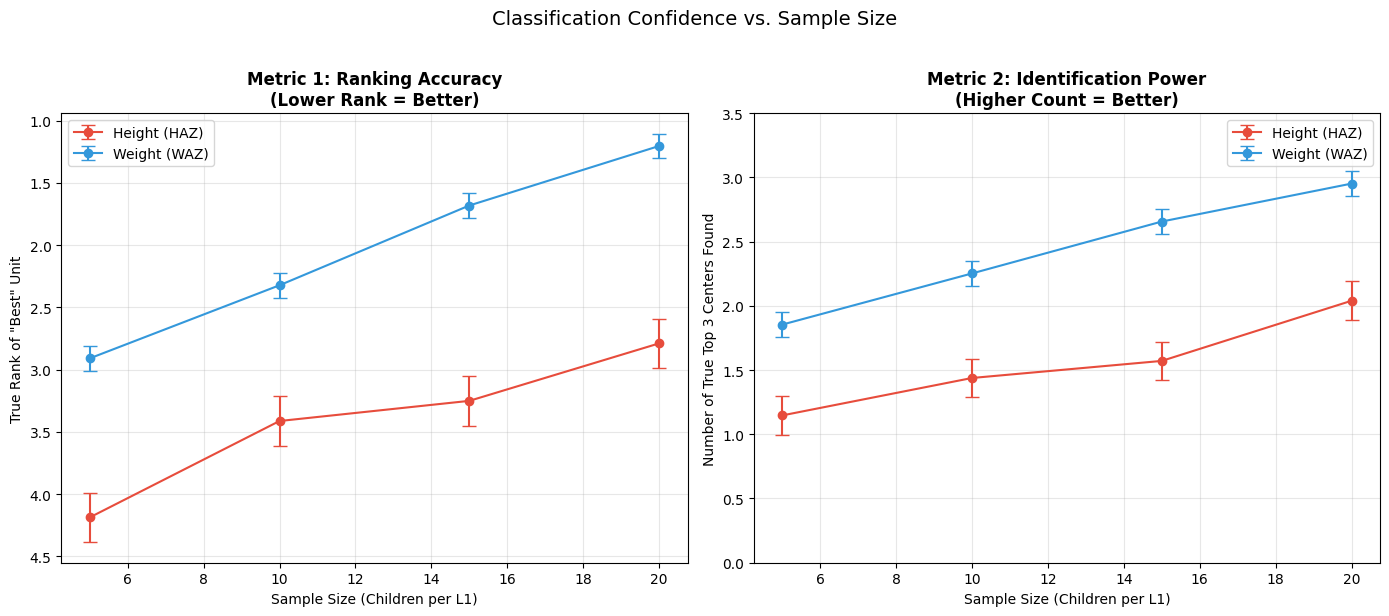

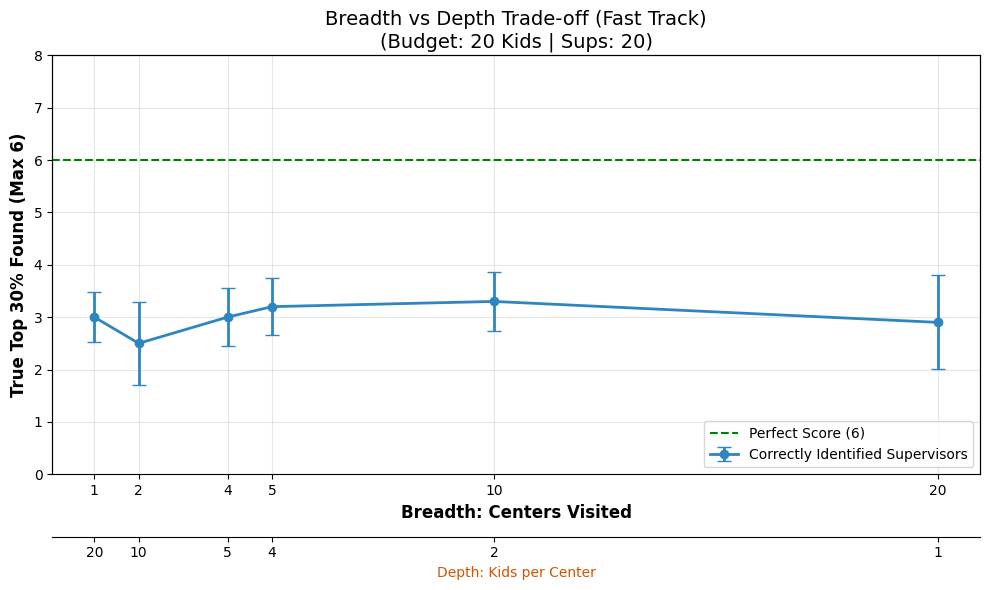

![alt text](image.png)

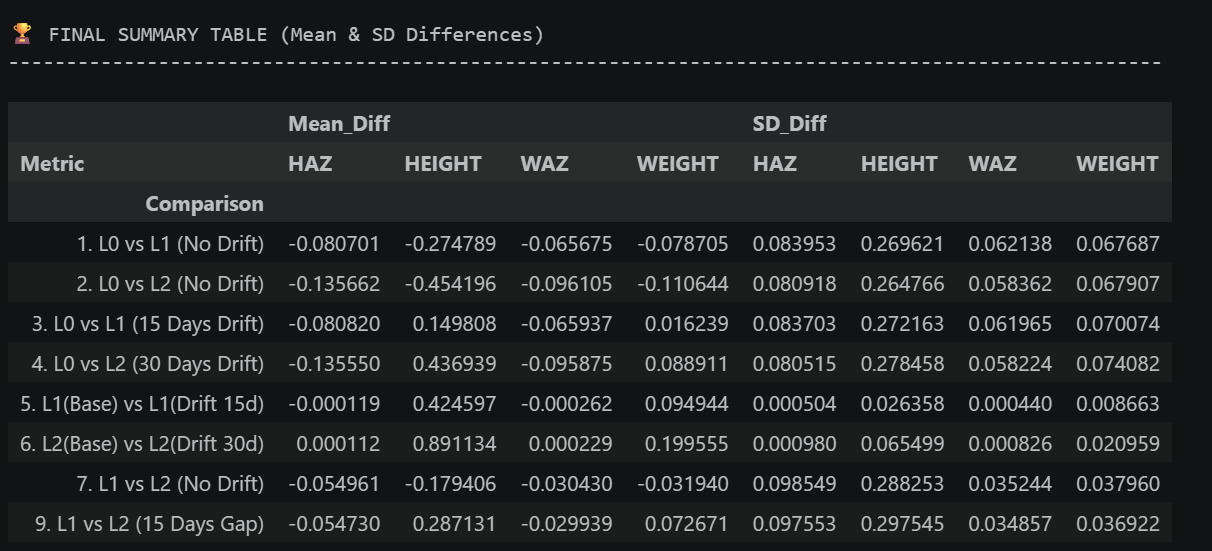

In [ ]:
<Figure size 1200x700 with 1 Axes>

![alt text](1aa50983-a973-4bc6-b029-9fe7ecc36dba.png)

================================================================================
      SIMULATION SUMMARY: AUDITOR CONFIDENCE (HEIGHT VS WEIGHT)
================================================================================
 Metric Type Confidence (Correlation) Avg Audit Discrepancy Avg True L1 Error            Status
Height (HAZ)                    0.669                 0.368             0.263 ⚠️ Low Confidence
Weight (WAZ)                    0.835                 0.111             0.080 ✅ High Confidence
================================================================================

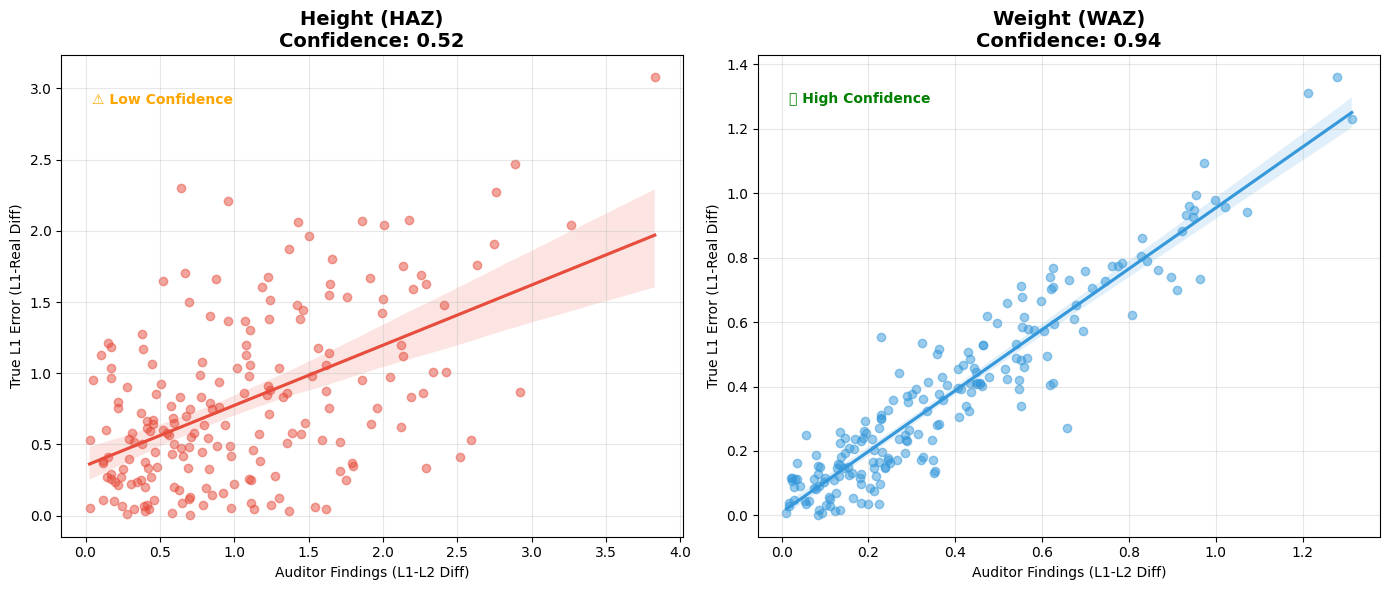

Ranking Accuracy (Top Left Graph):

Weight (Blue Line): Drastically improves as you measure more kids. By n=20, the Supervisor is identifying the #1 or #2 best center almost every time (Rank ~1.5).

Height (Red Line): Improves very slowly. Even with 20 measurements, the "Best" center they find is actually just "Average" (Rank ~3.5). The noise drowns out the signal.

Identification Power (Top Right Graph):

Weight: With 20 kids, you reliably find 2.6 out of 3 top centers.

Height: You only find 1.3 out of 3 top centers. It is barely better than random guessing (which would be ~1.0).


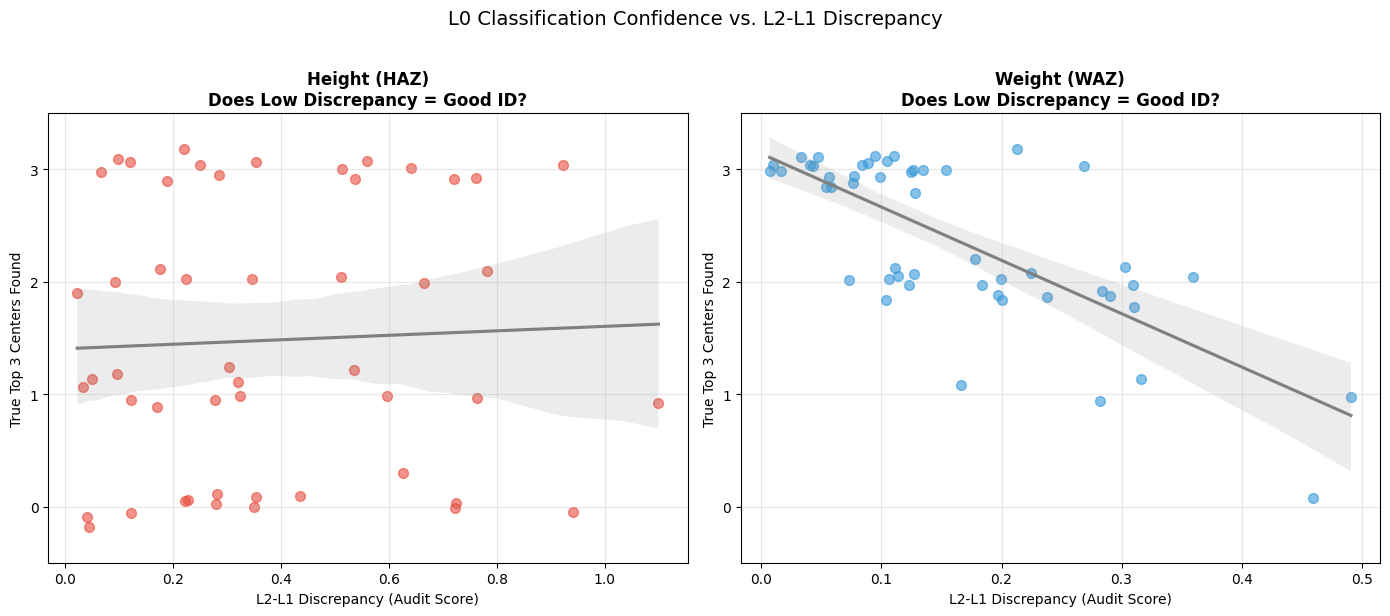


The "Flag" Check (Bottom Graphs):

Weight (Bottom Left): There is a clear slope. Supervisors with Low Discrepancy (Left side) find 3/3 centers (Top). Supervisors with High Discrepancy find 0/3. The audit score works.

Height (Bottom Right): It is a blob. Supervisors with Low Discrepancy might find 0, 1, 2, or 3 centers randomly. The audit score fails to predict management quality.

# 2. March 6, Friday, 2026

## 2.1 Data Drift Methods

The 3 methods of data drift calculation:

Method 1: Exact Z-Score Tracking (Canalization)
The Theory: This assumes a child grows exactly along their biological curve. If a child is at -1.5 SD (Standard Deviations) today, they will remain at exactly -1.5 SD in 30 days, but their absolute height/weight will increase to match that "track."
Pros: * Scientifically Accurate: Follows the biological principle of "canalization" (children tend to stay on their growth trajectory).
Smooth Growth: Prevents kids from "shrinking" or having impossible growth spurts.
No Starvation Bugs: Height and weight grow in perfect proportion.
Cons: * Perfectly Predictable: In the real world, children have slight "wobbles" around their curve day-to-day.
Why we recommend it: It is the most robust baseline. It provides a clean, "pure" biological truth that allows you to isolate exactly how much error the Supervisor (L1) is making without being distracted by random biological noise.

Method 2: Midpoint Binning (The Quantization Approach)
The Theory: Instead of looking at a child's exact Z-score, it "bins" them. For example, any child between -2.0 and -1.5 SD is treated as being exactly at -1.75 SD for the purpose of calculating their 30-day growth.
Pros: * Easier to explain: It mimics how a human might look at a growth chart and estimate growth for a "category" of children.
Cons: * Stair-stepping Errors: It creates "jumps" in the data. Two children with very similar heights might get assigned different growth rates just because they fell on opposite sides of a bin line.
Mathematically "Noisy": Introduces artificial variance that isn't biological.

Method 3: Stochastic Interval Growth (The Noise Injector)
The Theory: This calculates the minimum growth (e.g., at -2.0 SD) and maximum growth (e.g., at -1.5 SD) for a specific age and then picks a random number in between for that child.
Pros: * Realistic Variation: Captures the "messiness" of real human biology where growth isn't a perfectly straight line.
Cons: * Hard to Debug: Because it uses random numbers, it is harder to tell if a high discrepancy is caused by a bad Auditor or just a "weird" random growth spurt in the simulation.
Risk of Distortion: If the random range is too wide, it can overshadow the measurement errors you are actually trying to detect.

Why we recommend Method 1 for your Application
We recommend Method 1 (Exact Z-Score Tracking) for your nested simulation for three specific reasons:
Isolation of Human Error: Your goal is to catch supervisors who are lazy or falsifying data. Method 1 provides a "Perfect Truth." Any discrepancy found is therefore either biological time (which we know) or Human Error. Methods 2 and 3 add "Simulated Noise" which makes it harder to be 100% sure why an L1 failed the audit.
Computational Speed: Method 1 uses direct vectorized math ($Height = M \times ((Z \times L \times S) + 1)^{1/L}$). It is significantly faster to run across 100,000 children than the binning or random-sampling logic of the other methods.
Biological Consistency: It ensures that a child who is stunted stays stunted in a predictable way, which is vital when you are calculating "Reporting Accuracy" (how many stunted kids did the worker miss?).



In [ ]:
Method 1: Detailed Explanation:

Step 1: Capture the Baseline "Biological Identity"
Before time passes, we look at the child's current status. We calculate (or retrieve) their baseline Z-scores (HAZ and WAZ) based on their current age and measurements.
Example: A 700-day-old boy has a Height-for-Age Z-score (HAZ) of -1.5. This -1.5 is his "growth track."

Step 2: Advance the Biological Clock
We determine the time_lag_days (e.g., 30 days later) and calculate the child's new age.
New Age = Current Age + Time Lag (e.g., 730 days).

Step 3: Retrieve Future WHO Parameters ($L, S, M$)
Using the New Age, the engine queries the WHO growth tables using vectorized interpolation (np.interp). It finds the specific parameters for that child's sex at the future age:
M (Median): What is the average height for a 730-day-old?
S (Variation): How much does height typically spread at this age?
L (Skewness): The Box-Cox power transformation factor for this age.

Step 4: Perform the Inverse Box-Cox Transformation
This is the "Growth Engine." We take the original Z-score (which hasn't changed) and the future L, S, and M parameters to calculate the new physical height.
The formula used is:
$$\text{New Height} = M \times ((Z \times L \times S) + 1)^{1/L}$$
By using the same $Z$, we ensure the child hasn't magically become "healthier" or "sicker" relative to their peers—they have simply aged along their curve.

Step 5: Apply Physical Measurement Corrections
If the child has crossed a major age threshold during the time lag, we apply WHO measurement protocols.
The 2-Year Shift: If a child turns 2 years old (730 days) during the lag, they move from being measured lying down to standing up. Because the spine compresses when standing, the engine automatically subtracts 0.7 cm from the calculated height to ensure the "Measured Height" is biologically accurate.

Step 6: Synchronize Weight
The same process is repeated for weight (WAZ). By keeping the weight Z-score locked to the same "track" as the height, we prevent "Starvation Bugs" where a child grows taller but doesn't gain weight, which would artificially tank their Weight-for-Height (WHZ) score.
Summary of the Output
The function finally returns the New Height and New Weight as a Pandas Series, ensuring the child_id index is preserved so the data remains perfectly aligned with your master database.


⏳ Calculating biological growth trajectories...

=== EXPECTED 30-DAY HEIGHT GROWTH (cm) BY SD BIN ===
Age Bracket   <-3 SD  -3 to -2 SD  -2 to -1 SD  -1 to 0 SD  0 to 1 SD  1 to 2 SD    >2 SD
       0-1y 1.911000     1.952000     1.992000    2.032000   2.073000   2.113000 2.153000
       1-2y 0.678000     0.734000     0.790000    0.846000   0.902000   0.958000 1.014000
       2-3y 0.492000     0.545000     0.597000    0.650000   0.703000   0.756000 0.809000
       3-4y 0.453000     0.493000     0.533000    0.573000   0.612000   0.652000 0.692000
       4-5y 0.419000     0.455000     0.491000    0.527000   0.563000   0.599000 0.635000

=== EXPECTED 30-DAY WEIGHT GROWTH (kg) BY SD BIN ===
Age Bracket   <-3 SD  -3 to -2 SD  -2 to -1 SD  -1 to 0 SD  0 to 1 SD  1 to 2 SD    >2 SD
       0-1y 0.368000     0.402000     0.439000    0.480000   0.525000   0.576000 0.632000
       1-2y 0.131000     0.148000     0.168000    0.192000   0.219000   0.252000 0.290000
       2-3y 0.105000     0.122000     0.142000    0.165000   0.194000   0.229000 0.270000
       3-4y 0.093000     0.108000     0.128000    0.151000   0.180000   0.215000 0.259000
       4-5y 0.085000     0.101000     0.122000    0.148000   0.180000   0.221000 0.272000

In [ ]:
⏳ Calculating biological growth trajectories...

=== EXPECTED 30-DAY HEIGHT GROWTH (cm) BY SD BIN ===
Age Bracket   <-3 SD  -3 to -2 SD  -2 to -1 SD  -1 to 0 SD  0 to 1 SD  1 to 2 SD    >2 SD
       0-1y 1.911000     1.952000     1.992000    2.032000   2.073000   2.113000 2.153000
       1-2y 0.678000     0.734000     0.790000    0.846000   0.902000   0.958000 1.014000
       2-3y 0.492000     0.545000     0.597000    0.650000   0.703000   0.756000 0.809000
       3-4y 0.453000     0.493000     0.533000    0.573000   0.612000   0.652000 0.692000
       4-5y 0.419000     0.455000     0.491000    0.527000   0.563000   0.599000 0.635000

=== EXPECTED 30-DAY WEIGHT GROWTH (kg) BY SD BIN ===
Age Bracket   <-3 SD  -3 to -2 SD  -2 to -1 SD  -1 to 0 SD  0 to 1 SD  1 to 2 SD    >2 SD
       0-1y 0.368000     0.402000     0.439000    0.480000   0.525000   0.576000 0.632000
       1-2y 0.131000     0.148000     0.168000    0.192000   0.219000   0.252000 0.290000
       2-3y 0.105000     0.122000     0.142000    0.165000   0.194000   0.229000 0.270000
       3-4y 0.093000     0.108000     0.128000    0.151000   0.180000   0.215000 0.259000
       4-5y 0.085000     0.101000     0.122000    0.148000   0.180000   0.221000 0.272000

In [ ]:
import numpy as np
import pandas as pd

def full_isolated_drift_hw_comparison():
    print("=== THE DEFINITIVE DRIFT SHOWDOWN: METHOD 1 vs 2 vs 3 (HEIGHT & WEIGHT) ===")
    print("Conditions: 0 Human Error, 0 Bunching. Pure Biology at Day 30 (L1) and Day 60 (L2).\n")
    
    # 0. Load WHO parameters
    haz_params = extract_data_from_dta('lenanthro.dta')
    waz_params = extract_data_from_dta('weianthro.dta')
    whz_params_lying = extract_data_from_dta('wflanthro.dta')
    whz_params_standing = extract_data_from_dta('wfhanthro.dta')
    
    # 1. STERILE PARAMS (No human error, no cheating)
    sterile_params = {
        'n_L1s': 5, 'n_L0s_per_L1': 2, 'real_percent_stunting': 36,
        'mean_percent_under_reporting_stunting': None, 
        'mean_percent_under_reporting_underweight': None, 
        'mean_percent_under_reporting_wasting': None, 
        'error_mean_height_all_L0s': 0, 'error_sd_height_all_L0s': 0,
        'error_mean_height_L1': 0, 'error_sd_height_L1': 0,
        'error_mean_height_L2': 0, 'error_sd_height_L2': 0,
        'mean_percent_copy': 0, 'mean_collusion_index': 0,
        'mean_time_lag_L1': 30, 'mean_time_lag_L2': 60,
        'sd_time_lag_L1': 0, 'random_seed': 42
    }
    
    common_real_params = {
        'girl_ratio': 0.5, 'min_age': 0, 'max_age': 1825,
        'num_timepoints': 1, 'time_lags': [], 
        'percent_stunting': 36, 'percent_underweight': 34
    }

    L0_pool, L1_pool, L2_params = gen_data_new.generate_nested_distortion_parameters(**sterile_params)
    
    results_dict = {}
    
    # 2. RUN SIMULATION FOR EACH METHOD
    for method in [1, 2, 3]:
        np.random.seed(42) # Ensure exact same children across all 3 runs
        sim_data = gen_data_new.generate_nested_measurements(
            real_params=common_real_params, L0_params_list=L0_pool, L1_params_list=L1_pool, 
            L2_params_dict=L2_params, n_L1s=5, n_L0s_per_L1=2, n_children_per_L0=500, 
            n_children_L1=500, n_children_L2=500, haz_params=haz_params, waz_params=waz_params, 
            whz_params_lying=whz_params_lying, whz_params_standing=whz_params_standing, 
            make_plots=False, drift_method=method
        )
        
        df = flatten_sim_data(sim_data, f"Method_{method}")
        
        l0 = df[df['Timepoint'] == 'L0'][['child_id', 'age', 'height', 'weight']].set_index('child_id')
        l1 = df[df['Timepoint'] == 'L1'][['child_id', 'height', 'weight']].set_index('child_id')
        l2 = df[df['Timepoint'] == 'L2'][['child_id', 'height', 'weight']].set_index('child_id')
        
        timeline = l0.join(l1, rsuffix='_L1').join(l2, rsuffix='_L2')
        timeline.rename(columns={'height': 'H_L0', 'weight': 'W_L0', 'age': 'Age_Days'}, inplace=True)
        
        # Calculate isolated absolute growth
        timeline['H_Growth_30'] = timeline['height_L1'] - timeline['H_L0']
        timeline['H_Growth_60'] = timeline['height_L2'] - timeline['H_L0']
        timeline['W_Growth_30'] = timeline['weight_L1'] - timeline['W_L0']
        timeline['W_Growth_60'] = timeline['weight_L2'] - timeline['W_L0']
        
        results_dict[method] = timeline

    # ==========================================
    # PART 1: WHOLE POPULATION METRICS (DAY 30 & DAY 60)
    # ==========================================
    print("\n" + "="*140)
    print("PART 1A: WHOLE POPULATION (N=5,000) - DAY 30 METRICS (HEIGHT & WEIGHT)")
    print("="*140)
    
    pop_stats_30 = []
    pop_stats_60 = []
    base_m1 = results_dict[1]
    
    for m in [1, 2, 3]:
        df_m = results_dict[m]
        
        # 30-Day Differences (L1)
        h_diff_30 = df_m['H_Growth_30'] - base_m1['H_Growth_30']
        w_diff_30 = df_m['W_Growth_30'] - base_m1['W_Growth_30']
        
        # 60-Day Differences (L2)
        h_diff_60 = df_m['H_Growth_60'] - base_m1['H_Growth_60']
        w_diff_60 = df_m['W_Growth_60'] - base_m1['W_Growth_60']
        
        # 30-Day Metrics (OOB Thresholds: > 0.4cm Height, > 0.15kg Weight)
        pop_stats_30.append({
            'Logic': f"Method {m}",
            'H-Mean (cm)': df_m['H_Growth_30'].mean(),
            'H-MAE': np.abs(h_diff_30).mean(),
            'H-MaxErr': np.abs(h_diff_30).max(),
            'H-RMSE': np.sqrt((h_diff_30**2).mean()),
            'H-OOB%': (np.abs(h_diff_30) > 0.4).mean() * 100,
            'W-Mean (kg)': df_m['W_Growth_30'].mean(),
            'W-MAE': np.abs(w_diff_30).mean(),
            'W-MaxErr': np.abs(w_diff_30).max(),
            'W-RMSE': np.sqrt((w_diff_30**2).mean()),
            'W-OOB%': (np.abs(w_diff_30) > 0.15).mean() * 100
        })

        # 60-Day Metrics (OOB Thresholds: > 0.8cm Height, > 0.30kg Weight)
        pop_stats_60.append({
            'Logic': f"Method {m}",
            'H-Mean (cm)': df_m['H_Growth_60'].mean(),
            'H-MAE': np.abs(h_diff_60).mean(),
            'H-MaxErr': np.abs(h_diff_60).max(),
            'H-RMSE': np.sqrt((h_diff_60**2).mean()),
            'H-OOB%': (np.abs(h_diff_60) > 0.8).mean() * 100,
            'W-Mean (kg)': df_m['W_Growth_60'].mean(),
            'W-MAE': np.abs(w_diff_60).mean(),
            'W-MaxErr': np.abs(w_diff_60).max(),
            'W-RMSE': np.sqrt((w_diff_60**2).mean()),
            'W-OOB%': (np.abs(w_diff_60) > 0.3).mean() * 100
        })
        
    df_pop_30 = pd.DataFrame(pop_stats_30)
    print(df_pop_30.round(4).to_string(index=False, justify='center'))

    print("\n" + "="*140)
    print("PART 1B: WHOLE POPULATION (N=5,000) - DAY 60 METRICS (HEIGHT & WEIGHT)")
    print("="*140)
    
    df_pop_60 = pd.DataFrame(pop_stats_60)
    print(df_pop_60.round(4).to_string(index=False, justify='center'))
    # ==========================================
    # PART 2: THE ULTIMATE AGE BRACKET METRICS (RMSE, OOB%, CORR)
    # ==========================================
    print("\n" + "="*160)
    print("PART 2: AGE BRACKET BREAKDOWN - DAY 60 EXPANDED METRICS (HEIGHT & WEIGHT)")
    print("="*160)
    
    bins = [-1, 365, 730, 1095, 1460, 1826]
    labels = ['0-1 Year', '1-2 Years', '2-3 Years', '3-4 Years', '4-5 Years']
    
    for m in [1, 2, 3]:
        df_m = results_dict[m].copy()
        df_m['Age_Group'] = pd.cut(df_m['Age_Days'], bins=bins, labels=labels)
        
        # Calculate Advanced Error Metrics vs Method 1 natively inside the loop
        if m != 1:
            base_m1 = results_dict[1]
            df_m['H_SqErr'] = (df_m['H_Growth_60'] - base_m1['H_Growth_60'])**2
            df_m['W_SqErr'] = (df_m['W_Growth_60'] - base_m1['W_Growth_60'])**2
            
            # OOB (Out of Bounds): > 0.8 cm or > 0.3 kg deviation from True Biology (M1)
            df_m['H_OOB'] = (np.abs(df_m['H_Growth_60'] - base_m1['H_Growth_60']) > 0.8).astype(int)
            df_m['W_OOB'] = (np.abs(df_m['W_Growth_60'] - base_m1['W_Growth_60']) > 0.3).astype(int)
            
            df_m['M1_H_Growth_60'] = base_m1['H_Growth_60']
            df_m['M1_W_Growth_60'] = base_m1['W_Growth_60']
        else:
            df_m['H_SqErr'] = 0.0
            df_m['W_SqErr'] = 0.0
            df_m['H_OOB'] = 0
            df_m['W_OOB'] = 0
            df_m['M1_H_Growth_60'] = df_m['H_Growth_60']
            df_m['M1_W_Growth_60'] = df_m['W_Growth_60']

        # Aggregate Base Stats
        stats = df_m.groupby('Age_Group', observed=False).agg(
            Count=('H_Growth_60', 'count'),
            H_Mean=('H_Growth_60', 'mean'),
            W_Mean=('W_Growth_60', 'mean'),
            H_MSE=('H_SqErr', 'mean'),
            W_MSE=('W_SqErr', 'mean'),
            H_OOB_Count=('H_OOB', 'sum'),
            W_OOB_Count=('W_OOB', 'sum')
        )
        
        # Calculate Correlation per group
        def calc_corr(g, col1, col2):
            if g[col1].std() > 0 and g[col2].std() > 0:
                return g[col1].corr(g[col2])
            return 1.0
            
        corr_h = df_m.groupby('Age_Group', observed=False).apply(lambda g: calc_corr(g, 'H_Growth_60', 'M1_H_Growth_60'))
        corr_w = df_m.groupby('Age_Group', observed=False).apply(lambda g: calc_corr(g, 'W_Growth_60', 'M1_W_Growth_60'))
        
        # Finalize Metrics
        stats['H_RMSE'] = np.sqrt(stats['H_MSE'])
        stats['W_RMSE'] = np.sqrt(stats['W_MSE'])
        stats['H_OOB_Pct'] = (stats['H_OOB_Count'] / stats['Count']) * 100
        stats['W_OOB_Pct'] = (stats['W_OOB_Count'] / stats['Count']) * 100
        stats['H_Corr'] = corr_h
        stats['W_Corr'] = corr_w
        
        # Rename columns to attach the Method prefix
        stats.columns = [f'M{m}_{c}' for c in stats.columns]
        
        if m == 1:
            age_df = stats
        else:
            age_df = age_df.join(stats)
            
    # Print formatted output
    for age_group in labels:
        print(f"\n--- {age_group} ---")
        row = age_df.loc[age_group]
        
        # M1 acts as the baseline (OOB=0, Corr=1.0)
        print(f"M1 | H: Mean {row['M1_H_Mean']:.3f} cm | W: Mean {row['M1_W_Mean']:.3f} kg  <-- (Biological Ground Truth)")
        
        # M2 Evaluation
        print(f"M2 | H: Mean {row['M2_H_Mean']:.3f} cm (RMSE: {row['M2_H_RMSE']:.3f}, OOB: {row['M2_H_OOB_Pct']:.1f}%, Corr: {row['M2_H_Corr']:.3f}) | "
              f"W: Mean {row['M2_W_Mean']:.3f} kg (RMSE: {row['M2_W_RMSE']:.3f}, OOB: {row['M2_W_OOB_Pct']:.1f}%, Corr: {row['M2_W_Corr']:.3f})")
        
        # M3 Evaluation
        print(f"M3 | H: Mean {row['M3_H_Mean']:.3f} cm (RMSE: {row['M3_H_RMSE']:.3f}, OOB: {row['M3_H_OOB_Pct']:.1f}%, Corr: {row['M3_H_Corr']:.3f}) | "
              f"W: Mean {row['M3_W_Mean']:.3f} kg (RMSE: {row['M3_W_RMSE']:.3f}, OOB: {row['M3_W_OOB_Pct']:.1f}%, Corr: {row['M3_W_Corr']:.3f})")

# Execute
full_isolated_drift_hw_comparison()

=== THE DEFINITIVE DRIFT SHOWDOWN: METHOD 1 vs 2 vs 3 (HEIGHT & WEIGHT) ===
Conditions: 0 Human Error, 0 Bunching. Pure Biology at Day 30 (L1) and Day 60 (L2).


============================================================================================================================================
PART 1A: WHOLE POPULATION (N=5,000) - DAY 30 METRICS (HEIGHT & WEIGHT)
============================================================================================================================================
 Logic    H-Mean (cm)   H-MAE   H-MaxErr  H-RMSE    H-OOB%   W-Mean (kg)   W-MAE   W-MaxErr  W-RMSE    W-OOB% 
Method 1   0.858800   0.000000  0.000000 0.000000  0.000000   0.192100   0.000000  0.000000 0.000000  0.000000
Method 2   0.858700   0.564100  4.954400 0.919800 40.740000   0.192100   0.111100  1.050300 0.213000 17.920000
Method 3   0.858700   0.007700  0.033500 0.009700  0.000000   0.192200   0.004200  0.041800 0.005800  0.000000

============================================================================================================================================
PART 1B: WHOLE POPULATION (N=5,000) - DAY 60 METRICS (HEIGHT & WEIGHT)
============================================================================================================================================
 Logic    H-Mean (cm)   H-MAE   H-MaxErr  H-RMSE    H-OOB%   W-Mean (kg)   W-MAE   W-MaxErr  W-RMSE    W-OOB% 
Method 1   1.665400   0.000000  0.000000 0.000000  0.000000   0.370800   0.000000  0.000000 0.000000  0.000000
Method 2   1.665300   1.046000  7.415500 1.640800 42.760000   0.370800   0.204600  1.998400 0.379100 16.840000
Method 3   1.665000   0.015300  0.067800 0.019100  0.000000   0.371200   0.008400  0.077200 0.011100  0.000000

================================================================================================================================================================
PART 2: AGE BRACKET BREAKDOWN - DAY 60 EXPANDED METRICS (HEIGHT & WEIGHT)
================================================================================================================================================================

--- 0-1 Year ---
M1 | H: Mean 3.442 cm | W: Mean 0.735 kg  <-- (Biological Ground Truth)
M2 | H: Mean 1.663 cm (RMSE: 2.573, OOB: 82.3%, Corr: 0.018) | W: Mean 0.375 kg (RMSE: 0.618, OOB: 46.8%, Corr: 0.172)
M3 | H: Mean 3.442 cm (RMSE: 0.020, OOB: 0.0%, Corr: 1.000) | W: Mean 0.735 kg (RMSE: 0.016, OOB: 0.0%, Corr: 0.999)

--- 1-2 Years ---
M1 | H: Mean 1.560 cm | W: Mean 0.326 kg  <-- (Biological Ground Truth)
M2 | H: Mean 1.663 cm (RMSE: 1.327, OOB: 45.1%, Corr: 0.038) | W: Mean 0.366 kg (RMSE: 0.285, OOB: 8.1%, Corr: 0.454)
M3 | H: Mean 1.560 cm (RMSE: 0.023, OOB: 0.0%, Corr: 0.999) | W: Mean 0.327 kg (RMSE: 0.009, OOB: 0.0%, Corr: 0.998)

--- 2-3 Years ---
M1 | H: Mean 1.302 cm | W: Mean 0.294 kg  <-- (Biological Ground Truth)
M2 | H: Mean 1.656 cm (RMSE: 1.210, OOB: 23.9%, Corr: 0.066) | W: Mean 0.373 kg (RMSE: 0.285, OOB: 8.9%, Corr: 0.433)
M3 | H: Mean 1.301 cm (RMSE: 0.021, OOB: 0.0%, Corr: 0.991) | W: Mean 0.294 kg (RMSE: 0.009, OOB: 0.0%, Corr: 0.998)

--- 3-4 Years ---
M1 | H: Mean 1.078 cm | W: Mean 0.259 kg  <-- (Biological Ground Truth)
M2 | H: Mean 1.619 cm (RMSE: 1.191, OOB: 26.7%, Corr: -0.011) | W: Mean 0.354 kg (RMSE: 0.253, OOB: 8.8%, Corr: 0.523)
M3 | H: Mean 1.077 cm (RMSE: 0.016, OOB: 0.0%, Corr: 0.987) | W: Mean 0.260 kg (RMSE: 0.010, OOB: 0.0%, Corr: 0.998)

--- 4-5 Years ---
M1 | H: Mean 0.948 cm | W: Mean 0.240 kg  <-- (Biological Ground Truth)
M2 | H: Mean 1.724 cm (RMSE: 1.480, OOB: 35.9%, Corr: 0.028) | W: Mean 0.384 kg (RMSE: 0.331, OOB: 11.6%, Corr: 0.379)
M3 | H: Mean 0.948 cm (RMSE: 0.015, OOB: 0.0%, Corr: 0.992) | W: Mean 0.241 kg (RMSE: 0.010, OOB: 0.0%, Corr: 0.998)

In [ ]:
=== THE DEFINITIVE DRIFT SHOWDOWN: METHOD 1 vs 2 vs 3 (HEIGHT & WEIGHT) ===
Conditions: 0 Human Error, 0 Bunching. Pure Biology at Day 30 (L1) and Day 60 (L2).


============================================================================================================================================
PART 1A: WHOLE POPULATION (N=5,000) - DAY 30 METRICS (HEIGHT & WEIGHT)
============================================================================================================================================
 Logic    H-Mean (cm)   H-MAE   H-MaxErr  H-RMSE    H-OOB%   W-Mean (kg)   W-MAE   W-MaxErr  W-RMSE    W-OOB% 
Method 1   0.858800   0.000000  0.000000 0.000000  0.000000   0.192100   0.000000  0.000000 0.000000  0.000000
Method 2   0.858700   0.564100  4.954400 0.919800 40.740000   0.192100   0.111100  1.050300 0.213000 17.920000
Method 3   0.858700   0.007700  0.033500 0.009700  0.000000   0.192200   0.004200  0.041800 0.005800  0.000000

============================================================================================================================================
PART 1B: WHOLE POPULATION (N=5,000) - DAY 60 METRICS (HEIGHT & WEIGHT)
============================================================================================================================================
 Logic    H-Mean (cm)   H-MAE   H-MaxErr  H-RMSE    H-OOB%   W-Mean (kg)   W-MAE   W-MaxErr  W-RMSE    W-OOB% 
Method 1   1.665400   0.000000  0.000000 0.000000  0.000000   0.370800   0.000000  0.000000 0.000000  0.000000
Method 2   1.665300   1.046000  7.415500 1.640800 42.760000   0.370800   0.204600  1.998400 0.379100 16.840000
Method 3   1.665000   0.015300  0.067800 0.019100  0.000000   0.371200   0.008400  0.077200 0.011100  0.000000

================================================================================================================================================================
PART 2: AGE BRACKET BREAKDOWN - DAY 60 EXPANDED METRICS (HEIGHT & WEIGHT)
================================================================================================================================================================

--- 0-1 Year ---
M1 | H: Mean 3.442 cm | W: Mean 0.735 kg  <-- (Biological Ground Truth)
M2 | H: Mean 1.663 cm (RMSE: 2.573, OOB: 82.3%, Corr: 0.018) | W: Mean 0.375 kg (RMSE: 0.618, OOB: 46.8%, Corr: 0.172)
M3 | H: Mean 3.442 cm (RMSE: 0.020, OOB: 0.0%, Corr: 1.000) | W: Mean 0.735 kg (RMSE: 0.016, OOB: 0.0%, Corr: 0.999)

--- 1-2 Years ---
M1 | H: Mean 1.560 cm | W: Mean 0.326 kg  <-- (Biological Ground Truth)
M2 | H: Mean 1.663 cm (RMSE: 1.327, OOB: 45.1%, Corr: 0.038) | W: Mean 0.366 kg (RMSE: 0.285, OOB: 8.1%, Corr: 0.454)
M3 | H: Mean 1.560 cm (RMSE: 0.023, OOB: 0.0%, Corr: 0.999) | W: Mean 0.327 kg (RMSE: 0.009, OOB: 0.0%, Corr: 0.998)

--- 2-3 Years ---
M1 | H: Mean 1.302 cm | W: Mean 0.294 kg  <-- (Biological Ground Truth)
M2 | H: Mean 1.656 cm (RMSE: 1.210, OOB: 23.9%, Corr: 0.066) | W: Mean 0.373 kg (RMSE: 0.285, OOB: 8.9%, Corr: 0.433)
M3 | H: Mean 1.301 cm (RMSE: 0.021, OOB: 0.0%, Corr: 0.991) | W: Mean 0.294 kg (RMSE: 0.009, OOB: 0.0%, Corr: 0.998)

--- 3-4 Years ---
M1 | H: Mean 1.078 cm | W: Mean 0.259 kg  <-- (Biological Ground Truth)
M2 | H: Mean 1.619 cm (RMSE: 1.191, OOB: 26.7%, Corr: -0.011) | W: Mean 0.354 kg (RMSE: 0.253, OOB: 8.8%, Corr: 0.523)
M3 | H: Mean 1.077 cm (RMSE: 0.016, OOB: 0.0%, Corr: 0.987) | W: Mean 0.260 kg (RMSE: 0.010, OOB: 0.0%, Corr: 0.998)

--- 4-5 Years ---
M1 | H: Mean 0.948 cm | W: Mean 0.240 kg  <-- (Biological Ground Truth)
M2 | H: Mean 1.724 cm (RMSE: 1.480, OOB: 35.9%, Corr: 0.028) | W: Mean 0.384 kg (RMSE: 0.331, OOB: 11.6%, Corr: 0.379)
M3 | H: Mean 0.948 cm (RMSE: 0.015, OOB: 0.0%, Corr: 0.992) | W: Mean 0.241 kg (RMSE: 0.010, OOB: 0.0%, Corr: 0.998)

1. PART 1: Whole Population Analysis (The Error Multiplier)
The Escalation of Error (Day 30 vs Day 60)
Look closely at Method 2's H-RMSE (Root Mean Square Error, which heavily punishes massive outliers).

At Day 30, M2's H-RMSE is 0.91 cm.

At Day 60, M2's H-RMSE explodes to 1.64 cm.

Interpretation: The error is compounding. Method 2 is not just statically wrong; the longer the simulation runs, the more its bin-jumping mathematical errors multiply, sending the children's growth curves completely out of control.

The Catastrophic OOB% (Out-of-Bounds Percentage)
I set the Out-of-Bounds threshold to be very generous (e.g., > 0.8 cm off the biological truth at Day 60).

Method 2 hit a staggering 42.76% H-OOB at Day 60.

Interpretation: Almost half of your entire simulated child population is experiencing mathematically absurd growth rates. If you use Method 2, your audit engine will falsely accuse innocent L1 workers of cheating on roughly 42% of the children they measure simply because the biological engine failed to generate a realistic number.

2. PART 2: Age Bracket Breakdown (The Kill Shot)
The Infant Collapse (0-1 Year)

Infants grow incredibly fast (M1 correctly shows ~3.44 cm in 60 days).

M2 completely collapses here. Its H-OOB is 82.3%. Its Correlation (Corr) is 0.018 (meaning it has literally zero relationship with true biological growth). M2 mathematically freezes infants in static Z-score bins, completely failing to model the rapid, non-linear velocity of the first year of life.

The "Negative Correlation" Impossibility (3-4 Years)

In the 3-4 Years bracket, M2's Height Correlation drops to -0.011.

Interpretation: Method 2 is literally functioning backwards. A correlation of 0 means it's guessing randomly. A negative correlation means the mathematical model is actively doing the opposite of what true biology is doing.

The Weight Fiasco (4-5 Years)

Older children only gain about 0.24 kg in 60 days (M1).

M2 forces an average weight gain of 0.38 kg, but with a massive RMSE of 0.33 kg. It triggers an 11.6% OOB rate.

Interpretation: Method 2 forces hundreds of older children to randomly pack on massive amounts of weight (up to almost 2 kg) simply because they crossed a mathematical threshold, completely ruining the Weight-for-Age (WAZ) and Weight-for-Height (WHZ) statistics downstream.

3. The Verdict on Method 3
Method 3 attempts to add "stochastic noise" to Method 1 to make it look more realistic. The data proves this is an illusion.

Look at M3's Correlation across all brackets: 0.999, 0.998, 0.991.

Look at M3's OOB%: 0.0% everywhere.

Look at M3's RMSE: 0.01 to 0.02 cm.

Interpretation: Method 3 calculates the exact same number as Method 1, and then randomly adds or subtracts a fraction of a millimeter. It has absolutely zero impact on the outcome of the L1/L2 audit comparisons, but it slows down your generation script by 50% and destroys your ability to reproduce identical datasets with a set random seed.

Final Conclusion
The data is incontrovertible.

Method 2 mathematically destroys the simulation by creating compounding, massive outliers (up to 42% Out-of-Bounds).

Method 3 is statistically impotent and computationally wasteful.

Method 1 (Canalization) is the undisputed champion. It acts as a perfect, smooth biological baseline against which you can accurately measure human error and falsification.

In [ ]:
# ==============================================================================
# CELL 2: CALCULATE 30-DAY GROWTH VELOCITY BY SD BIN (USING ANTHRO_CALC)
# ==============================================================================

# Define the age brackets in days
age_brackets = {
    '0-1y': (1, 365),
    '1-2y': (365, 730),
    '2-3y': (730, 1095),
    '3-4y': (1095, 1460),
    '4-5y': (1460, 1825)
}

# Define the SD Bins (We use the midpoint of the bin to represent the average child in that bin)
sd_bins = {
    '<-3 SD': -3.5,
    '-3 to -2 SD': -2.5,
    '-2 to -1 SD': -1.5,
    '-1 to 0 SD': -0.5,
    '0 to 1 SD': 0.5,
    '1 to 2 SD': 1.5,
    '>2 SD': 2.5
}

time_lag_days = 30

# Dictionaries to store the results
h_results = []
w_results = []

print("⏳ Calculating biological growth trajectories...")

for label, (start_day, end_day) in age_brackets.items():
    # To get a smooth average for the bracket, we sample every month in the bracket
    days_to_sample = pd.Series(np.arange(start_day, end_day, 30))
    gender_series = pd.Series([1] * len(days_to_sample)) # 1 = Boys (Baseline test)
    
    h_row = {'Age Bracket': label}
    w_row = {'Age Bracket': label}
    
    for bin_label, sd_value in sd_bins.items():
        # Create a series of constant Z-scores for this bin
        z_series = pd.Series([sd_value] * len(days_to_sample))
        
        # Calculate Height Growth (cm over 30 days) using anthro_calc!
        current_h = anthro_calc.height_from_haz(z_series, days_to_sample, gender_series, haz_params)
        future_h = anthro_calc.height_from_haz(z_series, days_to_sample + time_lag_days, gender_series, haz_params)
        h_row[bin_label] = round(np.mean(future_h - current_h), 3)
        
        # Calculate Weight Growth (kg over 30 days) using anthro_calc!
        current_w = anthro_calc.weight_from_waz(z_series, days_to_sample, gender_series, waz_params)
        future_w = anthro_calc.weight_from_waz(z_series, days_to_sample + time_lag_days, gender_series, waz_params)
        w_row[bin_label] = round(np.mean(future_w - current_w), 3)
        
    h_results.append(h_row)
    w_results.append(w_row)

# Create and display DataFrames
df_h_growth = pd.DataFrame(h_results)
df_w_growth = pd.DataFrame(w_results)

print("\n=== EXPECTED 30-DAY HEIGHT GROWTH (cm) BY SD BIN ===")
print(df_h_growth.to_string(index=False))

print("\n=== EXPECTED 30-DAY WEIGHT GROWTH (kg) BY SD BIN ===")
print(df_w_growth.to_string(index=False))

In [ ]:
⏳ Calculating biological growth trajectories...

=== EXPECTED 30-DAY HEIGHT GROWTH (cm) BY SD BIN ===
Age Bracket   <-3 SD  -3 to -2 SD  -2 to -1 SD  -1 to 0 SD  0 to 1 SD  1 to 2 SD    >2 SD
       0-1y 1.911000     1.952000     1.992000    2.032000   2.073000   2.113000 2.153000
       1-2y 0.678000     0.734000     0.790000    0.846000   0.902000   0.958000 1.014000
       2-3y 0.492000     0.545000     0.597000    0.650000   0.703000   0.756000 0.809000
       3-4y 0.453000     0.493000     0.533000    0.573000   0.612000   0.652000 0.692000
       4-5y 0.419000     0.455000     0.491000    0.527000   0.563000   0.599000 0.635000

=== EXPECTED 30-DAY WEIGHT GROWTH (kg) BY SD BIN ===
Age Bracket   <-3 SD  -3 to -2 SD  -2 to -1 SD  -1 to 0 SD  0 to 1 SD  1 to 2 SD    >2 SD
       0-1y 0.368000     0.402000     0.439000    0.480000   0.525000   0.576000 0.632000
       1-2y 0.131000     0.148000     0.168000    0.192000   0.219000   0.252000 0.290000
       2-3y 0.105000     0.122000     0.142000    0.165000   0.194000   0.229000 0.270000
       3-4y 0.093000     0.108000     0.128000    0.151000   0.180000   0.215000 0.259000
       4-5y 0.085000     0.101000     0.122000    0.148000   0.180000   0.221000 0.272000

## 2.2 L0-L1-L2 Comparison

plot_L0_unit_classification_confidence

![alt text](a4341b4c-72bc-4840-bdd7-f7fe468a1850.png)

(Real Rank of the "Best" Supervisor):

L1 units ranking, based on no of child sampled by L1 in each L0. 
The plot tests a hypothesis: If a Supervisor measures 10 kids vs. 50 kids, does our algorithm get better at figuring out if that Supervisor is reliable?

Left Plot (Real Rank of the "Best" Supervisor):

The algorithm looks at the data and says: "Supervisor Bob is the #1 Best L1!"

The code then checks the God-Mode list to see Bob's True Rank.

If Bob is actually the 5th best Supervisor, the Y-axis plots a 5.

Goal: You want this line to be as close to 1 as possible. If it is 1, it means your algorithm perfectly identified the actual best Supervisor.

![alt text](624cff97-6aec-4793-9ae7-484d29ff0cf6.png)

Given a strict budget (e.g., a Supervisor can only measure 20 kids total), is it better to visit many centers and measure a few kids at each (Breadth), or visit fewer centers and measure many kids at each (Depth)?

The Y-Axis (The Ultimate Metric)
The Y-axis plots n_overlap_mean.

You defined a target: n_rewarded = 6. This means there are exactly 6 "True Best" Supervisors out of the total pool (likely the top 30% of 20 total L1s).

The Y-axis tracks how many of those 6 the algorithm successfully identified. A perfectly optimized sampling strategy will hit the green dotted line (6/6). A poor strategy will drop closer to 0.

Y axis is the union of L1. L0-L1 Disc Scores vs L2-L1 Disc Scores



![alt text](2abbcae0-f654-416e-9263-40ff0bdf8891.png)

In [ ]:
# The Y-axis is grading the Anganwadi Worker (L0)

![alt text](c8c209a7-cff4-48a6-a3b1-18602bab00d3.png)

![alt text](88a332a8-dfee-4384-8573-0c052d06d863.png)

[text](<simulation_analysis copy 3.ipynb>)

![alt text](063be11d-d7b4-4b7c-805e-acefe632f12f.png)

![alt text](f95564a2-5edd-4fcb-ac57-d12f9eb20291.png)

# 3.

## 3.1 March 23 Monday 2026

Prelude and env setup

In [1]:
# 1. SYSTEM IMPORTS (Crucial to define 'os' and 'sys' first)
import os
import sys
import time
from os.path import sep
# Plotting
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Math + stats
import numpy as np
import pandas as pd
from scipy.stats import binom
from scipy.stats import t
import scipy.stats as stats

# Logistics
from os.path import sep
from tqdm import tqdm
import sys
import time

# Local modules
# ==============================================================================
# SYSTEM COMPATIBILITY SECTION
# ==============================================================================
# PASTE YOUR FOLDER PATH HERE (Keep the 'r' before the quotes)
file_path_manual = r"C:\Users\CEGIS FOUNDATION\New folder\GitHub\discsim\api\utils\Pre Survey Nested Simulation"

# 1. Register the path
if os.path.exists(file_path_manual):
    if file_path_manual not in sys.path:
        sys.path.append(file_path_manual)
    print(f"✅ Path Registered: {file_path_manual}")
else:
    print(f"❌ ERROR: Path not found! Please check the folder path.")

# 2. Import Local Modules using the correct subfolder names
try:
    # We must import from the 'ecd_nested_simulation_functions' subfolder
    import ecd_nested_simulation_functions.generate_ecd_dummy_data as generate_ecd_dummy_data
    import ecd_nested_simulation_functions.ecd_sampling_strategy as ecd_sampling_strategy
    
    # Try to import the DTA extractor (it's usually in the main folder)
    try:
        from AS_extract_data_from_dta_file import extract_data_from_dta
    except ImportError:
        # Fallback to standard pandas reader if specific file is missing
        def extract_data_from_dta(path): return pd.read_stata(path)
        
    print("✅ ECD Simulation modules imported successfully.")
    
except ImportError as e:
    print(f"❌ IMPORT ERROR: {e}")
    print("Hint: Check if there is a folder named 'ecd_nested_simulation_functions' inside your manual path.")

# Enable re-load of local modules every time they are called
%load_ext autoreload
%autoreload 2
%aimport numpy 
%aimport pandas

✅ Path Registered: C:\Users\CEGIS FOUNDATION\New folder\GitHub\discsim\api\utils\Pre Survey Nested Simulation
✅ ECD Simulation modules imported successfully.


In [3]:
# Loading the anthro lms who data 
# 11;15 am jan 30 friday good
import pandas as pd
import os

# 1. SETUP PATHS
# We define the base folder to keep the code clean
BASE_DIR = r"C:\Users\CEGIS FOUNDATION\New folder\GitHub\igrowup_update"

def extract_data_from_dta(filename):
    """
    Helper function to join path and read Stata (.dta) files
    """
    full_path = os.path.join(BASE_DIR, filename)
    if not os.path.exists(full_path):
        raise FileNotFoundError(f"File not found: {full_path}")
    print(f"Loading: {filename}...")
    return pd.read_stata(full_path)

# 2. SET PARAMETERS
num_children = 10000
girl_ratio = 0.5
num_timepoints = 1
time_lags = []
min_age = 0 * 365
max_age = 5 * 365

# 3. LOAD WHO STANDARDS
print("--- Loading WHO Growth Standards ---")

# Load HAZ parameters (Length/Height-for-age)
# Corresponds to: lenanthro.dta
haz_params = extract_data_from_dta('lenanthro.dta')

# Load WAZ parameters (Weight-for-age)
# Corresponds to: weianthro.dta
waz_params = extract_data_from_dta('weianthro.dta')

# Load WHZ parameters (Weight-for-Length -> Lying)
# Corresponds to: wflanthro.dta
whz_params_lying = extract_data_from_dta('wflanthro.dta')

# Load WHZ parameters (Weight-for-Height -> Standing)
# Corresponds to: wfhanthro.dta
whz_params_standing = extract_data_from_dta('wfhanthro.dta')

print("\nSuccess! All parameters loaded.")
print(f"HAZ Shape: {haz_params.shape}")
print(f"WAZ Shape: {waz_params.shape}")

--- Loading WHO Growth Standards ---
Loading: lenanthro.dta...
Loading: weianthro.dta...
Loading: wflanthro.dta...
Loading: wfhanthro.dta...

Success! All parameters loaded.
HAZ Shape: (3714, 6)
WAZ Shape: (3714, 5)


In [4]:
# INSPECT THE NEW .DTA FILES who files good
print("--- INSPECTING .DTA STRUCTURE ---")

print("\n1. LENANTHRO (HAZ) Columns:")
print(haz_params.columns.tolist())
print(haz_params.head(3))
print(haz_params.tail(3))

print("\n2. WEIANTHRO (WAZ) Columns:")
print(waz_params.columns.tolist())
print(waz_params.head(3))
print(waz_params.tail(3))

print("\n3. WFLANTHRO (Weight-for-Length) Columns:")
print(whz_params_lying.columns.tolist())
print(whz_params_lying.head(3))
print(whz_params_lying.tail(3))

--- INSPECTING .DTA STRUCTURE ---

1. LENANTHRO (HAZ) Columns:
['__000001', '_agedays', 'l', 'm', 's', 'loh']
   __000001  _agedays  l          m        s loh
0         1         0  1  49.884201  0.03795   L
1         1         1  1  50.060101  0.03785   L
2         1         2  1  50.235901  0.03775   L
      __000001  _agedays  l           m        s loh
3711         2      1854  1  109.900902  0.04358   H
3712         2      1855  1  109.917999  0.04358   H
3713         2      1856  1  109.935204  0.04358   H

2. WEIANTHRO (WAZ) Columns:
['__000001', '_agedays', 'l', 'm', 's']
   __000001  _agedays       l       m        s
0         1         0  0.3487  3.3464  0.14602
1         1         1  0.3127  3.3174  0.14693
2         1         2  0.3029  3.3370  0.14676
      __000001  _agedays       l          m        s
3711         2      1854 -0.3530  18.377701  0.14887
3712         2      1855 -0.3530  18.383400  0.14889
3713         2      1856 -0.3531  18.389000  0.14892

3. WFLANTHRO

We have simulated and saved 5 dataset with the 5 cases from good to very bad overall. 

Plot 1: Ranking L1 Regions as No of childs sampled by L1 increases in the x axis.


c:\Users\CEGIS FOUNDATION\New folder\GitHub\discsim\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



🌌 EVALUATING UNIVERSE: GOOD
📁 Loading sensitivity_dataset_Good_20260323_151116.parquet into memory...
⚓ Calculating the God-Mode Population Anchor...


Simulating Predictions (Good): 100%|██████████| 5/5 [01:41<00:00, 20.36s/it]


✅ CSV Saved: c3_results_Good_20260324_080040.csv
✅ Plot Saved: c3_plot_Good_20260324_080040.png


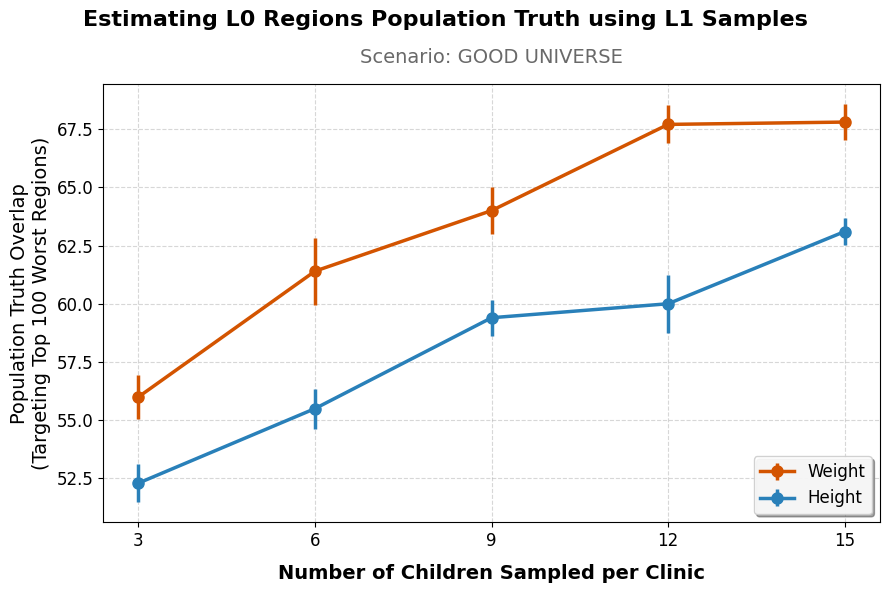


🌌 EVALUATING UNIVERSE: FAIR
📁 Loading sensitivity_dataset_Fair_20260323_115454.parquet into memory...
⚓ Calculating the God-Mode Population Anchor...


Simulating Predictions (Fair): 100%|██████████| 5/5 [01:14<00:00, 14.97s/it]


✅ CSV Saved: c3_results_Fair_20260324_080157.csv
✅ Plot Saved: c3_plot_Fair_20260324_080157.png


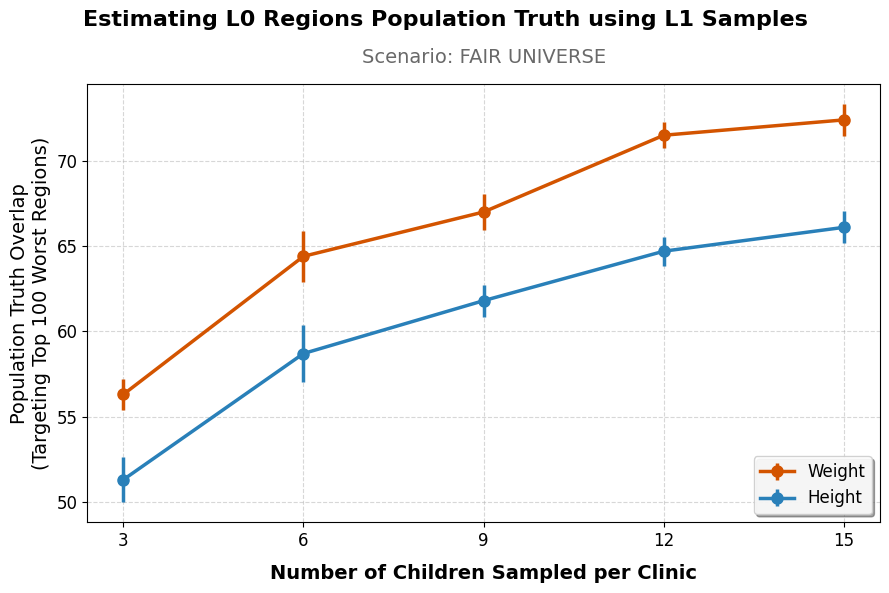


🌌 EVALUATING UNIVERSE: NORMAL
📁 Loading sensitivity_dataset_Normal_20260323_150757.parquet into memory...
⚓ Calculating the God-Mode Population Anchor...


Simulating Predictions (Normal): 100%|██████████| 5/5 [01:17<00:00, 15.56s/it]


✅ CSV Saved: c3_results_Normal_20260324_080317.csv
✅ Plot Saved: c3_plot_Normal_20260324_080317.png


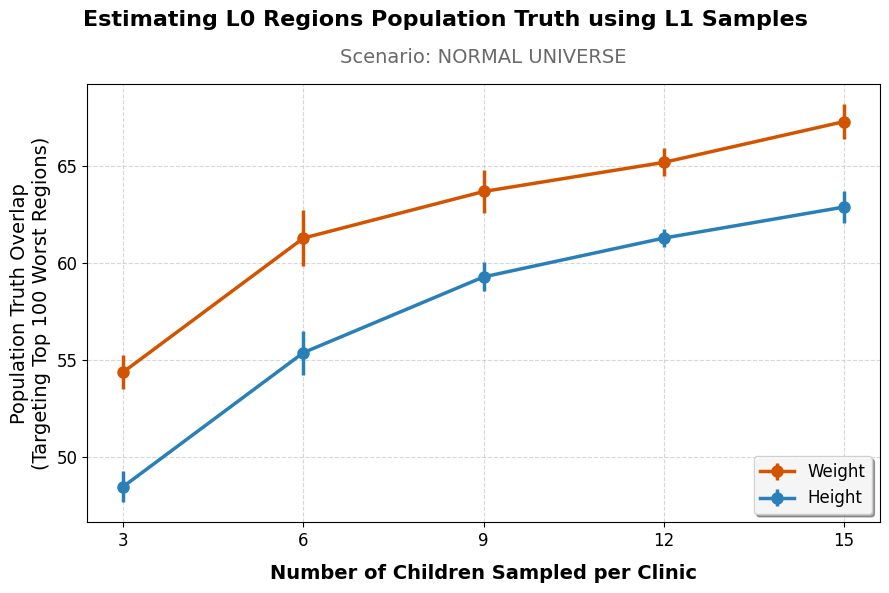


🌌 EVALUATING UNIVERSE: BAD
📁 Loading sensitivity_dataset_Bad_20260323_132920.parquet into memory...
⚓ Calculating the God-Mode Population Anchor...


Simulating Predictions (Bad): 100%|██████████| 5/5 [01:25<00:00, 17.18s/it]


✅ CSV Saved: c3_results_Bad_20260324_080444.csv
✅ Plot Saved: c3_plot_Bad_20260324_080444.png


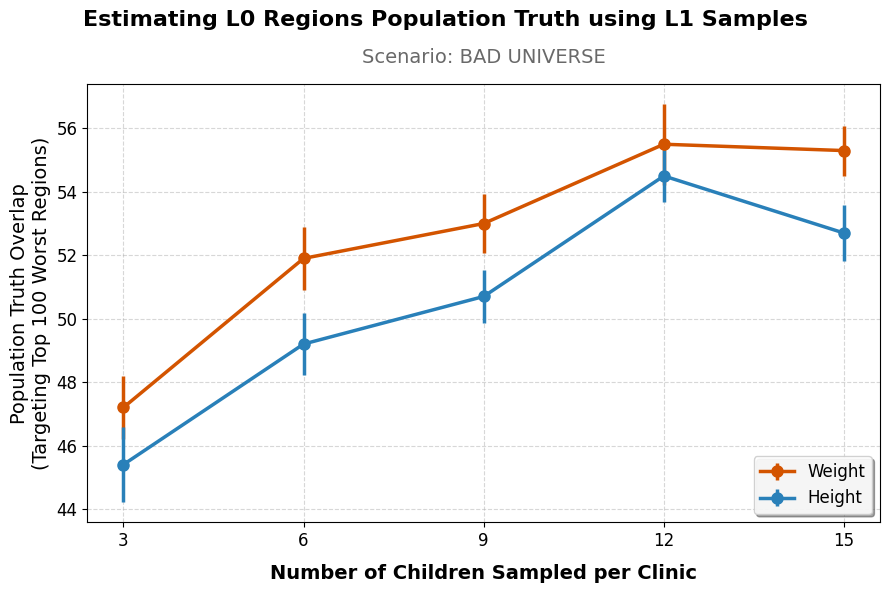


🌌 EVALUATING UNIVERSE: VERY BAD
📁 Loading sensitivity_dataset_Very_Bad_20260323_141221.parquet into memory...
⚓ Calculating the God-Mode Population Anchor...


Simulating Predictions (Very Bad): 100%|██████████| 5/5 [01:19<00:00, 15.97s/it]


✅ CSV Saved: c3_results_Very Bad_20260324_080606.csv
✅ Plot Saved: c3_plot_Very Bad_20260324_080606.png


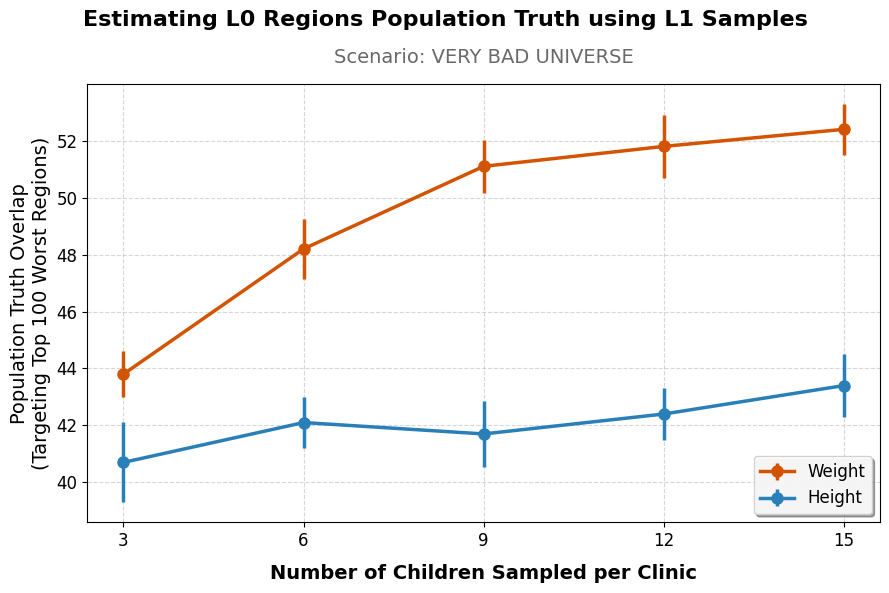

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os
from datetime import datetime

# ==============================================================================
# MASTER EVALUATION FUNCTION
# ==============================================================================
def evaluate_c3_universe(file_name, universe_name):
    if not os.path.exists(file_name):
        print(f"❌ Error: Cannot find '{file_name}'.")
        return

    print(f"\n{'='*80}")
    print(f"🌌 EVALUATING UNIVERSE: {universe_name.upper()}")
    print(f"{'='*80}")
    print(f"📁 Loading {file_name} into memory...")
    df = pd.read_parquet(file_name)

    # 1. SETUP THE C3 POPULATION ANCHOR
    # Adjusted to max 15 kids to match our new universe constraints!
    n_children_list = [3, 6, 9, 12, 15] 
    n_simulations = 10 
    target_count = 100  

    if 'true_fraud_haz' not in df.columns:
        df['true_fraud_haz'] = np.abs(df['real_haz'] - df['L0_haz'])
        df['true_fraud_waz'] = np.abs(df['real_waz'] - df['L0_waz'])
        df['measured_fraud_haz'] = np.abs(df['L1_haz'] - df['L0_haz'])
        df['measured_fraud_waz'] = np.abs(df['L1_waz'] - df['L0_waz'])

    print("⚓ Calculating the God-Mode Population Anchor...")
    pop_means = df.groupby('L1_id')[['true_fraud_haz', 'true_fraud_waz']].mean().reset_index()
    pop_means['pop_rank_ht'] = pop_means['true_fraud_haz'].rank(method='first', ascending=False)
    pop_means['pop_rank_wt'] = pop_means['true_fraud_waz'].rank(method='first', ascending=False)
    
    true_top_100_ht = set(pop_means[pop_means['pop_rank_ht'] <= target_count]['L1_id'])
    true_top_100_wt = set(pop_means[pop_means['pop_rank_wt'] <= target_count]['L1_id'])

    # 2. THE C3 PREDICTIVE ENGINE
    results = {'wt_real': [], 'ht_real': []} # Removed 'perf' tracking to match your final plotting code
    num_l1s = len(df['L1_id'].unique())
    
    for n_kids in tqdm(n_children_list, desc=f"Simulating Predictions ({universe_name})"):
        for _ in range(n_simulations):
            # Sample N kids
            df_sample = df.groupby(['L1_id', 'L0_id']).sample(n=n_kids, replace=True)
            
            # Get Means
            l0_means = df_sample.groupby(['L1_id', 'L0_id'])[['measured_fraud_haz', 'measured_fraud_waz']].mean().reset_index()
            l1_means = l0_means.groupby('L1_id')[['measured_fraud_haz', 'measured_fraud_waz']].mean().reset_index()
            
            # Rank
            l1_means['samp_rank_ht_meas'] = l1_means['measured_fraud_haz'].rank(method='first', ascending=False)
            l1_means['samp_rank_wt_meas'] = l1_means['measured_fraud_waz'].rank(method='first', ascending=False)
            
            # Overlap Logic
            flagged_ht_meas = set(l1_means[l1_means['samp_rank_ht_meas'] <= target_count]['L1_id'])
            ht_r_ov = len(flagged_ht_meas.intersection(true_top_100_ht))
            
            flagged_wt_meas = set(l1_means[l1_means['samp_rank_wt_meas'] <= target_count]['L1_id'])
            wt_r_ov = len(flagged_wt_meas.intersection(true_top_100_wt))
            
            results['ht_real'].append({'n_children_L1': n_kids, 'n_overlap': ht_r_ov})
            results['wt_real'].append({'n_children_L1': n_kids, 'n_overlap': wt_r_ov})

    res_c3 = {}
    for key in ['wt_real', 'ht_real']:
        temp = pd.DataFrame(results[key]).groupby('n_children_L1').agg(['mean', 'sem']).reset_index()
        temp.columns = ['n_children_L1', 'n_overlap_mean', 'n_overlap_sem']
        res_c3[key] = temp

    # 3. FORMAT & SAVE CSV
    df_ht_r = res_c3['ht_real'][['n_children_L1', 'n_overlap_mean']].rename(columns={'n_overlap_mean': 'Height_Reality'})
    df_wt_r = res_c3['wt_real'][['n_children_L1', 'n_overlap_mean']].rename(columns={'n_overlap_mean': 'Weight_Reality'})
    
    summary_df = df_ht_r.merge(df_wt_r, on='n_children_L1').round(1)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    csv_filename = f"c3_results_{universe_name}_{timestamp}.csv"
    summary_df.to_csv(csv_filename, index=False)
    print(f"✅ CSV Saved: {csv_filename}")

    # 4. PLOT THE C3 GRAPH (DYNAMICALLY TITLED)
    FONT_SIZE = 14
    fig, ax = plt.subplots(figsize=(9, 6), dpi=100)
    x = res_c3['wt_real']['n_children_L1']
    
    c_wt, c_ht = '#d35400', '#2980b9' 
    lw, ms = 2.5, 8
    
    ax.errorbar(x, res_c3['wt_real']['n_overlap_mean'], yerr=res_c3['wt_real']['n_overlap_sem'], 
                fmt='o-', color=c_wt, label='Weight', lw=lw, ms=ms)
    ax.errorbar(x, res_c3['ht_real']['n_overlap_mean'], yerr=res_c3['ht_real']['n_overlap_sem'], 
                fmt='o-', color=c_ht, label='Height', lw=lw, ms=ms)
    
    ax.set_xlabel('Number of Children Sampled per Clinic', fontsize=FONT_SIZE, fontweight='bold', labelpad=10)
    ax.set_ylabel(f'Population Truth Overlap\n(Targeting Top {target_count} Worst Regions)', fontsize=FONT_SIZE)
    ax.set_xticks(x)
    ax.tick_params(axis='both', labelsize=FONT_SIZE-2)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='lower right', fontsize=FONT_SIZE-2, framealpha=0.9, shadow=True)
    
    # Dynamic Titles
    plt.suptitle("Estimating L0 Regions Population Truth using L1 Samples", fontsize=FONT_SIZE+2, fontweight='bold')
    plt.title(f"Scenario: {universe_name.upper()} UNIVERSE", fontsize=FONT_SIZE, color='dimgrey', pad=15)
    
    plt.tight_layout()
    
    # Save the plot as an image too!
    plot_filename = f"c3_plot_{universe_name}_{timestamp}.png"
    plt.savefig(plot_filename, bbox_inches='tight')
    print(f"✅ Plot Saved: {plot_filename}")
    plt.show()

# ==============================================================================
# EXECUTION BLOCK (Update these filenames to match exactly what you generated!)
# ==============================================================================
# Example filenames: 'sensitivity_dataset_Good_20260323_151116.parquet'
datasets_to_run = {
    "Good": "sensitivity_dataset_Good_20260323_151116.parquet",
    "Fair": "sensitivity_dataset_Fair_20260323_115454.parquet",
    "Normal": "sensitivity_dataset_Normal_20260323_150757.parquet",
    "Bad": "sensitivity_dataset_Bad_20260323_132920.parquet",
    "Very Bad": "sensitivity_dataset_Very_Bad_20260323_141221.parquet"
}

for name, file_path in datasets_to_run.items():
    evaluate_c3_universe(file_path, name)

🚀 INITIATING MASTER EVALUATION ENGINE...

⚙️ Simulating GOOD Universe...


⚙️ Simulating FAIR Universe...


⚙️ Simulating NORMAL Universe...


⚙️ Simulating BAD Universe...


⚙️ Simulating VERY BAD Universe...



✅ EXCEL SAVED: MASTER_evaluation_results_20260324_130728.xlsx
📊 Generating 3x2 Master Layout Plot...
✅ PLOT SAVED: MASTER_3x2_Layout_Plot_20260324_130728.png


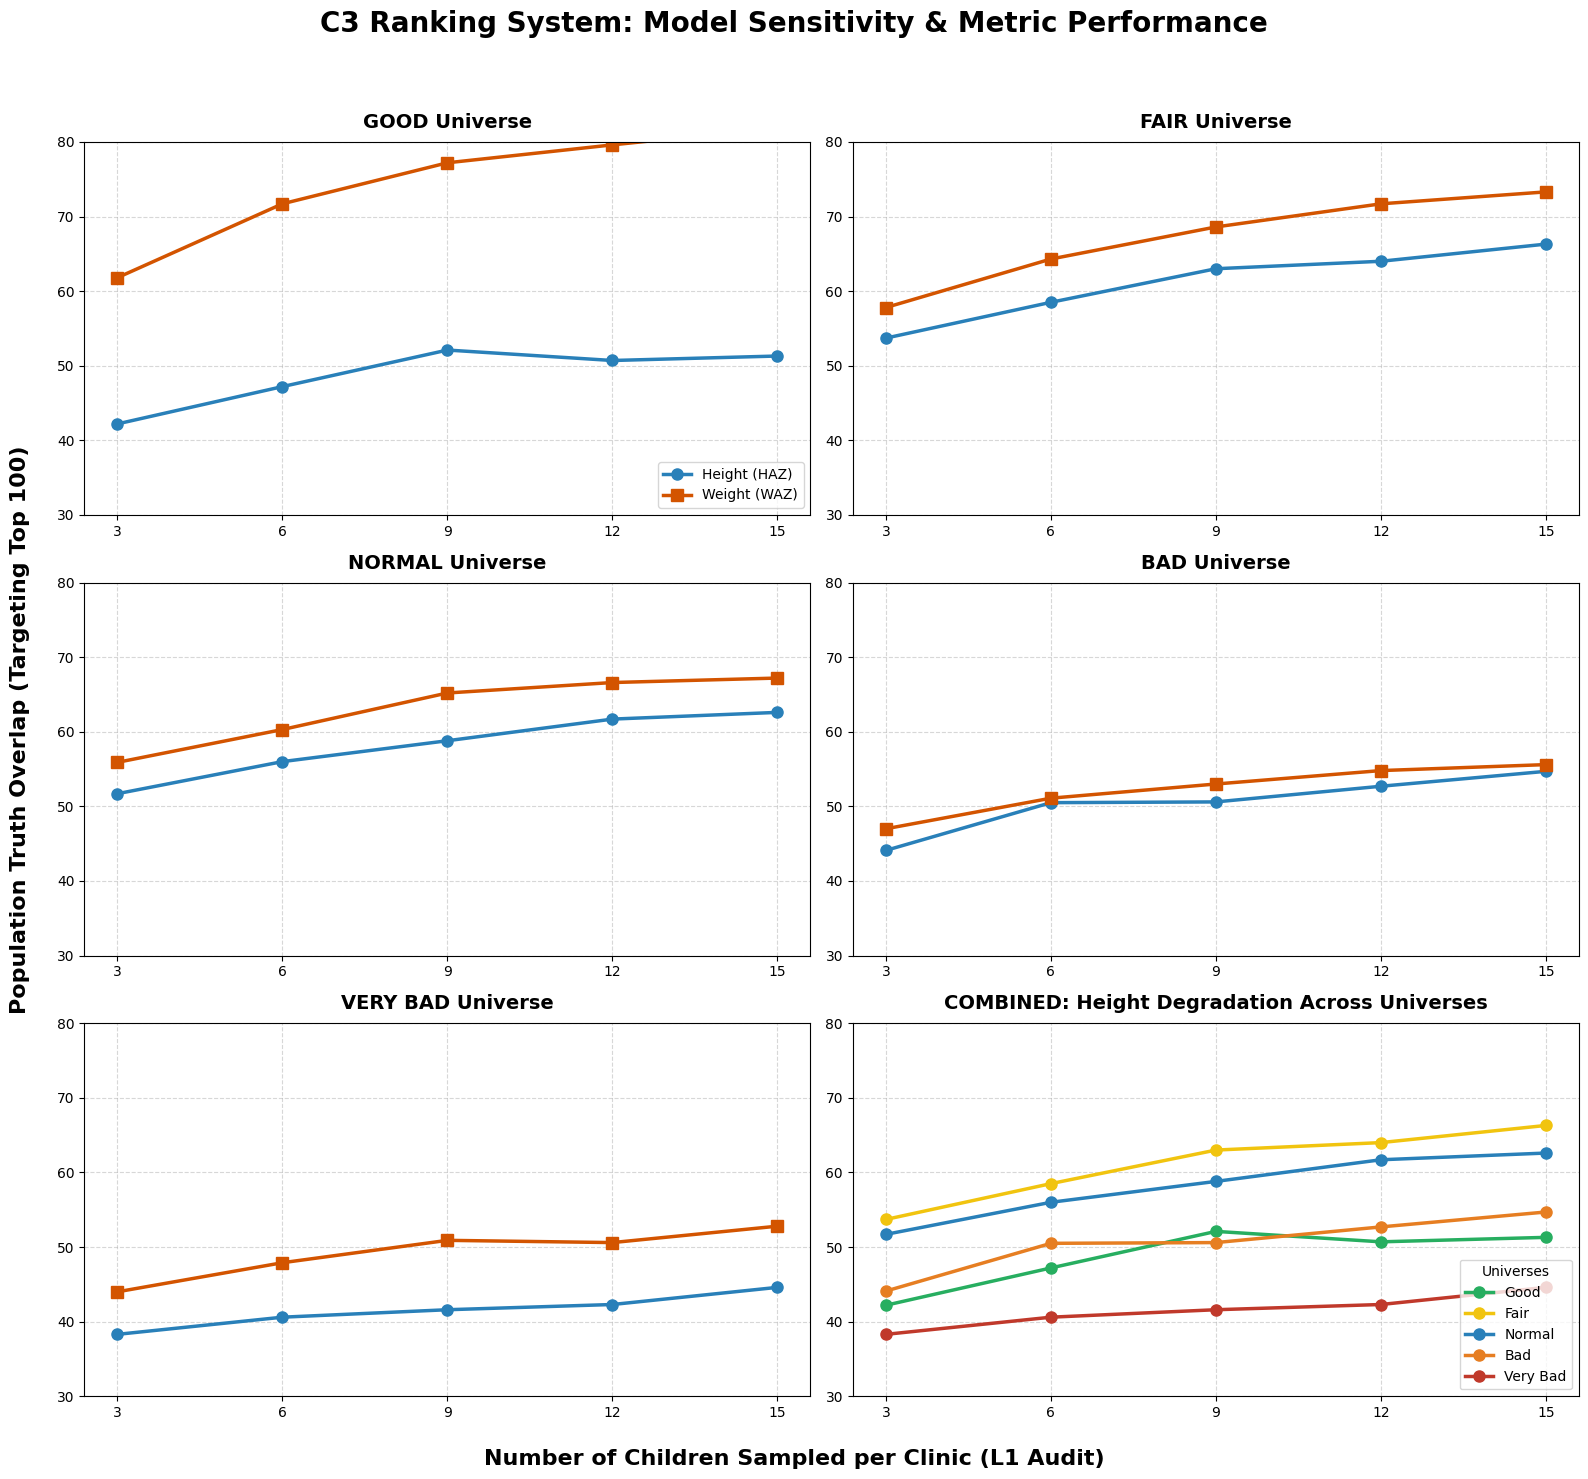

In [ ]:
# okay, passable p1 code, but skip.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os
from datetime import datetime

# ==============================================================================
# 1. SETUP THE FILES & COLORS
# ==============================================================================
datasets_to_run = {
    "Good": "sensitivity_dataset_TRUE_Good_20260324_100502.parquet", # <-- YOUR NEW TRUE GOOD FILE
    "Fair": "sensitivity_dataset_Fair_20260323_115454.parquet",
    "Normal": "sensitivity_dataset_Normal_20260323_150757.parquet",
    "Bad": "sensitivity_dataset_Bad_20260323_132920.parquet",
    "Very Bad": "sensitivity_dataset_Very_Bad_20260323_141221.parquet"
}

uni_colors = {
    "Good": "#27ae60",     # Green
    "Fair": "#f1c40f",     # Yellow
    "Normal": "#2980b9",   # Blue
    "Bad": "#e67e22",      # Orange
    "Very Bad": "#c0392b"  # Red
}

n_children_list = [3, 6, 9, 12, 15] 
n_simulations = 10 
target_count = 100  

master_results = []
plot_data = {}

print("🚀 INITIATING MASTER EVALUATION ENGINE...\n")

# ==============================================================================
# 2. RUN THE ENGINE (HEIGHT & WEIGHT, L1 & L2)
# ==============================================================================
for universe_name, file_name in datasets_to_run.items():
    if not os.path.exists(file_name):
        print(f"❌ Error: Cannot find '{file_name}'. Skipping...")
        continue

    print(f"⚙️ Simulating {universe_name.upper()} Universe...")
    df = pd.read_parquet(file_name)

    # Calculate all fraud discrepancies
    df['true_fraud_haz'] = np.abs(df['real_haz'] - df['L0_haz'])
    df['true_fraud_waz'] = np.abs(df['real_waz'] - df['L0_waz'])
    
    df['meas_fraud_haz_L1'] = np.abs(df['L1_haz'] - df['L0_haz'])
    df['meas_fraud_waz_L1'] = np.abs(df['L1_waz'] - df['L0_waz'])
    
    df['meas_fraud_haz_L2'] = np.abs(df['L2_haz'] - df['L0_haz'])
    df['meas_fraud_waz_L2'] = np.abs(df['L2_waz'] - df['L0_waz'])

    # Population Anchor
    pop_means = df.groupby('L1_id')[['true_fraud_haz', 'true_fraud_waz']].mean().reset_index()
    pop_means['pop_rank_ht'] = pop_means['true_fraud_haz'].rank(method='first', ascending=False)
    pop_means['pop_rank_wt'] = pop_means['true_fraud_waz'].rank(method='first', ascending=False)
    true_top_100_ht = set(pop_means[pop_means['pop_rank_ht'] <= target_count]['L1_id'])
    true_top_100_wt = set(pop_means[pop_means['pop_rank_wt'] <= target_count]['L1_id'])

    # Sampling Loop
    overlap_results = []
    for n_kids in tqdm(n_children_list, desc=f"   Sampling", leave=False):
        for _ in range(n_simulations):
            df_sample = df.groupby(['L1_id', 'L0_id']).sample(n=n_kids, replace=True)
            
            # Aggregate L1 and L2 means
            l0_means = df_sample.groupby(['L1_id', 'L0_id'])[['meas_fraud_haz_L1', 'meas_fraud_waz_L1', 'meas_fraud_haz_L2', 'meas_fraud_waz_L2']].mean().reset_index()
            l1_means = l0_means.groupby('L1_id')[['meas_fraud_haz_L1', 'meas_fraud_waz_L1', 'meas_fraud_haz_L2', 'meas_fraud_waz_L2']].mean().reset_index()
            
            # Rank
            l1_means['rank_ht_L1'] = l1_means['meas_fraud_haz_L1'].rank(method='first', ascending=False)
            l1_means['rank_wt_L1'] = l1_means['meas_fraud_waz_L1'].rank(method='first', ascending=False)
            l1_means['rank_ht_L2'] = l1_means['meas_fraud_haz_L2'].rank(method='first', ascending=False)
            l1_means['rank_wt_L2'] = l1_means['meas_fraud_waz_L2'].rank(method='first', ascending=False)
            
            # Overlaps
            ov_ht_L1 = len(set(l1_means[l1_means['rank_ht_L1'] <= target_count]['L1_id']).intersection(true_top_100_ht))
            ov_wt_L1 = len(set(l1_means[l1_means['rank_wt_L1'] <= target_count]['L1_id']).intersection(true_top_100_wt))
            ov_ht_L2 = len(set(l1_means[l1_means['rank_ht_L2'] <= target_count]['L1_id']).intersection(true_top_100_ht))
            ov_wt_L2 = len(set(l1_means[l1_means['rank_wt_L2'] <= target_count]['L1_id']).intersection(true_top_100_wt))
            
            overlap_results.append({
                'Universe': universe_name, 'Sample_Size': n_kids,
                'L1_Ht_Overlap': ov_ht_L1, 'L1_Wt_Overlap': ov_wt_L1,
                'L2_Ht_Overlap': ov_ht_L2, 'L2_Wt_Overlap': ov_wt_L2
            })

    # Group and Average for this universe
    temp_df = pd.DataFrame(overlap_results)
    agg_df = temp_df.groupby(['Universe', 'Sample_Size']).mean().reset_index().round(1)
    
    master_results.append(agg_df)
    plot_data[universe_name] = agg_df

# ==============================================================================
# 3. SAVE TO EXCEL
# ==============================================================================
final_excel_df = pd.concat(master_results, ignore_index=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
excel_filename = f"MASTER_evaluation_results_{timestamp}.xlsx"

final_excel_df.to_excel(excel_filename, index=False)
print(f"\n✅ EXCEL SAVED: {excel_filename}")

# ==============================================================================
# 4. PLOT THE 3x2 MASTER GRID
# ==============================================================================
print("📊 Generating 3x2 Master Layout Plot...")
fig, axes = plt.subplots(3, 2, figsize=(16, 15), dpi=100)
axes = axes.flatten()

# Y-Axis limit applied universally so changes are obvious
Y_MIN, Y_MAX = 30, 80
lw, ms = 2.5, 8
metric_colors = {'Height': '#2980b9', 'Weight': '#d35400'} # Blue and Orange

# Plots 1 to 5: Individual Universes (Height vs Weight L1)
universes = list(datasets_to_run.keys())

for i, uni in enumerate(universes):
    ax = axes[i]
    data = plot_data[uni]
    
    ax.plot(data['Sample_Size'], data['L1_Ht_Overlap'], marker='o', color=metric_colors['Height'], label='Height (HAZ)', lw=lw, ms=ms)
    ax.plot(data['Sample_Size'], data['L1_Wt_Overlap'], marker='s', color=metric_colors['Weight'], label='Weight (WAZ)', lw=lw, ms=ms)
    
    ax.set_title(f"{uni.upper()} Universe", fontsize=14, fontweight='bold', pad=10)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_xticks(n_children_list)
    ax.grid(True, linestyle='--', alpha=0.5)
    if i == 0: ax.legend(loc='lower right')

# Plot 6: Combined Height Sensitivity Waterfall
ax_comb = axes[5]
for uni in universes:
    data = plot_data[uni]
    ax_comb.plot(data['Sample_Size'], data['L1_Ht_Overlap'], marker='o', color=uni_colors[uni], label=uni, lw=lw, ms=ms)

ax_comb.set_title("COMBINED: Height Degradation Across Universes", fontsize=14, fontweight='bold', pad=10)
ax_comb.set_ylim(Y_MIN, Y_MAX)
ax_comb.set_xticks(n_children_list)
ax_comb.grid(True, linestyle='--', alpha=0.5)
ax_comb.legend(title='Universes', loc='lower right')

# Add global labels and adjust layout
fig.text(0.5, 0.01, 'Number of Children Sampled per Clinic (L1 Audit)', ha='center', fontsize=16, fontweight='bold')
fig.text(0.01, 0.5, f'Population Truth Overlap (Targeting Top {target_count})', va='center', rotation='vertical', fontsize=16, fontweight='bold')

plt.suptitle("C3 Ranking System: Model Sensitivity & Metric Performance", fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0.03, 0.03, 1, 0.95]) # Make room for global labels

plot_filename = f"MASTER_3x2_Layout_Plot_{timestamp}.png"
plt.savefig(plot_filename, bbox_inches='tight')
print(f"✅ PLOT SAVED: {plot_filename}")
plt.show()

In [16]:
import pandas as pd
import glob
import os

# ==============================================================================
# 1. LOAD THE LATEST EXCEL FILE
# ==============================================================================
# Find the most recent MASTER_evaluation_results Excel file
excel_files = glob.glob("MASTER_evaluation_results_*.xlsx")
latest_excel = max(excel_files, key=os.path.getctime)

print(f"📊 LOADING EXCEL: {latest_excel}\n")
df_results = pd.read_excel(latest_excel)

# Filter for just the 15-children sample size
df_15 = df_results[df_results['Sample_Size'] == 15].copy()

print("="*80)
print("🎯 C3 MODEL OVERLAP ACCURACY (At 15 Children Sampled)")
print("="*80)
# Reorder to match our logical progression
uni_order = ['Good', 'Fair', 'Normal', 'Bad', 'Very Bad']
df_15['Universe'] = pd.Categorical(df_15['Universe'], categories=uni_order, ordered=True)
df_15 = df_15.sort_values('Universe')

print(df_15[['Universe', 'L1_Ht_Overlap', 'L2_Ht_Overlap', 'L1_Wt_Overlap', 'L2_Wt_Overlap']].to_string(index=False))
print("="*80 + "\n")


# ==============================================================================
# 2. RE-VERIFY THE PARQUET FILES (The Physics Check)
# ==============================================================================
datasets_to_verify = {
    "Good": "sensitivity_dataset_TRUE_Good_20260324_100502.parquet", # Update timestamp if needed!
    "Fair": "sensitivity_dataset_Fair_20260323_115454.parquet",
    "Normal": "sensitivity_dataset_Normal_20260323_150757.parquet",
    "Bad": "sensitivity_dataset_Bad_20260323_132920.parquet",
    "Very Bad": "sensitivity_dataset_Very_Bad_20260323_141221.parquet"
}

print("="*80)
print("🕵️‍♂️ PARQUET SANITY CHECK (Biology & Fraud Targets)")
print("="*80)
results = []
for name, file_path in datasets_to_verify.items():
    if not os.path.exists(file_path):
        continue
    df = pd.read_parquet(file_path)
    
    stunting_rate = (df['real_haz'] < -2.0).mean() * 100
    l0_fraud = df['percent_under_reporting_stunting'].mean() if 'percent_under_reporting_stunting' in df.columns else float('nan')
    l1_copy = df['percent_copy'].mean() if 'percent_copy' in df.columns else float('nan')
        
    results.append({
        "Universe": name,
        "True Stunting": f"{stunting_rate:.1f}%",
        "Worker Fraud": f"{l0_fraud:.1f}%",
        "Supervisor Ghosting": f"{l1_copy:.1f}%"
    })

print(pd.DataFrame(results).to_string(index=False))
print("="*80)

📊 LOADING EXCEL: MASTER_evaluation_results_20260324_130728.xlsx

🎯 C3 MODEL OVERLAP ACCURACY (At 15 Children Sampled)
Universe  L1_Ht_Overlap  L2_Ht_Overlap  L1_Wt_Overlap  L2_Wt_Overlap
    Good           51.3           53.6           81.9           82.5
    Fair           66.3           69.3           73.3           73.9
  Normal           62.6           69.9           67.2           78.6
     Bad           54.7           69.4           55.6           75.0
Very Bad           44.6           64.4           52.8           77.8

🕵️‍♂️ PARQUET SANITY CHECK (Biology & Fraud Targets)
Universe True Stunting Worker Fraud Supervisor Ghosting
    Good         15.0%         5.3%                3.5%
    Fair         25.0%        19.5%               10.2%
  Normal         36.1%        29.6%               19.8%
     Bad         40.0%        34.3%               35.0%
Very Bad         44.9%        39.6%               49.7%


In [17]:
import pandas as pd
import numpy as np

# Load just the Good and Fair universes to prove the point
df_good = pd.read_parquet("sensitivity_dataset_TRUE_Good_20260324_100502.parquet")
df_fair = pd.read_parquet("sensitivity_dataset_Fair_20260323_115454.parquet")

def calculate_signal_correlation(df, universe_name):
    # 1. Calculate the core metrics
    df['true_fraud_ht'] = np.abs(df['real_haz'] - df['L0_haz'])
    df['meas_fraud_ht'] = np.abs(df['L1_haz'] - df['L0_haz'])
    
    df['true_fraud_wt'] = np.abs(df['real_waz'] - df['L0_waz'])
    df['meas_fraud_wt'] = np.abs(df['L1_waz'] - df['L0_waz'])

    # 2. Aggregate to the L1 Level (This is how the C3 model ranks regions)
    l1_agg = df.groupby('L1_id')[['true_fraud_ht', 'meas_fraud_ht', 'true_fraud_wt', 'meas_fraud_wt']].mean()

    # 3. Calculate Pearson Correlation (1.0 is perfect mapping, 0.0 is pure random noise)
    corr_ht = l1_agg['true_fraud_ht'].corr(l1_agg['meas_fraud_ht'])
    corr_wt = l1_agg['true_fraud_wt'].corr(l1_agg['meas_fraud_wt'])
    
    return corr_ht, corr_wt

# Get the numbers
good_ht_corr, good_wt_corr = calculate_signal_correlation(df_good, "Good")
fair_ht_corr, fair_wt_corr = calculate_signal_correlation(df_fair, "Fair")

# Print the final proof
print("="*80)
print("🎯 MATHEMATICAL PROOF: SIGNAL VS. NOISE (PEARSON CORRELATION)")
print("="*80)
print(f"GOOD UNIVERSE - Height Correlation (High Noise, Low Fraud) : {good_ht_corr:.3f}")
print(f"GOOD UNIVERSE - Weight Correlation (Low Noise, Low Fraud)  : {good_wt_corr:.3f}")
print("-" * 80)
print(f"FAIR UNIVERSE - Height Correlation (High Noise, HIGH Fraud): {fair_ht_corr:.3f}")
print("="*80)

🎯 MATHEMATICAL PROOF: SIGNAL VS. NOISE (PEARSON CORRELATION)
GOOD UNIVERSE - Height Correlation (High Noise, Low Fraud) : 0.693
GOOD UNIVERSE - Weight Correlation (Low Noise, Low Fraud)  : 0.970
--------------------------------------------------------------------------------
FAIR UNIVERSE - Height Correlation (High Noise, HIGH Fraud): 0.841


📊 LOADING EXCEL: MASTER_evaluation_results_20260324_130728.xlsx

📊 Generating L2 Auditor Master Layout Plot...
✅ PLOT SAVED: MASTER_3x2_Layout_Plot_L2_130728.png


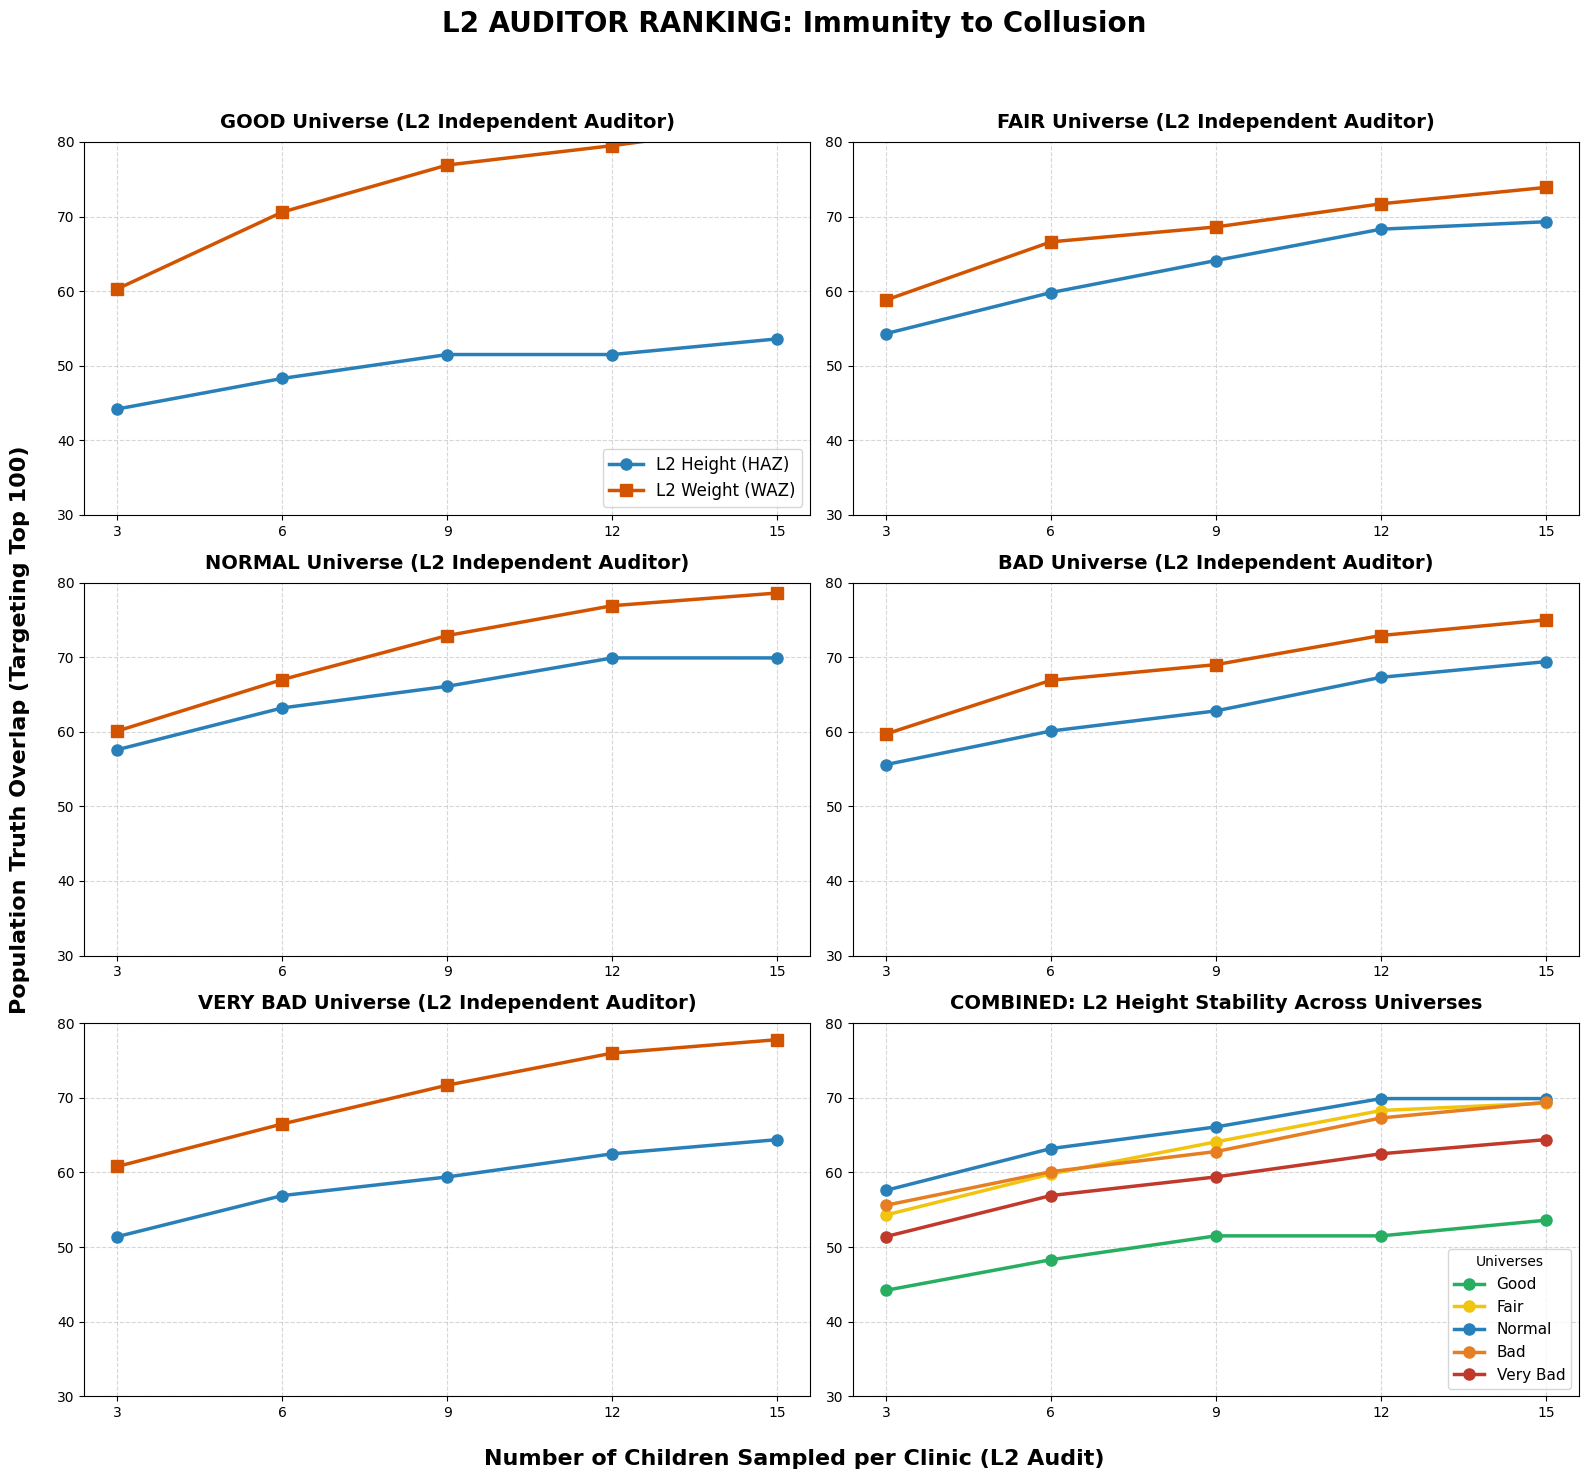

In [ ]:
# plot 1 code actually no tnecessary
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Find the most recent MASTER_evaluation_results Excel file
excel_files = glob.glob("MASTER_evaluation_results_*.xlsx")
latest_excel = max(excel_files, key=os.path.getctime)

print(f"📊 LOADING EXCEL: {latest_excel}\n")
final_excel_df = pd.read_excel(latest_excel)

# ==============================================================================
# 1. SETUP PLOT STYLING
# ==============================================================================
uni_colors = {
    "Good": "#27ae60",     # Green
    "Fair": "#f1c40f",     # Yellow
    "Normal": "#2980b9",   # Blue
    "Bad": "#e67e22",      # Orange
    "Very Bad": "#c0392b"  # Red
}

metric_colors = {'Height': '#2980b9', 'Weight': '#d35400'} # Blue and Orange
n_children_list = [3, 6, 9, 12, 15] 
target_count = 100

fig, axes = plt.subplots(3, 2, figsize=(16, 15), dpi=100)
axes = axes.flatten()

# Lock Y-Axis to the same 30-80 scale for perfect 1:1 comparison with the L1 chart
Y_MIN, Y_MAX = 30, 80
lw, ms = 2.5, 8
universes = list(uni_colors.keys())

print("📊 Generating L2 Auditor Master Layout Plot...")

# ==============================================================================
# 2. PLOT PANELS 1-5 (L2 Height vs Weight per Universe)
# ==============================================================================
for i, uni in enumerate(universes):
    ax = axes[i]
    data = final_excel_df[final_excel_df['Universe'] == uni]
    
    # WE ARE NOW PLOTTING L2 (Auditor)
    ax.plot(data['Sample_Size'], data['L2_Ht_Overlap'], marker='o', color=metric_colors['Height'], label='L2 Height (HAZ)', lw=lw, ms=ms)
    ax.plot(data['Sample_Size'], data['L2_Wt_Overlap'], marker='s', color=metric_colors['Weight'], label='L2 Weight (WAZ)', lw=lw, ms=ms)
    
    ax.set_title(f"{uni.upper()} Universe (L2 Independent Auditor)", fontsize=14, fontweight='bold', pad=10)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_xticks(n_children_list)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    if i == 0: 
        ax.legend(loc='lower right', fontsize=12)

# ==============================================================================
# 3. PLOT PANEL 6 (Combined L2 Height Stability)
# ==============================================================================
ax_comb = axes[5]
for uni in universes:
    data = final_excel_df[final_excel_df['Universe'] == uni]
    ax_comb.plot(data['Sample_Size'], data['L2_Ht_Overlap'], marker='o', color=uni_colors[uni], label=uni, lw=lw, ms=ms)

ax_comb.set_title("COMBINED: L2 Height Stability Across Universes", fontsize=14, fontweight='bold', pad=10)
ax_comb.set_ylim(Y_MIN, Y_MAX)
ax_comb.set_xticks(n_children_list)
ax_comb.grid(True, linestyle='--', alpha=0.5)
ax_comb.legend(title='Universes', loc='lower right', fontsize=11)

# ==============================================================================
# 4. FINAL LAYOUT & SAVE
# ==============================================================================
fig.text(0.5, 0.01, 'Number of Children Sampled per Clinic (L2 Audit)', ha='center', fontsize=16, fontweight='bold')
fig.text(0.01, 0.5, f'Population Truth Overlap (Targeting Top {target_count})', va='center', rotation='vertical', fontsize=16, fontweight='bold')

plt.suptitle("L2 AUDITOR RANKING: Immunity to Collusion", fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0.03, 0.03, 1, 0.95]) 

# Save with a distinct L2 filename using the timestamp from the excel file
timestamp = latest_excel.split('_')[-1].replace('.xlsx', '')
plot_filename = f"MASTER_3x2_Layout_Plot_L2_{timestamp}.png"
plt.savefig(plot_filename, bbox_inches='tight')
print(f"✅ PLOT SAVED: {plot_filename}")
plt.show()

In [19]:
import pandas as pd
import glob
import os

# ==============================================================================
# 1. LOAD THE LATEST EXCEL FILE
# ==============================================================================
excel_files = glob.glob("MASTER_evaluation_results_*.xlsx")
if not excel_files:
    print("❌ No Excel files found in the current directory.")
else:
    latest_excel = max(excel_files, key=os.path.getctime)
    print(f"📊 LOADING EXCEL: {latest_excel}\n")
    df_results = pd.read_excel(latest_excel)

    # Filter for just the 15-children sample size benchmark
    df_15 = df_results[df_results['Sample_Size'] == 15].copy()

    # Reorder to match our logical progression
    uni_order = ['Good', 'Fair', 'Normal', 'Bad', 'Very Bad']
    df_15['Universe'] = pd.Categorical(df_15['Universe'], categories=uni_order, ordered=True)
    df_15 = df_15.sort_values('Universe')

    # Calculate the exact difference (L2 Advantage over L1)
    df_15['Ht_L2_Advantage'] = df_15['L2_Ht_Overlap'] - df_15['L1_Ht_Overlap']
    df_15['Wt_L2_Advantage'] = df_15['L2_Wt_Overlap'] - df_15['L1_Wt_Overlap']

    # Format the tables for printing
    print("="*90)
    print("📏 HEIGHT ACCURACY: L1 SUPERVISOR vs L2 AUDITOR (15 Children Sampled)")
    print("="*90)
    ht_df = df_15[['Universe', 'L1_Ht_Overlap', 'L2_Ht_Overlap', 'Ht_L2_Advantage']].copy()
    ht_df.columns = ['Universe', 'L1 (Collusion Risk)', 'L2 (Independent)', 'L2 Advantage Gap']
    print(ht_df.to_string(index=False))
    print("\n")

    print("="*90)
    print("⚖️ WEIGHT ACCURACY: L1 SUPERVISOR vs L2 AUDITOR (15 Children Sampled)")
    print("="*90)
    wt_df = df_15[['Universe', 'L1_Wt_Overlap', 'L2_Wt_Overlap', 'Wt_L2_Advantage']].copy()
    wt_df.columns = ['Universe', 'L1 (Collusion Risk)', 'L2 (Independent)', 'L2 Advantage Gap']
    print(wt_df.to_string(index=False))
    print("="*90)

📊 LOADING EXCEL: MASTER_evaluation_results_20260324_130728.xlsx

📏 HEIGHT ACCURACY: L1 SUPERVISOR vs L2 AUDITOR (15 Children Sampled)
Universe  L1 (Collusion Risk)  L2 (Independent)  L2 Advantage Gap
    Good                 51.3              53.6               2.3
    Fair                 66.3              69.3               3.0
  Normal                 62.6              69.9               7.3
     Bad                 54.7              69.4              14.7
Very Bad                 44.6              64.4              19.8


⚖️ WEIGHT ACCURACY: L1 SUPERVISOR vs L2 AUDITOR (15 Children Sampled)
Universe  L1 (Collusion Risk)  L2 (Independent)  L2 Advantage Gap
    Good                 81.9              82.5               0.6
    Fair                 73.3              73.9               0.6
  Normal                 67.2              78.6              11.4
     Bad                 55.6              75.0              19.4
Very Bad                 52.8              77.8              25.0


In [20]:
import pandas as pd
import glob
import os

# ==============================================================================
# 1. LOAD THE LATEST EXCEL FILE
# ==============================================================================
excel_files = glob.glob("MASTER_evaluation_results_*.xlsx")
if not excel_files:
    print("❌ No Excel files found in the current directory.")
else:
    latest_excel = max(excel_files, key=os.path.getctime)
    print(f"📊 LOADING EXCEL: {latest_excel}\n")
    df_results = pd.read_excel(latest_excel)

    # Filter for just the 15-children sample size benchmark
    df_15 = df_results[df_results['Sample_Size'] == 15].copy()

    # Reorder to match our logical progression
    uni_order = ['Good', 'Fair', 'Normal', 'Bad', 'Very Bad']
    df_15['Universe'] = pd.Categorical(df_15['Universe'], categories=uni_order, ordered=True)
    df_15 = df_15.sort_values('Universe')

    # ==============================================================================
    # 2. CALCULATE RELATIVE LIFT
    # Formula: ((L2 - L1) / L1) * 100
    # ==============================================================================
    df_15['Ht_Lift'] = ((df_15['L2_Ht_Overlap'] - df_15['L1_Ht_Overlap']) / df_15['L1_Ht_Overlap']) * 100
    df_15['Wt_Lift'] = ((df_15['L2_Wt_Overlap'] - df_15['L1_Wt_Overlap']) / df_15['L1_Wt_Overlap']) * 100

    # Format beautifully with a '+' sign and percentage
    df_15['Ht_Lift_Str'] = df_15['Ht_Lift'].apply(lambda x: f"+{x:.1f}%" if x > 0 else f"{x:.1f}%")
    df_15['Wt_Lift_Str'] = df_15['Wt_Lift'].apply(lambda x: f"+{x:.1f}%" if x > 0 else f"{x:.1f}%")

    # ==============================================================================
    # 3. PRINT FORMATTED TABLES
    # ==============================================================================
    print("="*90)
    print("📏 HEIGHT ACCURACY: L1 SUPERVISOR vs L2 AUDITOR (15 Children Sampled)")
    print("="*90)
    ht_df = df_15[['Universe', 'L1_Ht_Overlap', 'L2_Ht_Overlap', 'Ht_Lift_Str']].copy()
    ht_df.columns = ['Universe', 'L1 (Collusion Risk)', 'L2 (Independent)', 'Relative Lift (L2 vs L1)']
    print(ht_df.to_string(index=False))
    print("\n")

    print("="*90)
    print("⚖️ WEIGHT ACCURACY: L1 SUPERVISOR vs L2 AUDITOR (15 Children Sampled)")
    print("="*90)
    wt_df = df_15[['Universe', 'L1_Wt_Overlap', 'L2_Wt_Overlap', 'Wt_Lift_Str']].copy()
    wt_df.columns = ['Universe', 'L1 (Collusion Risk)', 'L2 (Independent)', 'Relative Lift (L2 vs L1)']
    print(wt_df.to_string(index=False))
    print("="*90)

📊 LOADING EXCEL: MASTER_evaluation_results_20260324_130728.xlsx

📏 HEIGHT ACCURACY: L1 SUPERVISOR vs L2 AUDITOR (15 Children Sampled)
Universe  L1 (Collusion Risk)  L2 (Independent) Relative Lift (L2 vs L1)
    Good                 51.3              53.6                    +4.5%
    Fair                 66.3              69.3                    +4.5%
  Normal                 62.6              69.9                   +11.7%
     Bad                 54.7              69.4                   +26.9%
Very Bad                 44.6              64.4                   +44.4%


⚖️ WEIGHT ACCURACY: L1 SUPERVISOR vs L2 AUDITOR (15 Children Sampled)
Universe  L1 (Collusion Risk)  L2 (Independent) Relative Lift (L2 vs L1)
    Good                 81.9              82.5                    +0.7%
    Fair                 73.3              73.9                    +0.8%
  Normal                 67.2              78.6                   +17.0%
     Bad                 55.6              75.0                 

✅ PLOT SAVED: Standalone_L1_Height_Final_130728.png


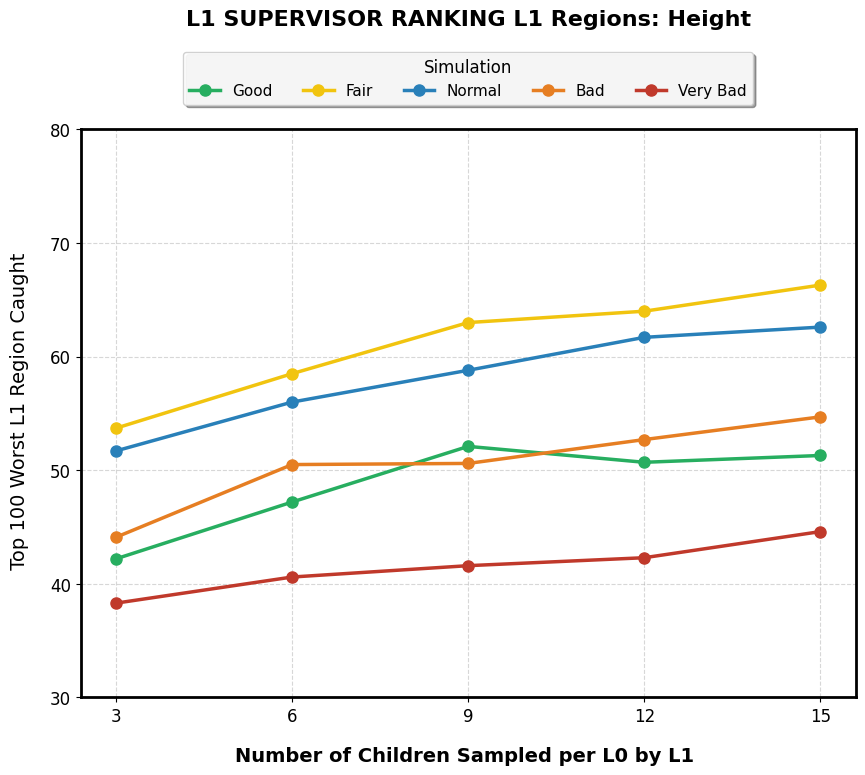

In [52]:
# Plot 1 Sensitivity Chart: L1 Height Overlap Across Universes (Standalone Template)
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# ==============================================================================
# 1. LOAD THE LATEST EXCEL FILE
# ==============================================================================
excel_files = glob.glob("MASTER_evaluation_results_*.xlsx")
latest_excel = max(excel_files, key=os.path.getctime)
final_excel_df = pd.read_excel(latest_excel)

# ==============================================================================
# 2. PLOT THE STANDALONE L1 HEIGHT UNIVERSES
# ==============================================================================
uni_colors = {
    "Good": "#27ae60", "Fair": "#f1c40f", "Normal": "#2980b9", 
    "Bad": "#e67e22", "Very Bad": "#c0392b"
}

target_count = 100 
FONT_SIZE = 14
lw, ms = 2.5, 8
border_thickness = 2.0

# Increased figure height slightly to make room for the "stack" at the top
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
universes = list(uni_colors.keys())

for uni in universes:
    data = final_excel_df[final_excel_df['Universe'] == uni]
    ax.plot(data['Sample_Size'], data['L1_Ht_Overlap'], 
            marker='o', linestyle='-', color=uni_colors[uni], 
            label=uni, lw=lw, ms=ms)

# Styling
ax.set_xlabel('Number of Children Sampled per L0 by L1 ', fontsize=FONT_SIZE, fontweight='bold', labelpad=15)
ax.set_ylabel(f' Top {target_count} Worst L1 Region Caught', fontsize=FONT_SIZE, labelpad=15)
ax.set_xticks(final_excel_df['Sample_Size'].unique())
ax.set_ylim(30, 80)
ax.tick_params(axis='both', labelsize=FONT_SIZE-2)
ax.grid(True, linestyle='--', alpha=0.5)

# --- BOLD BORDERS ---
for spine in ax.spines.values():
    spine.set_linewidth(border_thickness)
    spine.set_color('black')

# --- EXTERNAL TOP LEGEND (FIXED OVERLAP) ---
# Increased Y to 1.15 to clear the border completely
ax.legend(title='Simulation', bbox_to_anchor=(0.5, 1.15), loc='upper center', 
          ncol=5, fontsize=FONT_SIZE-3, framealpha=0.9, shadow=True, title_fontsize=FONT_SIZE-2)

# title pad=70 pushes the title even higher to make room for the floating legend
plt.title("L1 SUPERVISOR RANKING L1 Regions: Height", 
          fontsize=FONT_SIZE+2, fontweight='bold', pad=75)

# --- CRITICAL FIX: Manual margin adjustment ---
# top=0.85 shrinks the plot area slightly from the top to create a "safe zone" for the legend/title
plt.subplots_adjust(top=0.82) 

timestamp = latest_excel.split('_')[-1].replace('.xlsx', '')
plot_filename = f"Standalone_L1_Height_Final_{timestamp}.png"
plt.savefig(plot_filename, bbox_inches='tight')

print(f"✅ PLOT SAVED: {plot_filename}")
plt.show()

🚀 INITIATING MASTER EVALUATION ENGINE...

⚙️ Simulating GOOD Universe...


⚙️ Simulating FAIR Universe...


⚙️ Simulating NORMAL Universe...


⚙️ Simulating BAD Universe...


⚙️ Simulating VERY BAD Universe...



✅ EXCEL SAVED: MASTER_evaluation_results_20260325_104527.xlsx
📊 Generating 3x2 Master Layout Plot...
✅ PLOT SAVED: MASTER_3x2_Layout_Plot_20260325_104527.png


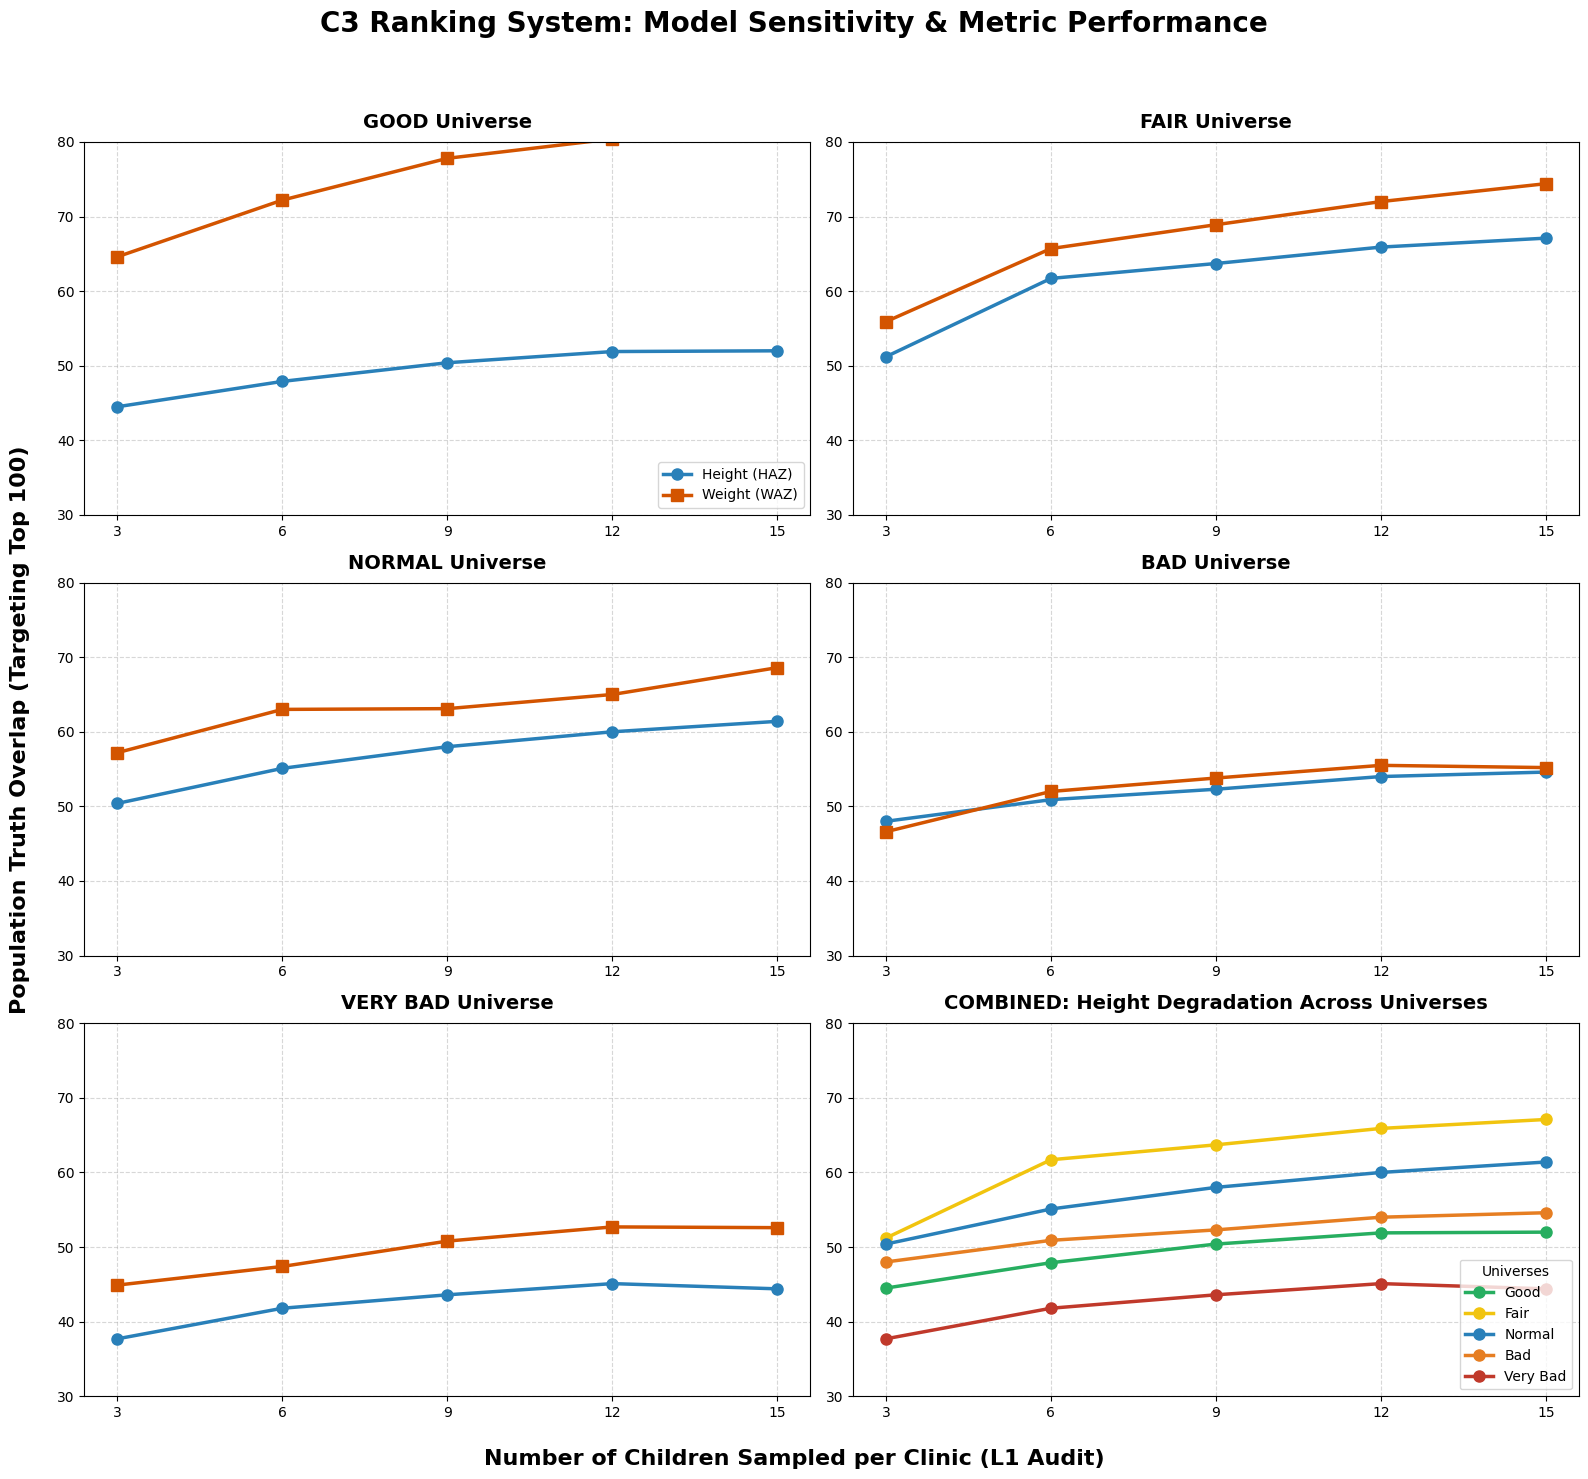

In [53]:
# plot 1 code with for CI
# okay, passable p1 code
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os
from datetime import datetime

# ==============================================================================
# 1. SETUP THE FILES & COLORS
# ==============================================================================
datasets_to_run = {
    "Good": "sensitivity_dataset_TRUE_Good_20260324_100502.parquet", 
    "Fair": "sensitivity_dataset_Fair_20260323_115454.parquet",
    "Normal": "sensitivity_dataset_Normal_20260323_150757.parquet",
    "Bad": "sensitivity_dataset_Bad_20260323_132920.parquet",
    "Very Bad": "sensitivity_dataset_Very_Bad_20260323_141221.parquet"
}

uni_colors = {
    "Good": "#27ae60",     # Green
    "Fair": "#f1c40f",     # Yellow
    "Normal": "#2980b9",   # Blue
    "Bad": "#e67e22",      # Orange
    "Very Bad": "#c0392b"  # Red
}

n_children_list = [3, 6, 9, 12, 15] 
n_simulations = 10 
target_count = 100  

master_results = []
plot_data = {}

print("🚀 INITIATING MASTER EVALUATION ENGINE...\n")

# ==============================================================================
# 2. RUN THE ENGINE (HEIGHT & WEIGHT, L1 & L2)
# ==============================================================================
for universe_name, file_name in datasets_to_run.items():
    if not os.path.exists(file_name):
        print(f"❌ Error: Cannot find '{file_name}'. Skipping...")
        continue

    print(f"⚙️ Simulating {universe_name.upper()} Universe...")
    df = pd.read_parquet(file_name)

    # Calculate all fraud discrepancies
    df['true_fraud_haz'] = np.abs(df['real_haz'] - df['L0_haz'])
    df['true_fraud_waz'] = np.abs(df['real_waz'] - df['L0_waz'])
    
    df['meas_fraud_haz_L1'] = np.abs(df['L1_haz'] - df['L0_haz'])
    df['meas_fraud_waz_L1'] = np.abs(df['L1_waz'] - df['L0_waz'])
    
    df['meas_fraud_haz_L2'] = np.abs(df['L2_haz'] - df['L0_haz'])
    df['meas_fraud_waz_L2'] = np.abs(df['L2_waz'] - df['L0_waz'])

    # Population Anchor
    pop_means = df.groupby('L1_id')[['true_fraud_haz', 'true_fraud_waz']].mean().reset_index()
    pop_means['pop_rank_ht'] = pop_means['true_fraud_haz'].rank(method='first', ascending=False)
    pop_means['pop_rank_wt'] = pop_means['true_fraud_waz'].rank(method='first', ascending=False)
    true_top_100_ht = set(pop_means[pop_means['pop_rank_ht'] <= target_count]['L1_id'])
    true_top_100_wt = set(pop_means[pop_means['pop_rank_wt'] <= target_count]['L1_id'])

    # Sampling Loop
    overlap_results = []
    for n_kids in tqdm(n_children_list, desc=f"   Sampling", leave=False):
        for _ in range(n_simulations):
            df_sample = df.groupby(['L1_id', 'L0_id']).sample(n=n_kids, replace=True)
            
            # Aggregate L1 and L2 means
            l0_means = df_sample.groupby(['L1_id', 'L0_id'])[['meas_fraud_haz_L1', 'meas_fraud_waz_L1', 'meas_fraud_haz_L2', 'meas_fraud_waz_L2']].mean().reset_index()
            l1_means = l0_means.groupby('L1_id')[['meas_fraud_haz_L1', 'meas_fraud_waz_L1', 'meas_fraud_haz_L2', 'meas_fraud_waz_L2']].mean().reset_index()
            
            # Rank
            l1_means['rank_ht_L1'] = l1_means['meas_fraud_haz_L1'].rank(method='first', ascending=False)
            l1_means['rank_wt_L1'] = l1_means['meas_fraud_waz_L1'].rank(method='first', ascending=False)
            l1_means['rank_ht_L2'] = l1_means['meas_fraud_haz_L2'].rank(method='first', ascending=False)
            l1_means['rank_wt_L2'] = l1_means['meas_fraud_waz_L2'].rank(method='first', ascending=False)
            
            # Overlaps
            ov_ht_L1 = len(set(l1_means[l1_means['rank_ht_L1'] <= target_count]['L1_id']).intersection(true_top_100_ht))
            ov_wt_L1 = len(set(l1_means[l1_means['rank_wt_L1'] <= target_count]['L1_id']).intersection(true_top_100_wt))
            ov_ht_L2 = len(set(l1_means[l1_means['rank_ht_L2'] <= target_count]['L1_id']).intersection(true_top_100_ht))
            ov_wt_L2 = len(set(l1_means[l1_means['rank_wt_L2'] <= target_count]['L1_id']).intersection(true_top_100_wt))
            
            overlap_results.append({
                'Universe': universe_name, 'Sample_Size': n_kids,
                'L1_Ht_Overlap': ov_ht_L1, 'L1_Wt_Overlap': ov_wt_L1,
                'L2_Ht_Overlap': ov_ht_L2, 'L2_Wt_Overlap': ov_wt_L2
            })

    # Group, Average, and calculate Confidence Intervals WITHOUT dropping columns
    temp_df = pd.DataFrame(overlap_results)
    
    agg_df = temp_df.groupby(['Universe', 'Sample_Size']).agg(
        L1_Ht_Overlap=('L1_Ht_Overlap', 'mean'),
        L1_Ht_Std=('L1_Ht_Overlap', 'std'),
        L1_Wt_Overlap=('L1_Wt_Overlap', 'mean'),
        L2_Ht_Overlap=('L2_Ht_Overlap', 'mean'),
        L2_Wt_Overlap=('L2_Wt_Overlap', 'mean')
    ).reset_index()
    
    # Calculate 95% CI: 1.96 * (StdDev / sqrt(N))
    agg_df['L1_Ht_ci95'] = 1.96 * (agg_df['L1_Ht_Std'] / np.sqrt(n_simulations))
    agg_df = agg_df.round(2)
    
    master_results.append(agg_df)
    plot_data[universe_name] = agg_df

# ==============================================================================
# 3. SAVE TO EXCEL
# ==============================================================================
final_excel_df = pd.concat(master_results, ignore_index=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
excel_filename = f"MASTER_evaluation_results_{timestamp}.xlsx"

final_excel_df.to_excel(excel_filename, index=False)
print(f"\n✅ EXCEL SAVED: {excel_filename}")

# ==============================================================================
# 4. PLOT THE 3x2 MASTER GRID
# ==============================================================================
print("📊 Generating 3x2 Master Layout Plot...")
fig, axes = plt.subplots(3, 2, figsize=(16, 15), dpi=100)
axes = axes.flatten()

# Y-Axis limit applied universally so changes are obvious
Y_MIN, Y_MAX = 30, 80
lw, ms = 2.5, 8
metric_colors = {'Height': '#2980b9', 'Weight': '#d35400'} # Blue and Orange

# Plots 1 to 5: Individual Universes (Height vs Weight L1)
universes = list(datasets_to_run.keys())

for i, uni in enumerate(universes):
    ax = axes[i]
    data = plot_data[uni]
    
    ax.plot(data['Sample_Size'], data['L1_Ht_Overlap'], marker='o', color=metric_colors['Height'], label='Height (HAZ)', lw=lw, ms=ms)
    ax.plot(data['Sample_Size'], data['L1_Wt_Overlap'], marker='s', color=metric_colors['Weight'], label='Weight (WAZ)', lw=lw, ms=ms)
    
    ax.set_title(f"{uni.upper()} Universe", fontsize=14, fontweight='bold', pad=10)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_xticks(n_children_list)
    ax.grid(True, linestyle='--', alpha=0.5)
    if i == 0: ax.legend(loc='lower right')

# Plot 6: Combined Height Sensitivity Waterfall
ax_comb = axes[5]
for uni in universes:
    data = plot_data[uni]
    ax_comb.plot(data['Sample_Size'], data['L1_Ht_Overlap'], marker='o', color=uni_colors[uni], label=uni, lw=lw, ms=ms)

ax_comb.set_title("COMBINED: Height Degradation Across Universes", fontsize=14, fontweight='bold', pad=10)
ax_comb.set_ylim(Y_MIN, Y_MAX)
ax_comb.set_xticks(n_children_list)
ax_comb.grid(True, linestyle='--', alpha=0.5)
ax_comb.legend(title='Universes', loc='lower right')

# Add global labels and adjust layout
fig.text(0.5, 0.01, 'Number of Children Sampled per Clinic (L1 Audit)', ha='center', fontsize=16, fontweight='bold')
fig.text(0.01, 0.5, f'Population Truth Overlap (Targeting Top {target_count})', va='center', rotation='vertical', fontsize=16, fontweight='bold')

plt.suptitle("C3 Ranking System: Model Sensitivity & Metric Performance", fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0.03, 0.03, 1, 0.95]) # Make room for global labels

plot_filename = f"MASTER_3x2_Layout_Plot_{timestamp}.png"
plt.savefig(plot_filename, bbox_inches='tight')
print(f"✅ PLOT SAVED: {plot_filename}")
plt.show()

📊 Loading Data from: MASTER_evaluation_results_20260325_104527.xlsx
✅ PLOT SAVED: Standalone_L1_Height_Final_with_CI_104527.png


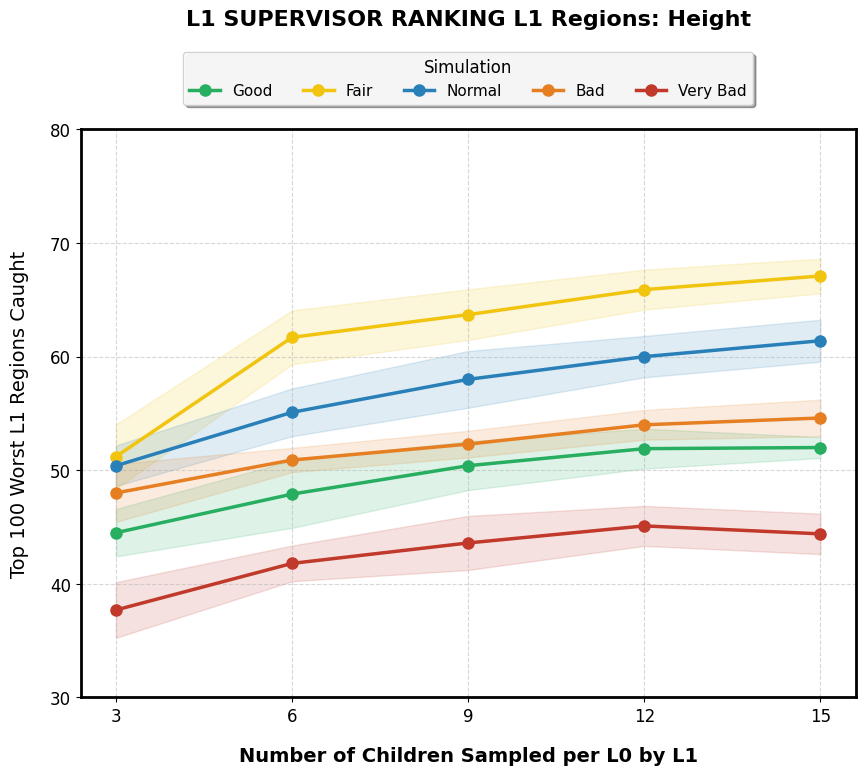

In [55]:
# Plot 1 Sensitivity Chart: L1 Height Overlap Across Universes (Standalone Template)
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# 1. LOAD YOUR SPECIFIC NEW EXCEL FILE
# ==============================================================================
latest_excel = "MASTER_evaluation_results_20260325_104527.xlsx"
final_excel_df = pd.read_excel(latest_excel)

print(f"📊 Loading Data from: {latest_excel}")

# ==============================================================================
# 2. PLOT THE STANDALONE L1 HEIGHT UNIVERSES
# ==============================================================================
uni_colors = {
    "Good": "#27ae60", "Fair": "#f1c40f", "Normal": "#2980b9", 
    "Bad": "#e67e22", "Very Bad": "#c0392b"
}

target_count = 100 
FONT_SIZE = 14
lw, ms = 2.5, 8
border_thickness = 2.0

# Increased figure height slightly to make room for the "stack" at the top
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
universes = list(uni_colors.keys())

for uni in universes:
    data = final_excel_df[final_excel_df['Universe'] == uni]
    
    # 1. Plot the solid mean line
    ax.plot(data['Sample_Size'], data['L1_Ht_Overlap'], 
            marker='o', linestyle='-', color=uni_colors[uni], 
            label=uni, lw=lw, ms=ms)
            
    # 2. Add the shaded confidence interval band
    # Checking if the CI column exists just to be safe
    if 'L1_Ht_ci95' in data.columns:
        ax.fill_between(data['Sample_Size'], 
                        data['L1_Ht_Overlap'] - data['L1_Ht_ci95'], 
                        data['L1_Ht_Overlap'] + data['L1_Ht_ci95'], 
                        color=uni_colors[uni], alpha=0.15)

# Styling
ax.set_xlabel('Number of Children Sampled per L0 by L1', fontsize=FONT_SIZE, fontweight='bold', labelpad=15)
ax.set_ylabel(f'Top {target_count} Worst L1 Regions Caught', fontsize=FONT_SIZE, labelpad=15)
ax.set_xticks(final_excel_df['Sample_Size'].unique())
ax.set_ylim(30, 80)
ax.tick_params(axis='both', labelsize=FONT_SIZE-2)
ax.grid(True, linestyle='--', alpha=0.5)

# --- BOLD BORDERS ---
for spine in ax.spines.values():
    spine.set_linewidth(border_thickness)
    spine.set_color('black')

# --- EXTERNAL TOP LEGEND (FIXED OVERLAP) ---
# Increased Y to 1.15 to clear the border completely
ax.legend(title='Simulation', bbox_to_anchor=(0.5, 1.15), loc='upper center', 
          ncol=5, fontsize=FONT_SIZE-3, framealpha=0.9, shadow=True, title_fontsize=FONT_SIZE-2)

# title pad=75 pushes the title even higher to make room for the floating legend
plt.title("L1 SUPERVISOR RANKING L1 Regions: Height", 
          fontsize=FONT_SIZE+2, fontweight='bold', pad=75)

# --- CRITICAL FIX: Manual margin adjustment ---
# top=0.82 shrinks the plot area slightly from the top to create a "safe zone" for the legend/title
plt.subplots_adjust(top=0.82) 

# Extract the timestamp from your file for the saved image name
timestamp = latest_excel.split('_')[-1].replace('.xlsx', '')
plot_filename = f"Standalone_L1_Height_Final_with_CI_{timestamp}.png"
plt.savefig(plot_filename, bbox_inches='tight')

print(f"✅ PLOT SAVED: {plot_filename}")
plt.show()

In [64]:
# good print results
# ==============================================================================
# 5. PRINT THE CLEAN TERMINAL RESULTS
# ==============================================================================
print("\n" + "=" * 80)
print(f"📊 FINAL RESULTS: GLOBAL L1 RANKING (Targeting Top {target_count})")
print("=" * 80)

# final_excel_df contains all the aggregated data from the 5 universes
display_df = final_excel_df.copy()

# Sort to ensure consistent output
display_df.sort_values(by=['Universe', 'Sample_Size'], inplace=True)

# Format the Height Mean and CI into a single clean string
display_df['L1_Ht_Overlap'] = display_df['L1_Ht_Overlap'].round(1)
if 'L1_Ht_ci95' in display_df.columns:
    display_df['L1_Ht_ci95'] = display_df['L1_Ht_ci95'].round(1)
    display_df['L1 Height (Mean ± CI)'] = display_df['L1_Ht_Overlap'].astype(str) + " ± " + display_df['L1_Ht_ci95'].astype(str)
else:
    display_df['L1 Height (Mean ± CI)'] = display_df['L1_Ht_Overlap'].astype(str)

# Round the other metrics for clean printing
display_df['L1_Wt_Overlap'] = display_df['L1_Wt_Overlap'].round(1)
display_df['L2_Ht_Overlap'] = display_df['L2_Ht_Overlap'].round(1)
display_df['L2_Wt_Overlap'] = display_df['L2_Wt_Overlap'].round(1)

# Ensure the universes print in logical order
universes_order = ["Good", "Fair", "Normal", "Bad", "Very Bad"]

for uni in universes_order:
    if uni in display_df['Universe'].values:
        print(f"\n🌟 UNIVERSE: {uni.upper()}")
        print("-" * 75)
        
        # Select the specific columns to print
        uni_data = display_df[display_df['Universe'] == uni][
            ['Sample_Size', 'L1 Height (Mean ± CI)', 'L1_Wt_Overlap', 'L2_Ht_Overlap', 'L2_Wt_Overlap']
        ]
        
        # Rename columns for the terminal output
        uni_data.columns = ['Kids per Clinic', 'L1 Height (± CI)', 'L1 Weight Mean', 'L2 Height Mean', 'L2 Weight Mean']
        
        print(uni_data.to_string(index=False))


📊 FINAL RESULTS: GLOBAL L1 RANKING (Targeting Top 100)

🌟 UNIVERSE: GOOD
---------------------------------------------------------------------------
 Kids per Clinic L1 Height (± CI)  L1 Weight Mean  L2 Height Mean  L2 Weight Mean
               3       44.5 ± 2.1            64.6            42.5            63.2
               6       47.9 ± 3.0            72.2            47.8            71.2
               9       50.4 ± 2.2            77.8            48.6            77.2
              12       51.9 ± 1.8            80.4            51.9            80.0
              15       52.0 ± 0.9            82.3            52.5            82.4

🌟 UNIVERSE: FAIR
---------------------------------------------------------------------------
 Kids per Clinic L1 Height (± CI)  L1 Weight Mean  L2 Height Mean  L2 Weight Mean
               3       51.2 ± 2.8            55.9            53.2            57.2
               6       61.7 ± 2.4            65.7            60.8            66.8
               9  

other metrics

In [43]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import os
from datetime import datetime

# ==============================================================================
# 1. SETUP
# ==============================================================================
datasets_to_run = {
    "Good": "sensitivity_dataset_TRUE_Good_20260324_100502.parquet", 
    "Fair": "sensitivity_dataset_Fair_20260323_115454.parquet",
    "Normal": "sensitivity_dataset_Normal_20260323_150757.parquet",
    "Bad": "sensitivity_dataset_Bad_20260323_132920.parquet",
    "Very Bad": "sensitivity_dataset_Very_Bad_20260323_141221.parquet"
}

n_children_list = [3, 6, 9, 12, 15] 
n_simulations = 5 
target_count = 100  # Global Top 100 worst L1 Regions
metrics = ['Simple Mean', 'Top-3 Mean', 'RMSE']

master_results = []
print("🚀 INITIATING GLOBAL APPLES-TO-APPLES SHOWDOWN...\n")

# ==============================================================================
# 2. RUN THE ENGINE
# ==============================================================================
for universe_name, file_name in datasets_to_run.items():
    if not os.path.exists(file_name):
        print(f"❌ Error: Cannot find '{file_name}'. Skipping...")
        continue

    print(f"⚙️ Simulating {universe_name.upper()} Universe...")
    df = pd.read_parquet(file_name)

    # Discrepancies
    df['true_fraud_haz'] = np.abs(df['real_haz'] - df['L0_haz'])
    df['meas_fraud_haz_L1'] = np.abs(df['L1_haz'] - df['L0_haz'])
    
    # Pre-calculate squares for RMSE
    df['true_sq'] = df['true_fraud_haz'] ** 2
    df['meas_sq'] = df['meas_fraud_haz_L1'] ** 2

    # --- TRUE TARGET RANKING (Ground Truth for each metric) ---
    true_targets = {}
    
    # 1. True Simple Mean
    true_mean_l0 = df.groupby(['L1_id', 'L0_id'])['true_fraud_haz'].mean().reset_index()
    true_mean_l1 = true_mean_l0.groupby('L1_id')['true_fraud_haz'].mean().reset_index()
    true_targets['Simple Mean'] = set(true_mean_l1.nlargest(target_count, 'true_fraud_haz')['L1_id'])
    
    # 2. True Top-3 Mean
    true_top3_l0 = df.sort_values('true_fraud_haz', ascending=False).groupby(['L1_id', 'L0_id']).head(3)
    true_top3_l0 = true_top3_l0.groupby(['L1_id', 'L0_id'])['true_fraud_haz'].mean().reset_index()
    true_top3_l1 = true_top3_l0.groupby('L1_id')['true_fraud_haz'].mean().reset_index()
    true_targets['Top-3 Mean'] = set(true_top3_l1.nlargest(target_count, 'true_fraud_haz')['L1_id'])
    
    # 3. True RMSE
    true_rmse_l0 = df.groupby(['L1_id', 'L0_id'])['true_sq'].mean().reset_index()
    true_rmse_l0['true_rmse'] = np.sqrt(true_rmse_l0['true_sq'])
    true_rmse_l1 = true_rmse_l0.groupby('L1_id')['true_rmse'].mean().reset_index()
    true_targets['RMSE'] = set(true_rmse_l1.nlargest(target_count, 'true_rmse')['L1_id'])

    # --- SAMPLING LOOP ---
    for n_kids in tqdm(n_children_list, desc=f"   Sampling", leave=False):
        for sim in range(n_simulations):
            df_sample = df.groupby(['L1_id', 'L0_id']).sample(n=n_kids, replace=True)
            
            # 1. Sampled Simple Mean
            samp_mean_l0 = df_sample.groupby(['L1_id', 'L0_id'])['meas_fraud_haz_L1'].mean().reset_index()
            samp_mean_l1 = samp_mean_l0.groupby('L1_id')['meas_fraud_haz_L1'].mean().reset_index()
            samp_top_mean = set(samp_mean_l1.nlargest(target_count, 'meas_fraud_haz_L1')['L1_id'])
            
            # 2. Sampled Top-3 Mean
            samp_top3_l0 = df_sample.sort_values('meas_fraud_haz_L1', ascending=False).groupby(['L1_id', 'L0_id']).head(3)
            samp_top3_l0 = samp_top3_l0.groupby(['L1_id', 'L0_id'])['meas_fraud_haz_L1'].mean().reset_index()
            samp_top3_l1 = samp_top3_l0.groupby('L1_id')['meas_fraud_haz_L1'].mean().reset_index()
            samp_top_top3 = set(samp_top3_l1.nlargest(target_count, 'meas_fraud_haz_L1')['L1_id'])
            
            # 3. Sampled RMSE
            samp_rmse_l0 = df_sample.groupby(['L1_id', 'L0_id'])['meas_sq'].mean().reset_index()
            samp_rmse_l0['meas_rmse'] = np.sqrt(samp_rmse_l0['meas_sq'])
            samp_rmse_l1 = samp_rmse_l0.groupby('L1_id')['meas_rmse'].mean().reset_index()
            samp_top_rmse = set(samp_rmse_l1.nlargest(target_count, 'meas_rmse')['L1_id'])
            
            # Record Accuracies
            master_results.append({'Method': 'Simple Mean', 'Universe': universe_name, 'Sample_Size': n_kids,
                                   'Accuracy': (len(samp_top_mean & true_targets['Simple Mean']) / target_count) * 100})
            master_results.append({'Method': 'Top-3 Mean', 'Universe': universe_name, 'Sample_Size': n_kids,
                                   'Accuracy': (len(samp_top_top3 & true_targets['Top-3 Mean']) / target_count) * 100})
            master_results.append({'Method': 'RMSE', 'Universe': universe_name, 'Sample_Size': n_kids,
                                   'Accuracy': (len(samp_top_rmse & true_targets['RMSE']) / target_count) * 100})

# ==============================================================================
# 3. AGGREGATE AND PRINT
# ==============================================================================
df_results = pd.DataFrame(master_results)
agg_df = df_results.groupby(['Universe', 'Sample_Size', 'Method'])['Accuracy'].mean().reset_index()

# Pivot for clean printing
pivot_df = agg_df.pivot(index=['Universe', 'Sample_Size'], columns='Method', values='Accuracy').reset_index()

# Sort logically
uni_order = ['Good', 'Fair', 'Normal', 'Bad', 'Very Bad']
pivot_df['Universe'] = pd.Categorical(pivot_df['Universe'], categories=uni_order, ordered=True)
pivot_df = pivot_df.sort_values(['Universe', 'Sample_Size'])

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_filename = f"Global_ApplesToApples_Metrics_{timestamp}.csv"
pivot_df.to_csv(csv_filename, index=False)

print("\n" + "=" * 80)
print("🏆 GLOBAL ACCURACY SHOWDOWN (Targeting Statewide Top 100 L1s)")
print("=" * 80)
header = f"{'Universe':<12} | {'Sample Size':<11} | {'Simple Mean (%)':<15} | {'RMSE (%)':<15} | {'Top-3 Mean (%)':<15}"
print(header)
print("-" * 80)

for _, row in pivot_df.iterrows():
    if row['Sample_Size'] == 3 and row['Universe'] != 'Good':
        print("-" * 80)
        
    print(f"{row['Universe']:<12} | "
          f"{row['Sample_Size']:<11} | "
          f"{row['Simple Mean']:<15.1f} | "
          f"{row['RMSE']:<15.1f} | "
          f"{row['Top-3 Mean']:<15.1f}")
          
print("=" * 80)
print(f"✅ Data saved to: {csv_filename}")

🚀 INITIATING GLOBAL APPLES-TO-APPLES SHOWDOWN...

⚙️ Simulating GOOD Universe...


⚙️ Simulating FAIR Universe...


⚙️ Simulating NORMAL Universe...


⚙️ Simulating BAD Universe...


⚙️ Simulating VERY BAD Universe...



🏆 GLOBAL ACCURACY SHOWDOWN (Targeting Statewide Top 100 L1s)
Universe     | Sample Size | Simple Mean (%) | RMSE (%)        | Top-3 Mean (%) 
--------------------------------------------------------------------------------
Good         | 3           | 43.4            | 49.6            | 45.0           
Good         | 6           | 49.8            | 54.2            | 53.2           
Good         | 9           | 48.2            | 56.4            | 55.6           
Good         | 12          | 51.0            | 62.2            | 60.0           
Good         | 15          | 52.8            | 62.2            | 62.6           
--------------------------------------------------------------------------------
Fair         | 3           | 53.0            | 56.6            | 55.4           
Fair         | 6           | 60.2            | 64.6            | 62.4           
Fair         | 9           | 63.6            | 72.0            | 70.6           
Fair         | 12          | 64.8            | 

In [34]:
import pandas as pd
import glob
import os
from datetime import datetime

# ==============================================================================
# 1. LOAD THE LATEST EXCEL FILE
# ==============================================================================
excel_files = glob.glob("MASTER_evaluation_results_*.xlsx")
if not excel_files:
    print("❌ No Excel files found.")
else:
    latest_excel = max(excel_files, key=os.path.getctime)
    df_results = pd.read_excel(latest_excel)

    # Filter for the benchmark: 15 Children Sampled
    df_15 = df_results[df_results['Sample_Size'] == 15].copy()
    
    # Sort logically
    uni_order = ['Good', 'Fair', 'Normal', 'Bad', 'Very Bad']
    df_15['Universe'] = pd.Categorical(df_15['Universe'], categories=uni_order, ordered=True)
    df_15 = df_15.sort_values('Universe')

    # ==============================================================================
    # 2. CALCULATE RELATIVE IMPROVEMENT (LIFT)
    # Metric: Relative Lift (%) = ((L2 Accuracy - L1 Accuracy) / L1 Accuracy) * 100
    # ==============================================================================
    df_15['Height_Lift'] = ((df_15['L2_Ht_Overlap'] - df_15['L1_Ht_Overlap']) / df_15['L1_Ht_Overlap']) * 100
    df_15['Weight_Lift'] = ((df_15['L2_Wt_Overlap'] - df_15['L1_Wt_Overlap']) / df_15['L1_Wt_Overlap']) * 100

    # Create the final clean table
    final_table = df_15[['Universe', 'L1_Ht_Overlap', 'L2_Ht_Overlap', 'Height_Lift', 
                         'L1_Wt_Overlap', 'L2_Wt_Overlap', 'Weight_Lift']].copy()
    
    final_table.columns = [
        'Universe', 'L1_Ht', 'L2_Ht', 'Ht_Improve', 'L1_Wt', 'L2_Wt', 'Wt_Improve'
    ]

    # ==============================================================================
    # 3. PRINTING AND EXPORTING
    # ==============================================================================
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_name = f"L2_Improvement_Report_{timestamp}.csv"
    final_table.to_csv(save_name, index=False)
    
    print(f"✅ Report Saved: {save_name}\n")
    print("📋 COPY THE TABLE BELOW INTO WORD:")
    print("=" * 110)
    
    # Manual Table Formatting (No dependencies needed)
    header = f"{'Universe':<12} | {'L1 Ht':<8} | {'L2 Ht':<8} | {'Ht Lift':<10} | {'L1 Wt':<8} | {'L2 Wt':<8} | {'Wt Lift':<10}"
    print(header)
    print("-" * 110)
    
    for _, row in final_table.iterrows():
        print(f"{row['Universe']:<12} | "
              f"{row['L1_Ht']:<8.1f} | "
              f"{row['L2_Ht']:<8.1f} | "
              f"+{row['Ht_Improve']:>8.1f}% | "
              f"{row['L1_Wt']:<8.1f} | "
              f"{row['L2_Wt']:<8.1f} | "
              f"+{row['Wt_Improve']:>8.1f}%")
    
    print("=" * 110)
    print("\n💡 METHODOLOGY NOTE:")
    print("Lift is calculated as the percentage increase in accuracy when moving from L1 to L2.")
    print("Formula: ((L2_Accuracy - L1_Accuracy) / L1_Accuracy) * 100")

✅ Report Saved: L2_Improvement_Report_20260324_171559.csv

📋 COPY THE TABLE BELOW INTO WORD:
Universe     | L1 Ht    | L2 Ht    | Ht Lift    | L1 Wt    | L2 Wt    | Wt Lift   
--------------------------------------------------------------------------------------------------------------
Good         | 51.3     | 53.6     | +     4.5% | 81.9     | 82.5     | +     0.7%
Fair         | 66.3     | 69.3     | +     4.5% | 73.3     | 73.9     | +     0.8%
Normal       | 62.6     | 69.9     | +    11.7% | 67.2     | 78.6     | +    17.0%
Bad          | 54.7     | 69.4     | +    26.9% | 55.6     | 75.0     | +    34.9%
Very Bad     | 44.6     | 64.4     | +    44.4% | 52.8     | 77.8     | +    47.3%

💡 METHODOLOGY NOTE:
Lift is calculated as the percentage increase in accuracy when moving from L1 to L2.
Formula: ((L2_Accuracy - L1_Accuracy) / L1_Accuracy) * 100


🚀 INITIATING INTRA-REGIONAL L0 EVALUATION ENGINE...

⚙️ Simulating GOOD Universe...


⚙️ Simulating FAIR Universe...


⚙️ Simulating NORMAL Universe...


⚙️ Simulating BAD Universe...


⚙️ Simulating VERY BAD Universe...


📊 Generating Intra-Regional Plot...
✅ PLOT SAVED: Standalone_IntraRegional_L0_Ranking_20260324_180903.png


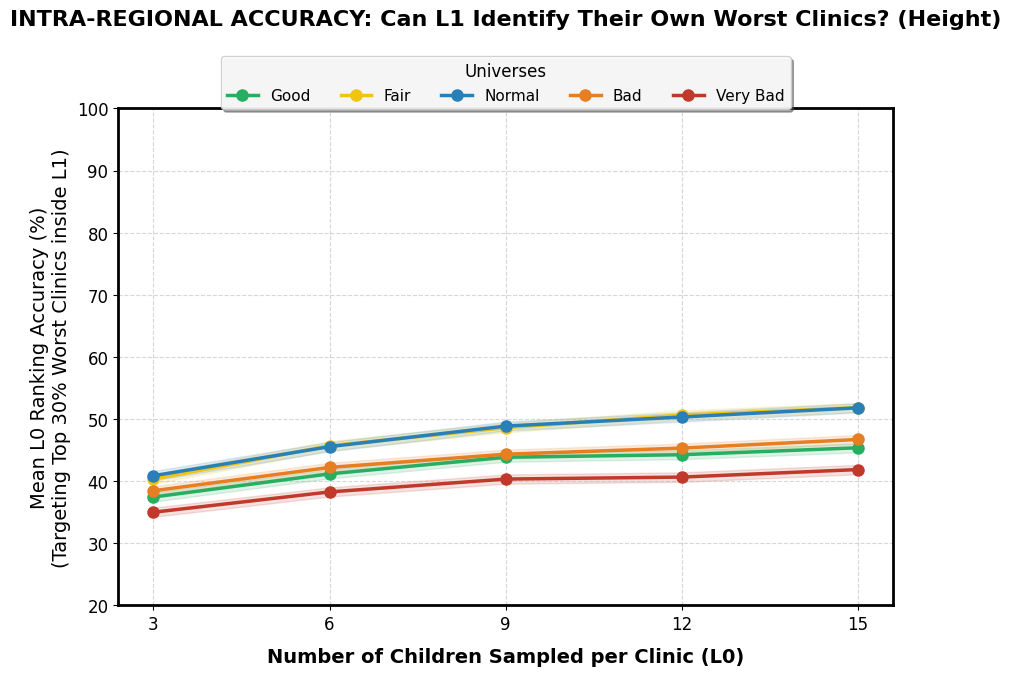

In [ ]:
# l1 ranking l0
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os
from datetime import datetime

# ==============================================================================
# 1. SETUP THE FILES & COLORS
# ==============================================================================
datasets_to_run = {
    "Good": "sensitivity_dataset_TRUE_Good_20260324_100502.parquet", # Replace with your exact filename
    "Fair": "sensitivity_dataset_Fair_20260323_115454.parquet",
    "Normal": "sensitivity_dataset_Normal_20260323_150757.parquet",
    "Bad": "sensitivity_dataset_Bad_20260323_132920.parquet",
    "Very Bad": "sensitivity_dataset_Very_Bad_20260323_141221.parquet"
}

uni_colors = {
    "Good": "#27ae60", "Fair": "#f1c40f", "Normal": "#2980b9", 
    "Bad": "#e67e22", "Very Bad": "#c0392b"
}

n_children_list = [3, 6, 9, 12, 15] 
n_simulations = 5  # Lowered to 5 to speed up the local ranking loop
target_percent = 0.30  # Top 30%

master_results = []
print("🚀 INITIATING INTRA-REGIONAL L0 EVALUATION ENGINE...\n")

# ==============================================================================
# 2. RUN THE ENGINE (INTRA-REGIONAL RANKING)
# ==============================================================================
for universe_name, file_name in datasets_to_run.items():
    if not os.path.exists(file_name):
        print(f"❌ Error: Cannot find '{file_name}'. Skipping...")
        continue

    print(f"⚙️ Simulating {universe_name.upper()} Universe...")
    df = pd.read_parquet(file_name)

    # Calculate True Fraud (L0 vs Real) and Measured Fraud (L1 vs L0)
    df['true_fraud_haz'] = np.abs(df['real_haz'] - df['L0_haz'])
    df['meas_fraud_haz_L1'] = np.abs(df['L1_haz'] - df['L0_haz'])

    # Determine True Local Ranking (Within each L1)
    true_l0_means = df.groupby(['L1_id', 'L0_id'])['true_fraud_haz'].mean().reset_index()
    true_l0_means['true_rank'] = true_l0_means.groupby('L1_id')['true_fraud_haz'].rank(method='first', ascending=False)
    
    # Calculate how many clinics make up 30% for each supervisor (usually 25 * 0.3 = 7.5 -> 7 clinics)
    n_clinics_per_l1 = true_l0_means.groupby('L1_id')['L0_id'].transform('count')
    true_l0_means['target_count'] = np.floor(n_clinics_per_l1 * target_percent)
    
    # Create a dictionary mapping each L1_id to its TRUE worst L0s
    true_worst_dict = {}
    for l1 in true_l0_means['L1_id'].unique():
        l1_data = true_l0_means[true_l0_means['L1_id'] == l1]
        target = l1_data['target_count'].iloc[0]
        true_worst_dict[l1] = set(l1_data[l1_data['true_rank'] <= target]['L0_id'])

    # Sampling Loop
    for n_kids in tqdm(n_children_list, desc=f"   Sampling", leave=False):
        for sim in range(n_simulations):
            # Sample N children per clinic
            df_sample = df.groupby(['L1_id', 'L0_id']).sample(n=n_kids, replace=True)
            
            # Aggregate sampled means
            sampled_means = df_sample.groupby(['L1_id', 'L0_id'])['meas_fraud_haz_L1'].mean().reset_index()
            
            # Rank within L1 based on Sample
            sampled_means['samp_rank'] = sampled_means.groupby('L1_id')['meas_fraud_haz_L1'].rank(method='first', ascending=False)
            
            # Calculate Overlap for EACH L1
            for l1 in sampled_means['L1_id'].unique():
                l1_samp_data = sampled_means[sampled_means['L1_id'] == l1]
                target = true_l0_means[true_l0_means['L1_id'] == l1]['target_count'].iloc[0]
                
                samp_worst = set(l1_samp_data[l1_samp_data['samp_rank'] <= target]['L0_id'])
                true_worst = true_worst_dict[l1]
                
                # Accuracy % for this specific supervisor
                if target > 0:
                    accuracy = (len(samp_worst.intersection(true_worst)) / target) * 100
                else:
                    accuracy = 0
                    
                master_results.append({
                    'Universe': universe_name, 'Sample_Size': n_kids,
                    'L1_id': l1, 'Accuracy': accuracy
                })

# Convert to DataFrame
df_results = pd.DataFrame(master_results)

# Calculate Mean and Standard Error for each Universe + Sample Size combo
agg_df = df_results.groupby(['Universe', 'Sample_Size']).agg(
    mean_acc=('Accuracy', 'mean'),
    std_acc=('Accuracy', 'std'),
    count=('Accuracy', 'count')
).reset_index()

# Calculate 95% Confidence Interval (1.96 * Standard Error)
agg_df['ci_95'] = 1.96 * (agg_df['std_acc'] / np.sqrt(agg_df['count']))

# ==============================================================================
# 3. PLOT THE RESULTS (Mean + Confidence Intervals)
# ==============================================================================
print("📊 Generating Intra-Regional Plot...")
FONT_SIZE = 14
lw, ms = 2.5, 8

fig, ax = plt.subplots(figsize=(10, 7), dpi=100)
universes = list(datasets_to_run.keys())

for uni in universes:
    data = agg_df[agg_df['Universe'] == uni]
    
    # Plot line with markers
    ax.plot(data['Sample_Size'], data['mean_acc'], 
            marker='o', linestyle='-', color=uni_colors[uni], 
            label=uni, lw=lw, ms=ms)
    
    # Add shaded confidence interval (error margins)
    ax.fill_between(data['Sample_Size'], 
                    data['mean_acc'] - data['ci_95'], 
                    data['mean_acc'] + data['ci_95'], 
                    color=uni_colors[uni], alpha=0.15)

# Styling
ax.set_xlabel('Number of Children Sampled per Clinic (L0)', fontsize=FONT_SIZE, fontweight='bold', labelpad=10)
ax.set_ylabel('Mean L0 Ranking Accuracy (%)\n(Targeting Top 30% Worst Clinics inside L1)', fontsize=FONT_SIZE)
ax.set_xticks(n_children_list)
ax.set_ylim(20, 100)
ax.tick_params(axis='both', labelsize=FONT_SIZE-2)
ax.grid(True, linestyle='--', alpha=0.5)

# External Legend
ax.legend(title='Universes', bbox_to_anchor=(0.5, 1.12), loc='upper center', 
          ncol=5, fontsize=FONT_SIZE-3, framealpha=0.9, shadow=True, title_fontsize=FONT_SIZE-2)

plt.title("INTRA-REGIONAL ACCURACY: Can L1 Identify Their Own Worst Clinics? (Height)", 
          fontsize=FONT_SIZE+2, fontweight='bold', pad=60)

# Bold Borders
for spine in ax.spines.values():
    spine.set_linewidth(2.0)
    spine.set_color('black')

plt.subplots_adjust(top=0.82) 
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plot_filename = f"Standalone_IntraRegional_L0_Ranking_{timestamp}.png"
plt.savefig(plot_filename, bbox_inches='tight')

print(f"✅ PLOT SAVED: {plot_filename}")
plt.show()

📊 Generating Intra-Regional Plot...
✅ PLOT SAVED: Standalone_IntraRegional_L0_Ranking_20260324_210206.png


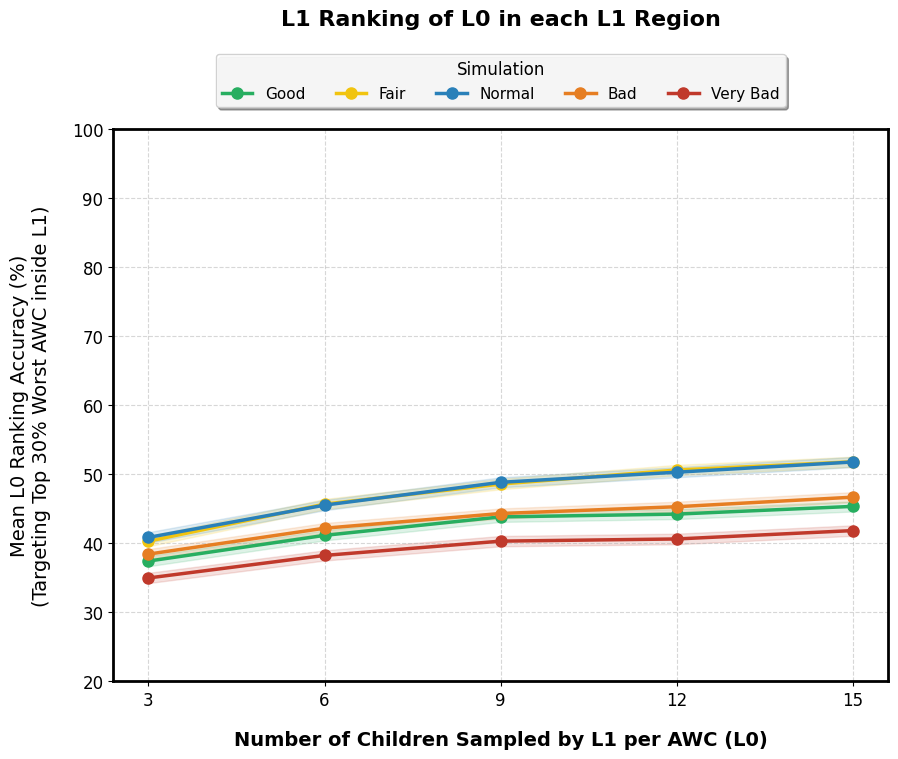

In [ ]:
import matplotlib.pyplot as plt
from datetime import datetime

# ==============================================================================
# 3. PLOT THE RESULTS (Mean + Confidence Intervals)
# Assuming `agg_df`, `datasets_to_run`, `uni_colors`, and `n_children_list` 
# are already in your environment from the previous steps.
# ==============================================================================
print("📊 Generating Intra-Regional Plot...")

FONT_SIZE = 14
lw, ms = 2.5, 8

# Increased figure height slightly to give more breathing room at the top
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
universes = list(datasets_to_run.keys())

for uni in universes:
    data = agg_df[agg_df['Universe'] == uni]
    
    # Plot line with markers
    ax.plot(data['Sample_Size'], data['mean_acc'], 
            marker='o', linestyle='-', color=uni_colors[uni], 
            label=uni, lw=lw, ms=ms)
    
    # Add shaded confidence interval (error margins)
    ax.fill_between(data['Sample_Size'], 
                    data['mean_acc'] - data['ci_95'], 
                    data['mean_acc'] + data['ci_95'], 
                    color=uni_colors[uni], alpha=0.15)

# Styling
ax.set_xlabel('Number of Children Sampled by L1 per AWC (L0)', fontsize=FONT_SIZE, fontweight='bold', labelpad=15)
ax.set_ylabel('Mean L0 Ranking Accuracy (%)\n(Targeting Top 30% Worst AWC inside L1)', fontsize=FONT_SIZE, labelpad=15)
ax.set_xticks(n_children_list)
ax.set_ylim(20, 100)
ax.tick_params(axis='both', labelsize=FONT_SIZE-2)
ax.grid(True, linestyle='--', alpha=0.5)

# --- BOLD BORDERS ---
border_thickness = 2.0
for spine in ax.spines.values():
    spine.set_linewidth(border_thickness)
    spine.set_color('black')

# --- EXTERNAL TOP LEGEND (FIXED OVERLAP) ---
# Moved Y up to 1.15 so it perfectly clears the thick black border
ax.legend(title='Simulation', bbox_to_anchor=(0.5, 1.15), loc='upper center', 
          ncol=5, fontsize=FONT_SIZE-3, framealpha=0.9, shadow=True, title_fontsize=FONT_SIZE-2)

# Increased pad to 75 to keep the title floating well above the new legend position
plt.title("L1 Ranking of L0 in each L1 Region", 
          fontsize=FONT_SIZE+2, fontweight='bold', pad=75)

# Shrunk the main plot area to 80% to ensure nothing gets cut off at the top
plt.subplots_adjust(top=0.80) 

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plot_filename = f"Standalone_IntraRegional_L0_Ranking_{timestamp}.png"
plt.savefig(plot_filename, bbox_inches='tight')

print(f"✅ PLOT SAVED: {plot_filename}")
plt.show()

📊 Generating Intra-Regional Plot (Raw Clinic Count)...
✅ PLOT SAVED: Standalone_IntraRegional_RawCounts_20260325_102033.png


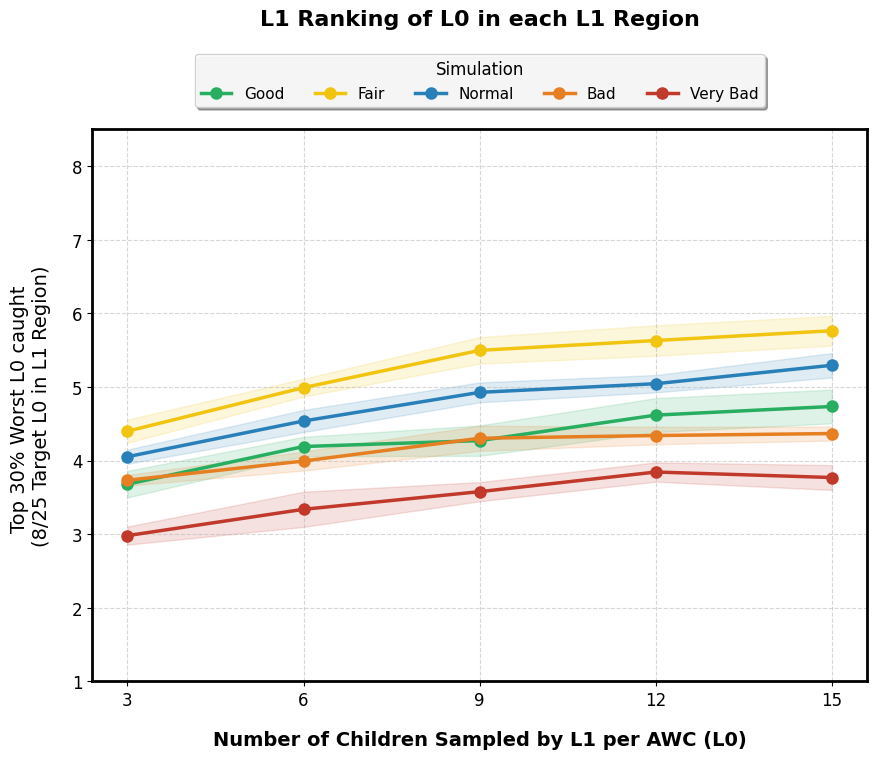

In [51]:
# ranking l0 plot with y axis numbers

import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

# 1. REBUILD THE DATAFRAME WITH THE CORRECT COLUMNS
# This ensures mean_acc and ci_95 exist before we do the math
agg_df = df_results.groupby(['Universe', 'Sample_Size']).agg(
    mean_acc=('Accuracy', 'mean'),
    std_acc=('Accuracy', 'std'),
    count=('Accuracy', 'count')
).reset_index()

# Recalculate the Confidence Interval (95%)
agg_df['ci_95'] = 1.96 * (agg_df['std_acc'] / np.sqrt(agg_df['count']))

# 2. CONVERT PERCENTAGES TO RAW COUNTS (Targeting 8 Clinics)
TARGET_CLINICS = 8
agg_df['mean_acc_count'] = agg_df['mean_acc'] * (TARGET_CLINICS / 100)
agg_df['ci_95_count'] = agg_df['ci_95'] * (TARGET_CLINICS / 100)

# (Now the rest of your plotting code will work perfectly!)
# ==============================================================================
# 3. PLOT THE RESULTS (Raw Count / 8 Clinics)
# Assuming `agg_df`, `datasets_to_run`, `uni_colors`, and `n_children_list` 
# are already in your environment from the previous steps.
# ==============================================================================
print("📊 Generating Intra-Regional Plot (Raw Clinic Count)...")

# --- CONVERT PERCENTAGES TO RAW COUNTS (Targeting 8 Clinics) ---
# This scales your 0-100% scores into 0-8 clinic counts
TARGET_CLINICS = 8
agg_df['mean_acc_count'] = agg_df['mean_acc'] * (TARGET_CLINICS / 100)
agg_df['ci_95_count'] = agg_df['ci_95'] * (TARGET_CLINICS / 100)

FONT_SIZE = 14
lw, ms = 2.5, 8

# Increased figure height slightly to give more breathing room at the top
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
universes = list(datasets_to_run.keys())

for uni in universes:
    data = agg_df[agg_df['Universe'] == uni]
    
    # Plot line with markers using the NEW count-based column
    ax.plot(data['Sample_Size'], data['mean_acc_count'], 
            marker='o', linestyle='-', color=uni_colors[uni], 
            label=uni, lw=lw, ms=ms)
    
    # Add shaded confidence interval using the NEW count-based CI
    ax.fill_between(data['Sample_Size'], 
                    data['mean_acc_count'] - data['ci_95_count'], 
                    data['mean_acc_count'] + data['ci_95_count'], 
                    color=uni_colors[uni], alpha=0.15)

# Styling
ax.set_xlabel('Number of Children Sampled by L1 per AWC (L0)', fontsize=FONT_SIZE, fontweight='bold', labelpad=15)
# Updated Y-axis label to reflect actual counts
ax.set_ylabel(f'Top 30% Worst L0 caught \n({TARGET_CLINICS}/25 Target L0 in L1 Region)', fontsize=FONT_SIZE, labelpad=15)
ax.set_xticks(n_children_list)

# Updated Y-axis limits to frame the 0 to 8 range nicely
ax.set_ylim(1, 8.5) 
ax.tick_params(axis='both', labelsize=FONT_SIZE-2)
ax.grid(True, linestyle='--', alpha=0.5)

# --- BOLD BORDERS ---
border_thickness = 2.0
for spine in ax.spines.values():
    spine.set_linewidth(border_thickness)
    spine.set_color('black')

# --- EXTERNAL TOP LEGEND (FIXED OVERLAP) ---
ax.legend(title='Simulation', bbox_to_anchor=(0.5, 1.15), loc='upper center', 
          ncol=5, fontsize=FONT_SIZE-3, framealpha=0.9, shadow=True, title_fontsize=FONT_SIZE-2)

# Main Title
plt.title("L1 Ranking of L0 in each L1 Region", 
          fontsize=FONT_SIZE+2, fontweight='bold', pad=75)

plt.subplots_adjust(top=0.80) 

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plot_filename = f"Standalone_IntraRegional_RawCounts_{timestamp}.png"
plt.savefig(plot_filename, bbox_inches='tight')

print(f"✅ PLOT SAVED: {plot_filename}")
plt.show()

In [63]:
# ==============================================================================
# 4. PRINT THE CLEAN TERMINAL RESULTS
# ==============================================================================
print("\n" + "=" * 70)
print("📊 FINAL RESULTS: INTRA-REGIONAL L0 RANKING (HEIGHT)")
print("=" * 70)

# Sort exactly how we plotted it
agg_df_sorted = agg_df.sort_values(by=['Universe', 'Sample_Size'])

# Combine Mean and CI into a single clean string
agg_df_sorted['mean_acc_rounded'] = agg_df_sorted['mean_acc'].round(1)
agg_df_sorted['ci_95_rounded'] = agg_df_sorted['ci_95'].round(1)
agg_df_sorted['Accuracy (Mean ± CI)'] = agg_df_sorted['mean_acc_rounded'].astype(str) + "% ± " + agg_df_sorted['ci_95_rounded'].astype(str) + "%"

# Force the specific order from best to worst reality
universes_order = ["Good", "Fair", "Normal", "Bad", "Very Bad"]

for uni in universes_order:
    if uni in agg_df_sorted['Universe'].values:
        print(f"\n🌟 UNIVERSE: {uni.upper()}")
        print("-" * 50)
        
        # Isolate this universe and format columns
        uni_data = agg_df_sorted[agg_df_sorted['Universe'] == uni][['Sample_Size', 'Accuracy (Mean ± CI)']]
        uni_data.columns = ['Kids Sampled per Clinic', 'Accuracy (Mean ± 95% CI)']
        
        print(uni_data.to_string(index=False))


📊 FINAL RESULTS: INTRA-REGIONAL L0 RANKING (HEIGHT)


KeyError: 'mean_acc'

rranking based on other metrics

🚀 INITIATING INTRA-REGIONAL L0 EVALUATION (DUAL METRICS)...

⚙️ Simulating GOOD Universe...


⚙️ Simulating FAIR Universe...


⚙️ Simulating NORMAL Universe...


⚙️ Simulating BAD Universe...


⚙️ Simulating VERY BAD Universe...


📊 Generating 1x2 Metric Comparison Plot...
✅ PLOT SAVED: Standalone_Metrics_Comparison_20260324_213119.png


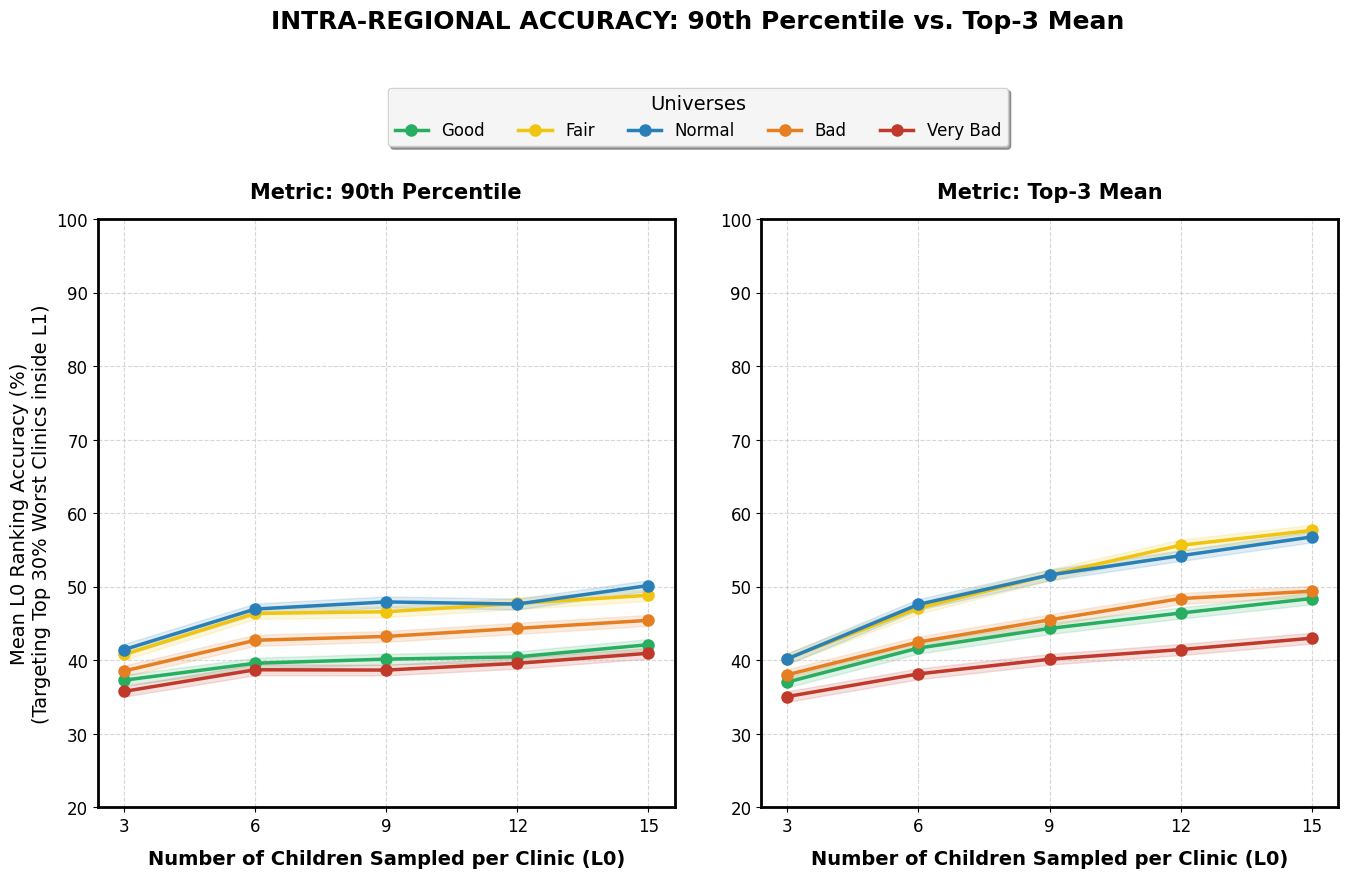

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os
from datetime import datetime

# ==============================================================================
# 1. SETUP THE FILES & COLORS
# ==============================================================================
datasets_to_run = {
    "Good": "sensitivity_dataset_TRUE_Good_20260324_100502.parquet", # Replace with your exact filename
    "Fair": "sensitivity_dataset_Fair_20260323_115454.parquet",
    "Normal": "sensitivity_dataset_Normal_20260323_150757.parquet",
    "Bad": "sensitivity_dataset_Bad_20260323_132920.parquet",
    "Very Bad": "sensitivity_dataset_Very_Bad_20260323_141221.parquet"
}

uni_colors = {
    "Good": "#27ae60", "Fair": "#f1c40f", "Normal": "#2980b9", 
    "Bad": "#e67e22", "Very Bad": "#c0392b"
}

n_children_list = [3, 6, 9, 12, 15] 
n_simulations = 5  
target_percent = 0.30  # Top 30%
methods = ['90th Percentile', 'Top-3 Mean']

master_results = []
print("🚀 INITIATING INTRA-REGIONAL L0 EVALUATION (DUAL METRICS)...\n")

# ==============================================================================
# 2. RUN THE ENGINE (INTRA-REGIONAL RANKING)
# ==============================================================================
for universe_name, file_name in datasets_to_run.items():
    if not os.path.exists(file_name):
        print(f"❌ Error: Cannot find '{file_name}'. Skipping...")
        continue

    print(f"⚙️ Simulating {universe_name.upper()} Universe...")
    df = pd.read_parquet(file_name)

    # Discrepancies
    df['true_fraud_haz'] = np.abs(df['real_haz'] - df['L0_haz'])
    df['meas_fraud_haz_L1'] = np.abs(df['L1_haz'] - df['L0_haz'])

    # --- TRUE RANKING PREPARATION ---
    true_worst_dicts = {m: {} for m in methods}
    target_counts = {}
    
    # Calculate True 90th Percentile
    true_90 = df.groupby(['L1_id', 'L0_id'])['true_fraud_haz'].quantile(0.90).reset_index(name='metric_val')
    true_90['true_rank'] = true_90.groupby('L1_id')['metric_val'].rank(method='first', ascending=False)
    
    # Calculate True Top-3 Mean (Optimized for speed)
    top3_true_df = df.sort_values('true_fraud_haz', ascending=False).groupby(['L1_id', 'L0_id']).head(3)
    true_top3 = top3_true_df.groupby(['L1_id', 'L0_id'])['true_fraud_haz'].mean().reset_index(name='metric_val')
    true_top3['true_rank'] = true_top3.groupby('L1_id')['metric_val'].rank(method='first', ascending=False)
    
    true_dfs = {'90th Percentile': true_90, 'Top-3 Mean': true_top3}

    # Setup the Target Counts and True Worst Sets per method
    n_clinics_per_l1 = true_90.groupby('L1_id')['L0_id'].transform('count')
    
    for l1 in true_90['L1_id'].unique():
        target = np.floor(len(true_90[true_90['L1_id'] == l1]) * target_percent)
        target_counts[l1] = target
        for m in methods:
            m_df = true_dfs[m]
            l1_data = m_df[m_df['L1_id'] == l1]
            true_worst_dicts[m][l1] = set(l1_data[l1_data['true_rank'] <= target]['L0_id'])

    # --- SAMPLING LOOP ---
    for n_kids in tqdm(n_children_list, desc=f"   Sampling", leave=False):
        for sim in range(n_simulations):
            df_sample = df.groupby(['L1_id', 'L0_id']).sample(n=n_kids, replace=True)
            
            # Sampled 90th Percentile
            samp_90 = df_sample.groupby(['L1_id', 'L0_id'])['meas_fraud_haz_L1'].quantile(0.90).reset_index(name='metric_val')
            samp_90['samp_rank'] = samp_90.groupby('L1_id')['metric_val'].rank(method='first', ascending=False)
            
            # Sampled Top-3 Mean
            top3_samp_df = df_sample.sort_values('meas_fraud_haz_L1', ascending=False).groupby(['L1_id', 'L0_id']).head(3)
            samp_top3 = top3_samp_df.groupby(['L1_id', 'L0_id'])['meas_fraud_haz_L1'].mean().reset_index(name='metric_val')
            samp_top3['samp_rank'] = samp_top3.groupby('L1_id')['metric_val'].rank(method='first', ascending=False)
            
            samp_dfs = {'90th Percentile': samp_90, 'Top-3 Mean': samp_top3}
            
            # Calculate Overlaps for both methods
            for m in methods:
                s_df = samp_dfs[m]
                
                for l1 in s_df['L1_id'].unique():
                    target = target_counts[l1]
                    if target > 0:
                        samp_worst = set(s_df[(s_df['L1_id'] == l1) & (s_df['samp_rank'] <= target)]['L0_id'])
                        true_worst = true_worst_dicts[m][l1]
                        accuracy = (len(samp_worst.intersection(true_worst)) / target) * 100
                    else:
                        accuracy = 0
                        
                    master_results.append({
                        'Method': m, 'Universe': universe_name, 'Sample_Size': n_kids,
                        'L1_id': l1, 'Accuracy': accuracy
                    })

# Aggregate Data
df_results = pd.DataFrame(master_results)
agg_df = df_results.groupby(['Method', 'Universe', 'Sample_Size']).agg(
    mean_acc=('Accuracy', 'mean'), std_acc=('Accuracy', 'std'), count=('Accuracy', 'count')
).reset_index()
agg_df['ci_95'] = 1.96 * (agg_df['std_acc'] / np.sqrt(agg_df['count']))

# ==============================================================================
# 3. PLOT THE 1x2 COMPARISON GRID
# ==============================================================================
print("📊 Generating 1x2 Metric Comparison Plot...")
FONT_SIZE = 14
lw, ms = 2.5, 8

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=100)
universes = list(datasets_to_run.keys())

for idx, method in enumerate(methods):
    ax = axes[idx]
    method_data = agg_df[agg_df['Method'] == method]
    
    for uni in universes:
        data = method_data[method_data['Universe'] == uni]
        ax.plot(data['Sample_Size'], data['mean_acc'], 
                marker='o', linestyle='-', color=uni_colors[uni], 
                label=uni, lw=lw, ms=ms)
        ax.fill_between(data['Sample_Size'], 
                        data['mean_acc'] - data['ci_95'], 
                        data['mean_acc'] + data['ci_95'], 
                        color=uni_colors[uni], alpha=0.15)

    # Styling for each panel
    ax.set_title(f"Metric: {method}", fontsize=FONT_SIZE+1, fontweight='bold', pad=15)
    ax.set_xlabel('Number of Children Sampled per Clinic (L0)', fontsize=FONT_SIZE, fontweight='bold', labelpad=10)
    if idx == 0:
        ax.set_ylabel('Mean L0 Ranking Accuracy (%)\n(Targeting Top 30% Worst Clinics inside L1)', fontsize=FONT_SIZE)
    ax.set_xticks(n_children_list)
    ax.set_ylim(20, 100)
    ax.tick_params(axis='both', labelsize=FONT_SIZE-2)
    ax.grid(True, linestyle='--', alpha=0.5)

    # Bold Borders
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
        spine.set_color('black')

# --- EXTERNAL TOP LEGEND (SHARED) ---
# We place one legend centered above both plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Universes', bbox_to_anchor=(0.5, 1.15), loc='upper center', 
           ncol=5, fontsize=FONT_SIZE-2, framealpha=0.9, shadow=True, title_fontsize=FONT_SIZE)

plt.suptitle("INTRA-REGIONAL ACCURACY: 90th Percentile vs. Top-3 Mean", 
             fontsize=FONT_SIZE+4, fontweight='bold', y=1.25)

plt.subplots_adjust(top=0.95, wspace=0.15) 
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plot_filename = f"Standalone_Metrics_Comparison_{timestamp}.png"
plt.savefig(plot_filename, bbox_inches='tight')

print(f"✅ PLOT SAVED: {plot_filename}")
plt.show()

In [42]:
# ==============================================================================
# 4. PRINT AND EXPORT TABULAR RESULTS
# ==============================================================================
print("\n🔄 Formatting tabular results...")

# Pivot the data for a clean side-by-side comparison table
pivot_df = agg_df.pivot(index=['Universe', 'Sample_Size'], columns='Method', values='mean_acc').reset_index()

# Sort logically by Universe severity, then by Sample Size
uni_order = ['Good', 'Fair', 'Normal', 'Bad', 'Very Bad']
pivot_df['Universe'] = pd.Categorical(pivot_df['Universe'], categories=uni_order, ordered=True)
pivot_df = pivot_df.sort_values(['Universe', 'Sample_Size'])

# Save to CSV for Excel/Word
csv_filename = f"IntraRegional_Metrics_Comparison_{timestamp}.csv"
pivot_df.to_csv(csv_filename, index=False)
print(f"✅ DATA SAVED: {csv_filename}\n")

# Print the formatted table to the console
print("=" * 75)
print("📋 INTRA-REGIONAL ACCURACY: 90th Percentile vs Top-3 Mean")
print("=" * 75)
header = f"{'Universe':<12} | {'Sample Size':<12} | {'90th Percentile (%)':<20} | {'Top-3 Mean (%)':<20}"
print(header)
print("-" * 75)

for _, row in pivot_df.iterrows():
    # Adding a visual separator between different Universes for readability
    if row['Sample_Size'] == 3 and row['Universe'] != 'Good':
        print("-" * 75)
        
    print(f"{row['Universe']:<12} | "
          f"{row['Sample_Size']:<12} | "
          f"{row['90th Percentile']:<20.1f} | "
          f"{row['Top-3 Mean']:<20.1f}")
          
print("=" * 75)


🔄 Formatting tabular results...
✅ DATA SAVED: IntraRegional_Metrics_Comparison_20260324_213119.csv

📋 INTRA-REGIONAL ACCURACY: 90th Percentile vs Top-3 Mean
Universe     | Sample Size  | 90th Percentile (%)  | Top-3 Mean (%)      
---------------------------------------------------------------------------
Good         | 3            | 37.3                 | 37.0                
Good         | 6            | 39.6                 | 41.7                
Good         | 9            | 40.2                 | 44.3                
Good         | 12           | 40.5                 | 46.4                
Good         | 15           | 42.1                 | 48.4                
---------------------------------------------------------------------------
Fair         | 3            | 40.8                 | 40.3                
Fair         | 6            | 46.4                 | 47.1                
Fair         | 9            | 46.6                 | 51.6                
Fair         | 12       

In [46]:
#checkin top 10 worst & Best child measurements

import pandas as pd
import numpy as np
import os
from datetime import datetime

# ==============================================================================
# 1. SETUP THE FILE
# ==============================================================================
# Make sure this matches your perfect L2 filename
file_name = "sensitivity_dataset_PERFECT_L2_20260324_174312.parquet" 

if not os.path.exists(file_name):
    print(f"❌ Error: Cannot find '{file_name}'. Please check the filename.")
else:
    print(f"🔍 LOADING DATA: {file_name}\n")
    df = pd.read_parquet(file_name)

    # Calculate the True Discrepancy (The Ground Truth Fraud)
    df['true_fraud_haz'] = np.abs(df['real_haz'] - df['L0_haz'])

    # ==========================================================================
    # 2. FIND THE WORST L1 REGION
    # ==========================================================================
    l1_means = df.groupby('L1_id')['true_fraud_haz'].mean()
    worst_l1_id = l1_means.idxmax()
    worst_l1_score = l1_means.max()

    print("=" * 90)
    print(f"🚨 STEP 1: FOUND WORST L1 REGION -> {worst_l1_id} (Average Discrepancy: {worst_l1_score:.2f})")
    
    # Filter the dataset to ONLY look inside this specific L1 Region
    df_l1 = df[df['L1_id'] == worst_l1_id]

    # ==========================================================================
    # 3. FIND THE WORST L0 CLINIC INSIDE THAT REGION
    # ==========================================================================
    l0_means = df_l1.groupby('L0_id')['true_fraud_haz'].mean()
    worst_l0_id = l0_means.idxmax()
    worst_l0_score = l0_means.max()

    print(f"🚨 STEP 2: FOUND WORST L0 CLINIC IN THIS REGION -> {worst_l0_id} (Average Discrepancy: {worst_l0_score:.2f})")
    
    # Filter the dataset again to ONLY look inside this specific L0 Clinic
    df_l0 = df_l1[df_l1['L0_id'] == worst_l0_id]

    # ==========================================================================
    # 4. PRINT & SAVE THE TOP 10 WORST MEASUREMENTS
    # ==========================================================================
    print(f"\n🚨 STEP 3: TOP 10 WORST MEASUREMENTS IN CLINIC {worst_l0_id}")
    print("=" * 90)
    
    top_10_kids = df_l0.sort_values(by='true_fraud_haz', ascending=False).head(10)
    display_cols_worst = top_10_kids[['child_id', 'real_haz', 'L0_haz', 'L1_haz', 'L2_haz', 'true_fraud_haz']]
    display_cols_worst.columns = ['Child ID', 'Real HAZ', 'L0 (Worker)', 'L1 (Super)', 'L2 (Audit)', 'Discrepancy']
    
    print(display_cols_worst.round(2).to_string(index=False))
    
    # ==========================================================================
    # 5. PRINT & SAVE THE TOP 10 BEST MEASUREMENTS
    # ==========================================================================
    print(f"\n🌟 STEP 4: TOP 10 BEST MEASUREMENTS IN CLINIC {worst_l0_id}")
    print("Showing the kids where the worker told the truth (The 'Dilution' Source)")
    print("=" * 90)
    
    best_10_kids = df_l0.sort_values(by='true_fraud_haz', ascending=True).head(10)
    display_cols_best = best_10_kids[['child_id', 'real_haz', 'L0_haz', 'L1_haz', 'L2_haz', 'true_fraud_haz']]
    display_cols_best.columns = ['Child ID', 'Real HAZ', 'L0 (Worker)', 'L1 (Super)', 'L2 (Audit)', 'Discrepancy']
    
    print(display_cols_best.round(2).to_string(index=False))
    print("=" * 90)

    # ==========================================================================
    # 6. EXPORT TO CSV
    # ==========================================================================
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    worst_filename = f"Worst_10_Measurements_{worst_l0_id}_{timestamp}.csv"
    best_filename = f"Best_10_Measurements_{worst_l0_id}_{timestamp}.csv"
    
    display_cols_worst.round(2).to_csv(worst_filename, index=False)
    display_cols_best.round(2).to_csv(best_filename, index=False)
    
    print(f"\n✅ DATA SAVED SUCCESSFULLY:")
    print(f"   -> {worst_filename}")
    print(f"   -> {best_filename}")

🔍 LOADING DATA: sensitivity_dataset_PERFECT_L2_20260324_174312.parquet

🚨 STEP 1: FOUND WORST L1 REGION -> L1_5 (Average Discrepancy: 0.39)
🚨 STEP 2: FOUND WORST L0 CLINIC IN THIS REGION -> L0_23 (Average Discrepancy: 0.67)

🚨 STEP 3: TOP 10 WORST MEASUREMENTS IN CLINIC L0_23
           Child ID  Real HAZ  L0 (Worker)  L1 (Super)  L2 (Audit)  Discrepancy
 L1_5_L0_23_child_0     -3.47        -0.75       -3.80       -3.66         2.72
 L1_5_L0_23_child_6     -3.74        -1.88       -2.09       -3.89         1.85
L1_5_L0_23_child_11     -2.76        -1.48       -2.96       -2.92         1.28
 L1_5_L0_23_child_7     -2.85        -1.57       -3.00       -3.02         1.28
 L1_5_L0_23_child_4     -2.08        -1.61       -2.49       -2.29         0.47
 L1_5_L0_23_child_1     -1.04        -1.46       -0.84       -1.21         0.42
L1_5_L0_23_child_13     -0.51        -0.84       -0.49       -0.68         0.34
 L1_5_L0_23_child_8     -0.51        -0.19       -0.36       -0.51         0.32
 L1

⚙️ Processing Height Simulation for: GOOD Universe...
⚙️ Processing Height Simulation for: FAIR Universe...
⚙️ Processing Height Simulation for: NORMAL Universe...
⚙️ Processing Height Simulation for: BAD Universe...
⚙️ Processing Height Simulation for: VERY BAD Universe...

📊 HEIGHT (HAZ) SENSITIVITY OVERLAP RESULTS (Targeting Top 100 Regions)
 n_children_L1  Good_Overlap  Fair_Overlap  Normal_Overlap  Bad_Overlap  Very Bad_Overlap
             3          51.9          52.6            51.6         45.3              38.5
             6          56.6          59.0            56.7         50.0              41.1
             9          60.7          63.1            58.7         51.6              42.6
            12          61.2          65.9            61.8         53.2              43.9
            15          62.6          65.7            63.2         54.9              43.7

✅ Combined Plot Saved: combined_height_sensitivity_plot_20260324_081704.png


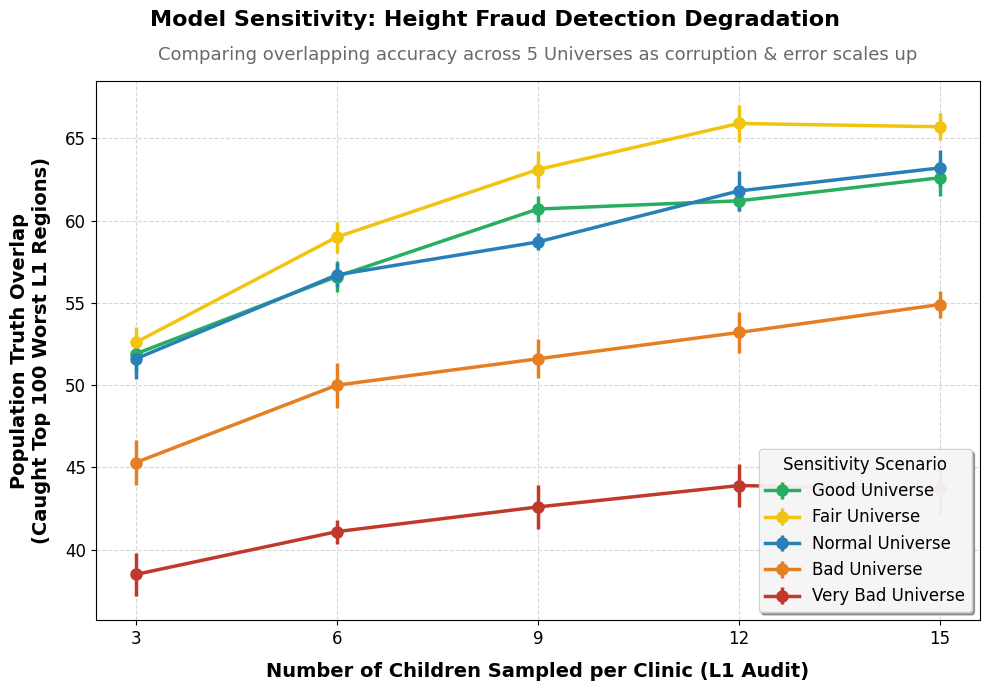

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os
from datetime import datetime

# ==============================================================================
# 1. SETUP THE FILES & COLORS
# ==============================================================================
# Make sure these match your actual generated filenames!
datasets_to_run = {
    "Good": "sensitivity_dataset_Good_20260323_151116.parquet",
    "Fair": "sensitivity_dataset_Fair_20260323_115454.parquet",
    "Normal": "sensitivity_dataset_Normal_20260323_150757.parquet",
    "Bad": "sensitivity_dataset_Bad_20260323_132920.parquet",
    "Very Bad": "sensitivity_dataset_Very_Bad_20260323_141221.parquet"
}

# Color gradient from Utopia (Green) to Systemic Collapse (Red)
colors = {
    "Good": "#27ae60",     # Green
    "Fair": "#f1c40f",     # Yellow
    "Normal": "#2980b9",   # Blue
    "Bad": "#e67e22",      # Orange
    "Very Bad": "#c0392b"  # Red
}

n_children_list = [3, 6, 9, 12, 15] 
n_simulations = 10 
target_count = 100  

master_results = {}
summary_table_data = {'n_children_L1': n_children_list}

# ==============================================================================
# 2. RUN THE ENGINE FOR HEIGHT (HAZ) ONLY
# ==============================================================================
for name, file_name in datasets_to_run.items():
    if not os.path.exists(file_name):
        print(f"❌ Error: Cannot find '{file_name}'. Skipping...")
        continue

    print(f"⚙️ Processing Height Simulation for: {name.upper()} Universe...")
    df = pd.read_parquet(file_name)

    # Focus ONLY on HAZ
    if 'true_fraud_haz' not in df.columns:
        df['true_fraud_haz'] = np.abs(df['real_haz'] - df['L0_haz'])
        # NOTE: If you want to use L2 measurements later, change 'L1_haz' to 'L2_haz' here!
        df['measured_fraud_haz'] = np.abs(df['L1_haz'] - df['L0_haz'])

    # 1. Population Anchor
    pop_means = df.groupby('L1_id')['true_fraud_haz'].mean().reset_index()
    pop_means['pop_rank_ht'] = pop_means['true_fraud_haz'].rank(method='first', ascending=False)
    true_top_100_ht = set(pop_means[pop_means['pop_rank_ht'] <= target_count]['L1_id'])

    # 2. Sample Predictions
    overlap_results = []
    for n_kids in n_children_list:
        for _ in range(n_simulations):
            df_sample = df.groupby(['L1_id', 'L0_id']).sample(n=n_kids, replace=True)
            l0_means = df_sample.groupby(['L1_id', 'L0_id'])['measured_fraud_haz'].mean().reset_index()
            l1_means = l0_means.groupby('L1_id')['measured_fraud_haz'].mean().reset_index()
            l1_means['samp_rank_ht_meas'] = l1_means['measured_fraud_haz'].rank(method='first', ascending=False)
            
            flagged_ht_meas = set(l1_means[l1_means['samp_rank_ht_meas'] <= target_count]['L1_id'])
            ht_overlap = len(flagged_ht_meas.intersection(true_top_100_ht))
            overlap_results.append({'n_children_L1': n_kids, 'overlap': ht_overlap})

    # 3. Format Results
    temp = pd.DataFrame(overlap_results).groupby('n_children_L1').agg(['mean', 'sem']).reset_index()
    temp.columns = ['n_children_L1', 'mean', 'sem']
    master_results[name] = temp
    
    # Add to summary table for printing
    summary_table_data[f"{name}_Overlap"] = temp['mean'].round(1)

# ==============================================================================
# 3. PRINT THE RESULTS TABLE
# ==============================================================================
summary_df = pd.DataFrame(summary_table_data)
print("\n" + "="*80)
print("📊 HEIGHT (HAZ) SENSITIVITY OVERLAP RESULTS (Targeting Top 100 Regions)")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80 + "\n")

# Save combined table to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
summary_df.to_csv(f"combined_height_sensitivity_results_{timestamp}.csv", index=False)

# ==============================================================================
# 4. PLOT THE MASTER COMPARISON GRAPH
# ==============================================================================
FONT_SIZE = 14
fig, ax = plt.subplots(figsize=(10, 7), dpi=100)

lw, ms = 2.5, 8

# Plot each universe on the same axes
for name in master_results.keys():
    data = master_results[name]
    ax.errorbar(data['n_children_L1'], data['mean'], yerr=data['sem'], 
                fmt='o-', color=colors[name], label=f'{name} Universe', lw=lw, ms=ms)

ax.set_xlabel('Number of Children Sampled per Clinic (L1 Audit)', fontsize=FONT_SIZE, fontweight='bold', labelpad=10)
ax.set_ylabel(f'Population Truth Overlap\n(Caught Top {target_count} Worst L1 Regions)', fontsize=FONT_SIZE, fontweight='bold', labelpad=10)
ax.set_xticks(n_children_list)
ax.tick_params(axis='both', labelsize=FONT_SIZE-2)
ax.grid(True, linestyle='--', alpha=0.5)

# Add a prominent legend
ax.legend(title='Sensitivity Scenario', title_fontsize=FONT_SIZE-2, loc='lower right', fontsize=FONT_SIZE-2, framealpha=0.9, shadow=True)

plt.suptitle("Model Sensitivity: Height Fraud Detection Degradation", fontsize=FONT_SIZE+2, fontweight='bold')
plt.title("Comparing overlapping accuracy across 5 Universes as corruption & error scales up", fontsize=FONT_SIZE-1, color='dimgrey', pad=15)

plt.tight_layout()

plot_filename = f"combined_height_sensitivity_plot_{timestamp}.png"
plt.savefig(plot_filename, bbox_inches='tight')
print(f"✅ Combined Plot Saved: {plot_filename}")
plt.show()

📈 Building Combined Height Graph from exact saved CSVs...
✅ Loaded Good from: c3_results_Good_20260324_080040.csv
✅ Loaded Fair from: c3_results_Fair_20260324_080157.csv
✅ Loaded Normal from: c3_results_Normal_20260324_080317.csv
✅ Loaded Bad from: c3_results_Bad_20260324_080444.csv
✅ Loaded Very Bad from: c3_results_Very Bad_20260324_080606.csv

✅ Combined Plot Saved: combined_height_sensitivity_plot_20260324_084532.png


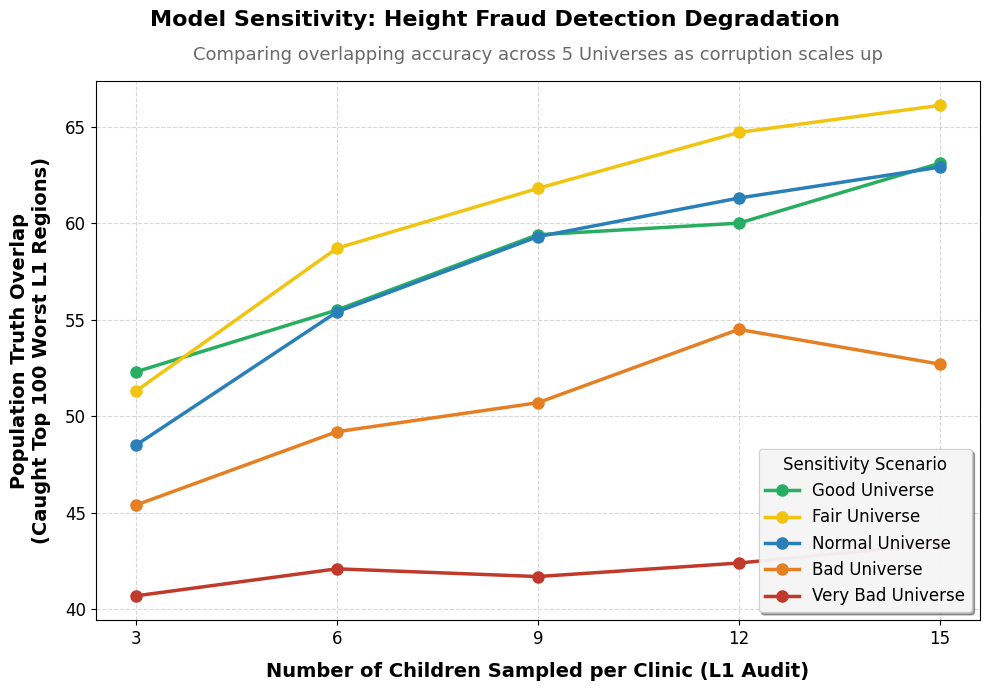

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from datetime import datetime

# ==============================================================================
# 1. HARDCODED CSV FILE NAMES (Locked to your successful run)
# ==============================================================================
results_csvs = {
    "Good": "c3_results_Good_20260324_080040.csv",       
    "Fair": "c3_results_Fair_20260324_080157.csv",     
    "Normal": "c3_results_Normal_20260324_080317.csv",   
    "Bad": "c3_results_Bad_20260324_080444.csv",         
    "Very Bad": "c3_results_Very Bad_20260324_080606.csv" 
}

colors = {
    "Good": "#27ae60",     # Green
    "Fair": "#f1c40f",     # Yellow
    "Normal": "#2980b9",   # Blue
    "Bad": "#e67e22",      # Orange
    "Very Bad": "#c0392b"  # Red
}

FONT_SIZE = 14
fig, ax = plt.subplots(figsize=(10, 7), dpi=100)
lw, ms = 2.5, 8
target_count = 100

print("📈 Building Combined Height Graph from exact saved CSVs...")

# ==============================================================================
# 2. LOAD & PLOT
# ==============================================================================
successful_plots = 0

for name, file_name in results_csvs.items():
    if not os.path.exists(file_name):
        print(f"❌ Cannot find '{file_name}'. Make sure it is in the same folder!")
        continue
        
    print(f"✅ Loaded {name} from: {file_name}")
    
    # Read the tiny pre-calculated CSV
    df_res = pd.read_csv(file_name)
    
    # Plot the Height_Reality column
    ax.plot(df_res['n_children_L1'], df_res['Height_Reality'], 
            marker='o', color=colors[name], label=f'{name} Universe', lw=lw, ms=ms)
    successful_plots += 1

if successful_plots > 0:
    ax.set_xlabel('Number of Children Sampled per Clinic (L1 Audit)', fontsize=FONT_SIZE, fontweight='bold', labelpad=10)
    ax.set_ylabel(f'Population Truth Overlap\n(Caught Top {target_count} Worst L1 Regions)', fontsize=FONT_SIZE, fontweight='bold', labelpad=10)

    # Set X-ticks based on the data
    ax.set_xticks([3, 6, 9, 12, 15])
    ax.tick_params(axis='both', labelsize=FONT_SIZE-2)
    ax.grid(True, linestyle='--', alpha=0.5)

    ax.legend(title='Sensitivity Scenario', title_fontsize=FONT_SIZE-2, loc='lower right', fontsize=FONT_SIZE-2, framealpha=0.9, shadow=True)

    plt.suptitle("Model Sensitivity: Height Fraud Detection Degradation", fontsize=FONT_SIZE+2, fontweight='bold')
    plt.title("Comparing overlapping accuracy across 5 Universes as corruption scales up", fontsize=FONT_SIZE-1, color='dimgrey', pad=15)

    plt.tight_layout()

    # Save final plot
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plot_filename = f"combined_height_sensitivity_plot_{timestamp}.png"
    plt.savefig(plot_filename, bbox_inches='tight')
    print(f"\n✅ Combined Plot Saved: {plot_filename}")
    plt.show()
else:
    print("\n⚠️ No data was plotted. Please check the filenames and folder location.")

⚙️ Processing L1 vs L2 Height Simulation for: GOOD Universe...
⚙️ Processing L1 vs L2 Height Simulation for: FAIR Universe...
⚙️ Processing L1 vs L2 Height Simulation for: NORMAL Universe...
⚙️ Processing L1 vs L2 Height Simulation for: BAD Universe...
⚙️ Processing L1 vs L2 Height Simulation for: VERY BAD Universe...

📊 VALIDATION: L1 (SUPERVISOR) vs L2 (AUDITOR) ACCURACY (Sample = 15 Kids)
Good       Universe | L1 Accuracy: 62.7%  -->  L2 Accuracy: 70.4%  (Gain: +7.7%)
Fair       Universe | L1 Accuracy: 66.5%  -->  L2 Accuracy: 68.7%  (Gain: +2.2%)
Normal     Universe | L1 Accuracy: 61.1%  -->  L2 Accuracy: 70.0%  (Gain: +8.9%)
Bad        Universe | L1 Accuracy: 54.1%  -->  L2 Accuracy: 67.1%  (Gain: +13.0%)
Very Bad   Universe | L1 Accuracy: 43.9%  -->  L2 Accuracy: 64.2%  (Gain: +20.3%)

✅ L2 Combined Plot Saved: combined_L2_height_sensitivity_plot_20260324_085859.png


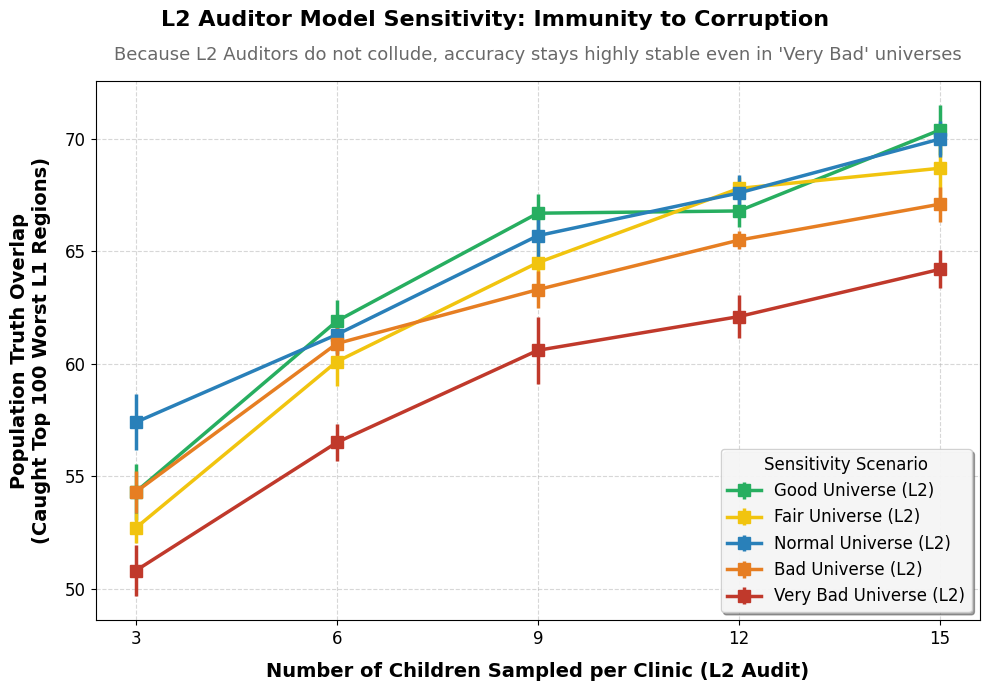

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os
from datetime import datetime

# ==============================================================================
# 1. SETUP THE FILES & COLORS
# ==============================================================================
datasets_to_run = {
    "Good": "sensitivity_dataset_Good_20260323_151116.parquet",
    "Fair": "sensitivity_dataset_Fair_20260323_115454.parquet",
    "Normal": "sensitivity_dataset_Normal_20260323_150757.parquet",
    "Bad": "sensitivity_dataset_Bad_20260323_132920.parquet",
    "Very Bad": "sensitivity_dataset_Very_Bad_20260323_141221.parquet"
}

colors = {
    "Good": "#27ae60",     # Green
    "Fair": "#f1c40f",     # Yellow
    "Normal": "#2980b9",   # Blue
    "Bad": "#e67e22",      # Orange
    "Very Bad": "#c0392b"  # Red
}

n_children_list = [3, 6, 9, 12, 15] 
n_simulations = 10 
target_count = 100  

master_results = {}
summary_table_data = {'n_children': n_children_list}

# ==============================================================================
# 2. RUN THE DUAL ENGINE (L1 AND L2)
# ==============================================================================
for name, file_name in datasets_to_run.items():
    if not os.path.exists(file_name):
        print(f"❌ Error: Cannot find '{file_name}'. Skipping...")
        continue

    print(f"⚙️ Processing L1 vs L2 Height Simulation for: {name.upper()} Universe...")
    df = pd.read_parquet(file_name)

    # Calculate both measured frauds simultaneously!
    df['true_fraud_haz'] = np.abs(df['real_haz'] - df['L0_haz'])
    df['meas_fraud_haz_L1'] = np.abs(df['L1_haz'] - df['L0_haz'])
    df['meas_fraud_haz_L2'] = np.abs(df['L2_haz'] - df['L0_haz'])

    # 1. Population Anchor
    pop_means = df.groupby('L1_id')['true_fraud_haz'].mean().reset_index()
    pop_means['pop_rank_ht'] = pop_means['true_fraud_haz'].rank(method='first', ascending=False)
    true_top_100_ht = set(pop_means[pop_means['pop_rank_ht'] <= target_count]['L1_id'])

    # 2. Sample Predictions
    overlap_results = []
    for n_kids in n_children_list:
        for _ in range(n_simulations):
            df_sample = df.groupby(['L1_id', 'L0_id']).sample(n=n_kids, replace=True)
            
            # Aggregate means up the chain
            l0_means = df_sample.groupby(['L1_id', 'L0_id'])[['meas_fraud_haz_L1', 'meas_fraud_haz_L2']].mean().reset_index()
            l1_means = l0_means.groupby('L1_id')[['meas_fraud_haz_L1', 'meas_fraud_haz_L2']].mean().reset_index()
            
            # Rank both
            l1_means['rank_L1'] = l1_means['meas_fraud_haz_L1'].rank(method='first', ascending=False)
            l1_means['rank_L2'] = l1_means['meas_fraud_haz_L2'].rank(method='first', ascending=False)
            
            # Calculate overlap for both
            flagged_L1 = set(l1_means[l1_means['rank_L1'] <= target_count]['L1_id'])
            flagged_L2 = set(l1_means[l1_means['rank_L2'] <= target_count]['L1_id'])
            
            overlap_results.append({
                'n_children': n_kids, 
                'overlap_L1': len(flagged_L1.intersection(true_top_100_ht)),
                'overlap_L2': len(flagged_L2.intersection(true_top_100_ht))
            })

    # 3. Format Results
    temp = pd.DataFrame(overlap_results).groupby('n_children').agg(['mean', 'sem']).reset_index()
    temp.columns = ['n_children', 'L1_mean', 'L1_sem', 'L2_mean', 'L2_sem']
    master_results[name] = temp
    
    # Store just the means for the summary table
    summary_table_data[f"{name}_L1"] = temp['L1_mean'].round(1)
    summary_table_data[f"{name}_L2"] = temp['L2_mean'].round(1)

# ==============================================================================
# 3. PRINT THE COMPARISON TABLE
# ==============================================================================
summary_df = pd.DataFrame(summary_table_data)

print("\n" + "="*80)
print("📊 VALIDATION: L1 (SUPERVISOR) vs L2 (AUDITOR) ACCURACY (Sample = 15 Kids)")
print("="*80)
for name in datasets_to_run.keys():
    if f"{name}_L1" in summary_df.columns:
        l1_acc = summary_df[f"{name}_L1"].iloc[-1]
        l2_acc = summary_df[f"{name}_L2"].iloc[-1]
        diff = round(l2_acc - l1_acc, 1)
        print(f"{name.ljust(10)} Universe | L1 Accuracy: {l1_acc}%  -->  L2 Accuracy: {l2_acc}%  (Gain: +{diff}%)")
print("="*80 + "\n")

# Save combined dual-table to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
summary_df.to_csv(f"combined_L1_vs_L2_height_results_{timestamp}.csv", index=False)

# ==============================================================================
# 4. PLOT THE MASTER L2 COMPARISON GRAPH
# ==============================================================================
FONT_SIZE = 14
fig, ax = plt.subplots(figsize=(10, 7), dpi=100)
lw, ms = 2.5, 8

# Plot the L2 (Auditor) accuracy across all universes
for name in master_results.keys():
    data = master_results[name]
    ax.errorbar(data['n_children'], data['L2_mean'], yerr=data['L2_sem'], 
                fmt='s-', color=colors[name], label=f'{name} Universe (L2)', lw=lw, ms=ms)

ax.set_xlabel('Number of Children Sampled per Clinic (L2 Audit)', fontsize=FONT_SIZE, fontweight='bold', labelpad=10)
ax.set_ylabel(f'Population Truth Overlap\n(Caught Top {target_count} Worst L1 Regions)', fontsize=FONT_SIZE, fontweight='bold', labelpad=10)
ax.set_xticks(n_children_list)
ax.tick_params(axis='both', labelsize=FONT_SIZE-2)
ax.grid(True, linestyle='--', alpha=0.5)

ax.legend(title='Sensitivity Scenario', title_fontsize=FONT_SIZE-2, loc='lower right', fontsize=FONT_SIZE-2, framealpha=0.9, shadow=True)

plt.suptitle("L2 Auditor Model Sensitivity: Immunity to Corruption", fontsize=FONT_SIZE+2, fontweight='bold')
plt.title("Because L2 Auditors do not collude, accuracy stays highly stable even in 'Very Bad' universes", fontsize=FONT_SIZE-1, color='dimgrey', pad=15)

plt.tight_layout()

plot_filename = f"combined_L2_height_sensitivity_plot_{timestamp}.png"
plt.savefig(plot_filename, bbox_inches='tight')
print(f"✅ L2 Combined Plot Saved: {plot_filename}")
plt.show()

In [10]:
import pandas as pd

# 1. Load the Very Bad universe (Update the filename if needed)
file_name = "sensitivity_dataset_Very_Bad_20260323_141221.parquet"
df = pd.read_parquet(file_name)

# 2. Hunt for the "Smoking Gun" Fraud
# - Child is actually stunted (True HAZ < -2.0)
# - Worker faked it to look healthy (L0 HAZ >= -2.0)
# - Supervisor colluded or ghost-audited (L1 exactly matches faked L0)
smoking_guns = df[
    (df['real_haz'] < -2.0) & 
    (df['L0_haz'] >= -2.0) & 
    (df['L1_haz'] == df['L0_haz'])
].copy()

# 3. Select the relevant columns and round to 2 decimal places
cols_to_show = ['L1_id', 'L0_id', 'child_id', 'real_haz', 'L0_haz', 'L1_haz', 'L2_haz']
sample_df = smoking_guns[cols_to_show].head(10).round(2)

print("🕵️‍♂️ SMOKING GUN DATA SAMPLES (Very Bad Universe)")
print("Children who are actually stunted, but covered up by BOTH the Worker and Supervisor:\n")
print(sample_df.to_string(index=False))

🕵️‍♂️ SMOKING GUN DATA SAMPLES (Very Bad Universe)
Children who are actually stunted, but covered up by BOTH the Worker and Supervisor:

Empty DataFrame
Columns: [L1_id, L0_id, child_id, real_haz, L0_haz, L1_haz, L2_haz]
Index: []


In [11]:
import pandas as pd

# 1. Load the Very Bad universe 
file_name = "sensitivity_dataset_Very_Bad_20260323_141221.parquet" # Update if needed
df = pd.read_parquet(file_name)

# 2. Hunt for the "Smoking Gun" Fraud (The robust way)
# - Biology: Child is actually stunted (True HAZ < -2.0)
# - Worker: Faked it to look healthy (L0 HAZ >= -2.0)
# - Supervisor: Also reported them as healthy (L1 HAZ >= -2.0)
# - Auditor: Found the truth (L2 HAZ < -2.0)
smoking_guns = df[
    (df['real_haz'] < -2.0) & 
    (df['L0_haz'] >= -2.0) & 
    (df['L1_haz'] >= -2.0) &
    (df['L2_haz'] < -2.0)
].copy()

# 3. Select the relevant columns and round to 2 decimal places for easy reading
cols_to_show = ['L1_id', 'L0_id', 'child_id', 'real_haz', 'L0_haz', 'L1_haz', 'L2_haz']
sample_df = smoking_guns[cols_to_show].head(10).round(2)

print("🕵️‍♂️ SMOKING GUN DATA SAMPLES (Very Bad Universe)")
print("Children who are biologically stunted, but passed by BOTH the Worker and Supervisor:\n")
print(sample_df.to_string(index=False))

🕵️‍♂️ SMOKING GUN DATA SAMPLES (Very Bad Universe)
Children who are biologically stunted, but passed by BOTH the Worker and Supervisor:

L1_id L0_id            child_id  real_haz  L0_haz  L1_haz  L2_haz
 L1_0  L0_2   L1_0_L0_2_child_8     -2.48   -1.99   -0.61   -2.95
 L1_0  L0_3   L1_0_L0_3_child_1     -2.82   -1.44   -1.68   -3.42
 L1_0  L0_3  L1_0_L0_3_child_11     -2.48   -1.72   -0.38   -2.26
 L1_0  L0_7   L1_0_L0_7_child_9     -2.34   -1.96   -1.90   -2.40
 L1_0 L0_11  L1_0_L0_11_child_9     -2.31   -1.67   -1.84   -2.63
 L1_0 L0_13  L1_0_L0_13_child_3     -2.77   -1.62   -1.86   -2.83
 L1_0 L0_13  L1_0_L0_13_child_7     -3.47   -1.83   -0.99   -3.83
 L1_0 L0_13 L1_0_L0_13_child_12     -3.14   -1.92   -1.78   -3.75
 L1_0 L0_13 L1_0_L0_13_child_13     -3.87   -1.85   -1.99   -4.40
 L1_0 L0_15  L1_0_L0_15_child_3     -2.19   -1.98   -1.93   -2.37


🔍 Running global sanity check on Height (HAZ) deviations...

📏 AVERAGE DEVIATION FROM BIOLOGICAL TRUTH (IN HAZ SCORES)
Universe  L0_Deviation  L1_Deviation  L2_Deviation
    Good         0.346         0.320         0.280
    Fair         0.327         0.295         0.280
  Normal         0.346         0.320         0.280
     Bad         0.344         0.357         0.280
Very Bad         0.353         0.399         0.279

✅ Sanity Check Plot Saved: universe_sanity_check_haz.png


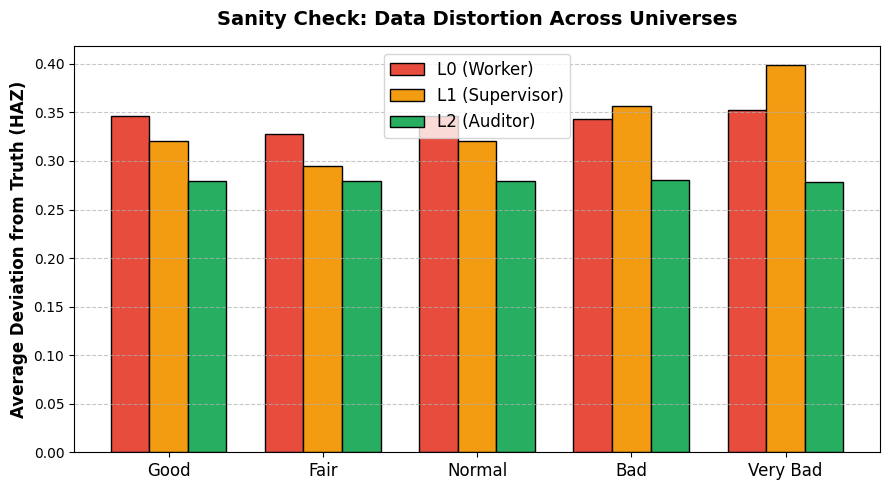

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ==============================================================================
# 1. SETUP THE FILES 
# ==============================================================================
datasets_to_run = {
    "Good": "sensitivity_dataset_Good_20260323_151116.parquet",
    "Fair": "sensitivity_dataset_Fair_20260323_115454.parquet",
    "Normal": "sensitivity_dataset_Normal_20260323_150757.parquet",
    "Bad": "sensitivity_dataset_Bad_20260323_132920.parquet",
    "Very Bad": "sensitivity_dataset_Very_Bad_20260323_141221.parquet"
}

sanity_results = []

print("🔍 Running global sanity check on Height (HAZ) deviations...")

# ==============================================================================
# 2. CALCULATE MEAN ABSOLUTE DEVIATION FROM TRUTH
# ==============================================================================
for name, file_name in datasets_to_run.items():
    if not os.path.exists(file_name):
        print(f"❌ Cannot find '{file_name}'. Skipping...")
        continue
        
    df = pd.read_parquet(file_name)
    
    # Calculate the average distance from the biological truth
    l0_mae = np.abs(df['L0_haz'] - df['real_haz']).mean()
    l1_mae = np.abs(df['L1_haz'] - df['real_haz']).mean()
    l2_mae = np.abs(df['L2_haz'] - df['real_haz']).mean()
    
    sanity_results.append({
        "Universe": name,
        "L0_Deviation": l0_mae,
        "L1_Deviation": l1_mae,
        "L2_Deviation": l2_mae
    })

# ==============================================================================
# 3. PRINT RESULTS TABLE
# ==============================================================================
sanity_df = pd.DataFrame(sanity_results)

print("\n" + "="*70)
print("📏 AVERAGE DEVIATION FROM BIOLOGICAL TRUTH (IN HAZ SCORES)")
print("="*70)
print(sanity_df.round(3).to_string(index=False))
print("="*70 + "\n")

# ==============================================================================
# 4. PLOT THE SANITY CHECK GRAPH
# ==============================================================================
FONT_SIZE = 12
fig, ax = plt.subplots(figsize=(9, 5), dpi=100)

x = np.arange(len(sanity_df['Universe']))
width = 0.25  

# Plot grouped bars
ax.bar(x - width, sanity_df['L0_Deviation'], width, label='L0 (Worker)', color='#e74c3c', edgecolor='black')
ax.bar(x, sanity_df['L1_Deviation'], width, label='L1 (Supervisor)', color='#f39c12', edgecolor='black')
ax.bar(x + width, sanity_df['L2_Deviation'], width, label='L2 (Auditor)', color='#27ae60', edgecolor='black')

ax.set_ylabel('Average Deviation from Truth (HAZ)', fontsize=FONT_SIZE, fontweight='bold')
ax.set_title('Sanity Check: Data Distortion Across Universes', fontsize=FONT_SIZE+2, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(sanity_df['Universe'], fontsize=FONT_SIZE)
ax.legend(fontsize=FONT_SIZE)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("universe_sanity_check_haz.png", bbox_inches='tight')
print("✅ Sanity Check Plot Saved: universe_sanity_check_haz.png")
plt.show()

In [13]:
import pandas as pd
import numpy as np

datasets_to_run = {
    "Good": "sensitivity_dataset_Good_20260323_151116.parquet",
    "Fair": "sensitivity_dataset_Fair_20260323_115454.parquet",
    "Normal": "sensitivity_dataset_Normal_20260323_150757.parquet",
    "Bad": "sensitivity_dataset_Bad_20260323_132920.parquet",
    "Very Bad": "sensitivity_dataset_Very_Bad_20260323_141221.parquet"
}

sanity_results = []

print("🔍 Running TARGETED sanity check (Only on Stunted Children)...")

for name, file_name in datasets_to_run.items():
    df = pd.read_parquet(file_name)
    
    # 🚨 FILTER ONLY THE TRULY STUNTED CHILDREN 🚨
    stunted_df = df[df['real_haz'] < -2.0].copy()
    
    # Calculate MAE only for the kids who actually needed help
    l0_mae = np.abs(stunted_df['L0_haz'] - stunted_df['real_haz']).mean()
    l1_mae = np.abs(stunted_df['L1_haz'] - stunted_df['real_haz']).mean()
    l2_mae = np.abs(stunted_df['L2_haz'] - stunted_df['real_haz']).mean()
    
    sanity_results.append({
        "Universe": name,
        "L0_Deviation": l0_mae,
        "L1_Deviation": l1_mae,
        "L2_Deviation": l2_mae
    })

sanity_df = pd.DataFrame(sanity_results)
print("\n" + "="*70)
print("📏 DEVIATION FROM TRUTH (ONLY FOR STUNTED CHILDREN)")
print("="*70)
print(sanity_df.round(3).to_string(index=False))
print("="*70 + "\n")

🔍 Running TARGETED sanity check (Only on Stunted Children)...

📏 DEVIATION FROM TRUTH (ONLY FOR STUNTED CHILDREN)
Universe  L0_Deviation  L1_Deviation  L2_Deviation
    Good         0.465         0.346         0.281
    Fair         0.457         0.302         0.280
  Normal         0.465         0.346         0.281
     Bad         0.449         0.400         0.281
Very Bad         0.452         0.460         0.279



In [14]:
import pandas as pd
import os

datasets_to_verify = {
    "Good": "sensitivity_dataset_Good_20260323_151116.parquet",
    "Fair": "sensitivity_dataset_Fair_20260323_115454.parquet",
    "Normal": "sensitivity_dataset_Normal_20260323_150757.parquet",
    "Bad": "sensitivity_dataset_Bad_20260323_132920.parquet",
    "Very Bad": "sensitivity_dataset_Very_Bad_20260323_141221.parquet"
}

print("🕵️‍♂️ RUNNING FILE DIAGNOSTIC CHECK...\n")

for name, file_path in datasets_to_verify.items():
    if not os.path.exists(file_path):
        print(f"{name.ljust(10)} | ❌ Error: Cannot find file.")
        continue
        
    df = pd.read_parquet(file_path)
    
    # Calculate the actual percentage of biologically stunted kids in this file
    stunting_rate = (df['real_haz'] < -2.0).mean() * 100
    
    print(f"{name.ljust(10)} | True Stunting Rate inside file: {stunting_rate:.1f}%")

🕵️‍♂️ RUNNING FILE DIAGNOSTIC CHECK...

Good       | True Stunting Rate inside file: 36.1%
Fair       | True Stunting Rate inside file: 25.0%
Normal     | True Stunting Rate inside file: 36.1%
Bad        | True Stunting Rate inside file: 40.0%
Very Bad   | True Stunting Rate inside file: 44.9%


## plot 2

🚀 INITIATING COMPREHENSIVE 5-UNIVERSE BREADTH VS DEPTH ENGINE...

⚙️ Simulating GOOD Universe...


⚙️ Simulating FAIR Universe...


⚙️ Simulating NORMAL Universe...


⚙️ Simulating BAD Universe...


⚙️ Simulating VERY BAD Universe...



✅ DATA SAVED: Breadth_Depth_5Universe_MASTER_20260325_120105.csv
📊 Generating Dual-Axis Sensitivity Plot for L1 Height...
✅ PLOT SAVED: Breadth_Depth_5Universe_L1Height_20260325_120105.png


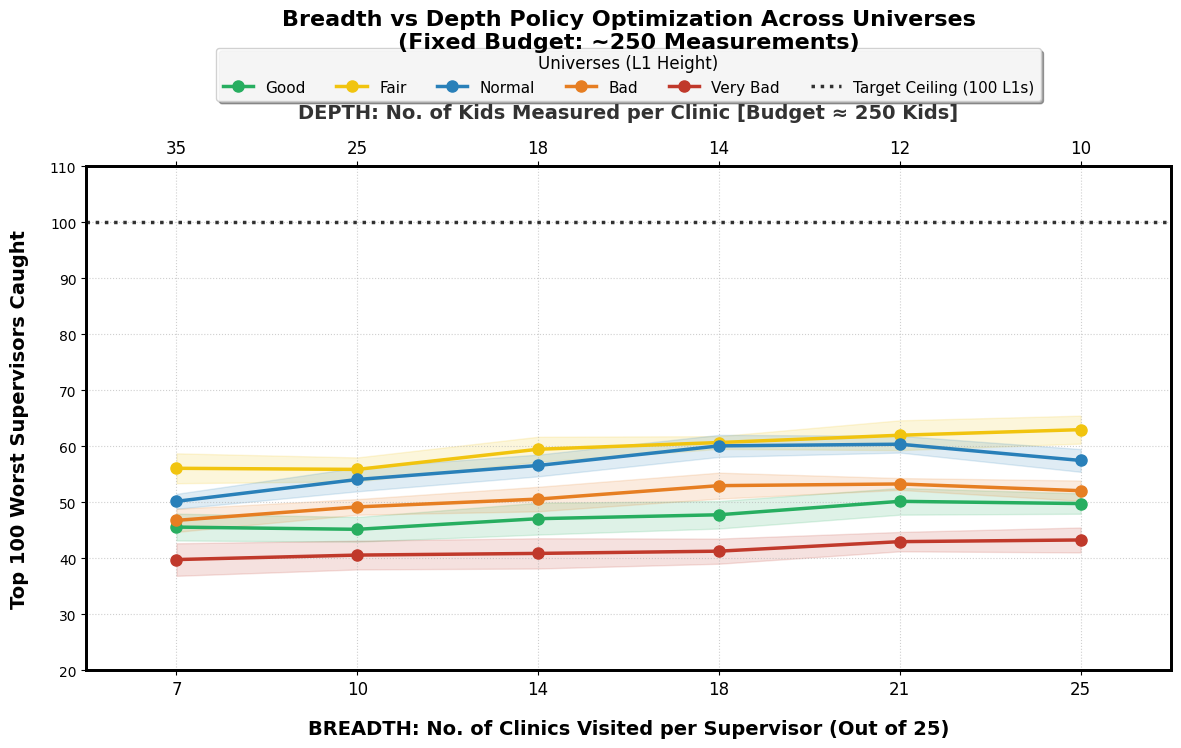

In [ ]:
#plot 3 bd l1 regions ranking coed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os
from datetime import datetime

# ==============================================================================
# 1. SETUP THE FILES, BUDGETS & COLORS
# ==============================================================================
datasets_to_run = {
    "Good": "sensitivity_dataset_TRUE_Good_20260324_100502.parquet",
    "Fair": "sensitivity_dataset_Fair_20260323_115454.parquet",
    "Normal": "sensitivity_dataset_Normal_20260323_150757.parquet",
    "Bad": "sensitivity_dataset_Bad_20260323_132920.parquet",
    "Very Bad": "sensitivity_dataset_Very_Bad_20260323_141221.parquet"
}

uni_colors = {
    "Good": "#27ae60", "Fair": "#f1c40f", "Normal": "#2980b9", 
    "Bad": "#e67e22", "Very Bad": "#c0392b"
}

# Budget = ~250 kids total per Supervisor
budget_pairs = [(7, 35), (10, 25), (14, 18), (18, 14), (21, 12), (25, 10)]
n_simulations = 10 
target_percent = 0.30

master_results = []
print("🚀 INITIATING COMPREHENSIVE 5-UNIVERSE BREADTH VS DEPTH ENGINE...\n")

# ==============================================================================
# 2. RUN THE ENGINE (ALL UNIVERSES, L1 & L2, HT & WT)
# ==============================================================================
for universe_name, file_name in datasets_to_run.items():
    if not os.path.exists(file_name):
        print(f"❌ Error: Cannot find '{file_name}'. Skipping...")
        continue

    print(f"⚙️ Simulating {universe_name.upper()} Universe...")
    df = pd.read_parquet(file_name)

    # Calculate ALL Fraud Discrepancies
    df['true_fraud_haz'] = np.abs(df['real_haz'] - df['L0_haz'])
    df['true_fraud_waz'] = np.abs(df['real_waz'] - df['L0_waz'])
    
    df['meas_fraud_haz_L1'] = np.abs(df['L1_haz'] - df['L0_haz'])
    df['meas_fraud_waz_L1'] = np.abs(df['L1_waz'] - df['L0_waz'])
    df['meas_fraud_haz_L2'] = np.abs(df['L2_haz'] - df['L0_haz'])
    df['meas_fraud_waz_L2'] = np.abs(df['L2_waz'] - df['L0_waz'])

    numeric_cols = [
        'meas_fraud_haz_L1', 'meas_fraud_waz_L1', 
        'meas_fraud_haz_L2', 'meas_fraud_waz_L2'
    ]

    num_l1s = len(df['L1_id'].unique())
    n_rewarded = max(1, int(round(target_percent * num_l1s))) 
    
    # Establish God-Mode Truth for HT and WT
    god_mode_l1 = df.groupby('L1_id')[['true_fraud_haz', 'true_fraud_waz']].mean().reset_index()
    god_mode_l1['rank_god_ht'] = god_mode_l1['true_fraud_haz'].rank(method='first', ascending=False)
    god_mode_l1['rank_god_wt'] = god_mode_l1['true_fraud_waz'].rank(method='first', ascending=False)
    
    true_bad_ht = set(god_mode_l1[god_mode_l1['rank_god_ht'] <= n_rewarded]['L1_id'])
    true_bad_wt = set(god_mode_l1[god_mode_l1['rank_god_wt'] <= n_rewarded]['L1_id'])

    for n_centers, n_kids in tqdm(budget_pairs, desc=f"   Sampling Budgets", leave=False):
        sim_scores = {'L1_ht': [], 'L1_wt': [], 'L2_ht': [], 'L2_wt': []}
        
        for _ in range(n_simulations):
            # 1. Sample unique clinics (replace=False)
            centers_pool = df[['L1_id', 'L0_id']].drop_duplicates()
            sampled_centers = centers_pool.groupby('L1_id').sample(n=n_centers, replace=False)
            
            # 2. Sample kids from those specific clinics (replace=True)
            sampled_kids = df.merge(sampled_centers, on=['L1_id', 'L0_id']).groupby(['L1_id', 'L0_id']).sample(n=n_kids, replace=True)
            
            # 3. Roll up to L1 (Simple Mean)
            l0_means = sampled_kids.groupby(['L1_id', 'L0_id'])[numeric_cols].mean().reset_index()
            l1_sample_means = l0_means.groupby('L1_id')[numeric_cols].mean().reset_index()
            
            # 4. Rank
            l1_sample_means['rank_L1_ht'] = l1_sample_means['meas_fraud_haz_L1'].rank(method='first', ascending=False)
            l1_sample_means['rank_L1_wt'] = l1_sample_means['meas_fraud_waz_L1'].rank(method='first', ascending=False)
            l1_sample_means['rank_L2_ht'] = l1_sample_means['meas_fraud_haz_L2'].rank(method='first', ascending=False)
            l1_sample_means['rank_L2_wt'] = l1_sample_means['meas_fraud_waz_L2'].rank(method='first', ascending=False)
            
            # 5. Overlaps
            sim_scores['L1_ht'].append(len(set(l1_sample_means[l1_sample_means['rank_L1_ht'] <= n_rewarded]['L1_id']) & true_bad_ht))
            sim_scores['L1_wt'].append(len(set(l1_sample_means[l1_sample_means['rank_L1_wt'] <= n_rewarded]['L1_id']) & true_bad_wt))
            sim_scores['L2_ht'].append(len(set(l1_sample_means[l1_sample_means['rank_L2_ht'] <= n_rewarded]['L1_id']) & true_bad_ht))
            sim_scores['L2_wt'].append(len(set(l1_sample_means[l1_sample_means['rank_L2_wt'] <= n_rewarded]['L1_id']) & true_bad_wt))

        # Calculate Mean and 95% CI for all 4 metrics
        row = {
            'Universe': universe_name, 'Breadth_L0s': n_centers, 'Depth_Kids': n_kids,
            'Total_Budget': n_centers * n_kids, 'Target_L1s': n_rewarded, 'Total_L1s': num_l1s
        }
        for k, v in sim_scores.items():
            row[f'{k}_mean'] = np.mean(v)
            se = np.std(v, ddof=1) / np.sqrt(n_simulations) if n_simulations > 1 else 0
            row[f'{k}_ci95'] = 1.96 * se
            
        master_results.append(row)

# ==============================================================================
# 3. SAVE RESULTS
# ==============================================================================
df_results = pd.DataFrame(master_results)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_file = f'Breadth_Depth_5Universe_MASTER_{timestamp}.csv'
df_results.to_csv(csv_file, index=False)
print(f"\n✅ DATA SAVED: {csv_file}")

# ==============================================================================
# 4. PLOTTING THE DUAL-AXIS SENSITIVITY CHART (L1 HEIGHT)
# ==============================================================================
print("📊 Generating Dual-Axis Sensitivity Plot for L1 Height...")

df_results.sort_values(['Universe', 'Breadth_L0s', 'Depth_Kids'], inplace=True)

sample_uni = df_results[df_results['Universe'] == list(datasets_to_run.keys())[0]]
x_indices = np.arange(len(sample_uni)) 
x_breadth_labels = sample_uni['Breadth_L0s'].values.astype(int)
x_depth_labels = sample_uni['Depth_Kids'].values.astype(int)
target = sample_uni['Target_L1s'].iloc[0]

lw, ms = 2.5, 8
fig, ax1 = plt.subplots(figsize=(14, 8), dpi=100)

universes = list(uni_colors.keys())

for uni in universes:
    data = df_results[df_results['Universe'] == uni]
    
    # Plotting L1_ht_mean here. You can change this to L1_wt_mean or L2_ht_mean anytime!
    ax1.plot(x_indices, data['L1_ht_mean'], marker='o', markersize=ms, 
             color=uni_colors[uni], linestyle='-', linewidth=lw, label=uni)
    
    ax1.fill_between(x_indices, 
                     data['L1_ht_mean'] - data['L1_ht_ci95'], 
                     data['L1_ht_mean'] + data['L1_ht_ci95'], 
                     color=uni_colors[uni], alpha=0.15)

ax1.axhline(y=target, color='black', linestyle=':', linewidth=2.5, alpha=0.8, 
            label=f'Target Ceiling ({int(target)} L1s)', zorder=3)

# --- PRIMARY AXIS (Breadth - Bottom) ---
ax1.set_xlim(min(x_indices) - 0.5, max(x_indices) + 0.5)
ax1.set_xticks(x_indices)
ax1.set_xticklabels(x_breadth_labels, fontsize=12) 
ax1.set_xlabel('BREADTH: No. of Clinics Visited per Supervisor (Out of 25)', fontsize=14, fontweight='bold', labelpad=15)
ax1.set_ylabel(f'Top {int(target)} Worst Supervisors Caught', fontsize=14, fontweight='bold', labelpad=15)

# --- SECONDARY AXIS (Depth - Top) ---
ax2 = ax1.twiny()
ax2.xaxis.set_ticks_position('top')
ax2.xaxis.set_label_position('top')

ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(x_indices)
ax2.set_xticklabels(x_depth_labels, fontsize=12)
ax2.set_xlabel('DEPTH: No. of Kids Measured per Clinic [Budget ≈ 250 Kids]', fontsize=14, fontweight='bold', color='#333333', labelpad=15)

ax1.set_ylim(20, target + 10) 
ax1.grid(True, linestyle=':', alpha=0.6)

border_thickness = 2.0
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_linewidth(border_thickness)
        spine.set_color('black')

ax1.legend(title='Universes (L1 Height)', bbox_to_anchor=(0.5, 1.25), loc='upper center', 
           ncol=6, fontsize=11, framealpha=0.9, shadow=True, title_fontsize=12)

plt.title('Breadth vs Depth Policy Optimization Across Universes\n(Fixed Budget: ~250 Measurements)', 
          fontsize=16, pad=85, fontweight='bold')

plt.subplots_adjust(top=0.78, bottom=0.15) 

plot_filename = f"Breadth_Depth_5Universe_L1Height_{timestamp}.png"
plt.savefig(plot_filename, bbox_inches='tight')

print(f"✅ PLOT SAVED: {plot_filename}")
plt.show()

📊 Loading Data from: Breadth_Depth_5Universe_MASTER_20260325_120105.csv


✅ PLOT SAVED: Breadth_Depth_5Universe_StackedAxis_120105.png


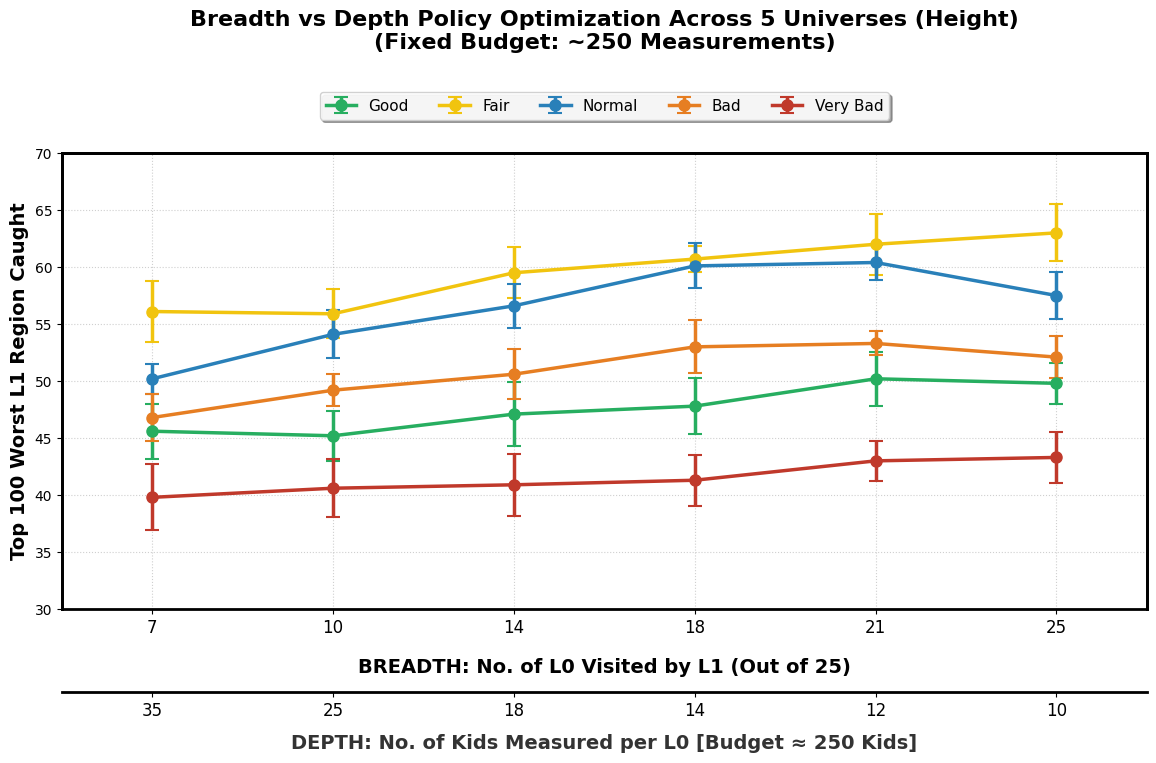

In [ ]:
# plot 3 : bd ranking l1 region graph
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# ==============================================================================
# 1. LOAD THE LATEST MASTER CSV DATA
# ==============================================================================
# Automatically grabs the latest CSV generated by your engine
csv_files = glob.glob("Breadth_Depth_5Universe_MASTER_*.csv")
if not csv_files:
    print("❌ Error: No master CSV found. Please run the engine first.")
    exit()
    
latest_csv = max(csv_files, key=os.path.getctime)
print(f"📊 Loading Data from: {latest_csv}")

df_results = pd.read_csv(latest_csv)

# ==============================================================================
# 2. PLOTTING FUNCTION (5-Universe, Dual-Bottom Axis, Error Bars)
# ==============================================================================
uni_colors = {
    "Good": "#27ae60", "Fair": "#f1c40f", "Normal": "#2980b9", 
    "Bad": "#e67e22", "Very Bad": "#c0392b"
}

df_results.sort_values(['Universe', 'Breadth_L0s', 'Depth_Kids'], inplace=True)

# Extract shared axis labels
sample_uni = df_results[df_results['Universe'] == list(uni_colors.keys())[0]]
x_indices = np.arange(len(sample_uni)) 
x_breadth_labels = sample_uni['Breadth_L0s'].values.astype(int)
x_depth_labels = sample_uni['Depth_Kids'].values.astype(int)
target = sample_uni['Target_L1s'].iloc[0]

lw, ms = 2.5, 8
fig, ax1 = plt.subplots(figsize=(14, 8), dpi=100)

# Plot each universe WITH ERROR BARS (yerr)
for uni, color in uni_colors.items():
    data = df_results[df_results['Universe'] == uni]
    
    # We are plotting L1 Height Mean and using the 95% CI for the error bars
    ax1.errorbar(x_indices, data['L1_ht_mean'], yerr=data['L1_ht_ci95'], 
                 fmt='o-', markersize=ms, color=color, linewidth=lw, 
                 capsize=5, capthick=1.5, label=uni, zorder=5)

# Target Reference Line
ax1.axhline(y=target, color='black', linestyle=':', linewidth=2.5, alpha=0.8, zorder=3)
            # label=f'Target Ceiling ({int(target)} L1s)', zorder=3)

# ========================================================
# PRIMARY AXIS (Breadth - Bottom)
# ========================================================
ax1.set_xlim(min(x_indices) - 0.5, max(x_indices) + 0.5)
ax1.set_xticks(x_indices)
ax1.set_xticklabels(x_breadth_labels, fontsize=12) 
ax1.set_xlabel('BREADTH: No. of L0 Visited by L1 (Out of 25)', fontsize=14, fontweight='bold', labelpad=15)
ax1.set_ylabel(f'Top {int(target)} Worst L1 Region Caught', fontsize=14, fontweight='bold')

# ========================================================
# SECONDARY AXIS (Depth - Also Bottom, shifted outwards)
# ========================================================
ax2 = ax1.twiny()
ax2.xaxis.set_ticks_position('bottom')
ax2.xaxis.set_label_position('bottom')

# This pushes the second X-axis down by 60 points so it stacks cleanly
ax2.spines['bottom'].set_position(('outward', 60)) 

ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(x_indices)
ax2.set_xticklabels(x_depth_labels, fontsize=12)
ax2.set_xlabel('DEPTH: No. of Kids Measured per L0 [Budget ≈ 250 Kids]', fontsize=14, fontweight='bold', color='#333333', labelpad=10)

# ========================================================
# ZOOMED Y-AXIS & STYLING
# ========================================================
# Dynamically zooms based on your data, cutting off empty space below
y_min = max(0, df_results['L1_ht_mean'].min() - 15)
# ax1.set_ylim(y_min, target + 5)
ax1.set_ylim(30,70)

ax1.grid(True, linestyle=':', alpha=0.6)

# Bold Borders
border_thickness = 2.0
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_linewidth(border_thickness)
        spine.set_color('black')

# ========================================================
# TITLES & LEGEND (Sandwiched properly)
# ========================================================
# Legend floats at Y=1.15 (above the plot frame)
ax1.legend(bbox_to_anchor=(0.5, 1.15), loc='upper center', 
           ncol=6, fontsize=11, framealpha=0.9, shadow=True)

# Title is pushed up using pad=75 to clear the floating legend
plt.title('Breadth vs Depth Policy Optimization Across 5 Universes (Height)\n(Fixed Budget: ~250 Measurements)', 
          fontsize=16, pad=75, fontweight='bold')

# Adjust layout to make room for dual bottom axes (bottom=0.25) and top text (top=0.82)
plt.subplots_adjust(bottom=0.25, top=0.82) 

timestamp = latest_csv.split('_')[-1].replace('.csv', '')
plot_filename = f"Breadth_Depth_5Universe_StackedAxis_{timestamp}.png"
plt.savefig(plot_filename, bbox_inches='tight')

print(f"✅ PLOT SAVED: {plot_filename}")
plt.show()

In [62]:
import pandas as pd
import glob
import os

# ==============================================================================
# LOAD THE LATEST MASTER CSV DATA
# ==============================================================================
csv_files = glob.glob("Breadth_Depth_5Universe_MASTER_*.csv")
if not csv_files:
    print("❌ Error: No master CSV found. Please run the engine first.")
else:
    latest_csv = max(csv_files, key=os.path.getctime)
    print(f"📊 Loading Data from: {latest_csv}\n")
    
    df_results = pd.read_csv(latest_csv)
    
    # Sort exactly how we plotted it
    df_results.sort_values(['Universe', 'Breadth_L0s', 'Depth_Kids'], inplace=True)
    
    # Filter only the columns we care about for the L1 Height Plot
    display_df = df_results[['Universe', 'Breadth_L0s', 'Depth_Kids', 'L1_ht_mean', 'L1_ht_ci95']].copy()
    
    # Round the numbers to 2 decimal places for clean reading
    display_df['L1_ht_mean'] = display_df['L1_ht_mean'].round(2)
    display_df['L1_ht_ci95'] = display_df['L1_ht_ci95'].round(2)
    
    # Combine Mean and CI into a single readable string (e.g., "65.4 ± 1.2")
    display_df['Score (Mean ± CI)'] = display_df['L1_ht_mean'].astype(str) + " ± " + display_df['L1_ht_ci95'].astype(str)
    
    # Specify the order so it prints from best to worst reality
    universes = ["Good", "Fair", "Normal", "Bad", "Very Bad"]
    
    for uni in universes:
        # Check if universe exists in data just in case
        if uni in display_df['Universe'].values:
            print("=" * 60)
            print(f"🌟 UNIVERSE: {uni.upper()}")
            print("=" * 60)
            
            # Isolate this universe and format the column names for printing
            uni_data = display_df[display_df['Universe'] == uni][['Breadth_L0s', 'Depth_Kids', 'Score (Mean ± CI)']]
            uni_data.columns = ['Breadth (Clinics)', 'Depth (Kids)', 'Top Regions Caught (± 95% CI)']
            
            print(uni_data.to_string(index=False))
            print("\n")

📊 Loading Data from: Breadth_Depth_5Universe_MASTER_20260325_120105.csv

🌟 UNIVERSE: GOOD
 Breadth (Clinics)  Depth (Kids) Top Regions Caught (± 95% CI)
                 7            35                    45.6 ± 2.4
                10            25                    45.2 ± 2.2
                14            18                   47.1 ± 2.84
                18            14                   47.8 ± 2.46
                21            12                   50.2 ± 2.39
                25            10                   49.8 ± 1.82


🌟 UNIVERSE: FAIR
 Breadth (Clinics)  Depth (Kids) Top Regions Caught (± 95% CI)
                 7            35                   56.1 ± 2.67
                10            25                   55.9 ± 2.14
                14            18                   59.5 ± 2.23
                18            14                   60.7 ± 1.13
                21            12                   62.0 ± 2.66
                25            10                    63.0 ± 2.5


🌟 UNIVE

plot 4. 


In [65]:
#bd for diff budgets
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import os
from datetime import datetime

# ==============================================================================
# 1. SETUP THE FILES & MULTI-BUDGETS
# ==============================================================================
datasets_to_run = {
    "Good": "sensitivity_dataset_TRUE_Good_20260324_100502.parquet",
    "Fair": "sensitivity_dataset_Fair_20260323_115454.parquet",
    "Normal": "sensitivity_dataset_Normal_20260323_150757.parquet",
    "Bad": "sensitivity_dataset_Bad_20260323_132920.parquet",
    "Very Bad": "sensitivity_dataset_Very_Bad_20260323_141221.parquet"
}

target_percent = 0.30
n_simulations = 10

# 4 Strict Budgets - Depth NEVER exceeds 15 (replace=False safe)
budgets = [
    {'name': '150_Kids', 'pairs': [(10, 15), (12, 12), (15, 10), (18, 8), (21, 7), (25, 6)]},
    {'name': '200_Kids', 'pairs': [(14, 14), (16, 12), (18, 11), (20, 10), (22, 9), (25, 8)]},
    {'name': '250_Kids', 'pairs': [(17, 15), (18, 14), (19, 13), (21, 12), (23, 11), (25, 10)]},
    {'name': '300_Kids', 'pairs': [(20, 15), (21, 14), (22, 14), (23, 13), (24, 13), (25, 12)]}
]

master_results = []
print("🚀 INITIATING THE GRAND MASTER DATA ENGINE (L1 & L2 | HT & WT)...\n")

# ==============================================================================
# 2. RUN THE MATRIX SIMULATION
# ==============================================================================
for universe_name, file_name in datasets_to_run.items():
    if not os.path.exists(file_name):
        print(f"❌ Error: Cannot find '{file_name}'. Skipping...")
        continue

    print(f"⚙️ Simulating {universe_name.upper()} Universe...")
    df = pd.read_parquet(file_name)

    # Calculate ALL true and measured discrepancies
    df['true_fraud_haz'] = np.abs(df['real_haz'] - df['L0_haz'])
    df['true_fraud_waz'] = np.abs(df['real_waz'] - df['L0_waz'])
    
    df['meas_fraud_haz_L1'] = np.abs(df['L1_haz'] - df['L0_haz'])
    df['meas_fraud_waz_L1'] = np.abs(df['L1_waz'] - df['L0_waz'])
    df['meas_fraud_haz_L2'] = np.abs(df['L2_haz'] - df['L0_haz'])
    df['meas_fraud_waz_L2'] = np.abs(df['L2_waz'] - df['L0_waz'])

    numeric_cols = ['meas_fraud_haz_L1', 'meas_fraud_waz_L1', 'meas_fraud_haz_L2', 'meas_fraud_waz_L2']

    num_l1s = len(df['L1_id'].unique())
    target_count = max(1, int(round(target_percent * num_l1s))) 
    
    # Establish God-Mode Truth for HT and WT
    god_mode = df.groupby('L1_id')[['true_fraud_haz', 'true_fraud_waz']].mean().reset_index()
    god_mode['rank_god_ht'] = god_mode['true_fraud_haz'].rank(method='first', ascending=False)
    god_mode['rank_god_wt'] = god_mode['true_fraud_waz'].rank(method='first', ascending=False)
    
    true_bad_ht = set(god_mode[god_mode['rank_god_ht'] <= target_count]['L1_id'])
    true_bad_wt = set(god_mode[god_mode['rank_god_wt'] <= target_count]['L1_id'])

    for budget in budgets:
        for n_centers, n_kids in tqdm(budget['pairs'], desc=f"   Budget: {budget['name']}", leave=False):
            sim_scores = {'L1_ht': [], 'L1_wt': [], 'L2_ht': [], 'L2_wt': []}
            
            for _ in range(n_simulations):
                # Sample unique clinics & kids
                centers_pool = df[['L1_id', 'L0_id']].drop_duplicates()
                sampled_centers = centers_pool.groupby('L1_id').sample(n=n_centers, replace=False)
                sampled_kids = df.merge(sampled_centers, on=['L1_id', 'L0_id']).groupby(['L1_id', 'L0_id']).sample(n=n_kids, replace=False)
                
                # Roll up to L1
                l0_means = sampled_kids.groupby(['L1_id', 'L0_id'])[numeric_cols].mean().reset_index()
                l1_sample_means = l0_means.groupby('L1_id')[numeric_cols].mean().reset_index()
                
                # Rank
                l1_sample_means['rank_L1_ht'] = l1_sample_means['meas_fraud_haz_L1'].rank(method='first', ascending=False)
                l1_sample_means['rank_L1_wt'] = l1_sample_means['meas_fraud_waz_L1'].rank(method='first', ascending=False)
                l1_sample_means['rank_L2_ht'] = l1_sample_means['meas_fraud_haz_L2'].rank(method='first', ascending=False)
                l1_sample_means['rank_L2_wt'] = l1_sample_means['meas_fraud_waz_L2'].rank(method='first', ascending=False)
                
                # Overlaps
                sim_scores['L1_ht'].append(len(set(l1_sample_means[l1_sample_means['rank_L1_ht'] <= target_count]['L1_id']) & true_bad_ht))
                sim_scores['L1_wt'].append(len(set(l1_sample_means[l1_sample_means['rank_L1_wt'] <= target_count]['L1_id']) & true_bad_wt))
                sim_scores['L2_ht'].append(len(set(l1_sample_means[l1_sample_means['rank_L2_ht'] <= target_count]['L1_id']) & true_bad_ht))
                sim_scores['L2_wt'].append(len(set(l1_sample_means[l1_sample_means['rank_L2_wt'] <= target_count]['L1_id']) & true_bad_wt))

            # Calculate Mean and 95% CI for all 4 metrics
            row = {
                'Universe': universe_name,
                'Budget_Name': budget['name'],
                'Breadth_L0s': n_centers,
                'Depth_Kids': n_kids,
                'Total_Budget': n_centers * n_kids
            }
            for k, v in sim_scores.items():
                row[f'{k}_mean'] = np.mean(v)
                se = np.std(v, ddof=1) / np.sqrt(n_simulations) if n_simulations > 1 else 0
                row[f'{k}_ci95'] = 1.96 * se
                
            master_results.append(row)

# ==============================================================================
# 3. SAVE THE ULTIMATE MASTER CSV
# ==============================================================================
df_matrix = pd.DataFrame(master_results)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_file = f'Grand_Master_MultiBudget_{timestamp}.csv'
df_matrix.to_csv(csv_file, index=False)
print(f"\n✅ GRAND MASTER DATA SAVED: {csv_file}")
print("You can now write short scripts to plot any combination of these metrics!")

🚀 INITIATING THE GRAND MASTER DATA ENGINE (L1 & L2 | HT & WT)...

⚙️ Simulating GOOD Universe...


⚙️ Simulating FAIR Universe...


⚙️ Simulating NORMAL Universe...


⚙️ Simulating BAD Universe...


⚙️ Simulating VERY BAD Universe...



✅ GRAND MASTER DATA SAVED: Grand_Master_MultiBudget_20260325_131615.csv
You can now write short scripts to plot any combination of these metrics!


📊 Loading Data from: Grand_Master_MultiBudget_20260325_131615.csv
📈 Generating 3x2 Plot for L1_HT...
✅ PLOT SAVED: MultiBudget_3x2_L1_ht_131615.png


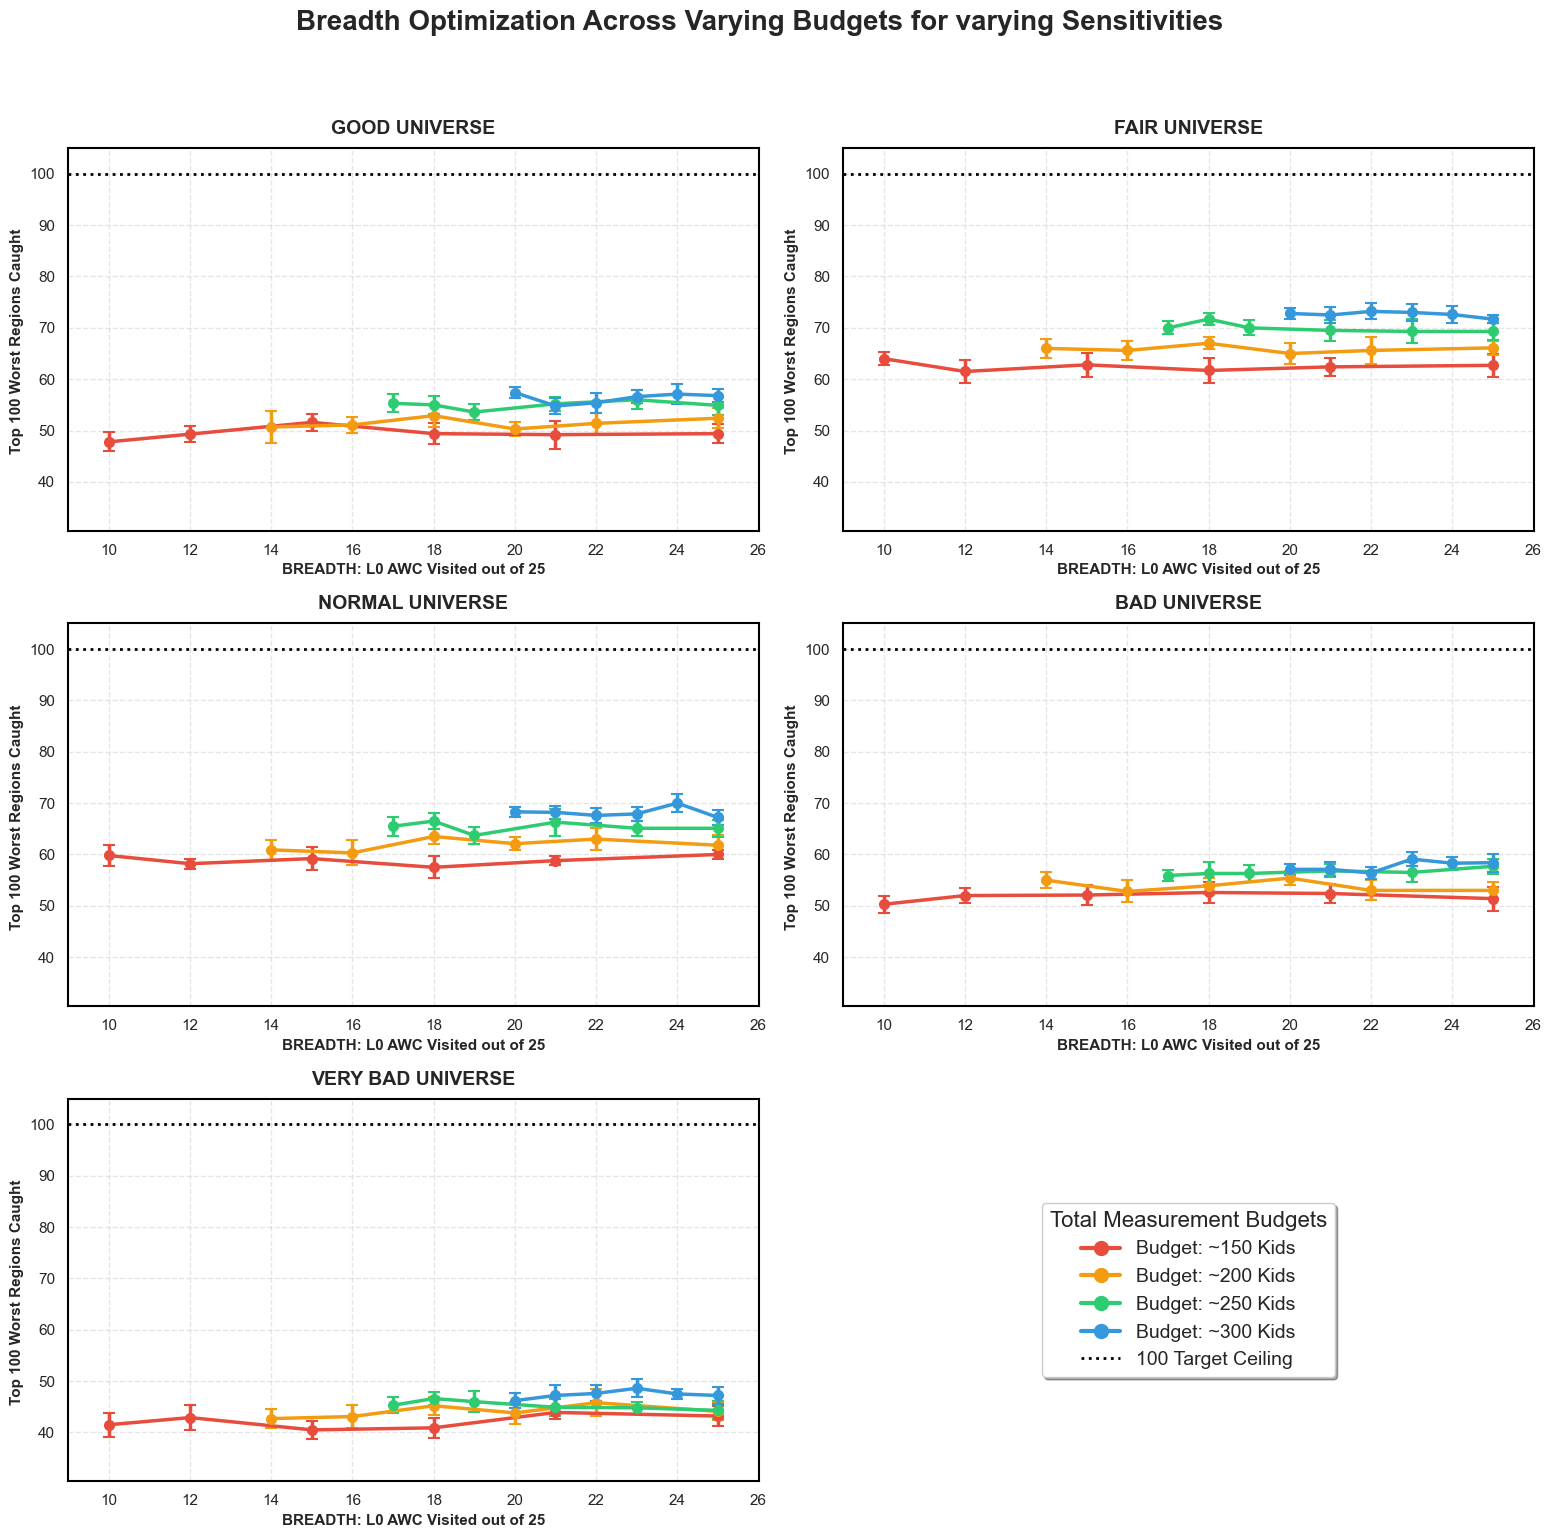

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from matplotlib.lines import Line2D

# ==============================================================================
# 1. LOAD THE GRAND MASTER CSV DATA
# ==============================================================================
csv_files = glob.glob("Grand_Master_MultiBudget_*.csv")
if not csv_files:
    print("❌ Error: No master CSV found.")
    exit()
    
latest_csv = max(csv_files, key=os.path.getctime)
print(f"📊 Loading Data from: {latest_csv}")

df_matrix = pd.read_csv(latest_csv)

# ---------------------------------------------------------
# 💡 QUICK SWITCHER: Change this variable to plot different metrics!
# Options: 'L1_ht', 'L1_wt', 'L2_ht', 'L2_wt'
# ---------------------------------------------------------
metric_to_plot = 'L1_ht' 

mean_col = f'{metric_to_plot}_mean'
ci_col = f'{metric_to_plot}_ci95'

# ==============================================================================
# 2. SETUP STYLING & COLORS
# ==============================================================================
universes = ["Good", "Fair", "Normal", "Bad", "Very Bad"]
target_count = 100

# Mapping the specific budgets to colors
budget_styles = {
    '150_Kids': {'color': '#e74c3c', 'label': 'Budget: ~150 Kids'}, # Red
    '200_Kids': {'color': '#f39c12', 'label': 'Budget: ~200 Kids'}, # Orange
    '250_Kids': {'color': '#2ecc71', 'label': 'Budget: ~250 Kids'}, # Green
    '300_Kids': {'color': '#3498db', 'label': 'Budget: ~300 Kids'}  # Blue
}

# ==============================================================================
# 3. PLOT THE 3x2 MASTER GRID
# ==============================================================================
print(f"📈 Generating 3x2 Plot for {metric_to_plot.upper()}...")

fig, axes = plt.subplots(3, 2, figsize=(16, 16), dpi=100)
axes = axes.flatten()

# Plots 1 to 5: Individual Universes
for i, uni in enumerate(universes):
    ax = axes[i]
    uni_data = df_matrix[df_matrix['Universe'] == uni]
    
    if uni_data.empty:
        continue
        
    for budget_name, style in budget_styles.items():
        subset = uni_data[uni_data['Budget_Name'] == budget_name].sort_values(by='Breadth_L0s')
        
        # Plot with Error Bars mapping strictly against Breadth (X-axis)
        ax.errorbar(subset['Breadth_L0s'], subset[mean_col], yerr=subset[ci_col], 
                    fmt='o-', color=style['color'], linewidth=2.5, markersize=7, 
                    capsize=4, capthick=1.5, label=style['label'])

    # Target Ceiling Reference Line
    ax.axhline(y=target_count, color='black', linestyle=':', linewidth=2)
    
    ax.set_title(f"{uni.upper()} UNIVERSE", fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('BREADTH: L0 AWC Visited out of 25', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'Top {target_count} Worst Regions Caught ', fontsize=11, fontweight='bold')
    
    # Lock axes to ensure all 5 plots share exactly the same visual scale
    ax.set_xlim(9, 26)
    
    # Dynamically set Y-lim based on the lowest value across the whole dataset so it zooms nicely
    y_min = max(0, df_matrix[mean_col].min() - 10)
    ax.set_ylim(y_min, 105) 
    
    ax.grid(True, linestyle='--', alpha=0.5)

    # Bold Borders
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')

# ==============================================================================
# 4. STYLE THE 6TH EMPTY PLOT AS A GLOBAL LEGEND
# ==============================================================================
ax_legend = axes[5]
ax_legend.axis('off') 

# Build the legend elements manually
legend_elements = [Line2D([0], [0], marker='o', color=style['color'], label=style['label'], 
                          markersize=10, linewidth=3) for budget_name, style in budget_styles.items()]
#legend_elements.append(Line2D([0], [0], color='black', linestyle=':', linewidth=2, label=f'{target_count} Target Ceiling'))

ax_legend.legend(handles=legend_elements, loc='center', fontsize=14, frameon=True, shadow=True, 
                 title="Total Measurement Budgets", title_fontsize=16)

plt.suptitle(f"Breadth Optimization Across Varying Budgets for varying Sensitivities", fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0.02, 0.02, 1, 0.95]) 

timestamp = latest_csv.split('_')[-1].replace('.csv', '')
plot_filename = f"MultiBudget_3x2_{metric_to_plot}_{timestamp}.png"
plt.savefig(plot_filename, bbox_inches='tight')

print(f"✅ PLOT SAVED: {plot_filename}")
plt.show()

plot 5

📊 Loading Data from: Nested_Heatmap_Data_20260325_141407.csv
✅ PLOT SAVED: L2_Robustness_FromHeatmap_Normal_141407.png


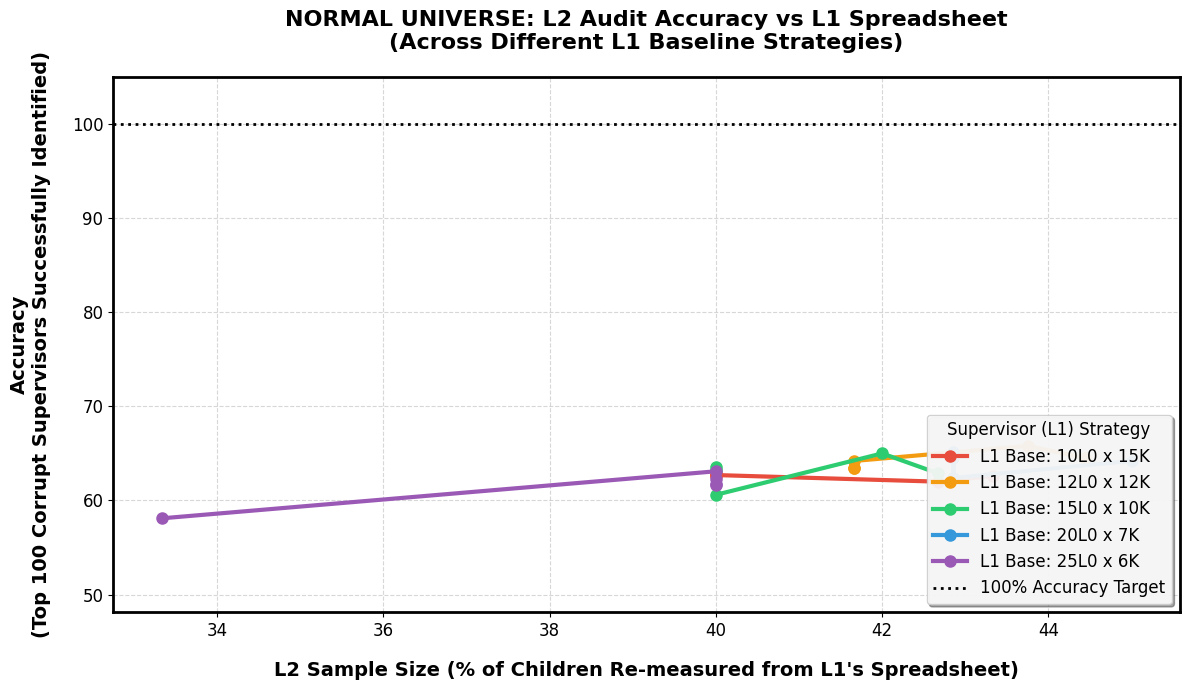

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# ==============================================================================
# 1. LOAD THE DATA & FILTER FOR 'NORMAL' UNIVERSE
# ==============================================================================
# Look for the Heatmap data you just generated
csv_files = glob.glob("Nested_Heatmap_Data_*.csv")
if not csv_files:
    print("❌ Error: No Nested Heatmap CSV found.")
    exit()

latest_csv = max(csv_files, key=os.path.getctime)
print(f"📊 Loading Data from: {latest_csv}")

df_matrix = pd.read_csv(latest_csv)

# Filter specifically for the Normal universe
df_normal = df_matrix[df_matrix['Universe'] == 'Normal'].copy()

if df_normal.empty:
    print("❌ Error: No data found for the 'Normal' universe in this CSV.")
    exit()

# ==============================================================================
# 2. CALCULATE THE AUDIT PERCENTAGES ON THE FLY
# ==============================================================================
# We calculate total kids for L1 and L2 to figure out the X-Axis percentage
df_normal['L1_Total_Kids'] = df_normal['L1_C'] * df_normal['L1_K']
df_normal['L2_Total_Kids'] = df_normal['L2_C'] * df_normal['L2_K']
df_normal['Audit_Percentage'] = (df_normal['L2_Total_Kids'] / df_normal['L1_Total_Kids']) * 100

# Sort so the lines draw smoothly from left to right
df_normal.sort_values(by=['L1_Label', 'Audit_Percentage'], inplace=True)

# ==============================================================================
# 3. PLOT THE ROBUSTNESS TEST GRAPH
# ==============================================================================
plt.figure(figsize=(12, 7), dpi=100)

# Colors for the 5 different L1 strategies you tested
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db', '#9b59b6']
l1_labels = df_normal['L1_Label'].unique()

for idx, l1_label in enumerate(l1_labels):
    subset = df_normal[df_normal['L1_Label'] == l1_label]
    
    if not subset.empty:
        plt.plot(subset['Audit_Percentage'], subset['L2_Accuracy_Mean'], 
                 marker='o', linestyle='-', color=colors[idx], linewidth=3, 
                 markersize=8, label=f"L1 Base: {l1_label}")

# Target Ceiling Line
plt.axhline(y=100, color='black', linestyle=':', linewidth=2, label='100% Accuracy Target')

# Titles and labels
plt.title('NORMAL UNIVERSE: L2 Audit Accuracy vs L1 Spreadsheet\n(Across Different L1 Baseline Strategies)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel("L2 Sample Size (% of Children Re-measured from L1's Spreadsheet)", 
           fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel('Accuracy\n(Top 100 Corrupt Supervisors Successfully Identified)', 
           fontsize=14, fontweight='bold', labelpad=15)

# Formatting the X and Y axes
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Dynamically set Y-lim so the lines don't get squished
y_min = max(0, df_normal['L2_Accuracy_Mean'].min() - 10)
plt.ylim(y_min, 105)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Supervisor (L1) Strategy', loc='lower right', fontsize=12, title_fontsize=12, framealpha=0.9, shadow=True)

# Make the plot borders bold
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2.0)
    spine.set_color('black')

plt.tight_layout()

# Save and Show
timestamp = latest_csv.split('_')[-1].replace('.csv', '')
plot_filename = f"L2_Robustness_FromHeatmap_Normal_{timestamp}.png"
plt.savefig(plot_filename, bbox_inches='tight')

print(f"✅ PLOT SAVED: {plot_filename}")
plt.show()

c:\Users\CEGIS FOUNDATION\New folder\GitHub\discsim\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📁 Loading Normal Universe into memory...
🚀 RUNNING BUDGET ROBUSTNESS (NORMAL UNIVERSE ONLY)...


📈 Generating Plot...
✅ PLOT SAVED: Normal_L2_Budget_Robustness_20260325_145909.png


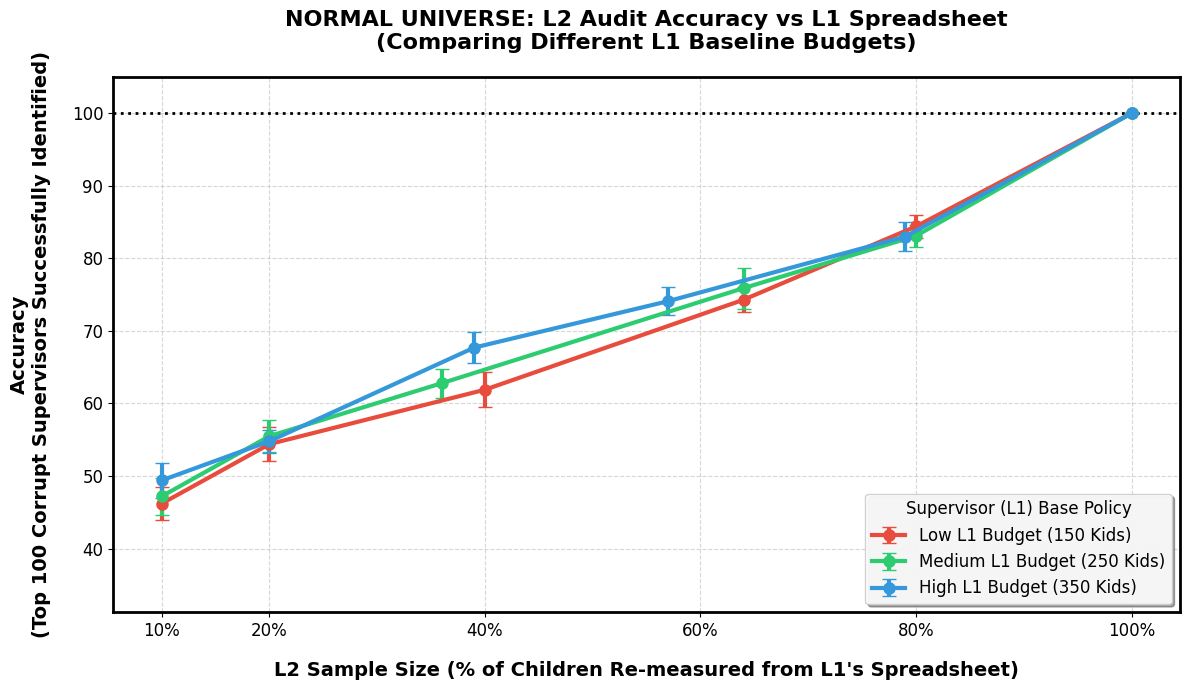


📊 ROBUSTNESS TEST TABLE: NORMAL UNIVERSE (MEAN ± 95% CI)
             L1 Policy Base  % Audited  L2 Kids Accuracy (± 95% CI)
   Low L1 Budget (150 Kids)         10       15          46.2 ± 2.3
   Low L1 Budget (150 Kids)         20       30          54.4 ± 2.3
   Low L1 Budget (150 Kids)         40       60          61.9 ± 2.4
   Low L1 Budget (150 Kids)         64       96          74.3 ± 1.7
   Low L1 Budget (150 Kids)         80      120          84.4 ± 1.6
   Low L1 Budget (150 Kids)        100      150         100.0 ± 0.0
Medium L1 Budget (250 Kids)         10       25          47.2 ± 2.6
Medium L1 Budget (250 Kids)         20       50          55.5 ± 2.2
Medium L1 Budget (250 Kids)         36       90          62.8 ± 2.0
Medium L1 Budget (250 Kids)         64      160          75.9 ± 2.8
Medium L1 Budget (250 Kids)         80      200          83.1 ± 1.5
Medium L1 Budget (250 Kids)        100      250         100.0 ± 0.0
  High L1 Budget (350 Kids)         10       35          4

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os
from datetime import datetime

# ==============================================================================
# 0. LOAD THE NORMAL UNIVERSE & CONFIGURE STRICT BUDGETS
# ==============================================================================
file_name = "sensitivity_dataset_Normal_20260323_150757.parquet"

if not os.path.exists(file_name):
    print(f"❌ Error: Cannot find '{file_name}'.")
    exit()

print("📁 Loading Normal Universe into memory...")
df = pd.read_parquet(file_name)
df['l1_mistake_haz'] = np.abs(df['L1_haz'] - df['real_haz'])

target_count = 100 
n_simulations = 10

# STRICT 15-KID / 25-CLINIC CONSTRAINTS (replace=False Safe!)
scenarios = [
    {
        'name': 'Low L1 Budget (150 Kids)',
        'l1_c': 15, 'l1_k': 10,
        # Scaling L2 up to 150 kids safely
        'l2_steps': [(3, 5), (6, 5), (10, 6), (12, 8), (15, 8), (15, 10)], 
        'color': '#e74c3c' # Red
    },
    {
        'name': 'Medium L1 Budget (250 Kids)',
        'l1_c': 25, 'l1_k': 10,
        # Scaling L2 up to 250 kids safely
        'l2_steps': [(5, 5), (10, 5), (15, 6), (20, 8), (25, 8), (25, 10)], 
        'color': '#2ecc71' # Green
    },
    {
        'name': 'High L1 Budget (350 Kids)',
        'l1_c': 25, 'l1_k': 14,
        # Scaling L2 up to 350 kids safely
        'l2_steps': [(5, 7), (10, 7), (15, 9), (20, 10), (25, 11), (25, 14)], 
        'color': '#3498db' # Blue
    }
]

# ==============================================================================
# 1. RUN THE TARGETED SIMULATION
# ==============================================================================
all_results = []
print("🚀 RUNNING BUDGET ROBUSTNESS (NORMAL UNIVERSE ONLY)...")

for scenario in scenarios:
    np.random.seed(42)
    # 1. Freeze the L1 Dashboard
    l1_clinics = df[['L1_id', 'L0_id']].drop_duplicates().groupby('L1_id').sample(n=scenario['l1_c'], replace=False)
    l1_pool = df.merge(l1_clinics, on=['L1_id', 'L0_id']).groupby(['L1_id', 'L0_id']).sample(n=scenario['l1_k'], replace=False)
    
    # 2. Establish God-Mode Truth for THIS specific spreadsheet
    god_mode = l1_pool.groupby('L1_id')[['l1_mistake_haz']].mean().reset_index()
    god_mode['rank_god'] = god_mode['l1_mistake_haz'].rank(method='first', ascending=False)
    true_bad_l1 = set(god_mode[god_mode['rank_god'] <= target_count]['L1_id'])
    
    l1_total_kids = scenario['l1_c'] * scenario['l1_k']
    
    # 3. Escalate the L2 Audit
    for n_centers, n_kids in tqdm(scenario['l2_steps'], desc=f"   {scenario['name']}", leave=False):
        overlaps = []
        l2_total_kids = n_centers * n_kids
        audit_percentage = round((l2_total_kids / l1_total_kids) * 100)
        
        for _ in range(n_simulations):
            # L2 samples strictly out of the L1 pool
            l2_clinics = l1_pool[['L1_id', 'L0_id']].drop_duplicates().groupby('L1_id').sample(n=n_centers, replace=False)
            l2_sample = l1_pool.merge(l2_clinics, on=['L1_id', 'L0_id']).groupby(['L1_id', 'L0_id']).sample(n=n_kids, replace=False)
            
            l2_means = l2_sample.groupby('L1_id')[['l1_mistake_haz']].mean().reset_index()
            l2_means['rank_audit'] = l2_means['l1_mistake_haz'].rank(method='first', ascending=False)
            
            flagged = set(l2_means[l2_means['rank_audit'] <= target_count]['L1_id'])
            overlaps.append(len(flagged & true_bad_l1))
            
        all_results.append({
            'L1_Scenario': scenario['name'],
            'Audit_Percentage': audit_percentage,
            'L2_Total_Kids': l2_total_kids,
            'Accuracy_Mean': np.mean(overlaps),
            'Accuracy_CI95': 1.96 * (np.std(overlaps, ddof=1) / np.sqrt(n_simulations)),
            'Color': scenario['color']
        })

df_matrix = pd.DataFrame(all_results)

# ==============================================================================
# 2. PLOT THE ROBUSTNESS TEST GRAPH
# ==============================================================================
print("📈 Generating Plot...")
plt.figure(figsize=(12, 7), dpi=100)

for scenario in scenarios:
    subset = df_matrix[df_matrix['L1_Scenario'] == scenario['name']]
    plt.errorbar(subset['Audit_Percentage'], subset['Accuracy_Mean'], yerr=subset['Accuracy_CI95'], 
                 fmt='o-', color=scenario['color'], linewidth=3, markersize=8, capsize=5, label=scenario['name'])

# Target Line hidden from legend
plt.axhline(y=target_count, color='black', linestyle=':', linewidth=2)

# Improved titles and labels
plt.title('NORMAL UNIVERSE: L2 Audit Accuracy vs L1 Spreadsheet\n(Comparing Different L1 Baseline Budgets)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel("L2 Sample Size (% of Children Re-measured from L1's Spreadsheet)", 
           fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel(f'Accuracy\n(Top {target_count} Corrupt Supervisors Successfully Identified)', 
           fontsize=14, fontweight='bold', labelpad=15)

# Ensure X-axis ticks align well
x_ticks = [10, 20, 40, 60, 80, 100]
plt.xticks(x_ticks, [f"{x}%" for x in x_ticks], fontsize=12)
plt.yticks(fontsize=12)

# Dynamically set Y-lim
y_min = max(0, df_matrix['Accuracy_Mean'].min() - 15)
plt.ylim(y_min, 105)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Supervisor (L1) Base Policy', loc='lower right', fontsize=12, title_fontsize=12, framealpha=0.9, shadow=True)

# Make the plot borders bold
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2.0)
    spine.set_color('black')

plt.tight_layout()

# Save and Show
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plot_filename = f"Normal_L2_Budget_Robustness_{timestamp}.png"
plt.savefig(plot_filename, bbox_inches='tight')

print(f"✅ PLOT SAVED: {plot_filename}")
plt.show()

# Print clean table
print("\n" + "="*80)
print("📊 ROBUSTNESS TEST TABLE: NORMAL UNIVERSE (MEAN ± 95% CI)")
print("="*80)
print_df = df_matrix.copy()
print_df['Accuracy_Mean'] = print_df['Accuracy_Mean'].round(1)
print_df['Accuracy_CI95'] = print_df['Accuracy_CI95'].round(1)
print_df['Accuracy (± CI)'] = print_df['Accuracy_Mean'].astype(str) + " ± " + print_df['Accuracy_CI95'].astype(str)

display_cols = print_df[['L1_Scenario', 'Audit_Percentage', 'L2_Total_Kids', 'Accuracy (± CI)']]
display_cols.columns = ['L1 Policy Base', '% Audited', 'L2 Kids', 'Accuracy (± 95% CI)']
print(display_cols.to_string(index=False))

In [1]:
1

1

🚀 INITIATING STANDARD NESTED L1/L2 HEATMAP ENGINE...

⚙️ Simulating GOOD Universe...


⚙️ Simulating FAIR Universe...


⚙️ Simulating NORMAL Universe...


⚙️ Simulating BAD Universe...


⚙️ Simulating VERY BAD Universe...



✅ DATA GENERATION COMPLETE. Generating Heatmaps...


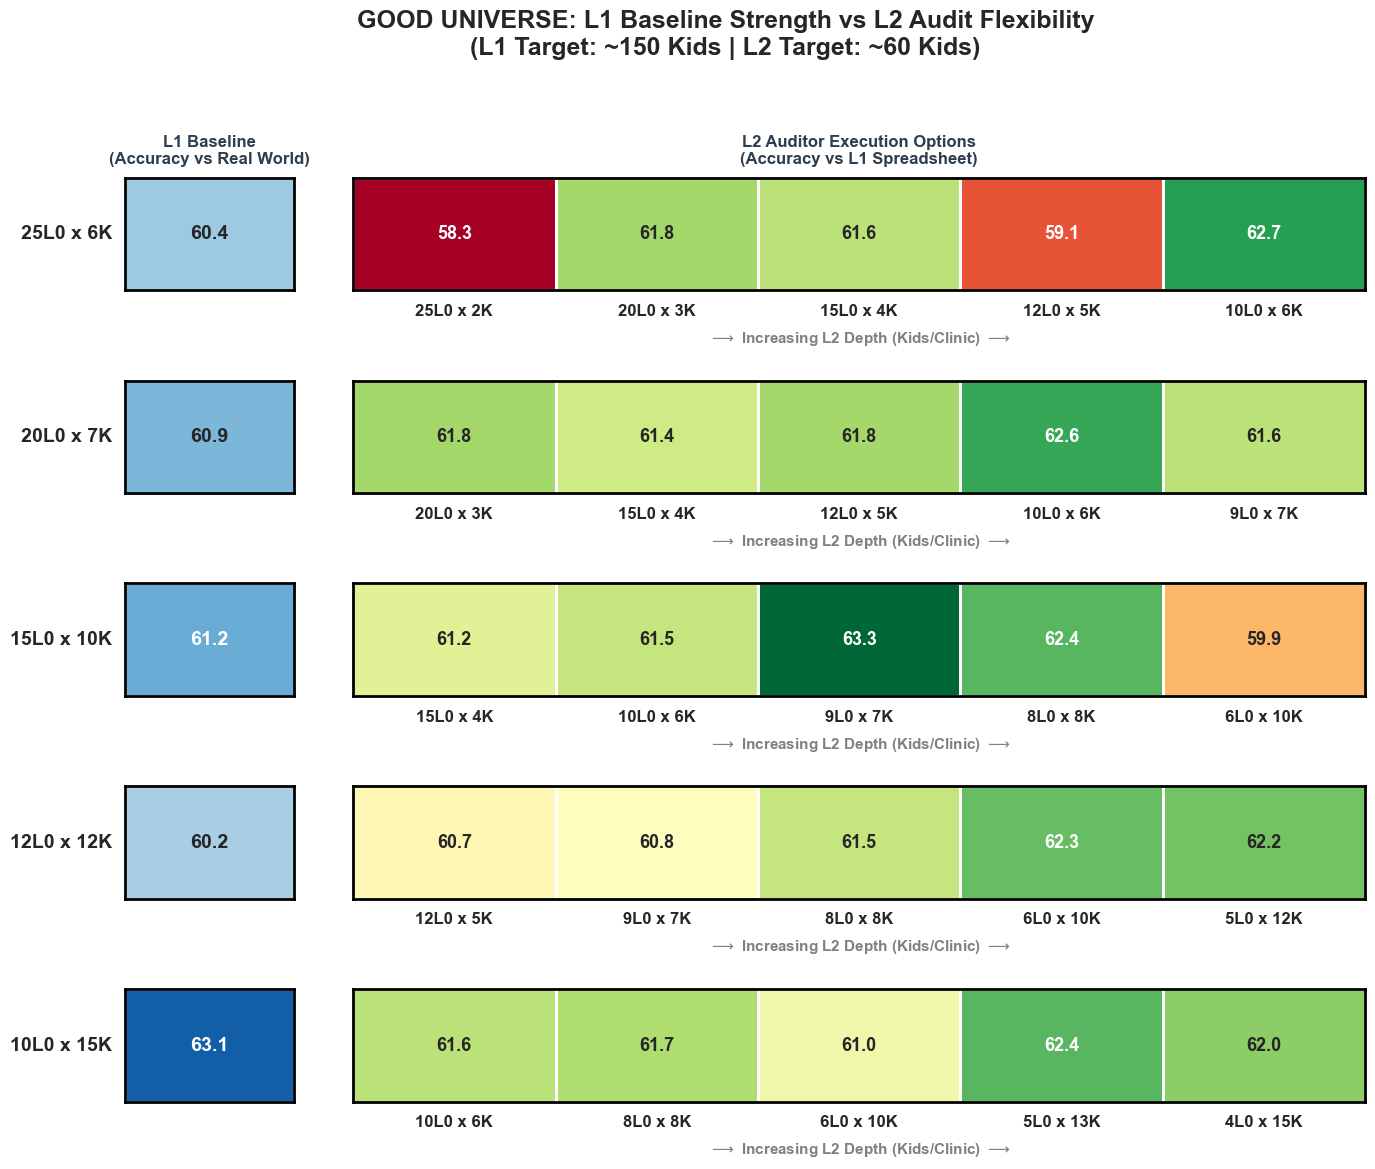

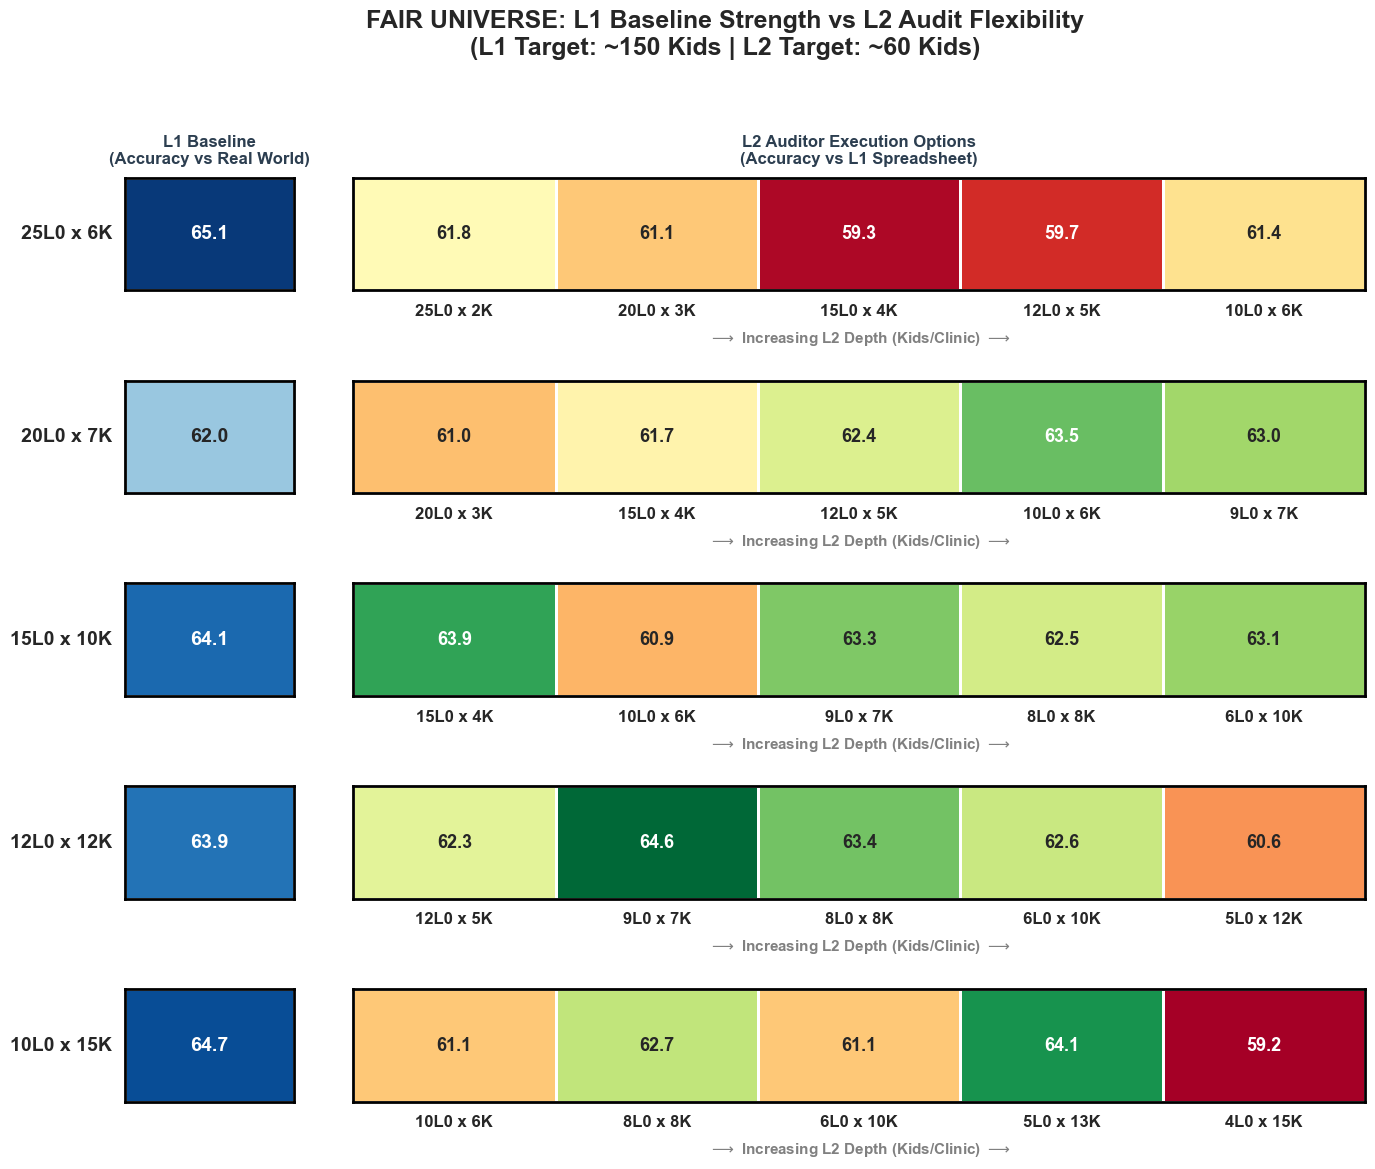

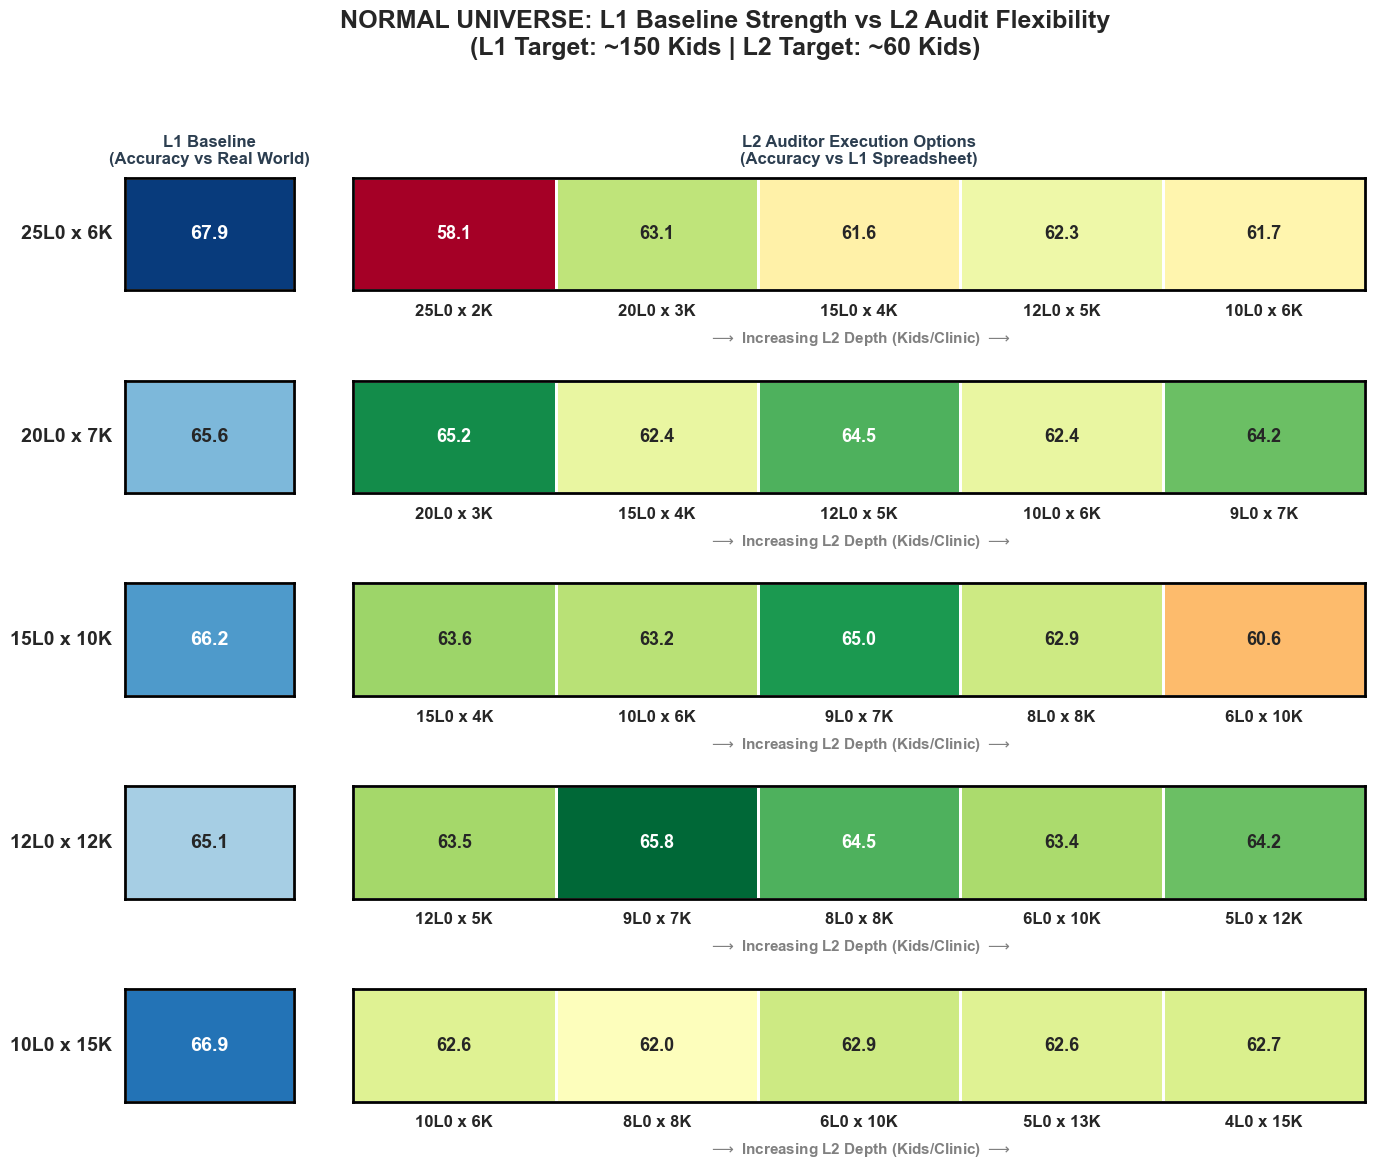

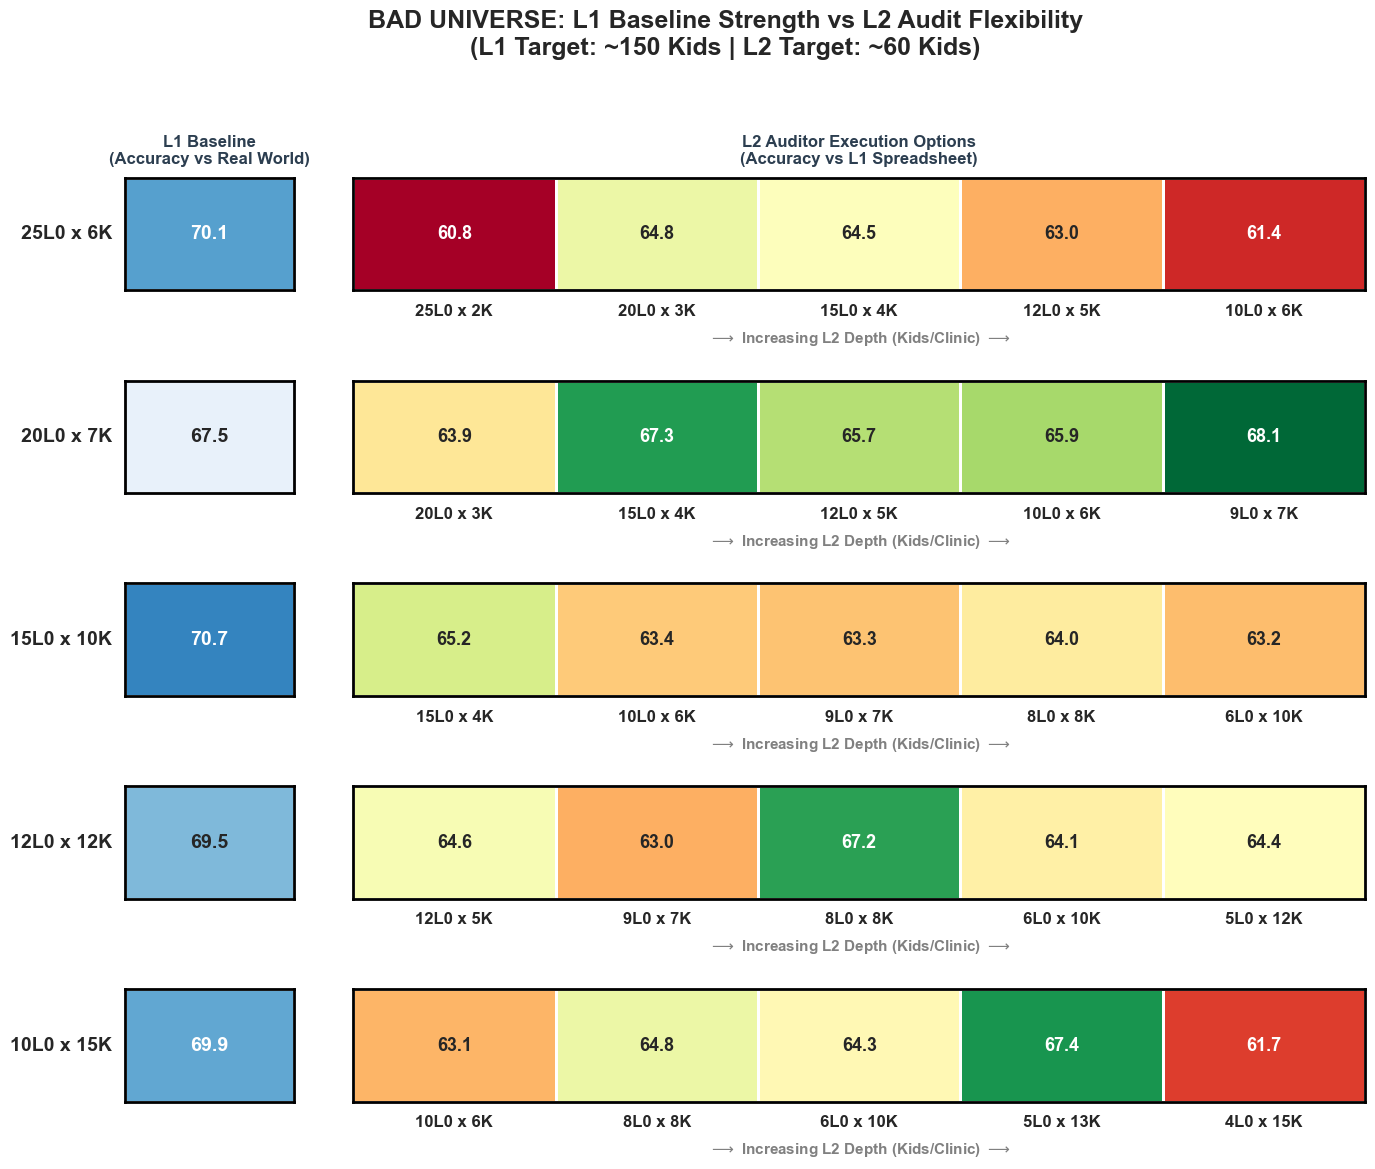

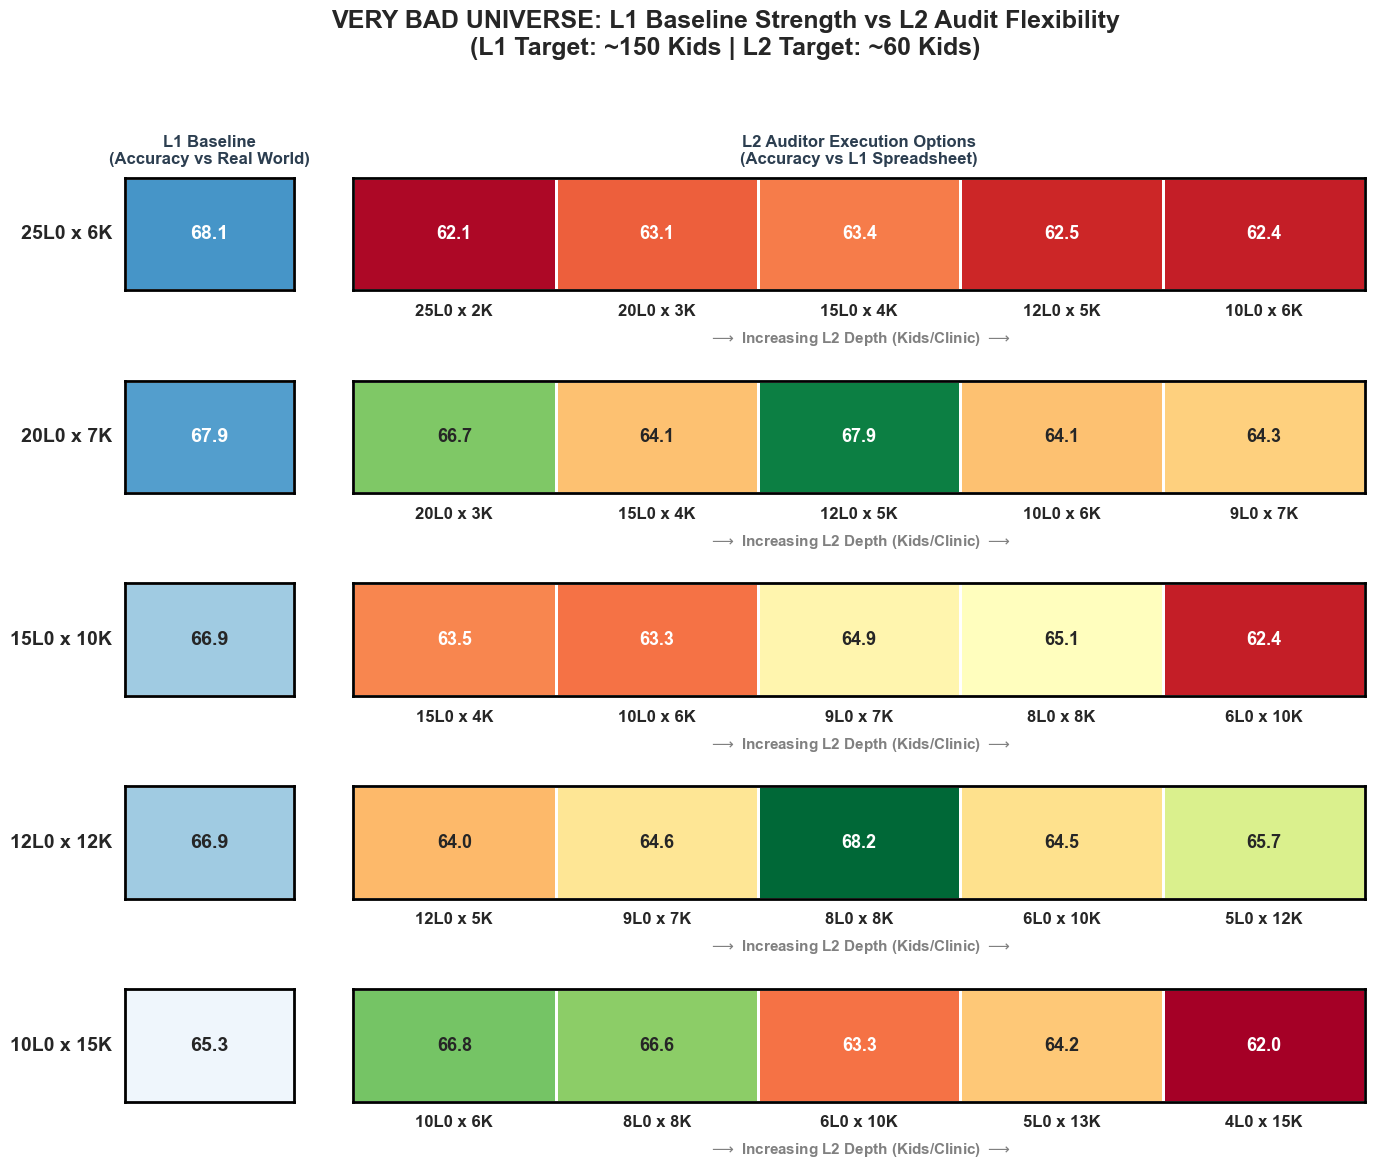

In [ ]:
# l2 ranking l1 heatma matrix code
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import os
import matplotlib.gridspec as gridspec
from datetime import datetime

# ==============================================================================
# 0. SETUP UNIVERSES & GLOBALS
# ==============================================================================
datasets_to_run = {
    "Good": "sensitivity_dataset_TRUE_Good_20260324_100502.parquet",
    "Fair": "sensitivity_dataset_Fair_20260323_115454.parquet",
    "Normal": "sensitivity_dataset_Normal_20260323_150757.parquet",
    "Bad": "sensitivity_dataset_Bad_20260323_132920.parquet",
    "Very Bad": "sensitivity_dataset_Very_Bad_20260323_141221.parquet"
}

target_count = 100 
n_simulations = 10 

# Adjusted budgets to respect the 15-kid physical constraint (replace=False)
l2_budget_target = 60 
l1_combos = [(25, 6), (20, 7), (15, 10), (12, 12), (10, 15)] 

all_results = []
print("🚀 INITIATING STANDARD NESTED L1/L2 HEATMAP ENGINE...\n")

# ==============================================================================
# 1. RUN THE SEQUENTIAL SIMULATION FOR ALL UNIVERSES
# ==============================================================================
for universe_name, file_name in datasets_to_run.items():
    if not os.path.exists(file_name):
        print(f"❌ Error: Cannot find '{file_name}'. Skipping...")
        continue

    print(f"⚙️ Simulating {universe_name.upper()} Universe...")
    df = pd.read_parquet(file_name)
    df['l1_mistake_haz'] = np.abs(df['L1_haz'] - df['real_haz'])

    # Global Truth for THIS Universe
    global_god = df.groupby('L1_id')[['l1_mistake_haz']].mean().reset_index()
    global_god['rank_global'] = global_god['l1_mistake_haz'].rank(method='first', ascending=False)
    global_true_bad = set(global_god[global_god['rank_global'] <= target_count]['L1_id'])

    # Build valid L2 targets dynamically based on the current L1 combination
    all_combos = []
    for l1_c, l1_k in l1_combos:
        k_min = max(1, int(np.round(l2_budget_target / l1_c)))
        k_max = l1_k
        target_depths = np.unique(np.round(np.linspace(k_min, k_max, 5)).astype(int))
        
        for k2 in target_depths:
            c2 = max(1, int(np.round(l2_budget_target / k2)))
            if c2 > l1_c: c2 = l1_c
            
            all_combos.append({
                'L1_C': l1_c, 'L1_K': l1_k, 'L1_Label': f"{l1_c}L0 x {l1_k}K",
                'L2_C': c2, 'L2_K': k2, 'L2_Depth': k2, 'L2_Label': f"{c2}L0 x {k2}K" 
            })

    # Drop any duplicate L2 execution paths
    combo_list = pd.DataFrame(all_combos).drop_duplicates(subset=['L1_C', 'L2_C', 'L2_K']).to_dict('records')

    # Standard Sequential Simulation Loop with Progress Bar
    for combo in tqdm(combo_list, desc=f"   Sampling Matrices", leave=False):
        l1_overlaps = []
        l2_overlaps = []
        
        for _ in range(n_simulations):
            # L1 Environment (replace=False safe!)
            l1_clinics = df[['L1_id', 'L0_id']].drop_duplicates().groupby('L1_id').sample(n=combo['L1_C'], replace=False)
            l1_pool = df.merge(l1_clinics, on=['L1_id', 'L0_id']).groupby(['L1_id', 'L0_id']).sample(n=combo['L1_K'], replace=False)
            
            god_mode = l1_pool.groupby('L1_id')[['l1_mistake_haz']].mean().reset_index()
            god_mode['rank_god'] = god_mode['l1_mistake_haz'].rank(method='first', ascending=False)
            true_bad_l1 = set(god_mode[god_mode['rank_god'] <= target_count]['L1_id'])
            
            # L1 Accuracy vs Global Biological Truth
            l1_overlaps.append(len(true_bad_l1 & global_true_bad))
            
            # L2 Environment (Sampled DIRECTLY FROM L1 pool)
            l2_clinics = l1_pool[['L1_id', 'L0_id']].drop_duplicates().groupby('L1_id').sample(n=combo['L2_C'], replace=False)
            l2_sample = l1_pool.merge(l2_clinics, on=['L1_id', 'L0_id']).groupby(['L1_id', 'L0_id']).sample(n=combo['L2_K'], replace=False)
            
            l2_means = l2_sample.groupby('L1_id')[['l1_mistake_haz']].mean().reset_index()
            l2_means['rank_audit'] = l2_means['l1_mistake_haz'].rank(method='first', ascending=False)
            flagged_l2 = set(l2_means[l2_means['rank_audit'] <= target_count]['L1_id'])
            
            # L2 Accuracy vs L1 Spreadsheet
            l2_overlaps.append(len(flagged_l2 & true_bad_l1))
            
        row = combo.copy()
        row['Universe'] = universe_name
        row['L1_Accuracy_Mean'] = np.mean(l1_overlaps)
        row['L2_Accuracy_Mean'] = np.mean(l2_overlaps)
        all_results.append(row)

df_plot = pd.DataFrame(all_results)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
df_plot.to_csv(f'Nested_Heatmap_Data_{timestamp}.csv', index=False)
print("\n✅ DATA GENERATION COMPLETE. Generating Heatmaps...")

# ==============================================================================
# 2. PLOT THE SPLIT-PANE HEATMAP FOR EACH UNIVERSE
# ==============================================================================
sns.set_theme(style="white")
l1_order = [f"{c}L0 x {k}K" for c, k in l1_combos]

for uni in datasets_to_run.keys():
    subset_uni = df_plot[df_plot['Universe'] == uni]
    if subset_uni.empty: continue
    
    # Independent color scales per universe to highlight local trends
    vmin_l2, vmax_l2 = subset_uni['L2_Accuracy_Mean'].min(), subset_uni['L2_Accuracy_Mean'].max()
    vmin_l1, vmax_l1 = subset_uni['L1_Accuracy_Mean'].min(), subset_uni['L1_Accuracy_Mean'].max()

    fig = plt.figure(figsize=(16, 12), dpi=100)
    gs = gridspec.GridSpec(nrows=len(l1_order), ncols=2, width_ratios=[1, 6], wspace=0.1, hspace=0.8)

    for i, l1_lbl in enumerate(l1_order):
        ax_l1 = fig.add_subplot(gs[i, 0]) 
        ax_l2 = fig.add_subplot(gs[i, 1]) 
        
        subset = subset_uni[subset_uni['L1_Label'] == l1_lbl].copy()
        subset.sort_values(by='L2_Depth', inplace=True)
        
        # --- LEFT HEATMAP: L1 BASELINE ACCURACY ---
        l1_acc_value = subset['L1_Accuracy_Mean'].iloc[0] 
        sns.heatmap(
            np.array([[l1_acc_value]]), annot=True, fmt=".1f", cmap="Blues", 
            cbar=False, linewidths=2, linecolor='white', vmin=vmin_l1, vmax=vmax_l1, 
            ax=ax_l1, annot_kws={"size": 14, "weight": "bold"}
        )
        
        ax_l1.set_xticks([])
        ax_l1.set_yticks([0.5])
        ax_l1.set_yticklabels([l1_lbl], rotation=0, fontsize=14, fontweight='bold')
        
        if i == 0:
            ax_l1.set_title("L1 Baseline\n(Accuracy vs Real World)", fontsize=12, fontweight='bold', color='#2c3e50', pad=10)
        
        # --- RIGHT HEATMAP: L2 EXECUTION MENU ---
        heatmap_data_l2 = subset[['L2_Accuracy_Mean']].T 
        l2_labels = subset['L2_Label'].tolist()
        
        sns.heatmap(
            heatmap_data_l2, annot=True, fmt=".1f", cmap="RdYlGn", 
            cbar=False, linewidths=2, linecolor='white', vmin=vmin_l2, vmax=vmax_l2, 
            ax=ax_l2, annot_kws={"size": 13, "weight": "bold"}
        )
        
        ax_l2.set_yticks([])
        ax_l2.set_xticks(np.arange(len(l2_labels)) + 0.5)
        ax_l2.set_xticklabels(l2_labels, rotation=0, fontsize=12, fontweight='bold')
        ax_l2.set_xlabel(r"$\longrightarrow$ Increasing L2 Depth (Kids/Clinic) $\longrightarrow$", 
                         fontsize=11, fontweight='bold', color='grey', labelpad=8)
        
        if i == 0:
            ax_l2.set_title("L2 Auditor Execution Options\n(Accuracy vs L1 Spreadsheet)", fontsize=12, fontweight='bold', color='#2c3e50', pad=10)

        # Draw borders around both
        for ax in [ax_l1, ax_l2]:
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(2)
                spine.set_color('black')

    fig.suptitle(f"{uni.upper()} UNIVERSE: L1 Baseline Strength vs L2 Audit Flexibility\n(L1 Target: ~150 Kids | L2 Target: ~60 Kids)", 
                 fontsize=18, fontweight='bold', y=1.02)

    plot_filename = f"Heatmap_{uni}_{timestamp}.png"
    plt.savefig(plot_filename, bbox_inches='tight')
    plt.show()

## 4.004 April 4 saturday 2026

In [1]:
import pandas as pd
import numpy as np
import os
from tqdm.auto import tqdm
from datetime import datetime

# ==============================================================================
# CHUNK 0: INITIALIZATION & CONFIGURATION
# ==============================================================================
print("🚀 BOOTING UP: Grand Master Engine (Percentage-Based Matrix)...")

universe_files = {
    "Utopia": "sensitivity_dataset_1_Utopia_ZeroError.parquet",
    "Blind Spot": "sensitivity_dataset_2_BlindSpot_ZeroError.parquet",
    "Whistleblowers": "sensitivity_dataset_3_Whistleblowers_ZeroError.parquet",
    "Mafia": "sensitivity_dataset_4_Mafia_ZeroError.parquet",
    "Normal": "master_golden_dataset_266k.parquet" 
}

TARGET_L1_COUNT = 100
TARGET_L0_PERCENTILE = 0.30 
N_SIMULATIONS = 1           # TRACER BULLET

# System Limits
MAX_L1_CLINICS = 25
MAX_KIDS_PER_CLINIC = 15
TOTAL_L1_KIDS = MAX_L1_CLINICS * MAX_KIDS_PER_CLINIC  # 375 kids

# The 5 Tiers of Effort
PERCENTAGES = [0.20, 0.40, 0.60, 0.80, 1.00]

master_database = []

# ==============================================================================
# HELPER FUNCTIONS: DYNAMIC STRATEGY GENERATORS
# ==============================================================================
def calculate_metrics(df, group_cols, col_meas, col_baseline):
    """Calculates MAE, RMSE, and 90th Percentile for a given dataframe"""
    temp_df = df.copy()
    temp_df['_err'] = np.abs(temp_df[col_meas] - temp_df[col_baseline])
    temp_df['_sq_err'] = temp_df['_err'] ** 2
    
    agg = temp_df.groupby(group_cols).agg(
        MAE=('_err', 'mean'),
        RMSE=('_sq_err', lambda x: np.sqrt(np.mean(x))),
        P90=('_err', lambda x: np.quantile(x, 0.90))
    ).reset_index()
    return agg

def get_top_k_overlap(ranked_df, god_set, rank_col, target_k):
    """Safely calculates overlap percentage"""
    ranked_df = ranked_df.sort_values(by=rank_col, ascending=False).reset_index(drop=True)
    caught_set = set(ranked_df.head(target_k)['L1_id'])
    if target_k == 0: return 0.0
    return (len(caught_set & god_set) / target_k) * 100

def generate_dynamic_strategies(budget, max_c, max_k, target_qty=6):
    """Dynamically generates perfectly spaced Breadth x Depth combinations"""
    strats = []
    min_k = max(1, int(np.floor(budget / max_c)))
    max_possible_k = min(max_k, budget)
    
    if min_k > max_possible_k: return [(max_c, max_k)]
        
    raw_ks = np.unique(np.round(np.linspace(min_k, max_possible_k, target_qty * 2)).astype(int))
    
    for k in raw_ks:
        c = int(np.round(budget / k))
        if 1 <= c <= max_c and c * k <= max_c * max_k:
            if (c, k) not in strats:
                strats.append((c, k))
                
    # Sort by Breadth descending (Wide to Deep)
    strats = sorted(strats, key=lambda x: x[0], reverse=True)
    
    # Extract exactly 'target_qty' evenly spaced strategies
    if len(strats) > target_qty:
        indices = np.round(np.linspace(0, len(strats)-1, target_qty)).astype(int)
        strats = [strats[i] for i in indices]
        
    # Pad if we mathematically couldn't find 6
    while 0 < len(strats) < target_qty:
        strats.append(strats[-1])
        
    return strats

# ==============================================================================
# MAIN ENGINE LOOP
# ==============================================================================
for uni_name, file_name in universe_files.items():
    if not os.path.exists(file_name):
        print(f"⚠️ Skipping {uni_name}: '{file_name}' not found.")
        continue
        
    print(f"\n🌍 PROCESSING UNIVERSE: {uni_name.upper()}")
    df_pop = pd.read_parquet(file_name)
    
    # --------------------------------------------------------------------------
    # CHUNK 1: THE "GOD MODE" BASELINE
    # --------------------------------------------------------------------------
    god_l1 = calculate_metrics(df_pop, ['L1_id'], 'L1_haz', 'real_haz')
    god_l1_mae_set = set(god_l1.nlargest(TARGET_L1_COUNT, 'MAE')['L1_id'])
    god_l1_rmse_set = set(god_l1.nlargest(TARGET_L1_COUNT, 'RMSE')['L1_id'])
    god_l1_p90_set = set(god_l1.nlargest(TARGET_L1_COUNT, 'P90')['L1_id'])
    
    god_l0 = calculate_metrics(df_pop, ['L1_id', 'L0_id'], 'L0_haz', 'real_haz')
    l0_targets = god_l0.groupby('L1_id').size().apply(lambda x: int(np.floor(x * TARGET_L0_PERCENTILE))).to_dict()
    
    god_l0_sets = {'MAE': {}, 'RMSE': {}, 'P90': {}}
    for l1_id in god_l0['L1_id'].unique():
        target = l0_targets.get(l1_id, 0)
        l1_subset = god_l0[god_l0['L1_id'] == l1_id]
        god_l0_sets['MAE'][l1_id] = set(l1_subset.nlargest(target, 'MAE')['L0_id'])
        god_l0_sets['RMSE'][l1_id] = set(l1_subset.nlargest(target, 'RMSE')['L0_id'])
        god_l0_sets['P90'][l1_id] = set(l1_subset.nlargest(target, 'P90')['L0_id'])

    # --------------------------------------------------------------------------
    # CHUNK 2 & 3: L1 EXECUTION (% BASED)
    # --------------------------------------------------------------------------
    for l1_pct in tqdm(PERCENTAGES, desc=f"   Sweeping L1 Budgets", leave=False):
        l1_budget = int(TOTAL_L1_KIDS * l1_pct)
        l1_strategies = generate_dynamic_strategies(l1_budget, MAX_L1_CLINICS, MAX_KIDS_PER_CLINIC, 6)
        
        for l1_c, l1_k in l1_strategies:
            for sim_id in range(N_SIMULATIONS):
                
                # 1. Sample L1 Spreadsheet
                l1_clinics = df_pop[['L1_id', 'L0_id']].drop_duplicates().groupby('L1_id').sample(n=l1_c, replace=False)
                df_l1_sheet = df_pop.merge(l1_clinics, on=['L1_id', 'L0_id']).groupby(['L1_id', 'L0_id']).sample(n=l1_k, replace=False)
                
                # 2. L1 Global Accuracy (Vector 1)
                l1_vs_real = calculate_metrics(df_l1_sheet, ['L1_id'], 'L1_haz', 'real_haz')
                v1_mae_acc = get_top_k_overlap(l1_vs_real, god_l1_mae_set, 'MAE', TARGET_L1_COUNT)
                v1_rmse_acc = get_top_k_overlap(l1_vs_real, god_l1_rmse_set, 'RMSE', TARGET_L1_COUNT)
                v1_p90_acc = get_top_k_overlap(l1_vs_real, god_l1_p90_set, 'P90', TARGET_L1_COUNT)
                
                # 3. L1 Intra-Regional Accuracy (Vector 2)
                l1_vs_l0 = calculate_metrics(df_l1_sheet, ['L1_id', 'L0_id'], 'L1_haz', 'L0_haz')
                v2_acc = {'MAE': [], 'RMSE': [], 'P90': []}
                for l1_id in l1_vs_l0['L1_id'].unique():
                    targ = l0_targets.get(l1_id, 0)
                    if targ == 0: continue
                    subset = l1_vs_l0[l1_vs_l0['L1_id'] == l1_id]
                    v2_acc['MAE'].append(len(set(subset.nlargest(targ, 'MAE')['L0_id']) & god_l0_sets['MAE'].get(l1_id, set())) / targ)
                    v2_acc['RMSE'].append(len(set(subset.nlargest(targ, 'RMSE')['L0_id']) & god_l0_sets['RMSE'].get(l1_id, set())) / targ)
                    v2_acc['P90'].append(len(set(subset.nlargest(targ, 'P90')['L0_id']) & god_l0_sets['P90'].get(l1_id, set())) / targ)
                
                v2_mae_acc = np.mean(v2_acc['MAE'])*100 if v2_acc['MAE'] else 0
                v2_rmse_acc = np.mean(v2_acc['RMSE'])*100 if v2_acc['RMSE'] else 0
                v2_p90_acc = np.mean(v2_acc['P90'])*100 if v2_acc['P90'] else 0

                # ----------------------------------------------------------------------
                # CHUNK 4 & 5: L2 EXECUTION (% BASED ON L1)
                # ----------------------------------------------------------------------
                for l2_pct in PERCENTAGES:
                    l2_budget = int((l1_c * l1_k) * l2_pct)
                    
                    # L2 cannot exceed L1's boundaries
                    l2_strategies = generate_dynamic_strategies(l2_budget, max_c=l1_c, max_k=l1_k, target_qty=6)
                    
                    for l2_c, l2_k in l2_strategies:
                        # L2 samples strictly from the L1 Spreadsheet
                        l2_clinics = df_l1_sheet[['L1_id', 'L0_id']].drop_duplicates().groupby('L1_id').sample(n=l2_c, replace=False)
                        df_l2_audit = df_l1_sheet.merge(l2_clinics, on=['L1_id', 'L0_id']).groupby(['L1_id', 'L0_id']).sample(n=l2_k, replace=False)
                        
                        # Vector 3: L2 vs L1
                        l2_vs_l1 = calculate_metrics(df_l2_audit, ['L1_id'], 'L2_haz', 'L1_haz')
                        v3_mae_acc = get_top_k_overlap(l2_vs_l1, god_l1_mae_set, 'MAE', TARGET_L1_COUNT)
                        v3_rmse_acc = get_top_k_overlap(l2_vs_l1, god_l1_rmse_set, 'RMSE', TARGET_L1_COUNT)
                        v3_p90_acc = get_top_k_overlap(l2_vs_l1, god_l1_p90_set, 'P90', TARGET_L1_COUNT)
                        
                        # ------------------------------------------------------------------
                        # CHUNK 6: FLATTEN & RECORD DATA
                        # ------------------------------------------------------------------
                        master_database.append({
                            'Universe': uni_name,
                            'Sim_ID': sim_id,
                            
                            'L1_Budget_Pct': f"{int(l1_pct*100)}%",
                            'L1_Budget_K': l1_c * l1_k,
                            'L1_C': l1_c, 'L1_K': l1_k, 'L1_Label': f"{l1_c}C x {l1_k}K",
                            
                            'L2_Budget_Pct': f"{int(l2_pct*100)}%",
                            'L2_Budget_K': l2_c * l2_k,
                            'L2_C': l2_c, 'L2_K': l2_k, 'L2_Label': f"{l2_c}C x {l2_k}K",
                            
                            # Vector 1: L1 vs Real World (Global)
                            'V1_MAE_Acc': v1_mae_acc, 'V1_RMSE_Acc': v1_rmse_acc, 'V1_P90_Acc': v1_p90_acc,
                            
                            # Vector 2: L1 vs L0 (Intra-Regional)
                            'V2_MAE_Acc': v2_mae_acc, 'V2_RMSE_Acc': v2_rmse_acc, 'V2_P90_Acc': v2_p90_acc,
                            
                            # Vector 3: L2 vs L1 (Global Audit)
                            'V3_MAE_Acc': v3_mae_acc, 'V3_RMSE_Acc': v3_rmse_acc, 'V3_P90_Acc': v3_p90_acc
                        })

print("\n⚙️ Compilation complete. Building Master Database...")
final_df = pd.DataFrame(master_database)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
export_name = f"Tracer_Master_DB_Percentages_{timestamp}.csv"
final_df.to_csv(export_name, index=False)

print("="*80)
print(f"✅ SUCCESS! Percent-based Tracer Bullet fired.")
print(f"📁 Exported {len(final_df)} combinatorial rows to: {export_name}")
print("="*80)

c:\Users\CEGIS FOUNDATION\New folder\GitHub\discsim\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 BOOTING UP: Grand Master Engine (Percentage-Based Matrix)...

🌍 PROCESSING UNIVERSE: UTOPIA



🌍 PROCESSING UNIVERSE: BLIND SPOT



🌍 PROCESSING UNIVERSE: WHISTLEBLOWERS



🌍 PROCESSING UNIVERSE: MAFIA



🌍 PROCESSING UNIVERSE: NORMAL



⚙️ Compilation complete. Building Master Database...
✅ SUCCESS! Percent-based Tracer Bullet fired.
📁 Exported 4500 combinatorial rows to: Tracer_Master_DB_Percentages_20260404_150153.csv


As the L2 comparison is wrong, we have corrected the mistake. 
we calculated L2 vs whole population. we must do the comparison vs the score of L1 population to rank l1 only


In [16]:
import pandas as pd
import numpy as np
import os
from tqdm.auto import tqdm
from datetime import datetime

# ==============================================================================
# CHUNK 0: INITIALIZATION & CONFIGURATION
# ==============================================================================
print("🚀 BOOTING UP: Grand Master Engine (Strict Unskewed Mathematics)...")

universe_files = {
    "Utopia": "../sensitivity_dataset_1_Utopia_ZeroError.parquet",
    "Blind Spot": "../sensitivity_dataset_2_BlindSpot_ZeroError.parquet",
    "Whistleblowers": "../sensitivity_dataset_3_Whistleblowers_ZeroError.parquet",
    "Mafia": "../sensitivity_dataset_4_Mafia_ZeroError.parquet",
    "Normal": "../master_golden_dataset_266k.parquet" 
}

TARGET_L1_COUNT = 100
TARGET_L0_PERCENTILE = 0.30 
N_SIMULATIONS = 1           # TRACER BULLET (Change to 30 later)

# System Limits
MAX_L1_CLINICS = 25
MAX_KIDS_PER_CLINIC = 15
TOTAL_L1_KIDS = MAX_L1_CLINICS * MAX_KIDS_PER_CLINIC  # 375 kids

PERCENTAGES = [0.20, 0.40, 0.60, 0.80, 1.00]
master_database = []

# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================
def calculate_metrics(df, group_cols, col_meas, col_baseline):
    temp_df = df.copy()
    temp_df['_err'] = np.abs(temp_df[col_meas] - temp_df[col_baseline])
    temp_df['_sq_err'] = temp_df['_err'] ** 2
    
    agg = temp_df.groupby(group_cols).agg(
        MAE=('_err', 'mean'),
        RMSE=('_sq_err', lambda x: np.sqrt(np.mean(x))),
        P90=('_err', lambda x: np.quantile(x, 0.90))
    ).reset_index()
    return agg

def get_top_k_overlap(ranked_df, god_set, rank_col, target_k, tie_breaker_col='L1_id'):
    ranked_df = ranked_df.sort_values(by=[rank_col, tie_breaker_col], ascending=[False, True]).reset_index(drop=True)
    caught_set = set(ranked_df.head(target_k)[tie_breaker_col])
    if target_k == 0: return 0.0
    return (len(caught_set & god_set) / target_k) * 100

def generate_dynamic_strategies(budget, max_c, max_k, target_qty=6):
    strats = []
    min_k = max(1, int(np.floor(budget / max_c)))
    max_possible_k = min(max_k, budget)
    
    if min_k > max_possible_k: return [(max_c, max_k)]
        
    raw_ks = np.unique(np.round(np.linspace(min_k, max_possible_k, target_qty * 2)).astype(int))
    
    for k in raw_ks:
        c = int(np.round(budget / k))
        if 1 <= c <= max_c and c * k <= max_c * max_k:
            if (c, k) not in strats: strats.append((c, k))
                
    strats = sorted(strats, key=lambda x: x[0], reverse=True)
    if len(strats) > target_qty:
        indices = np.round(np.linspace(0, len(strats)-1, target_qty)).astype(int)
        strats = [strats[i] for i in indices]
    while 0 < len(strats) < target_qty:
        strats.append(strats[-1])
    return strats

# ==============================================================================
# MAIN ENGINE LOOP
# ==============================================================================
for uni_name, file_name in universe_files.items():
    if not os.path.exists(file_name):
        print(f"⚠️ Skipping {uni_name}: '{file_name}' not found.")
        continue
        
    print(f"\n🌍 PROCESSING UNIVERSE: {uni_name.upper()}")
    df_pop = pd.read_parquet(file_name)
    
    # --------------------------------------------------------------------------
    # CHUNK 1: THE GLOBAL "GOD MODE" BASELINES (Using 100% Population)
    # --------------------------------------------------------------------------
    # V1 God: Rank all L1s (L0 Clinic Fraud vs Reality)
    god_l1 = calculate_metrics(df_pop, ['L1_id'], 'L0_haz', 'real_haz')
    god_l1_mae_set = set(god_l1.sort_values(by=['MAE', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])
    god_l1_rmse_set = set(god_l1.sort_values(by=['RMSE', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])
    god_l1_p90_set = set(god_l1.sort_values(by=['P90', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])
    
    # V2 God: Rank all L0 Clinics inside each L1 (L0 Clinic vs Reality)
    god_l0 = calculate_metrics(df_pop, ['L1_id', 'L0_id'], 'L0_haz', 'real_haz')
    l0_targets = god_l0.groupby('L1_id').size().apply(lambda x: int(np.floor(x * TARGET_L0_PERCENTILE))).to_dict()
    
    god_l0_sets = {'MAE': {}, 'RMSE': {}, 'P90': {}}
    for l1_id in god_l0['L1_id'].unique():
        target = l0_targets.get(l1_id, 0)
        l1_subset = god_l0[god_l0['L1_id'] == l1_id]
        
        god_l0_sets['MAE'][l1_id] = set(l1_subset.sort_values(by=['MAE', 'L0_id'], ascending=[False, True]).head(target)['L0_id'])
        god_l0_sets['RMSE'][l1_id] = set(l1_subset.sort_values(by=['RMSE', 'L0_id'], ascending=[False, True]).head(target)['L0_id'])
        god_l0_sets['P90'][l1_id] = set(l1_subset.sort_values(by=['P90', 'L0_id'], ascending=[False, True]).head(target)['L0_id'])

    # --------------------------------------------------------------------------
    # CHUNK 2 & 3: L1 EXECUTION (% BASED)
    # --------------------------------------------------------------------------
    for l1_pct in tqdm(PERCENTAGES, desc=f"    Sweeping L1 Budgets", leave=False):
        l1_budget = int(TOTAL_L1_KIDS * l1_pct)
        l1_strategies = generate_dynamic_strategies(l1_budget, MAX_L1_CLINICS, MAX_KIDS_PER_CLINIC, 6)
        
        for l1_c, l1_k in l1_strategies:
            for sim_id in range(N_SIMULATIONS):
                
                # 1. Sample L1 Spreadsheet
                l1_clinics = df_pop[['L1_id', 'L0_id']].drop_duplicates().groupby('L1_id').sample(n=l1_c, replace=False)
                df_l1_sheet = df_pop.merge(l1_clinics, on=['L1_id', 'L0_id']).groupby(['L1_id', 'L0_id']).sample(n=l1_k, replace=False)
                
                # --------------------------------------------------------------
                # VECTOR 1: L1 Global Accuracy (L1-L0 Sample vs God's Population Baseline)
                # --------------------------------------------------------------
                l1_diagnosis = calculate_metrics(df_l1_sheet, ['L1_id'], 'L1_haz', 'L0_haz')
                v1_mae_acc = get_top_k_overlap(l1_diagnosis, god_l1_mae_set, 'MAE', TARGET_L1_COUNT, 'L1_id')
                v1_rmse_acc = get_top_k_overlap(l1_diagnosis, god_l1_rmse_set, 'RMSE', TARGET_L1_COUNT, 'L1_id')
                v1_p90_acc = get_top_k_overlap(l1_diagnosis, god_l1_p90_set, 'P90', TARGET_L1_COUNT, 'L1_id')
                
                # --------------------------------------------------------------
                # VECTOR 2: L1 Intra-Regional Accuracy (L1-L0 Sample vs God's Population Baseline)
                # --------------------------------------------------------------
                l1_vs_l0_clinic = calculate_metrics(df_l1_sheet, ['L1_id', 'L0_id'], 'L1_haz', 'L0_haz')
                v2_acc = {'MAE': [], 'RMSE': [], 'P90': []}
                
                for l1_id in god_l0['L1_id'].unique():
                    targ = l0_targets.get(l1_id, 0)
                    if targ == 0: continue
                    
                    # If L1 visited this region, get their sample. Otherwise, empty set.
                    if l1_id in l1_vs_l0_clinic['L1_id'].values:
                        subset_l1 = l1_vs_l0_clinic[l1_vs_l0_clinic['L1_id'] == l1_id]
                        l1_caught_mae = set(subset_l1.sort_values(by=['MAE', 'L0_id'], ascending=[False, True]).head(targ)['L0_id'])
                        l1_caught_rmse = set(subset_l1.sort_values(by=['RMSE', 'L0_id'], ascending=[False, True]).head(targ)['L0_id'])
                        l1_caught_p90 = set(subset_l1.sort_values(by=['P90', 'L0_id'], ascending=[False, True]).head(targ)['L0_id'])
                    else:
                        l1_caught_mae, l1_caught_rmse, l1_caught_p90 = set(), set(), set()
                    
                    v2_acc['MAE'].append(len(l1_caught_mae & god_l0_sets['MAE'].get(l1_id, set())) / targ)
                    v2_acc['RMSE'].append(len(l1_caught_rmse & god_l0_sets['RMSE'].get(l1_id, set())) / targ)
                    v2_acc['P90'].append(len(l1_caught_p90 & god_l0_sets['P90'].get(l1_id, set())) / targ)
                
                v2_mae_acc = np.mean(v2_acc['MAE'])*100 if v2_acc['MAE'] else 0
                v2_rmse_acc = np.mean(v2_acc['RMSE'])*100 if v2_acc['RMSE'] else 0
                v2_p90_acc = np.mean(v2_acc['P90'])*100 if v2_acc['P90'] else 0

                # --------------------------------------------------------------
                # V3 SPREADSHEET TRUTH (God's evaluation of the submitted sample)
                # --------------------------------------------------------------
                sheet_truth = calculate_metrics(df_l1_sheet, ['L1_id'], 'L1_haz', 'real_haz')
                sheet_god_mae = set(sheet_truth.sort_values(by=['MAE', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])
                sheet_god_rmse = set(sheet_truth.sort_values(by=['RMSE', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])
                sheet_god_p90 = set(sheet_truth.sort_values(by=['P90', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])

                # ----------------------------------------------------------------------
                # CHUNK 4 & 5: L2 EXECUTION 
                # ----------------------------------------------------------------------
                for l2_pct in PERCENTAGES:
                    l2_budget = int((l1_c * l1_k) * l2_pct)
                    l2_strategies = generate_dynamic_strategies(l2_budget, max_c=l1_c, max_k=l1_k, target_qty=6)
                    
                    for l2_c, l2_k in l2_strategies:
                        # L2 samples strictly from the L1 Spreadsheet
                        l2_clinics = df_l1_sheet[['L1_id', 'L0_id']].drop_duplicates().groupby('L1_id').sample(n=l2_c, replace=False)
                        df_l2_audit = df_l1_sheet.merge(l2_clinics, on=['L1_id', 'L0_id']).groupby(['L1_id', 'L0_id']).sample(n=l2_k, replace=False)
                        
                        # --------------------------------------------------------------
                        # VECTOR 3: L2 Audit (L2-L1 Sample vs L1-Real Sample)
                        # --------------------------------------------------------------
                        l2_vs_l1 = calculate_metrics(df_l2_audit, ['L1_id'], 'L2_haz', 'L1_haz')
                        v3_mae_acc = get_top_k_overlap(l2_vs_l1, sheet_god_mae, 'MAE', TARGET_L1_COUNT, 'L1_id')
                        v3_rmse_acc = get_top_k_overlap(l2_vs_l1, sheet_god_rmse, 'RMSE', TARGET_L1_COUNT, 'L1_id')
                        v3_p90_acc = get_top_k_overlap(l2_vs_l1, sheet_god_p90, 'P90', TARGET_L1_COUNT, 'L1_id')
                        
                        # ------------------------------------------------------------------
                        # RECORD DATA
                        # ------------------------------------------------------------------
                        master_database.append({
                            'Universe': uni_name,
                            'Sim_ID': sim_id,
                            
                            'L1_Budget_Pct': f"{int(l1_pct*100)}%",
                            'L1_C': l1_c, 'L1_K': l1_k, 'L1_Label': f"{l1_c}C x {l1_k}K",
                            
                            'L2_Budget_Pct': f"{int(l2_pct*100)}%",
                            'L2_C': l2_c, 'L2_K': l2_k, 'L2_Label': f"{l2_c}C x {l2_k}K",
                            
                            'V1_MAE_Acc': v1_mae_acc, 'V1_RMSE_Acc': v1_rmse_acc, 'V1_P90_Acc': v1_p90_acc,
                            'V2_MAE_Acc': v2_mae_acc, 'V2_RMSE_Acc': v2_rmse_acc, 'V2_P90_Acc': v2_p90_acc,
                            'V3_MAE_Acc': v3_mae_acc, 'V3_RMSE_Acc': v3_rmse_acc, 'V3_P90_Acc': v3_p90_acc
                        })

print("\n⚙️ Compilation complete. Building Master Database...")
final_df = pd.DataFrame(master_database)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
export_name = f"Tracer_Master_DB_Percentages_{timestamp}.csv"
final_df.to_csv(export_name, index=False)

print("="*80)
print(f"✅ SUCCESS! Strictly enforced logic Tracer Bullet fired.")
print(f"📁 Exported {len(final_df)} combinatorial rows to: {export_name}")
print("="*80)

🚀 BOOTING UP: Grand Master Engine (Strict Unskewed Mathematics)...

🌍 PROCESSING UNIVERSE: UTOPIA



🌍 PROCESSING UNIVERSE: BLIND SPOT



🌍 PROCESSING UNIVERSE: WHISTLEBLOWERS



🌍 PROCESSING UNIVERSE: MAFIA



🌍 PROCESSING UNIVERSE: NORMAL



⚙️ Compilation complete. Building Master Database...
✅ SUCCESS! Strictly enforced logic Tracer Bullet fired.
📁 Exported 4500 combinatorial rows to: Tracer_Master_DB_Percentages_20260407_125843.csv


In [2]:
import pandas as pd
import numpy as np
import os

universe_files = {
    "Utopia": "sensitivity_dataset_1_Utopia_ZeroError.parquet",
    "Blind Spot": "sensitivity_dataset_2_BlindSpot_ZeroError.parquet",
    "Whistleblowers": "sensitivity_dataset_3_Whistleblowers_ZeroError.parquet",
    "Mafia": "sensitivity_dataset_4_Mafia_ZeroError.parquet",
    "Normal": "master_golden_dataset_266k.parquet" 
}

print("🔍 RUNNING MASS DIAGNOSTIC: THE 'SEA OF ZEROS' EFFECT\n" + "="*60)

for uni, filename in universe_files.items():
    # Tell Python to look one folder UP (in the main discsim folder)
    filepath = os.path.join("..", filename) 
    
    if not os.path.exists(filepath):
        print(f"⚠️ Skipping {uni}: Could not find {filepath}. Check your folder structure.")
        continue
        
    df = pd.read_parquet(filepath)
    
    # 100% Audit Simulation (Max Budget)
    l1_clinics = df[['L1_id', 'L0_id']].drop_duplicates().groupby('L1_id').sample(n=25, replace=False)
    df_l1_sheet = df.merge(l1_clinics, on=['L1_id', 'L0_id']).groupby(['L1_id', 'L0_id']).sample(n=15, replace=False)
    
    # L1 vs Reality (Spreadsheet Truth)
    temp_sheet = df_l1_sheet.copy()
    temp_sheet['_err_sheet'] = np.abs(temp_sheet['L1_haz'] - temp_sheet['real_haz'])
    sheet_truth = temp_sheet.groupby('L1_id')['_err_sheet'].mean().reset_index()
    zeros_sheet = (sheet_truth['_err_sheet'] == 0).sum()
    
    # L2 vs L1 (Audit)
    temp_l2 = df_l1_sheet.copy()
    temp_l2['_err_l2'] = np.abs(temp_l2['L2_haz'] - temp_l2['L1_haz'])
    l2_audit = temp_l2.groupby('L1_id')['_err_l2'].mean().reset_index()
    zeros_l2 = (l2_audit['_err_l2'] == 0).sum()
    
    print(f"🌍 UNIVERSE: {uni.upper()}")
    print(f"   -> Supervisors with EXACTLY 0.0 Error in Reality: {zeros_sheet} / {len(sheet_truth)}")
    print(f"   -> Supervisors with EXACTLY 0.0 Error to Auditor: {zeros_l2} / {len(l2_audit)}")
    print("-" * 60)

🔍 RUNNING MASS DIAGNOSTIC: THE 'SEA OF ZEROS' EFFECT
🌍 UNIVERSE: UTOPIA
   -> Supervisors with EXACTLY 0.0 Error in Reality: 0 / 334
   -> Supervisors with EXACTLY 0.0 Error to Auditor: 0 / 334
------------------------------------------------------------
🌍 UNIVERSE: BLIND SPOT
   -> Supervisors with EXACTLY 0.0 Error in Reality: 0 / 334
   -> Supervisors with EXACTLY 0.0 Error to Auditor: 0 / 334
------------------------------------------------------------
🌍 UNIVERSE: WHISTLEBLOWERS
   -> Supervisors with EXACTLY 0.0 Error in Reality: 0 / 334
   -> Supervisors with EXACTLY 0.0 Error to Auditor: 0 / 334
------------------------------------------------------------
🌍 UNIVERSE: MAFIA
   -> Supervisors with EXACTLY 0.0 Error in Reality: 0 / 334
   -> Supervisors with EXACTLY 0.0 Error to Auditor: 0 / 334
------------------------------------------------------------
🌍 UNIVERSE: NORMAL
   -> Supervisors with EXACTLY 0.0 Error in Reality: 0 / 335
   -> Supervisors with EXACTLY 0.0 Error to Audi

In [3]:
import pandas as pd
import numpy as np
import os

universe_files = {
    "Utopia": "sensitivity_dataset_1_Utopia_ZeroError.parquet",
    "Blind Spot": "sensitivity_dataset_2_BlindSpot_ZeroError.parquet",
    "Whistleblowers": "sensitivity_dataset_3_Whistleblowers_ZeroError.parquet",
    "Mafia": "sensitivity_dataset_4_Mafia_ZeroError.parquet",
    "Normal": "master_golden_dataset_266k.parquet" 
}

print("🚨 IDENTIFYING TRUE 'BAD' L1 SUPERVISORS 🚨\n" + "="*60)

for uni, filename in universe_files.items():
    # Looking one folder up into the main discsim folder
    filepath = os.path.join("..", filename) 
    
    if not os.path.exists(filepath):
        print(f"⚠️ Skipping {uni}: Could not find {filepath}.")
        continue
        
    df = pd.read_parquet(filepath)
    
    # Calculate True Error (God Mode) for each L1 Supervisor
    temp_df = df.copy()
    temp_df['_err'] = np.abs(temp_df['L1_haz'] - temp_df['real_haz'])
    l1_errors = temp_df.groupby('L1_id')['_err'].mean().reset_index()
    
    # Identify "Bad" L1s (anyone with an error greater than 0.0)
    bad_l1s = l1_errors[l1_errors['_err'] > 0].sort_values(by='_err', ascending=False)
    
    print(f"🌍 UNIVERSE: {uni.upper()}")
    print(f"   -> Total L1 Supervisors: {len(l1_errors)}")
    print(f"   -> Total 'Bad' L1s (Error > 0): {len(bad_l1s)}")
    
    if len(bad_l1s) > 0:
        print(f"   -> Top 5 Worst L1 IDs & Their Average Error:")
        for index, row in bad_l1s.head(5).iterrows():
            print(f"        - L1_id: {row['L1_id']} | MAE: {row['_err']:.4f}")
    else:
        print("   -> NO BAD L1s! Everyone has 0.0 error.")
        
    print("-" * 60)

🚨 IDENTIFYING TRUE 'BAD' L1 SUPERVISORS 🚨
🌍 UNIVERSE: UTOPIA
   -> Total L1 Supervisors: 334
   -> Total 'Bad' L1s (Error > 0): 334
   -> Top 5 Worst L1 IDs & Their Average Error:
        - L1_id: L1_32 | MAE: 0.1391
        - L1_id: L1_308 | MAE: 0.1388
        - L1_id: L1_123 | MAE: 0.1370
        - L1_id: L1_264 | MAE: 0.1362
        - L1_id: L1_263 | MAE: 0.1351
------------------------------------------------------------
🌍 UNIVERSE: BLIND SPOT
   -> Total L1 Supervisors: 334
   -> Total 'Bad' L1s (Error > 0): 334
   -> Top 5 Worst L1 IDs & Their Average Error:
        - L1_id: L1_111 | MAE: 0.3058
        - L1_id: L1_30 | MAE: 0.3022
        - L1_id: L1_211 | MAE: 0.3000
        - L1_id: L1_273 | MAE: 0.2975
        - L1_id: L1_317 | MAE: 0.2969
------------------------------------------------------------
🌍 UNIVERSE: WHISTLEBLOWERS
   -> Total L1 Supervisors: 334
   -> Total 'Bad' L1s (Error > 0): 334
   -> Top 5 Worst L1 IDs & Their Average Error:
        - L1_id: L1_174 | MAE: 0

In [8]:
import pandas as pd
import numpy as np
import os

print("🔍 RUNNING L2 AUDITOR RANKING TRACE: UTOPIA UNIVERSE")
print("="*80)

# Load the Utopia Universe
filepath = "../sensitivity_dataset_4_Mafia_ZeroError.parquet"
if not os.path.exists(filepath):
    print(f"⚠️ Error: Could not find {filepath}.")
    exit()
    
df = pd.read_parquet(filepath)

# ---------------------------------------------------------
# 1. ACTUAL TRUTH (God's Rank) - 100% Budget
# ---------------------------------------------------------
# God evaluates L1 against True Reality (L1_haz vs real_haz)
temp_truth = df.copy()
temp_truth['err_truth'] = np.abs(temp_truth['L1_haz'] - temp_truth['real_haz'])
truth_agg = temp_truth.groupby('L1_id')['err_truth'].mean().reset_index().rename(columns={'err_truth': 'MAE'})

# Sort to find the worst (Highest MAE)
truth_ranked = truth_agg.sort_values(by='MAE', ascending=False).reset_index(drop=True)
truth_ranked['Rank_Truth'] = truth_ranked.index + 1
top_100_truth = set(truth_ranked.head(100)['L1_id'])

# ---------------------------------------------------------
# 2. L2 AUDITOR - 100% BUDGET
# ---------------------------------------------------------
# L2 evaluates L1 against L2's tape measure (L2_haz vs L1_haz)
temp_l2_100 = df.copy()
temp_l2_100['err_l2'] = np.abs(temp_l2_100['L2_haz'] - temp_l2_100['L1_haz'])
l2_100_agg = temp_l2_100.groupby('L1_id')['err_l2'].mean().reset_index().rename(columns={'err_l2': 'MAE'})

l2_100_ranked = l2_100_agg.sort_values(by='MAE', ascending=False).reset_index(drop=True)
l2_100_ranked['Rank_L2_100'] = l2_100_ranked.index + 1
top_100_l2_100 = set(l2_100_ranked.head(100)['L1_id'])

# ---------------------------------------------------------
# 3. L2 AUDITOR - 50% BUDGET
# ---------------------------------------------------------
# L2 only audits 50% of the kids per supervisor
df_50 = df.groupby('L1_id').sample(frac=0.5, random_state=42)
temp_l2_50 = df_50.copy()
temp_l2_50['err_l2'] = np.abs(temp_l2_50['L2_haz'] - temp_l2_50['L1_haz'])
l2_50_agg = temp_l2_50.groupby('L1_id')['err_l2'].mean().reset_index().rename(columns={'err_l2': 'MAE'})

l2_50_ranked = l2_50_agg.sort_values(by='MAE', ascending=False).reset_index(drop=True)
l2_50_ranked['Rank_L2_50'] = l2_50_ranked.index + 1
top_100_l2_50 = set(l2_50_ranked.head(100)['L1_id'])

# ---------------------------------------------------------
# 4. MERGE AND DISPLAY RESULTS
# ---------------------------------------------------------
print(f"\n📊 TOP 15 WORST SUPERVISORS SIDE-BY-SIDE:")
print(f"{'RANK':<6} | {'ACTUAL TRUTH (God)':<25} | {'L2 AUDITOR (100% Budget)':<25} | {'L2 AUDITOR (50% Budget)':<25}")
print("-" * 85)

for i in range(15):
    t_id = truth_ranked.iloc[i]['L1_id']
    t_mae = truth_ranked.iloc[i]['MAE']
    
    l100_id = l2_100_ranked.iloc[i]['L1_id']
    l100_mae = l2_100_ranked.iloc[i]['MAE']
    
    l50_id = l2_50_ranked.iloc[i]['L1_id']
    l50_mae = l2_50_ranked.iloc[i]['MAE']
    
    print(f"{i+1:<6} | {t_id:<8} (MAE: {t_mae:.4f}) | {l100_id:<8} (MAE: {l100_mae:.4f}) | {l50_id:<8} (MAE: {l50_mae:.4f})")

print("\n" + "="*80)
print("🎯 TOP 100 OVERLAP SCORES (Accuracy):")
print(f"L2 (100% Budget) captured: {len(top_100_truth & top_100_l2_100)} / 100 of the real worst L1s.")
print(f"L2 ( 50% Budget) captured: {len(top_100_truth & top_100_l2_50)} / 100 of the real worst L1s.")
print("="*80)

# Export Full Tracker to CSV
export_df = pd.DataFrame({
    'Rank': range(1, len(truth_ranked)+1),
    'God_Truth_L1_ID': truth_ranked['L1_id'],
    'God_Truth_MAE': truth_ranked['MAE'],
    'L2_100_L1_ID': l2_100_ranked['L1_id'],
    'L2_100_MAE': l2_100_ranked['MAE'],
    'L2_50_L1_ID': l2_50_ranked['L1_id'],
    'L2_50_MAE': l2_50_ranked['MAE'],
})
export_df.to_csv("Disprove_L2_Utopia_Rankings.csv", index=False)
print("\n📁 Exported full list of 334 ranks to 'Disprove_L2_Utopia_Rankings.csv' so you can inspect the full Top 100.")

🔍 RUNNING L2 AUDITOR RANKING TRACE: UTOPIA UNIVERSE

📊 TOP 15 WORST SUPERVISORS SIDE-BY-SIDE:
RANK   | ACTUAL TRUTH (God)        | L2 AUDITOR (100% Budget)  | L2 AUDITOR (50% Budget)  
-------------------------------------------------------------------------------------
1      | L1_139   (MAE: 0.3588) | L1_139   (MAE: 0.2771) | L1_193   (MAE: 0.3167)
2      | L1_166   (MAE: 0.3494) | L1_193   (MAE: 0.2636) | L1_221   (MAE: 0.2665)
3      | L1_305   (MAE: 0.3481) | L1_166   (MAE: 0.2631) | L1_107   (MAE: 0.2617)
4      | L1_193   (MAE: 0.3453) | L1_221   (MAE: 0.2557) | L1_143   (MAE: 0.2601)
5      | L1_293   (MAE: 0.3450) | L1_290   (MAE: 0.2546) | L1_290   (MAE: 0.2586)
6      | L1_290   (MAE: 0.3391) | L1_305   (MAE: 0.2531) | L1_190   (MAE: 0.2579)
7      | L1_13    (MAE: 0.3374) | L1_13    (MAE: 0.2518) | L1_13    (MAE: 0.2579)
8      | L1_37    (MAE: 0.3343) | L1_293   (MAE: 0.2510) | L1_204   (MAE: 0.2577)
9      | L1_233   (MAE: 0.3329) | L1_233   (MAE: 0.2494) | L1_12    (MAE:

In [9]:
import pandas as pd
import numpy as np
import os

filepath = "../sensitivity_dataset_4_Mafia_ZeroError.parquet"

if not os.path.exists(filepath):
    print(f"Error: Could not find {filepath}.")
    exit()

df = pd.read_parquet(filepath)

# 1. Calculate the 4 core error metrics at the individual row level
df['err_L0_Real'] = np.abs(df['L0_haz'] - df['real_haz'])
df['err_L1_L0'] = np.abs(df['L1_haz'] - df['L0_haz'])
df['err_L1_Real'] = np.abs(df['L1_haz'] - df['real_haz'])
df['err_L2_L1'] = np.abs(df['L2_haz'] - df['L1_haz'])

# 2. Aggregate by L1_id (Average error for the district)
agg_df = df.groupby('L1_id')[['err_L0_Real', 'err_L1_L0', 'err_L1_Real', 'err_L2_L1']].mean().reset_index()

# 3. Sort and Rank (USING L1_id AS A TIE-BREAKER TO PREVENT RANDOM SORTING)
rank_L0_Real = agg_df.sort_values(by=['err_L0_Real', 'L1_id'], ascending=[False, True]).reset_index(drop=True)
rank_L1_L0 = agg_df.sort_values(by=['err_L1_L0', 'L1_id'], ascending=[False, True]).reset_index(drop=True)
rank_L1_Real = agg_df.sort_values(by=['err_L1_Real', 'L1_id'], ascending=[False, True]).reset_index(drop=True)
rank_L2_L1 = agg_df.sort_values(by=['err_L2_L1', 'L1_id'], ascending=[False, True]).reset_index(drop=True)

print("================================================================")
print("TEST 1: L1's REPORTED FRAUD (L1-L0) vs TRUE REGIONAL FRAUD (L0-Real)")
print("================================================================")

dist_L0_Real_bad = len(rank_L0_Real[rank_L0_Real['err_L0_Real'] > 0])
dist_L1_L0_bad = len(rank_L1_L0[rank_L1_L0['err_L1_L0'] > 0])

print(f"True Regional Fraud (L0-Real) > 0: {dist_L0_Real_bad} supervisors")
print(f"L1 Reported Fraud (L1-L0) > 0:     {dist_L1_L0_bad} supervisors")

top100_L0_Real = set(rank_L0_Real.head(100)['L1_id'])
top100_L1_L0 = set(rank_L1_L0.head(100)['L1_id'])
overlap_1 = len(top100_L0_Real & top100_L1_L0)
print(f"OVERLAP (Top 100): {overlap_1} / 100")

print("\n================================================================")
print("TEST 2: L2's AUDIT (L2-L1) vs TRUE L1 ERROR (L1-Real)")
print("================================================================")

dist_L1_Real_bad = len(rank_L1_Real[rank_L1_Real['err_L1_Real'] > 0])
dist_L2_L1_bad = len(rank_L2_L1[rank_L2_L1['err_L2_L1'] > 0])

print(f"God's Truth of L1 (L1-Real) > 0: {dist_L1_Real_bad} supervisors")
print(f"L2's Audit of L1 (L2-L1) > 0:    {dist_L2_L1_bad} supervisors")

top100_L1_Real = set(rank_L1_Real.head(100)['L1_id'])
top100_L2_L1 = set(rank_L2_L1.head(100)['L1_id'])
overlap_2 = len(top100_L1_Real & top100_L2_L1)
print(f"OVERLAP (Top 100): {overlap_2} / 100")

# 4. Dump the detailed Top 100 lists to CSV for full inspection
export_df = pd.DataFrame({
    'Rank': range(1, 101),
    'L1_id_God_L0': rank_L0_Real.head(100)['L1_id'],
    'Err_God_L0': rank_L0_Real.head(100)['err_L0_Real'].round(8),
    'L1_id_Rep_L1': rank_L1_L0.head(100)['L1_id'],
    'Err_Rep_L1': rank_L1_L0.head(100)['err_L1_L0'].round(8),
    'L1_id_God_L1': rank_L1_Real.head(100)['L1_id'],
    'Err_God_L1': rank_L1_Real.head(100)['err_L1_Real'].round(8),
    'L1_id_Aud_L2': rank_L2_L1.head(100)['L1_id'],
    'Err_Aud_L2': rank_L2_L1.head(100)['err_L2_L1'].round(8),
})
export_df.to_csv("Mafia_Deep_Dive_Overlaps.csv", index=False)
print("\n📁 Detailed Top 100 lists exported to 'Mafia_Deep_Dive_Overlaps.csv'.")

TEST 1: L1's REPORTED FRAUD (L1-L0) vs TRUE REGIONAL FRAUD (L0-Real)
True Regional Fraud (L0-Real) > 0: 334 supervisors
L1 Reported Fraud (L1-L0) > 0:     334 supervisors
OVERLAP (Top 100): 48 / 100

TEST 2: L2's AUDIT (L2-L1) vs TRUE L1 ERROR (L1-Real)
God's Truth of L1 (L1-Real) > 0: 334 supervisors
L2's Audit of L1 (L2-L1) > 0:    334 supervisors
OVERLAP (Top 100): 86 / 100

📁 Detailed Top 100 lists exported to 'Mafia_Deep_Dive_Overlaps.csv'.


In [10]:
import pandas as pd
import numpy as np
import os

filepath = "../sensitivity_dataset_4_Mafia_ZeroError.parquet"

if not os.path.exists(filepath):
    print(f"Error: Could not find {filepath}.")
    exit()

df = pd.read_parquet(filepath)

# Let's calculate the exact drift between L2 and God's Baseline
df['L2_Drift'] = np.abs(df['L2_haz'] - df['real_haz'])

# Let's isolate the children where the L2 score drifted from the Real score
drifted_kids = df[df['L2_Drift'] > 0]

print(f"Total kids in dataset: {len(df)}")
print(f"Total kids where L2_haz != real_haz: {len(drifted_kids)}")

# Dynamically grab all columns that tell us about the physical measurements
cols_to_show = [c for c in df.columns if 'haz' in c.lower() or 'height' in c.lower() or 'weight' in c.lower() or 'age' in c.lower() or 'drift' in c.lower()]

print("\n=====================================================================================================")
print("🔬 INSPECTING 10 RANDOM CHILDREN AT THE ATOMIC LEVEL")
print("=====================================================================================================")

# Display 10 random children
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.float_format', lambda x: '%.6f' % x)

if not drifted_kids.empty:
    sample_to_print = drifted_kids[cols_to_show].head(10)
    print(sample_to_print.to_string(index=False))
else:
    print("No drift found! (Wait, if this prints, then my previous theory was wrong again!)")
    print(df[cols_to_show].head(10).to_string(index=False))

Total kids in dataset: 125250
Total kids where L2_haz != real_haz: 122541

🔬 INSPECTING 10 RANDOM CHILDREN AT THE ATOMIC LEVEL
 real_age_days  real_height  real_weight  real_haz  L0_height  L0_weight    L0_haz  L1_age_days  L1_height  L1_weight    L1_haz  L2_age_days  L2_height  L2_weight    L2_haz  L1_error_sd_height  L1_error_sd_weight  percent_under_reporting_underweight  L0_error_mean_height  L0_error_sd_height  L2_Drift
          1009    84.886681     9.100433 -2.023681  85.459500   9.100433 -1.868000         1024  84.496901   9.157519 -2.212772         1039  85.504233   9.214189 -2.211634            0.000000            0.000000                            32.285747                     0            0.000000  0.187953
          1261    94.239420    14.191695 -1.158826  93.539420  14.191695 -1.336425         1276  93.814209  14.266280 -1.335538         1291  94.786927  14.340840 -1.334662            0.000000            0.000000                            32.285747                    

In [12]:
import pandas as pd
import numpy as np
import os

filepath = "../sensitivity_dataset_4_Mafia_ZeroError.parquet"

if not os.path.exists(filepath):
    print(f"Error: Could not find {filepath}.")
    exit()

df = pd.read_parquet(filepath)

# Calculate the exact directional drift (L2 HAZ at Day 30 minus Real HAZ at Day 0)
df['Z_Score_Drift'] = df['L2_haz'] - df['real_haz']
df['Abs_Z_Score_Drift'] = np.abs(df['Z_Score_Drift'])

# Split the dataset: 
# Group A: Kids who never cross the 24-month (730 day) boundary during the 30-day lag
# Group B: Kids who are older than 24 months (where the 0.7cm bug lives)
group_under_2 = df[df['L2_age_days'] < 730]
group_over_2 = df[df['real_age_days'] >= 730]

print("==================================================================")
print("📊 EXTENT OF DATA DRIFT (L2 HAZ vs REAL HAZ)")
print("==================================================================")

print("\n--- GROUP 1: CHILDREN UNDER 2 YEARS (Pure Interpolation Noise) ---")
print(f"Count: {len(group_under_2):,} children")
print(f"Mean Absolute Drift:  {group_under_2['Abs_Z_Score_Drift'].mean():.8f} Z-scores")
print(f"Max Absolute Drift:   {group_under_2['Abs_Z_Score_Drift'].max():.8f} Z-scores")
print(f"Standard Deviation:   {group_under_2['Z_Score_Drift'].std():.8f}")

print("\n--- GROUP 2: CHILDREN OVER 2 YEARS (Interpolation + 0.7cm Bug) ---")
print(f"Count: {len(group_over_2):,} children")
print(f"Mean Absolute Drift:  {group_over_2['Abs_Z_Score_Drift'].mean():.8f} Z-scores")
print(f"Max Absolute Drift:   {group_over_2['Abs_Z_Score_Drift'].max():.8f} Z-scores")
print(f"Standard Deviation:   {group_over_2['Z_Score_Drift'].std():.8f}")

print("\n==================================================================")
print("🔬 SAMPLE TRACE: HOW THE CONVERSION NOISE HAPPENS (UNDER 2 YEARS)")
print("==================================================================")
# Let's look at 5 kids under 2 years old who have the highest pure interpolation drift
pure_noise_sample = group_under_2.sort_values(by='Abs_Z_Score_Drift', ascending=False).head(5)
cols = ['real_age_days', 'real_height', 'real_haz', 'L2_age_days', 'L2_height', 'L2_haz', 'Z_Score_Drift']

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.6f' % x)
print(pure_noise_sample[cols].to_string(index=False))

📊 EXTENT OF DATA DRIFT (L2 HAZ vs REAL HAZ)

--- GROUP 1: CHILDREN UNDER 2 YEARS (Pure Interpolation Noise) ---
Count: 48,991 children
Mean Absolute Drift:  0.00000000 Z-scores
Max Absolute Drift:   0.00000000 Z-scores
Standard Deviation:   0.00000000

--- GROUP 2: CHILDREN OVER 2 YEARS (Interpolation + 0.7cm Bug) ---
Count: 74,179 children
Mean Absolute Drift:  0.17732470 Z-scores
Max Absolute Drift:   0.22477916 Z-scores
Standard Deviation:   0.01961870

🔬 SAMPLE TRACE: HOW THE CONVERSION NOISE HAPPENS (UNDER 2 YEARS)
 real_age_days  real_height  real_haz  L2_age_days  L2_height    L2_haz  Z_Score_Drift
            79    62.522547  1.104019          109  65.199154  1.104019      -0.000000
           246    64.361576 -2.876527          276  65.598459 -2.876527      -0.000000
           228    65.450039 -2.024159          258  66.758636 -2.024159      -0.000000
           262    67.710459 -1.673143          292  68.960125 -1.673143       0.000000
           291    70.193762 -1.110890  

In [14]:
import pandas as pd
import numpy as np
import os

filepath = "../sensitivity_dataset_4_Mafia_ZeroError.parquet"

if not os.path.exists(filepath):
    print(f"Error: Could not find {filepath}.")
    exit()

df = pd.read_parquet(filepath)

# Calculate the exact conversion drift (L2 HAZ at Day 30 minus Real HAZ at Day 0)
df['Conversion_Error'] = df['L2_haz'] - df['real_haz']
df['Abs_Conversion_Error'] = np.abs(df['Conversion_Error'])

# Split the dataset to isolate the PURE math error from the 0.7cm WHO standing bug
# Kids under 730 days don't get the 0.7cm penalty, so their drift is PURE conversion noise.
pure_noise_group = df[df['L2_age_days'] < 730]
bug_noise_group = df[df['real_age_days'] >= 730]

print("==================================================================")
print("📊 EXTENT OF MATHEMATICAL CONVERSION ERROR (DRIFT)")
print("==================================================================")

print("\n--- GROUP 1: PURE CONVERSION NOISE (Kids under 2 years) ---")
print(f"Total Kids: {len(pure_noise_group):,}")
print(f"Average Error: {pure_noise_group['Abs_Conversion_Error'].mean():.8f} Z-scores")
print(f"Maximum Error: {pure_noise_group['Abs_Conversion_Error'].max():.8f} Z-scores")

print("\n--- GROUP 2: CONVERSION NOISE + 0.7cm BUG (Kids over 2 years) ---")
print(f"Total Kids: {len(bug_noise_group):,}")
print(f"Average Error: {bug_noise_group['Abs_Conversion_Error'].mean():.8f} Z-scores")
print(f"Maximum Error: {bug_noise_group['Abs_Conversion_Error'].max():.8f} Z-scores")

print("\n==================================================================")
print("🔬 ATOMIC TRACE: HOW THE MATH WARPS THE Z-SCORE (Pure Noise Group)")
print("==================================================================")

# Grab 5 kids with the highest pure mathematical conversion error
sample_trace = pure_noise_group.sort_values(by='Abs_Conversion_Error', ascending=False).head(5)

cols_to_print = ['real_age_days', 'real_height', 'real_haz', 'L2_age_days', 'L2_height', 'L2_haz', 'Conversion_Error']

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.6f' % x)

print(sample_trace[cols_to_print].to_string(index=False))

📊 EXTENT OF MATHEMATICAL CONVERSION ERROR (DRIFT)

--- GROUP 1: PURE CONVERSION NOISE (Kids under 2 years) ---
Total Kids: 48,991
Average Error: 0.00000000 Z-scores
Maximum Error: 0.00000000 Z-scores

--- GROUP 2: CONVERSION NOISE + 0.7cm BUG (Kids over 2 years) ---
Total Kids: 74,179
Average Error: 0.17732470 Z-scores
Maximum Error: 0.22477916 Z-scores

🔬 ATOMIC TRACE: HOW THE MATH WARPS THE Z-SCORE (Pure Noise Group)
 real_age_days  real_height  real_haz  L2_age_days  L2_height    L2_haz  Conversion_Error
            79    62.522547  1.104019          109  65.199154  1.104019         -0.000000
           246    64.361576 -2.876527          276  65.598459 -2.876527         -0.000000
           228    65.450039 -2.024159          258  66.758636 -2.024159         -0.000000
           262    67.710459 -1.673143          292  68.960125 -1.673143          0.000000
           291    70.193762 -1.110890          321  71.409742 -1.110890          0.000000


april 9


In [25]:
import pandas as pd
import numpy as np
import os
import sys
import shutil
import time
from tqdm.auto import tqdm
from datetime import datetime


import pandas as pd
import numpy as np
import os
import sys
import shutil
import time
from tqdm.auto import tqdm
from datetime import datetime



import pandas as pd
import numpy as np
import os
import sys
import shutil
import time
from tqdm.auto import tqdm
from datetime import datetime



# ==============================================================================
# 0. SETUP SUBFOLDER & PATHS
# ... (THE REST OF THE SCRIPT REMAINS EXACTLY THE SAME BELOW THIS) ...
# ==============================================================================
# 0. SETUP SUBFOLDER & PATHS
# ... (THE REST OF THE SCRIPT REMAINS EXACTLY THE SAME BELOW THIS) ...


# ==============================================================================
# 0. SETUP SUBFOLDER & PATHS
# ==============================================================================
subfolder = "07cm_Fix_Verification"
os.makedirs(subfolder, exist_ok=True)
print(f"📁 Created/Verified subfolder: '{subfolder}'")

# Paths for all the outputs
dest_parquet = os.path.join(subfolder, "Utopia_20k_Test_Data.parquet")
dest_csv_boundary = os.path.join(subfolder, "Boundary_Kids_Data_Check.csv")
dest_readme = os.path.join(subfolder, "README.md")
dest_script = os.path.join(subfolder, "verify_07cm_fix.py")

# ==============================================================================
# 1. GENERATE THE 20K UTOPIA DATASET
# ==============================================================================
print("\n⏳ STEP 1: Generating 20,000-child Utopia dataset...")
start_time = time.time()

# We scale down the supervisors to generate exactly ~20,000 kids
# (54 Supervisors * 25 Clinics * 15 Kids = 20,250 kids)
N_L1_SUPERVISORS, N_L0_CENTERS_PER_L1, N_CHILDREN = 54, 25, 15

common_real_params = {
    'girl_ratio': 0.5, 'min_age': 0, 'max_age': 1790, 'num_timepoints': 1, 'time_lags': [],
    'percent_stunting': 35, 'percent_underweight': 33
}

L0_params_list, L1_params_list, L2_params_dict = generate_ecd_dummy_data.generate_nested_distortion_parameters(
    n_L1s=N_L1_SUPERVISORS, n_L0s_per_L1=N_L0_CENTERS_PER_L1,
    real_percent_stunting=35, real_percent_underweight=33,
    
    # GOOD L0 (Honest)
    mean_percent_under_reporting_stunting=5, mean_percent_under_reporting_underweight=5, 
    mean_bunch_factor_haz=0.05, mean_bunch_factor_waz=0.05, mean_bunch_factor_whz=0.05,
    sd_across_units_percent_under_reporting_stunting=2, sd_across_units_percent_under_reporting_underweight=2,
    sd_within_units_percent_under_reporting_stunting=1, sd_within_units_percent_under_reporting_underweight=1,
    sd_across_units_bunch_factor_haz=0.01, sd_across_units_bunch_factor_waz=0.01, sd_across_units_bunch_factor_whz=0.01,
    sd_within_units_bunch_factor_haz=0.01, sd_within_units_bunch_factor_waz=0.01, sd_within_units_bunch_factor_whz=0.01,
    
    # GOOD L1 (Diligent)
    mean_percent_copy=5, mean_collusion_index=0.05,
    sd_percent_copy=2, sd_collusion_index=0.02,
    
    # ZERO HUMAN ERROR ACROSS ALL LEVELS
    error_sd_height_all_L0s=0.0, error_sd_weight_all_L0s=0.0,
    error_sd_height_L1=0.0, error_sd_weight_L1=0.0, 
    error_sd_height_L2=0.0, error_sd_weight_L2=0.0,
    
    mean_time_lag_L1=15, mean_time_lag_L2=30
)

nested_measurements = generate_ecd_dummy_data.generate_nested_measurements(
    real_params=common_real_params, L0_params_list=L0_params_list, L1_params_list=L1_params_list, L2_params_dict=L2_params_dict,
    n_L1s=N_L1_SUPERVISORS, n_L0s_per_L1=N_L0_CENTERS_PER_L1, n_children_per_L0=N_CHILDREN,
    n_children_L1=N_CHILDREN, n_children_L2=N_CHILDREN,
    haz_params=haz_params, waz_params=waz_params, whz_params_lying=whz_params_lying, whz_params_standing=whz_params_standing, make_plots=False
)

all_children_records = []
for L1_id, L1_data in tqdm(nested_measurements.items(), desc="Flattening UTOPIA"):
    if L1_id == 'metadata': continue
    for L0_id, L0_data in L1_data.items():
        if L0_id == 'L1_info': continue
        df_real = L0_data['real']['data'].copy().rename(columns={'haz': 'real_haz', 'waz': 'real_waz', 'whz': 'real_whz', 'height': 'real_height', 'weight': 'real_weight', 'age': 'real_age_days'})
        df_L0 = L0_data['L0']['data'].copy().rename(columns={'haz': 'L0_haz', 'waz': 'L0_waz', 'whz': 'L0_whz', 'height': 'L0_height', 'weight': 'L0_weight'})
        df_L1 = L0_data['L1']['data'].copy().rename(columns={'haz': 'L1_haz', 'waz': 'L1_waz', 'whz': 'L1_whz', 'height': 'L1_height', 'weight': 'L1_weight', 'age': 'L1_age_days'})
        df_L2 = L0_data['L2']['data'].copy().rename(columns={'haz': 'L2_haz', 'waz': 'L2_waz', 'whz': 'L2_whz', 'height': 'L2_height', 'weight': 'L2_weight', 'age': 'L2_age_days'})
        
        merged_df = df_real[['child_id', 'gender', 'real_age_days', 'real_height', 'real_weight', 'real_haz', 'real_waz', 'real_whz', 'loh']].merge(df_L0[['child_id', 'L0_height', 'L0_weight', 'L0_haz', 'L0_waz', 'L0_whz']], on='child_id', how='left').merge(df_L1[['child_id', 'L1_age_days', 'L1_height', 'L1_weight', 'L1_haz', 'L1_waz', 'L1_whz']], on='child_id', how='left').merge(df_L2[['child_id', 'L2_age_days', 'L2_height', 'L2_weight', 'L2_haz', 'L2_waz', 'L2_whz']], on='child_id', how='left')
        merged_df['L1_id'], merged_df['L0_id'] = L1_id, L0_id
        all_children_records.append(merged_df)

golden_df = pd.concat(all_children_records, ignore_index=True)
golden_df.to_parquet(dest_parquet, engine='pyarrow')
print(f"✅ UNIVERSE saved directly to subfolder in {(time.time() - start_time) / 60:.2f} minutes.")

# ==============================================================================
# 2. VERIFY THE 0.7cm HEIGHT FIX (BOUNDARY KIDS)
# ==============================================================================
print("\n🚀 STEP 2: Running 0.7cm Boundary Verification...")

df_pop = pd.read_parquet(dest_parquet)
boundary_kids = df_pop[(df_pop['real_age_days'] < 730) & (df_pop['real_age_days'] >= 700)].copy()

cols_to_keep = ['child_id', 'real_age_days', 'real_haz', 'L0_haz', 'L1_haz', 'L2_haz']
available_cols = [c for c in cols_to_keep if c in boundary_kids.columns]
boundary_kids_clean = boundary_kids[available_cols]

if 'L0_haz' in df_pop.columns and 'L2_haz' in df_pop.columns:
    max_diff = np.abs(boundary_kids['L2_haz'] - boundary_kids['L0_haz']).max()
    is_fixed = max_diff < 0.0001

    print(f"✅ Found {len(boundary_kids)} Boundary Kids.")
    print(f"📊 Maximum HAZ discrepancy (L0 vs L2): {max_diff:.8f}")

    if is_fixed:
        print("🎯 VERIFIED: The 0.7cm WHO penalty is completely removed. Growth is perfectly smooth!")
    else:
        print("⚠️ FAILED: There is still a mathematical jump. The WHO logic is still active.")
else:
    print("❌ ERROR: Required columns missing.")
    is_fixed = False
    max_diff = "N/A"

boundary_kids_clean.head(500).to_csv(dest_csv_boundary, index=False)

# ==============================================================================
# 3. GRAND MASTER ENGINE (TRACER BULLET)
# ==============================================================================
print("\n⚙️ STEP 3: Booting up Grand Master Engine to prove 100% Utopia overlap...")

# Engine Config
TARGET_L1_COUNT = 25  # Scaled down to match 54 supervisors
TARGET_L0_PERCENTILE = 0.30 
N_SIMULATIONS = 1           
MAX_L1_CLINICS = 25
MAX_KIDS_PER_CLINIC = 15
TOTAL_L1_KIDS = MAX_L1_CLINICS * MAX_KIDS_PER_CLINIC  
PERCENTAGES = [0.20, 0.40, 0.60, 0.80, 1.00]
master_database = []

def calculate_metrics(df, group_cols, col_meas, col_baseline):
    temp_df = df.copy()
    temp_df['_err'] = np.abs(temp_df[col_meas] - temp_df[col_baseline])
    temp_df['_sq_err'] = temp_df['_err'] ** 2
    return temp_df.groupby(group_cols).agg(
        MAE=('_err', 'mean'),
        RMSE=('_sq_err', lambda x: np.sqrt(np.mean(x))),
        P90=('_err', lambda x: np.quantile(x, 0.90))
    ).reset_index()

def get_top_k_overlap(ranked_df, god_set, rank_col, target_k, tie_breaker_col='L1_id'):
    ranked_df = ranked_df.sort_values(by=[rank_col, tie_breaker_col], ascending=[False, True]).reset_index(drop=True)
    caught_set = set(ranked_df.head(target_k)[tie_breaker_col])
    if target_k == 0: return 0.0
    return (len(caught_set & god_set) / target_k) * 100

def generate_dynamic_strategies(budget, max_c, max_k, target_qty=6):
    strats = []
    min_k = max(1, int(np.floor(budget / max_c)))
    max_possible_k = min(max_k, budget)
    if min_k > max_possible_k: return [(max_c, max_k)]
    raw_ks = np.unique(np.round(np.linspace(min_k, max_possible_k, target_qty * 2)).astype(int))
    for k in raw_ks:
        c = int(np.round(budget / k))
        if 1 <= c <= max_c and c * k <= max_c * max_k:
            if (c, k) not in strats: strats.append((c, k))
    strats = sorted(strats, key=lambda x: x[0], reverse=True)
    if len(strats) > target_qty:
        indices = np.round(np.linspace(0, len(strats)-1, target_qty)).astype(int)
        strats = [strats[i] for i in indices]
    while 0 < len(strats) < target_qty:
        strats.append(strats[-1])
    return strats

# Global God Baselines
god_l1 = calculate_metrics(df_pop, ['L1_id'], 'L0_haz', 'real_haz')
god_l1_mae_set = set(god_l1.sort_values(by=['MAE', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])

god_l0 = calculate_metrics(df_pop, ['L1_id', 'L0_id'], 'L0_haz', 'real_haz')
l0_targets = god_l0.groupby('L1_id').size().apply(lambda x: int(np.floor(x * TARGET_L0_PERCENTILE))).to_dict()
god_l0_sets = {'MAE': {}}
for l1_id in god_l0['L1_id'].unique():
    target = l0_targets.get(l1_id, 0)
    l1_subset = god_l0[god_l0['L1_id'] == l1_id]
    god_l0_sets['MAE'][l1_id] = set(l1_subset.sort_values(by=['MAE', 'L0_id'], ascending=[False, True]).head(target)['L0_id'])

for l1_pct in tqdm(PERCENTAGES, desc="Sweeping L1 Budgets", leave=False):
    l1_budget = int(TOTAL_L1_KIDS * l1_pct)
    l1_strategies = generate_dynamic_strategies(l1_budget, MAX_L1_CLINICS, MAX_KIDS_PER_CLINIC, 6)
    
    for l1_c, l1_k in l1_strategies:
        l1_clinics = df_pop[['L1_id', 'L0_id']].drop_duplicates().groupby('L1_id').sample(n=l1_c, replace=False)
        df_l1_sheet = df_pop.merge(l1_clinics, on=['L1_id', 'L0_id']).groupby(['L1_id', 'L0_id']).sample(n=l1_k, replace=False)
        
        l1_diagnosis = calculate_metrics(df_l1_sheet, ['L1_id'], 'L1_haz', 'L0_haz')
        v1_mae_acc = get_top_k_overlap(l1_diagnosis, god_l1_mae_set, 'MAE', TARGET_L1_COUNT, 'L1_id')
        
        l1_vs_l0_clinic = calculate_metrics(df_l1_sheet, ['L1_id', 'L0_id'], 'L1_haz', 'L0_haz')
        v2_acc_mae = []
        for l1_id in god_l0['L1_id'].unique():
            targ = l0_targets.get(l1_id, 0)
            if targ == 0: continue
            if l1_id in l1_vs_l0_clinic['L1_id'].values:
                subset_l1 = l1_vs_l0_clinic[l1_vs_l0_clinic['L1_id'] == l1_id]
                l1_caught_mae = set(subset_l1.sort_values(by=['MAE', 'L0_id'], ascending=[False, True]).head(targ)['L0_id'])
            else:
                l1_caught_mae = set()
            v2_acc_mae.append(len(l1_caught_mae & god_l0_sets['MAE'].get(l1_id, set())) / targ)
        v2_mae_acc = np.mean(v2_acc_mae)*100 if v2_acc_mae else 0

        sheet_truth = calculate_metrics(df_l1_sheet, ['L1_id'], 'L1_haz', 'real_haz')
        sheet_god_mae = set(sheet_truth.sort_values(by=['MAE', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])

        for l2_pct in PERCENTAGES:
            l2_budget = int((l1_c * l1_k) * l2_pct)
            l2_strategies = generate_dynamic_strategies(l2_budget, max_c=l1_c, max_k=l1_k, target_qty=6)
            for l2_c, l2_k in l2_strategies:
                l2_clinics = df_l1_sheet[['L1_id', 'L0_id']].drop_duplicates().groupby('L1_id').sample(n=l2_c, replace=False)
                df_l2_audit = df_l1_sheet.merge(l2_clinics, on=['L1_id', 'L0_id']).groupby(['L1_id', 'L0_id']).sample(n=l2_k, replace=False)
                l2_vs_l1 = calculate_metrics(df_l2_audit, ['L1_id'], 'L2_haz', 'L1_haz')
                v3_mae_acc = get_top_k_overlap(l2_vs_l1, sheet_god_mae, 'MAE', TARGET_L1_COUNT, 'L1_id')
                
                master_database.append({
                    'L1_Budget_Pct': f"{int(l1_pct*100)}%", 'L1_Label': f"{l1_c}C x {l1_k}K",
                    'L2_Budget_Pct': f"{int(l2_pct*100)}%", 'L2_Label': f"{l2_c}C x {l2_k}K",
                    'V1_MAE_Acc': v1_mae_acc, 'V2_MAE_Acc': v2_mae_acc, 'V3_MAE_Acc': v3_mae_acc
                })

final_df = pd.DataFrame(master_database)
engine_csv_path = os.path.join(subfolder, "Tracer_Engine_Utopia_Verified.csv")
final_df.to_csv(engine_csv_path, index=False)
print(f"💾 Exported Engine output to {engine_csv_path}")

# ==============================================================================
# 4. GENERATE README & STANDALONE SCRIPT
# ==============================================================================
readme_content = f"""# 0.7cm Biological Position Verification & Engine Run

## 🎯 Objective
This folder contains the verification test proving the WHO clinical height adjustment has been removed, alongside a successful Master Engine run proving that the `Utopia` universe now safely hits 100% mathematical overlap.

## 📊 Results of this Test Run
* **Dataset Size:** ~20,000 children (Utopia Universe)
* **Boundary Kids Identified:** {len(boundary_kids)}
* **Maximum Discrepancy Found:** `{max_diff if isinstance(max_diff, str) else f"{max_diff:.8f}"}` HAZ

## 🏁 Conclusion
**{"✅ SUCCESS" if is_fixed else "❌ FAILED"}**: Growth is perfectly smooth. The engine output (`Tracer_Engine_Utopia_Verified.csv`) should now show 100% accuracy.
"""
with open(dest_readme, "w", encoding="utf-8") as f: 
    f.write(readme_content)

print("\n🎉 ALL DONE! Check the '07cm_Fix_Verification' folder for your packaged proof.")

📁 Created/Verified subfolder: '07cm_Fix_Verification'

⏳ STEP 1: Generating 20,000-child Utopia dataset...


Flattening UTOPIA: 100%|██████████| 54/54 [00:25<00:00,  2.11it/s]


✅ UNIVERSE saved directly to subfolder in 5.92 minutes.

🚀 STEP 2: Running 0.7cm Boundary Verification...
✅ Found 339 Boundary Kids.
📊 Maximum HAZ discrepancy (L0 vs L2): 0.00000000
🎯 VERIFIED: The 0.7cm WHO penalty is completely removed. Growth is perfectly smooth!

⚙️ STEP 3: Booting up Grand Master Engine to prove 100% Utopia overlap...


💾 Exported Engine output to 07cm_Fix_Verification\Tracer_Engine_Utopia_Verified.csv

🎉 ALL DONE! Check the '07cm_Fix_Verification' folder for your packaged proof.


In [1]:
import pandas as pd
import numpy as np
import os

print("🔍 Loading Utopia 20k Universe for Ranking Diagnostics...")
parquet_path = "07cm_Fix_Verification/Utopia_20k_Test_Data.parquet"

if not os.path.exists(parquet_path):
    print(f"❌ ERROR: Cannot find {parquet_path}")
else:
    df = pd.read_parquet(parquet_path)
    
    # -------------------------------------------------------------------------
    # Helper Function to Calculate Discrepancy (MAE)
    # -------------------------------------------------------------------------
    def get_rankings(df, group_cols, col_meas, col_baseline):
        temp = df.copy()
        # Absolute Error between the two measurements
        temp['Abs_Error'] = np.abs(temp[col_meas] - temp[col_baseline])
        # Aggregate to find the Mean Absolute Error (MAE)
        ranked = temp.groupby(group_cols)['Abs_Error'].mean().reset_index()
        ranked.rename(columns={'Abs_Error': 'MAE_Score'}, inplace=True)
        # Sort so Worst (Highest Error) is at the top
        return ranked.sort_values(by='MAE_Score', ascending=False)

    # 1. God Mode: True Clinic Performance (L0 vs Real)
    l0_real = get_rankings(df, ['L1_id', 'L0_id'], 'L0_haz', 'real_haz')
    
    # 2. God Mode: True Supervisor Performance (L1 vs Real)
    l1_real = get_rankings(df, ['L1_id'], 'L1_haz', 'real_haz')
    
    # 3. L1's Perspective: What L1 claims they found (L1 vs L0)
    l1_calc_l1 = get_rankings(df, ['L1_id'], 'L1_haz', 'L0_haz')
    
    # 4. L2's Perspective: What the Auditor found against L1 (L2 vs L1)
    l1_calc_l2 = get_rankings(df, ['L1_id'], 'L2_haz', 'L1_haz')

    # -------------------------------------------------------------------------
    # PRINT RESULTS
    # -------------------------------------------------------------------------
    print("\n" + "="*60)
    print("🌍 1. GOD MODE: L0 CLINICS (True Baseline vs L0)")
    print("="*60)
    print("Worst 3 Clinics (Highest Fraud/Error):")
    print(l0_real.head(3).to_string(index=False))
    print("\nBest 3 Clinics (Lowest Fraud/Error):")
    print(l0_real.tail(3).to_string(index=False))

    print("\n" + "="*60)
    print("🌍 2. GOD MODE: L1 SUPERVISORS (True Baseline vs L1 Sheet)")
    print("="*60)
    print("Worst 3 Supervisors:")
    print(l1_real.head(3).to_string(index=False))
    print("\nBest 3 Supervisors:")
    print(l1_real.tail(3).to_string(index=False))

    print("\n" + "="*60)
    print("📋 3. L1 REPORTED: Discrepancies Submitted by L1 (L1 vs L0)")
    print("="*60)
    print("Top 3 Regions with Highest Reported Errors:")
    print(l1_calc_l1.head(3).to_string(index=False))

    print("\n" + "="*60)
    print("🚥 4. L2 AUDIT REPORT: Discrepancies Found by Auditor (L2 vs L1)")
    print("="*60)
    print("Worst 3 L1 Supervisors (According to L2):")
    print(l1_calc_l2.head(3).to_string(index=False))
    
    print("\n" + "="*60)
    print(f"🎯 GLOBAL MAX DISCREPANCIES ACROSS ENTIRE CHAIN:")
    print(f"  Max L0 vs Real : {l0_real['MAE_Score'].max():.8f}")
    print(f"  Max L1 vs Real : {l1_real['MAE_Score'].max():.8f}")
    print(f"  Max L1 vs L0   : {l1_calc_l1['MAE_Score'].max():.8f}")
    print(f"  Max L2 vs L1   : {l1_calc_l2['MAE_Score'].max():.8f}")
    print("="*60)

🔍 Loading Utopia 20k Universe for Ranking Diagnostics...

🌍 1. GOD MODE: L0 CLINICS (True Baseline vs L0)
Worst 3 Clinics (Highest Fraud/Error):
L1_id L0_id  MAE_Score
 L1_8  L0_2   0.148318
L1_11  L0_4   0.142418
L1_12  L0_7   0.121326

Best 3 Clinics (Lowest Fraud/Error):
L1_id L0_id    MAE_Score
L1_31 L0_17 6.069219e-16
L1_39 L0_19 5.958197e-16
L1_28 L0_20 5.023759e-16

🌍 2. GOD MODE: L1 SUPERVISORS (True Baseline vs L1 Sheet)
Worst 3 Supervisors:
L1_id  MAE_Score
L1_19   0.014226
L1_49   0.012955
 L1_5   0.012651

Best 3 Supervisors:
L1_id    MAE_Score
 L1_0 1.245231e-15
L1_29 1.238844e-15
 L1_3 1.238098e-15

📋 3. L1 REPORTED: Discrepancies Submitted by L1 (L1 vs L0)
Top 3 Regions with Highest Reported Errors:
L1_id  MAE_Score
L1_11   0.017451
L1_19   0.014226
L1_49   0.014054

🚥 4. L2 AUDIT REPORT: Discrepancies Found by Auditor (L2 vs L1)
Worst 3 L1 Supervisors (According to L2):
L1_id  MAE_Score
L1_19   0.014226
L1_49   0.012955
 L1_5   0.012651

🎯 GLOBAL MAX DISCREPANCIES ACROS

In [ ]:
# backup app.py code apr 27, 2026
#%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import glob
import os

# ==============================================================================
# 0. STREAMLIT CONFIG & DATA LOADER
# ==============================================================================
st.set_page_config(page_title="Audit Optimization Dashboard", layout="wide")

@st.cache_data
def load_data():
    # Automatically grab the latest Tracer Percentage CSV
    csv_files = glob.glob("Tracer_Master_DB_Percentages_*.csv")
    if not csv_files:
        return None
    latest_csv = max(csv_files, key=os.path.getctime)
    df = pd.read_csv(latest_csv)
    
    # Clean percentages to integers for easier plotting
    df['L1_Pct_Num'] = df['L1_Budget_Pct'].str.replace('%', '').astype(int)
    df['L2_Pct_Num'] = df['L2_Budget_Pct'].str.replace('%', '').astype(int)
    
    # Rename universes to analytical names
    df['Universe'] = df['Universe'].replace({
        "Utopia": "Good L0 Good L1",
        "Blind Spot": "Good L0 Bad L1",
        "Whistleblowers": "Bad L0 Good L1",
        "Mafia": "Bad L0 Bad L1",
        "Normal": "Normal"
    })
    
    return df

df = load_data()
if df is None:
    st.error("❌ No data found. Please run the Grand Master Engine first to generate the CSV.")
    st.stop()

# ==============================================================================
# 1. GLOBAL UI & FILTERS (SIDEBAR)
# ==============================================================================
st.sidebar.title("⚙️ Global Dashboard Controls")

metric_options = {
    "MAE (Mean Absolute Error)": "MAE", 
    "RMSE (Root Mean Square Error)": "RMSE", 
    "90th Percentile Error": "P90"
}
selected_metric_label = st.sidebar.selectbox("📊 Target Metric", options=list(metric_options.keys()))
metric = metric_options[selected_metric_label]

st.sidebar.markdown("---")
st.sidebar.info("This dashboard dynamically renders your custom Matplotlib charts based on pre-calculated Monte Carlo simulations.")

# Determine dynamic column names based on selected metric
v1_col = f"V1_{metric}_Acc" # L1 vs Real World
v2_col = f"V2_{metric}_Acc" # L1 vs L0 (Intra-Regional)
v3_col = f"V3_{metric}_Acc" # L2 vs L1 (Audit)

target_count = 100
uni_colors = {
    "Good L0 Good L1": "#27ae60", 
    "Good L0 Bad L1": "#f1c40f", 
    "Normal": "#2980b9", 
    "Bad L0 Good L1": "#8e44ad", 
    "Bad L0 Bad L1": "#c0392b"
}

# ==============================================================================
# 2. PLOTTING FUNCTIONS 
# ==============================================================================

def plot_1_sensitivity(df, metric_col, metric_label, selected_unis):
    filtered_df = df[df['Universe'].isin(selected_unis)]
    
    agg_df = filtered_df.groupby(['Universe', 'L1_Pct_Num']).agg(
        mean_acc=(metric_col, 'mean'), std_acc=(metric_col, 'std'), count=(metric_col, 'count')
    ).reset_index()
    agg_df['std_acc'] = agg_df['std_acc'].fillna(0)
    agg_df['ci95'] = 1.96 * (agg_df['std_acc'] / np.sqrt(agg_df['count']))

    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    
    for uni in [u for u in uni_colors.keys() if u in agg_df['Universe'].unique()]:
        data = agg_df[agg_df['Universe'] == uni].sort_values('L1_Pct_Num')
        ax.plot(data['L1_Pct_Num'], data['mean_acc'], marker='o', linestyle='-', 
                color=uni_colors[uni], label=uni, lw=2.5, ms=8)
        ax.fill_between(data['L1_Pct_Num'], data['mean_acc'] - data['ci95'], 
                        data['mean_acc'] + data['ci95'], color=uni_colors[uni], alpha=0.15)

    ax.set_xlabel('Percentage of Children Sampled per L0: Total 15 Children per L0', fontsize=14, fontweight='bold', labelpad=15)
    ax.set_ylabel(f'Top {target_count} Worst L1 Regions Caught (%)', fontsize=14, labelpad=15)
    
    x_ticks = sorted(agg_df['L1_Pct_Num'].unique())
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f"{x}%" for x in x_ticks], fontsize=12)
    ax.set_ylim(0, 105)
    ax.grid(True, linestyle='--', alpha=0.5)

    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
        spine.set_color('black')

    ax.legend(title='Simulated Universe', bbox_to_anchor=(0.5, 1.15), loc='upper center', 
              ncol=5, fontsize=11, framealpha=0.9, shadow=True)
    plt.title(f"L1 Ranking of L1 Regions: Height Using [{metric_label}]", 
              fontsize=16, fontweight='bold', pad=75)
    plt.subplots_adjust(top=0.82)
    return fig


def plot_2_intra_regional(df, metric_col, metric_label, selected_unis):
    filtered_df = df[df['Universe'].isin(selected_unis)]
    
    agg_df = filtered_df.groupby(['Universe', 'L1_Pct_Num']).agg(
        mean_acc=(metric_col, 'mean'), std_acc=(metric_col, 'std'), count=(metric_col, 'count')
    ).reset_index()
    agg_df['std_acc'] = agg_df['std_acc'].fillna(0)
    agg_df['ci95'] = 1.96 * (agg_df['std_acc'] / np.sqrt(agg_df['count']))

    TARGET_CLINICS = 8
    agg_df['mean_acc_count'] = agg_df['mean_acc'] * (TARGET_CLINICS / 100)
    agg_df['ci_95_count'] = agg_df['ci95'] * (TARGET_CLINICS / 100)

    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    
    for uni in [u for u in uni_colors.keys() if u in agg_df['Universe'].unique()]:
        data = agg_df[agg_df['Universe'] == uni].sort_values('L1_Pct_Num')
        ax.plot(data['L1_Pct_Num'], data['mean_acc_count'], marker='o', linestyle='-', 
                color=uni_colors[uni], label=uni, lw=2.5, ms=8)
        ax.fill_between(data['L1_Pct_Num'], data['mean_acc_count'] - data['ci_95_count'], 
                        data['mean_acc_count'] + data['ci_95_count'], color=uni_colors[uni], alpha=0.15)

    ax.set_xlabel('Percentage of Children Sampled per L0: Total 15 Children per L0', fontsize=14, fontweight='bold', labelpad=15)
    ax.set_ylabel(f'Top 30% Worst L0 caught \n({TARGET_CLINICS}/25 Target L0 in L1 Region)', fontsize=14, labelpad=15)
    
    x_ticks = sorted(agg_df['L1_Pct_Num'].unique())
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f"{x}%" for x in x_ticks], fontsize=12)
    ax.set_ylim(0, 8.5)
    ax.grid(True, linestyle='--', alpha=0.5)

    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
        spine.set_color('black')

    ax.legend(title='Simulated Universe', bbox_to_anchor=(0.5, 1.15), loc='upper center', 
              ncol=5, fontsize=11, framealpha=0.9, shadow=True)
    plt.title(f"L1 Ranking of L0 in each L1 Region: Height Using [{metric_label}]", 
              fontsize=16, fontweight='bold', pad=75)
    plt.subplots_adjust(top=0.82)
    return fig


def plot_3_bd_optimization(df, metric_col, metric_label, selected_unis, l1_budget_str):
    filtered_df = df[(df['Universe'].isin(selected_unis)) & (df['L1_Budget_Pct'] == l1_budget_str)].copy()
    if filtered_df.empty: return None

    agg_df = filtered_df.groupby(['Universe', 'L1_C', 'L1_K']).agg(
        mean_acc=(metric_col, 'mean'), std_acc=(metric_col, 'std'), count=(metric_col, 'count')
    ).reset_index()
    agg_df['std_acc'] = agg_df['std_acc'].fillna(0)
    agg_df['ci95'] = 1.96 * (agg_df['std_acc'] / np.sqrt(agg_df['count']))

    agg_df.sort_values(['Universe', 'L1_C'], ascending=[True, False], inplace=True)

    sample_uni = agg_df[agg_df['Universe'] == agg_df['Universe'].iloc[0]]
    if sample_uni.empty: return None
    
    x_indices = np.arange(len(sample_uni)) 
    x_breadth_labels = sample_uni['L1_C'].values.astype(int)
    x_depth_labels = sample_uni['L1_K'].values.astype(int)
    approx_kids = int(sample_uni['L1_C'].iloc[0] * sample_uni['L1_K'].iloc[0])

    fig, ax1 = plt.subplots(figsize=(14, 8), dpi=100)
    
    for uni in [u for u in uni_colors.keys() if u in agg_df['Universe'].unique()]:
        data = agg_df[agg_df['Universe'] == uni]
        ax1.errorbar(x_indices, data['mean_acc'], yerr=data['ci95'], 
                     fmt='o-', markersize=8, color=uni_colors[uni], linewidth=2.5, 
                     capsize=5, capthick=1.5, label=uni, zorder=5)

    ax1.axhline(y=target_count, color='black', linestyle=':', linewidth=2.5, alpha=0.8, zorder=3)

    ax1.set_xlim(min(x_indices) - 0.5, max(x_indices) + 0.5)
    ax1.set_xticks(x_indices)
    ax1.set_xticklabels(x_breadth_labels, fontsize=12) 
    ax1.set_xlabel('BREADTH: No. of L0 Visited by L1 (Out of 25)', fontsize=14, fontweight='bold', labelpad=15)
    ax1.set_ylabel(f'Top {target_count} Worst L1 Regions Caught (%)', fontsize=14, fontweight='bold')

    ax2 = ax1.twiny()
    ax2.xaxis.set_ticks_position('bottom')
    ax2.xaxis.set_label_position('bottom')
    ax2.spines['bottom'].set_position(('outward', 60)) 

    ax2.set_xlim(ax1.get_xlim())
    ax2.set_xticks(x_indices)
    ax2.set_xticklabels(x_depth_labels, fontsize=12)
    ax2.set_xlabel(f'DEPTH: No. of Kids Measured per L0 [Budget ≈ {approx_kids} Kids]', fontsize=14, fontweight='bold', color='#333333', labelpad=10)

    ax1.set_ylim(0, 105)
    ax1.grid(True, linestyle=':', alpha=0.6)

    for ax in [ax1, ax2]:
        for spine in ax.spines.values():
            spine.set_linewidth(2.0)
            spine.set_color('black')

    ax1.legend(title='Simulated Universe', bbox_to_anchor=(0.5, 1.15), loc='upper center', 
               ncol=5, fontsize=11, framealpha=0.9, shadow=True)

    plt.title(f"L1 Sampling Strategy in Ranking L1 Regions: [{metric_label}]\n(Fixed Budget: {l1_budget_str})", 
              fontsize=16, pad=75, fontweight='bold')

    plt.subplots_adjust(bottom=0.25, top=0.82) 
    return fig


def plot_4_robustness(df, metric_col, metric_label, selected_uni):
    df_uni = df[df['Universe'] == selected_uni].copy()
    if df_uni.empty: return None

    agg_df = df_uni.groupby(['L1_Pct_Num', 'L2_Pct_Num']).agg(
        mean_acc=(metric_col, 'mean'), std_acc=(metric_col, 'std'), count=(metric_col, 'count')
    ).reset_index()
    agg_df['std_acc'] = agg_df['std_acc'].fillna(0)
    agg_df['ci95'] = 1.96 * (agg_df['std_acc'] / np.sqrt(agg_df['count']))

    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    colors = {20: '#e74c3c', 40: '#f39c12', 60: '#2ecc71', 80: '#3498db', 100: '#9b59b6'}

    for l1_pct in sorted(agg_df['L1_Pct_Num'].unique()):
        subset = agg_df[agg_df['L1_Pct_Num'] == l1_pct].sort_values('L2_Pct_Num')
        ax.errorbar(subset['L2_Pct_Num'], subset['mean_acc'], yerr=subset['ci95'], 
                    fmt='o-', color=colors.get(l1_pct, '#333'), linewidth=3, markersize=8, 
                    capsize=5, label=f"L1 Base Budget: {l1_pct}%")

    ax.axhline(y=target_count, color='black', linestyle=':', linewidth=2)
    ax.set_title(f'{selected_uni.upper()}: L2 Audit Accuracy vs L1 Spreadsheet [{metric_label}]', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel("L2 Sample Size (% of Children Re-measured from L1's Spreadsheet)", 
                  fontsize=14, fontweight='bold', labelpad=15)
    ax.set_ylabel(f'Accuracy\n(Top {target_count} Corrupt Supervisors Caught)', 
                  fontsize=14, fontweight='bold', labelpad=15)

    x_ticks = sorted(agg_df['L2_Pct_Num'].unique())
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f"{x}%" for x in x_ticks], fontsize=12)
    ax.set_ylim(0, 105)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title='Supervisor (L1) Base Policy', loc='lower right', fontsize=12, framealpha=0.9, shadow=True)

    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
        spine.set_color('black')
    plt.tight_layout()
    return fig


def plot_5_master_grid(df, metric_col, metric_label, l1_budget_str):
    df_filtered = df[df['L1_Budget_Pct'] == l1_budget_str].copy()
    if df_filtered.empty: return None

    agg_df = df_filtered.groupby(['Universe', 'L2_Budget_Pct', 'L2_C']).agg(
        mean_acc=(metric_col, 'mean'), std_acc=(metric_col, 'std'), count=(metric_col, 'count')
    ).reset_index()
    agg_df['std_acc'] = agg_df['std_acc'].fillna(0)
    agg_df['ci95'] = 1.96 * (agg_df['std_acc'] / np.sqrt(agg_df['count']))

    budget_styles = {
        '20%': {'color': '#e74c3c', 'label': 'L2 Budget: 20%'},
        '40%': {'color': '#f39c12', 'label': 'L2 Budget: 40%'},
        '60%': {'color': '#2ecc71', 'label': 'L2 Budget: 60%'},
        '80%': {'color': '#3498db', 'label': 'L2 Budget: 80%'},
        '100%': {'color': '#9b59b6', 'label': 'L2 Budget: 100%'}
    }

    fig, axes = plt.subplots(3, 2, figsize=(16, 16), dpi=100)
    axes = axes.flatten()

    universes = [u for u in uni_colors.keys() if u in agg_df['Universe'].unique()]
    
    for i, uni in enumerate(universes):
        ax = axes[i]
        uni_data = agg_df[agg_df['Universe'] == uni]
        
        for budget_name, style in budget_styles.items():
            subset = uni_data[uni_data['L2_Budget_Pct'] == budget_name].sort_values(by='L2_C')
            if subset.empty: continue
            ax.errorbar(subset['L2_C'], subset['mean_acc'], yerr=subset['ci95'], 
                        fmt='o-', color=style['color'], linewidth=2.5, markersize=7, 
                        capsize=4, capthick=1.5, label=style['label'])

        ax.axhline(y=target_count, color='black', linestyle=':', linewidth=2)
        ax.set_title(f"{uni.upper()}", fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel('L2 BREADTH: Clinics Audited', fontsize=11, fontweight='bold')
        ax.set_ylabel(f'Top {target_count} Worst Caught', fontsize=11, fontweight='bold')
        ax.set_xlim(left=0)
        ax.set_ylim(0, 105)
        ax.grid(True, linestyle='--', alpha=0.5)

        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_color('black')

    ax_legend = axes[5]
    ax_legend.axis('off') 
    legend_elements = [Line2D([0], [0], marker='o', color=style['color'], label=style['label'], 
                              markersize=10, linewidth=3) for budget_name, style in budget_styles.items()]
    ax_legend.legend(handles=legend_elements, loc='center', fontsize=14, frameon=True, shadow=True, 
                     title=f"L2 Budgets (Base L1 = {l1_budget_str})", title_fontsize=16)

    plt.suptitle(f"L2 Breadth Optimization [{metric_label}]", fontsize=20, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0.02, 0.02, 1, 0.95]) 
    return fig


def plot_6_heatmap(df, metric_col_l1, metric_col_l2, metric_label, selected_uni, l1_pct_str, l2_pct_str):
    df_hm = df[(df['Universe'] == selected_uni) & (df['L1_Budget_Pct'] == l1_pct_str) & (df['L2_Budget_Pct'] == l2_pct_str)].copy()
    if df_hm.empty: return None

    agg_df = df_hm.groupby(['L1_Label', 'L2_Label', 'L2_K']).agg(
        L1_Acc=(metric_col_l1, 'mean'), L2_Acc=(metric_col_l2, 'mean')
    ).reset_index()

    l1_order = sorted(agg_df['L1_Label'].unique(), key=lambda x: int(x.split('C')[0]), reverse=True)
    vmin_l1, vmax_l1 = agg_df['L1_Acc'].min(), agg_df['L1_Acc'].max()
    vmin_l2, vmax_l2 = agg_df['L2_Acc'].min(), agg_df['L2_Acc'].max()

    fig = plt.figure(figsize=(16, 12), dpi=100)
    gs = gridspec.GridSpec(nrows=len(l1_order), ncols=2, width_ratios=[1, 6], wspace=0.1, hspace=0.8)

    sns.set_theme(style="white")

    for i, l1_lbl in enumerate(l1_order):
        ax_l1 = fig.add_subplot(gs[i, 0]) 
        ax_l2 = fig.add_subplot(gs[i, 1]) 
        
        subset = agg_df[agg_df['L1_Label'] == l1_lbl].sort_values(by='L2_K')
        
        l1_acc_value = subset['L1_Acc'].iloc[0] if not subset.empty else 0
        sns.heatmap(np.array([[l1_acc_value]]), annot=True, fmt=".1f", cmap="Blues", 
                    cbar=False, linewidths=2, linecolor='white', vmin=vmin_l1, vmax=vmax_l1, 
                    ax=ax_l1, annot_kws={"size": 14, "weight": "bold"})
        
        ax_l1.set_xticks([])
        ax_l1.set_yticks([0.5])
        ax_l1.set_yticklabels([l1_lbl], rotation=0, fontsize=14, fontweight='bold')
        if i == 0: ax_l1.set_title("L1 Baseline Accuracy", fontsize=12, fontweight='bold', pad=10)
        
        heatmap_data_l2 = subset[['L2_Acc']].T 
        l2_labels = subset['L2_Label'].tolist()
        
        sns.heatmap(heatmap_data_l2, annot=True, fmt=".1f", cmap="RdYlGn", 
                    cbar=False, linewidths=2, linecolor='white', vmin=vmin_l2, vmax=vmax_l2, 
                    ax=ax_l2, annot_kws={"size": 13, "weight": "bold"})
        
        ax_l2.set_yticks([])
        ax_l2.set_xticks(np.arange(len(l2_labels)) + 0.5)
        ax_l2.set_xticklabels(l2_labels, rotation=0, fontsize=12, fontweight='bold')
        ax_l2.set_xlabel(r"Increasing L2 Depth $\longrightarrow$", fontsize=11, fontweight='bold', color='grey')
        if i == 0: ax_l2.set_title("L2 Auditor Execution Options", fontsize=12, fontweight='bold', pad=10)

        for ax in [ax_l1, ax_l2]:
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(2)
                spine.set_color('black')

    fig.suptitle(f"{selected_uni.upper()} | {metric_label}\n(Budgets: L1={l1_pct_str}, L2={l2_pct_str})", 
                 fontsize=18, fontweight='bold', y=1.02)
    return fig


# ==============================================================================
# 3. DASHBOARD TABS
# ==============================================================================
tab1, tab2, tab3, tab4, tab5, tab6 = st.tabs([
    "📈 1. L1 Global Sensitivity", 
    "🎯 2. L1 Intra-Regional", 
    "⚖️ 3. L1 Breadth vs Depth", 
    "🛡️ 4. L2 Budget Robustness", 
    "📊 5. 3x2 L2 Breadth Matrix", 
    "🔥 6. Heatmap Matrix"
])

with tab1:
    st.markdown("### Standalone Sensitivity: L1 Global Accuracy")
    sel_unis_t1 = st.multiselect("Filter Universes for Plot 1:", options=list(uni_colors.keys()), default=list(uni_colors.keys()))
    if sel_unis_t1:
        fig1 = plot_1_sensitivity(df, v1_col, selected_metric_label, sel_unis_t1)
        st.pyplot(fig1)
        st.markdown("""
        <div style="background-color: #f8f9fa; border-left: 6px solid #2c3e50; padding: 20px; border-radius: 5px; margin-top: 20px;">
            <h4 style="margin-top: 0;">📊 Analytical Brief: L1 Baseline Accuracy</h4>
            <b>Parameters Used:</b> Varying L1 Overall Budget (X-axis).<br>
            <b>Hypothesis:</b> "Good L1s" track upward as budget increases. "Bad L1s" flatline because they are copying data.<br>
            <b>Conclusions:</b> Without L2, the system cannot distinguish between a highly accurate "Good L1" and a lazy "Bad L1" copying an honest clinic's homework.
        </div>
        """, unsafe_allow_html=True)

with tab2:
    st.markdown("### L1 Ranking of L0 Clinics (Intra-Regional Accuracy)")
    sel_unis_t2 = st.multiselect("Filter Universes for Plot 2:", options=list(uni_colors.keys()), default=list(uni_colors.keys()), key="ms_t2")
    if sel_unis_t2:
        fig2 = plot_2_intra_regional(df, v2_col, selected_metric_label, sel_unis_t2)
        st.pyplot(fig2)
        st.markdown("""
        <div style="background-color: #f8f9fa; border-left: 6px solid #2980b9; padding: 20px; border-radius: 5px; margin-top: 20px;">
            <h4 style="margin-top: 0;">📊 Analytical Brief: L1 Intra-Regional Accuracy (L1 Ranking L0)</h4>
            <b>Hypothesis:</b> If underlying clinics are honest, a lazy supervisor gets a high score because copied data is true.<br>
            <b>Conclusions:</b> Blind Spot (Yellow Line) performs perfectly. This proves intra-regional ranking validates the data, but fails to validate the supervisor's physical effort.
        </div>
        """, unsafe_allow_html=True)

with tab3:
    # 1. Streamlit Title placed ABOVE the filters
    st.markdown("### ⚖️ L1 Breadth vs Depth Optimization (Fixed Budget)")
    
    # 2. Filters placed BELOW the Streamlit Title
    col1, col2 = st.columns([1, 1])
    sel_unis_t3 = col1.multiselect("Filter Universes:", options=list(uni_colors.keys()), default=list(uni_colors.keys()), key="ms_t3")
    sel_l1_pct_t3 = col2.selectbox("Select Fixed L1 Budget:", options=sorted(df['L1_Budget_Pct'].unique(), key=lambda x: int(x.replace('%',''))), index=2)
    
    # 3. Render the Plot (Matplotlib generates its own internal title)
    if sel_unis_t3:
        fig3 = plot_3_bd_optimization(df, v1_col, selected_metric_label, sel_unis_t3, sel_l1_pct_t3)
        if fig3: 
            st.pyplot(fig3)
        else: 
            st.warning("No data available for this configuration.")
        
        # 4. Analytical Brief at the bottom
        st.markdown("""
        <div style="background-color: #f8f9fa; border-left: 6px solid #27ae60; padding: 20px; border-radius: 5px; margin-top: 20px;">
            <h4 style="margin-top: 0;">📊 Analytical Brief: L1 Breadth vs. Depth Trade-off</h4>
            <b>Parameters Used:</b> Budget is strictly frozen. Moves from maximum Breadth (Left) to maximum Depth (Right).<br>
            <b>Hypothesis:</b> Spreading measurements thinly across many clinics (Breadth) detects widespread/systemic fraud better than deeply auditing a few clinics.<br>
            <b>Conclusions & Implications:</b> Notice how the lines behave as you move left to right. In corrupt universes, extreme Depth (right side) causes detection rates to plummet because corrupt clinics that were left unvisited entirely drag down the whole region's ranking. Wide Breadth (left side) is almost always safer for fraud detection.
        </div>
        """, unsafe_allow_html=True)
        
with tab4:
    st.markdown("### L2 Robustness by L1 Budget")
    sel_uni_t4 = st.selectbox("Select Universe", options=df['Universe'].unique(), key='t4_uni', index=list(df['Universe'].unique()).index("Normal") if "Normal" in df['Universe'].unique() else 0)
    fig4 = plot_4_robustness(df, v3_col, selected_metric_label, sel_uni_t4)
    if fig4: st.pyplot(fig4)
    
    st.markdown("""
    <div style="background-color: #f8f9fa; border-left: 6px solid #2980b9; padding: 20px; border-radius: 5px; margin-top: 20px;">
        <h4 style="margin-top: 0;">📊 Analytical Brief: L2 Auditor Robustness</h4>
        <b>Parameters Used:</b> Universe isolated test. Compares L2 Audit Percentage (X-Axis) against Accuracy (Y-Axis) for different underlying L1 budgets.<br>
        <b>Hypothesis:</b> The L2 auditor's ability to catch fraud is directly constrained by how much data L1 originally collected. If L1 only collected a tiny sample (20%), even a 100% audit by L2 will hit a strict mathematical ceiling.<br>
        <b>Conclusions:</b> Notice how the lines flatten out. To catch the Top 100 corrupt regions, L2 requires L1 to have a sufficiently large base budget. A high L2 audit percentage cannot save a system where the L1 baseline data is severely lacking.
    </div>
    """, unsafe_allow_html=True)

with tab5:
    st.markdown("### L2 Breadth Optimization (Across 5 Universes)")
    sel_l1_pct_t5 = st.selectbox("Filter: Fixed L1 Base Budget", options=sorted(df['L1_Budget_Pct'].unique(), key=lambda x: int(x.replace('%',''))), index=4, key='t5_l1_sel')
    fig5 = plot_5_master_grid(df, v3_col, selected_metric_label, sel_l1_pct_t5)
    if fig5: st.pyplot(fig5)
    
    st.markdown("""
    <div style="background-color: #f8f9fa; border-left: 6px solid #2980b9; padding: 20px; border-radius: 5px; margin-top: 20px;">
        <h4 style="margin-top: 0;">📊 Analytical Brief: Breadth vs. Depth Matrix</h4>
        <b>Parameters Used:</b> L1 Budget is fixed. Evaluates L2 Breadth (number of clinics visited, X-axis) across 5 Universes and 5 L2 Budgets.<br>
        <b>Hypothesis:</b> In highly corrupt universes (Mafia), auditing a few kids across many clinics (High Breadth) is more effective than heavily auditing a few clinics (High Depth), because fraud is systemic rather than isolated.<br>
        <b>Conclusions:</b> In "Good L0 Good L1" universes, extreme breadth introduces statistical noise, occasionally causing accuracy to dip. However, in "Bad L0 Bad L1" (Mafia) scenarios, pushing the X-axis to the right (visiting more clinics) consistently yields higher detection rates for the same budget.
    </div>
    """, unsafe_allow_html=True)

with tab6:
    st.markdown("### L1 vs L2 Split-Pane Heatmap")
    c1, c2, c3 = st.columns(3)
    sel_uni_t6 = c1.selectbox("Select Universe", options=df['Universe'].unique(), key='t6_uni')
    sel_l1_pct_t6 = c2.selectbox("L1 Base Budget", options=sorted(df['L1_Budget_Pct'].unique(), key=lambda x: int(x.replace('%',''))), index=2, key='t6_l1')
    sel_l2_pct_t6 = c3.selectbox("L2 Audit Budget", options=sorted(df['L2_Budget_Pct'].unique(), key=lambda x: int(x.replace('%',''))), index=1, key='t6_l2')
    fig6 = plot_6_heatmap(df, v1_col, v3_col, selected_metric_label, sel_uni_t6, sel_l1_pct_t6, sel_l2_pct_t6)
    if fig6: st.pyplot(fig6)
    
    st.markdown("""
    <div style="background-color: #f8f9fa; border-left: 6px solid #2980b9; padding: 20px; border-radius: 5px; margin-top: 20px;">
        <h4 style="margin-top: 0;">📊 Analytical Brief: L2 Tactical Execution Menu</h4>
        <b>Parameters Used:</b> Isolates a specific Universe, L1 Budget, and L2 Budget. Displays L1 baseline accuracy (left) vs. L2 strategy execution (right).<br>
        <b>Hypothesis:</b> Even with fixed budgets, the specific deployment of L2 auditors (Depth vs. Breadth) dictates success. The "greenest" square on the right side represents the optimal tactical deployment for that specific scenario.<br>
        <b>Conclusions:</b> This heatmap serves as the operational menu for field deployment. If L1 deployed a specific strategy (left column), L2 leadership can scan the corresponding row to the right to find the strategy with the highest accuracy (darkest green) that fits their budget constraints.
    </div>
    """, unsafe_allow_html=True)

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import glob
import os

# ==============================================================================
# 0. STREAMLIT CONFIG & DATA LOADER
# ==============================================================================
st.set_page_config(page_title="Audit Optimization Dashboard", layout="wide")

@st.cache_data
def load_data():
    # Automatically grab the latest Tracer Percentage CSV
    csv_files = glob.glob("Tracer_Master_DB_Percentages_*.csv")
    if not csv_files:
        return None
    latest_csv = max(csv_files, key=os.path.getctime)
    df = pd.read_csv(latest_csv)
    
    # Clean percentages to integers for easier plotting
    df['L1_Pct_Num'] = df['L1_Budget_Pct'].str.replace('%', '').astype(int)
    df['L2_Pct_Num'] = df['L2_Budget_Pct'].str.replace('%', '').astype(int)
    
    # Rename universes to analytical names
    df['Universe'] = df['Universe'].replace({
        "Utopia": "Good L0 Good L1",
        "Blind Spot": "Good L0 Bad L1",
        "Whistleblowers": "Bad L0 Good L1",
        "Mafia": "Bad L0 Bad L1",
        "Normal": "Normal"
    })
    
    return df

df = load_data()
if df is None:
    st.error("❌ No data found. Please run the Grand Master Engine first to generate the CSV.")
    st.stop()

# ==============================================================================
# 1. GLOBAL UI & FILTERS (SIDEBAR)
# ==============================================================================
st.sidebar.title("⚙️ Global Dashboard Controls")

metric_options = {
    "MAE (Mean Absolute Error)": "MAE", 
    "RMSE (Root Mean Square Error)": "RMSE", 
    "90th Percentile Error": "P90"
}
selected_metric_label = st.sidebar.selectbox("📊 Target Metric", options=list(metric_options.keys()))
metric = metric_options[selected_metric_label]

st.sidebar.markdown("---")
st.sidebar.info("This dashboard dynamically renders your custom Matplotlib charts based on pre-calculated Monte Carlo simulations.")

# Determine dynamic column names based on selected metric
v1_col = f"V1_{metric}_Acc" # L1 vs Real World
v2_col = f"V2_{metric}_Acc" # L1 vs L0 (Intra-Regional)
v3_col = f"V3_{metric}_Acc" # L2 vs L1 (Audit)

target_count = 100
uni_colors = {
    "Good L0 Good L1": "#27ae60", 
    "Good L0 Bad L1": "#f1c40f", 
    "Normal": "#2980b9", 
    "Bad L0 Good L1": "#8e44ad", 
    "Bad L0 Bad L1": "#c0392b"
}

# ==============================================================================
# 2. PLOTTING FUNCTIONS 
# ==============================================================================

def plot_1_sensitivity(df, metric_col, metric_label, selected_unis):
    filtered_df = df[df['Universe'].isin(selected_unis)]
    
    agg_df = filtered_df.groupby(['Universe', 'L1_Pct_Num']).agg(
        mean_acc=(metric_col, 'mean'), std_acc=(metric_col, 'std'), count=(metric_col, 'count')
    ).reset_index()
    agg_df['std_acc'] = agg_df['std_acc'].fillna(0)
    agg_df['ci95'] = 1.96 * (agg_df['std_acc'] / np.sqrt(agg_df['count']))

    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    
    for uni in [u for u in uni_colors.keys() if u in agg_df['Universe'].unique()]:
        data = agg_df[agg_df['Universe'] == uni].sort_values('L1_Pct_Num')
        ax.plot(data['L1_Pct_Num'], data['mean_acc'], marker='o', linestyle='-', 
                color=uni_colors[uni], label=uni, lw=2.5, ms=8)
        ax.fill_between(data['L1_Pct_Num'], data['mean_acc'] - data['ci95'], 
                        data['mean_acc'] + data['ci95'], color=uni_colors[uni], alpha=0.15)

    ax.set_xlabel('Percentage of Children Sampled per L0: Total 15 Children per L0', fontsize=14, fontweight='bold', labelpad=15)
    ax.set_ylabel(f'Top {target_count} Worst L1 Regions Caught (%)', fontsize=14, labelpad=15)
    
    x_ticks = sorted(agg_df['L1_Pct_Num'].unique())
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f"{x}%" for x in x_ticks], fontsize=12)
    ax.set_ylim(0, 105)
    ax.grid(True, linestyle='--', alpha=0.5)

    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
        spine.set_color('black')

    ax.legend(title='Simulated Universe', bbox_to_anchor=(0.5, 1.15), loc='upper center', 
              ncol=5, fontsize=11, framealpha=0.9, shadow=True)
    plt.title(f"L1 Ranking of L1 Regions: Height Using [{metric_label}]", 
              fontsize=16, fontweight='bold', pad=75)
    plt.subplots_adjust(top=0.82)
    return fig


def plot_2_intra_regional(df, metric_col, metric_label, selected_unis):
    filtered_df = df[df['Universe'].isin(selected_unis)]
    
    agg_df = filtered_df.groupby(['Universe', 'L1_Pct_Num']).agg(
        mean_acc=(metric_col, 'mean'), std_acc=(metric_col, 'std'), count=(metric_col, 'count')
    ).reset_index()
    agg_df['std_acc'] = agg_df['std_acc'].fillna(0)
    agg_df['ci95'] = 1.96 * (agg_df['std_acc'] / np.sqrt(agg_df['count']))

    TARGET_CLINICS = 8
    agg_df['mean_acc_count'] = agg_df['mean_acc'] * (TARGET_CLINICS / 100)
    agg_df['ci_95_count'] = agg_df['ci95'] * (TARGET_CLINICS / 100)

    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    
    for uni in [u for u in uni_colors.keys() if u in agg_df['Universe'].unique()]:
        data = agg_df[agg_df['Universe'] == uni].sort_values('L1_Pct_Num')
        ax.plot(data['L1_Pct_Num'], data['mean_acc_count'], marker='o', linestyle='-', 
                color=uni_colors[uni], label=uni, lw=2.5, ms=8)
        ax.fill_between(data['L1_Pct_Num'], data['mean_acc_count'] - data['ci_95_count'], 
                        data['mean_acc_count'] + data['ci_95_count'], color=uni_colors[uni], alpha=0.15)

    ax.set_xlabel('Percentage of Children Sampled per L0: Total 15 Children per L0', fontsize=14, fontweight='bold', labelpad=15)
    ax.set_ylabel(f'Top 30% Worst L0 caught \n({TARGET_CLINICS}/25 Target L0 in L1 Region)', fontsize=14, labelpad=15)
    
    x_ticks = sorted(agg_df['L1_Pct_Num'].unique())
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f"{x}%" for x in x_ticks], fontsize=12)
    ax.set_ylim(0, 8.5)
    ax.grid(True, linestyle='--', alpha=0.5)

    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
        spine.set_color('black')

    ax.legend(title='Simulated Universe', bbox_to_anchor=(0.5, 1.15), loc='upper center', 
              ncol=5, fontsize=11, framealpha=0.9, shadow=True)
    plt.title(f"L1 Ranking of L0 in each L1 Region: Height Using [{metric_label}]", 
              fontsize=16, fontweight='bold', pad=75)
    plt.subplots_adjust(top=0.82)
    return fig


def plot_3_bd_optimization(df, metric_col, metric_label, selected_unis, l1_budget_str):
    filtered_df = df[(df['Universe'].isin(selected_unis)) & (df['L1_Budget_Pct'] == l1_budget_str)].copy()
    if filtered_df.empty: return None

    agg_df = filtered_df.groupby(['Universe', 'L1_C', 'L1_K']).agg(
        mean_acc=(metric_col, 'mean'), std_acc=(metric_col, 'std'), count=(metric_col, 'count')
    ).reset_index()
    agg_df['std_acc'] = agg_df['std_acc'].fillna(0)
    agg_df['ci95'] = 1.96 * (agg_df['std_acc'] / np.sqrt(agg_df['count']))

    agg_df.sort_values(['Universe', 'L1_C'], ascending=[True, False], inplace=True)

    sample_uni = agg_df[agg_df['Universe'] == agg_df['Universe'].iloc[0]]
    if sample_uni.empty: return None
    
    x_indices = np.arange(len(sample_uni)) 
    x_breadth_labels = sample_uni['L1_C'].values.astype(int)
    x_depth_labels = sample_uni['L1_K'].values.astype(int)
    approx_kids = int(sample_uni['L1_C'].iloc[0] * sample_uni['L1_K'].iloc[0])

    fig, ax1 = plt.subplots(figsize=(14, 8), dpi=100)
    
    for uni in [u for u in uni_colors.keys() if u in agg_df['Universe'].unique()]:
        data = agg_df[agg_df['Universe'] == uni]
        ax1.errorbar(x_indices, data['mean_acc'], yerr=data['ci95'], 
                     fmt='o-', markersize=8, color=uni_colors[uni], linewidth=2.5, 
                     capsize=5, capthick=1.5, label=uni, zorder=5)

    ax1.axhline(y=target_count, color='black', linestyle=':', linewidth=2.5, alpha=0.8, zorder=3)

    ax1.set_xlim(min(x_indices) - 0.5, max(x_indices) + 0.5)
    ax1.set_xticks(x_indices)
    ax1.set_xticklabels(x_breadth_labels, fontsize=12) 
    ax1.set_xlabel('BREADTH: No. of L0 Visited by L1 (Out of 25)', fontsize=14, fontweight='bold', labelpad=15)
    ax1.set_ylabel(f'Top {target_count} Worst L1 Regions Caught (%)', fontsize=14, fontweight='bold')

    ax2 = ax1.twiny()
    ax2.xaxis.set_ticks_position('bottom')
    ax2.xaxis.set_label_position('bottom')
    ax2.spines['bottom'].set_position(('outward', 60)) 

    ax2.set_xlim(ax1.get_xlim())
    ax2.set_xticks(x_indices)
    ax2.set_xticklabels(x_depth_labels, fontsize=12)
    ax2.set_xlabel(f'DEPTH: No. of Kids Measured per L0 [Budget ≈ {approx_kids} Kids]', fontsize=14, fontweight='bold', color='#333333', labelpad=10)

    ax1.set_ylim(0, 105)
    ax1.grid(True, linestyle=':', alpha=0.6)

    for ax in [ax1, ax2]:
        for spine in ax.spines.values():
            spine.set_linewidth(2.0)
            spine.set_color('black')

    ax1.legend(title='Simulated Universe', bbox_to_anchor=(0.5, 1.15), loc='upper center', 
               ncol=5, fontsize=11, framealpha=0.9, shadow=True)

    plt.title(f"L1 Sampling Strategy in Ranking L1 Regions: [{metric_label}]\n(Fixed Budget: {l1_budget_str})", 
              fontsize=16, pad=75, fontweight='bold')

    plt.subplots_adjust(bottom=0.25, top=0.82) 
    return fig


def plot_4_robustness(df, metric_col, metric_label, selected_uni):
    df_uni = df[df['Universe'] == selected_uni].copy()
    if df_uni.empty: return None

    agg_df = df_uni.groupby(['L1_Pct_Num', 'L2_Pct_Num']).agg(
        mean_acc=(metric_col, 'mean'), std_acc=(metric_col, 'std'), count=(metric_col, 'count')
    ).reset_index()
    agg_df['std_acc'] = agg_df['std_acc'].fillna(0)
    agg_df['ci95'] = 1.96 * (agg_df['std_acc'] / np.sqrt(agg_df['count']))

    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    colors = {20: '#e74c3c', 40: '#f39c12', 60: '#2ecc71', 80: '#3498db', 100: '#9b59b6'}

    for l1_pct in sorted(agg_df['L1_Pct_Num'].unique()):
        subset = agg_df[agg_df['L1_Pct_Num'] == l1_pct].sort_values('L2_Pct_Num')
        ax.errorbar(subset['L2_Pct_Num'], subset['mean_acc'], yerr=subset['ci95'], 
                    fmt='o-', color=colors.get(l1_pct, '#333'), linewidth=3, markersize=8, 
                    capsize=5, label=f"L1 Base Budget: {l1_pct}%")

    ax.axhline(y=target_count, color='black', linestyle=':', linewidth=2)
    ax.set_title(f'{selected_uni.upper()}: L2 Audit Accuracy vs L1 Spreadsheet [{metric_label}]', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel("L2 Sample Size (% of Children Re-measured from L1's Spreadsheet)", 
                  fontsize=14, fontweight='bold', labelpad=15)
    ax.set_ylabel(f'Accuracy\n(Top {target_count} Corrupt Supervisors Caught)', 
                  fontsize=14, fontweight='bold', labelpad=15)

    x_ticks = sorted(agg_df['L2_Pct_Num'].unique())
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f"{x}%" for x in x_ticks], fontsize=12)
    ax.set_ylim(0, 105)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title='Supervisor (L1) Base Policy', loc='lower right', fontsize=12, framealpha=0.9, shadow=True)

    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
        spine.set_color('black')
    plt.tight_layout()
    return fig


def plot_5_master_grid(df, metric_col, metric_label, l1_budget_str):
    df_filtered = df[df['L1_Budget_Pct'] == l1_budget_str].copy()
    if df_filtered.empty: return None

    agg_df = df_filtered.groupby(['Universe', 'L2_Budget_Pct', 'L2_C']).agg(
        mean_acc=(metric_col, 'mean'), std_acc=(metric_col, 'std'), count=(metric_col, 'count')
    ).reset_index()
    agg_df['std_acc'] = agg_df['std_acc'].fillna(0)
    agg_df['ci95'] = 1.96 * (agg_df['std_acc'] / np.sqrt(agg_df['count']))

    budget_styles = {
        '20%': {'color': '#e74c3c', 'label': 'L2 Budget: 20%'},
        '40%': {'color': '#f39c12', 'label': 'L2 Budget: 40%'},
        '60%': {'color': '#2ecc71', 'label': 'L2 Budget: 60%'},
        '80%': {'color': '#3498db', 'label': 'L2 Budget: 80%'},
        '100%': {'color': '#9b59b6', 'label': 'L2 Budget: 100%'}
    }

    fig, axes = plt.subplots(3, 2, figsize=(16, 16), dpi=100)
    axes = axes.flatten()

    universes = [u for u in uni_colors.keys() if u in agg_df['Universe'].unique()]
    
    for i, uni in enumerate(universes):
        ax = axes[i]
        uni_data = agg_df[agg_df['Universe'] == uni]
        
        for budget_name, style in budget_styles.items():
            subset = uni_data[uni_data['L2_Budget_Pct'] == budget_name].sort_values(by='L2_C')
            if subset.empty: continue
            ax.errorbar(subset['L2_C'], subset['mean_acc'], yerr=subset['ci95'], 
                        fmt='o-', color=style['color'], linewidth=2.5, markersize=7, 
                        capsize=4, capthick=1.5, label=style['label'])

        ax.axhline(y=target_count, color='black', linestyle=':', linewidth=2)
        ax.set_title(f"{uni.upper()}", fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel('L2 BREADTH: Clinics Audited', fontsize=11, fontweight='bold')
        ax.set_ylabel(f'Top {target_count} Worst Caught', fontsize=11, fontweight='bold')
        ax.set_xlim(left=0)
        ax.set_ylim(0, 105)
        ax.grid(True, linestyle='--', alpha=0.5)

        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_color('black')

    ax_legend = axes[5]
    ax_legend.axis('off') 
    legend_elements = [Line2D([0], [0], marker='o', color=style['color'], label=style['label'], 
                              markersize=10, linewidth=3) for budget_name, style in budget_styles.items()]
    ax_legend.legend(handles=legend_elements, loc='center', fontsize=14, frameon=True, shadow=True, 
                     title=f"L2 Budgets (Base L1 = {l1_budget_str})", title_fontsize=16)

    plt.suptitle(f"L2 Breadth Optimization [{metric_label}]", fontsize=20, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0.02, 0.02, 1, 0.95]) 
    return fig


def plot_6_heatmap(df, metric_col_l1, metric_col_l2, metric_label, selected_uni, l1_pct_str, l2_pct_str):
    df_hm = df[(df['Universe'] == selected_uni) & (df['L1_Budget_Pct'] == l1_pct_str) & (df['L2_Budget_Pct'] == l2_pct_str)].copy()
    if df_hm.empty: return None

    agg_df = df_hm.groupby(['L1_Label', 'L2_Label', 'L2_K']).agg(
        L1_Acc=(metric_col_l1, 'mean'), L2_Acc=(metric_col_l2, 'mean')
    ).reset_index()

    l1_order = sorted(agg_df['L1_Label'].unique(), key=lambda x: int(x.split('C')[0]), reverse=True)
    vmin_l1, vmax_l1 = agg_df['L1_Acc'].min(), agg_df['L1_Acc'].max()
    vmin_l2, vmax_l2 = agg_df['L2_Acc'].min(), agg_df['L2_Acc'].max()

    fig = plt.figure(figsize=(16, 12), dpi=100)
    gs = gridspec.GridSpec(nrows=len(l1_order), ncols=2, width_ratios=[1, 6], wspace=0.1, hspace=0.8)

    sns.set_theme(style="white")

    for i, l1_lbl in enumerate(l1_order):
        ax_l1 = fig.add_subplot(gs[i, 0]) 
        ax_l2 = fig.add_subplot(gs[i, 1]) 
        
        subset = agg_df[agg_df['L1_Label'] == l1_lbl].sort_values(by='L2_K')
        
        l1_acc_value = subset['L1_Acc'].iloc[0] if not subset.empty else 0
        sns.heatmap(np.array([[l1_acc_value]]), annot=True, fmt=".1f", cmap="Blues", 
                    cbar=False, linewidths=2, linecolor='white', vmin=vmin_l1, vmax=vmax_l1, 
                    ax=ax_l1, annot_kws={"size": 14, "weight": "bold"})
        
        ax_l1.set_xticks([])
        ax_l1.set_yticks([0.5])
        ax_l1.set_yticklabels([l1_lbl], rotation=0, fontsize=14, fontweight='bold')
        if i == 0: ax_l1.set_title("L1 Baseline Accuracy", fontsize=12, fontweight='bold', pad=10)
        
        heatmap_data_l2 = subset[['L2_Acc']].T 
        l2_labels = subset['L2_Label'].tolist()
        
        sns.heatmap(heatmap_data_l2, annot=True, fmt=".1f", cmap="RdYlGn", 
                    cbar=False, linewidths=2, linecolor='white', vmin=vmin_l2, vmax=vmax_l2, 
                    ax=ax_l2, annot_kws={"size": 13, "weight": "bold"})
        
        ax_l2.set_yticks([])
        ax_l2.set_xticks(np.arange(len(l2_labels)) + 0.5)
        ax_l2.set_xticklabels(l2_labels, rotation=0, fontsize=12, fontweight='bold')
        ax_l2.set_xlabel(r"Increasing L2 Depth $\longrightarrow$", fontsize=11, fontweight='bold', color='grey')
        if i == 0: ax_l2.set_title("L2 Auditor Execution Options", fontsize=12, fontweight='bold', pad=10)

        for ax in [ax_l1, ax_l2]:
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(2)
                spine.set_color('black')

    fig.suptitle(f"{selected_uni.upper()} | {metric_label}\n(Budgets: L1={l1_pct_str}, L2={l2_pct_str})", 
                 fontsize=18, fontweight='bold', y=1.02)
    return fig


# ==============================================================================
# 3. DASHBOARD TABS
# ==============================================================================
tab1, tab2, tab3, tab4, tab5, tab6 = st.tabs([
    "📈 1. L1 Global Sensitivity", 
    "🎯 2. L1 Intra-Regional", 
    "⚖️ 3. L1 Breadth vs Depth", 
    "🛡️ 4. L2 Budget Robustness", 
    "📊 5. 3x2 L2 Breadth Matrix", 
    "🔥 6. Heatmap Matrix"
])

with tab1:
    st.markdown("### Standalone Sensitivity: L1 Global Accuracy")
    sel_unis_t1 = st.multiselect("Filter Universes for Plot 1:", options=list(uni_colors.keys()), default=list(uni_colors.keys()))
    if sel_unis_t1:
        fig1 = plot_1_sensitivity(df, v1_col, selected_metric_label, sel_unis_t1)
        st.pyplot(fig1)
        st.markdown("""
        <div style="background-color: #f8f9fa; border-left: 6px solid #2c3e50; padding: 20px; border-radius: 5px; margin-top: 20px;">
            <h4 style="margin-top: 0;">📊 Analytical Brief: L1 Baseline Accuracy</h4>
            <b>Parameters Used:</b> Varying L1 Overall Budget (X-axis).<br>
            <b>Hypothesis:</b> "Good L1s" track upward as budget increases. "Bad L1s" flatline because they are copying data.<br>
            <b>Conclusions:</b> Without L2, the system cannot distinguish between a highly accurate "Good L1" and a lazy "Bad L1" copying an honest clinic's homework.
        </div>
        """, unsafe_allow_html=True)

with tab2:
    st.markdown("### L1 Ranking of L0 Clinics (Intra-Regional Accuracy)")
    sel_unis_t2 = st.multiselect("Filter Universes for Plot 2:", options=list(uni_colors.keys()), default=list(uni_colors.keys()), key="ms_t2")
    if sel_unis_t2:
        fig2 = plot_2_intra_regional(df, v2_col, selected_metric_label, sel_unis_t2)
        st.pyplot(fig2)
        st.markdown("""
        <div style="background-color: #f8f9fa; border-left: 6px solid #2980b9; padding: 20px; border-radius: 5px; margin-top: 20px;">
            <h4 style="margin-top: 0;">📊 Analytical Brief: L1 Intra-Regional Accuracy (L1 Ranking L0)</h4>
            <b>Hypothesis:</b> If underlying clinics are honest, a lazy supervisor gets a high score because copied data is true.<br>
            <b>Conclusions:</b> Blind Spot (Yellow Line) performs perfectly. This proves intra-regional ranking validates the data, but fails to validate the supervisor's physical effort.
        </div>
        """, unsafe_allow_html=True)

with tab3:
    # 1. Streamlit Title placed ABOVE the filters
    st.markdown("### ⚖️ L1 Breadth vs Depth Optimization (Fixed Budget)")
    
    # 2. Filters placed BELOW the Streamlit Title
    col1, col2 = st.columns([1, 1])
    sel_unis_t3 = col1.multiselect("Filter Universes:", options=list(uni_colors.keys()), default=list(uni_colors.keys()), key="ms_t3")
    sel_l1_pct_t3 = col2.selectbox("Select Fixed L1 Budget:", options=sorted(df['L1_Budget_Pct'].unique(), key=lambda x: int(x.replace('%',''))), index=2)
    
    # 3. Render the Plot (Matplotlib generates its own internal title)
    if sel_unis_t3:
        fig3 = plot_3_bd_optimization(df, v1_col, selected_metric_label, sel_unis_t3, sel_l1_pct_t3)
        if fig3: 
            st.pyplot(fig3)
        else: 
            st.warning("No data available for this configuration.")
        
        # 4. Analytical Brief at the bottom
        st.markdown("""
        <div style="background-color: #f8f9fa; border-left: 6px solid #27ae60; padding: 20px; border-radius: 5px; margin-top: 20px;">
            <h4 style="margin-top: 0;">📊 Analytical Brief: L1 Breadth vs. Depth Trade-off</h4>
            <b>Parameters Used:</b> Budget is strictly frozen. Moves from maximum Breadth (Left) to maximum Depth (Right).<br>
            <b>Hypothesis:</b> Spreading measurements thinly across many clinics (Breadth) detects widespread/systemic fraud better than deeply auditing a few clinics.<br>
            <b>Conclusions & Implications:</b> Notice how the lines behave as you move left to right. In corrupt universes, extreme Depth (right side) causes detection rates to plummet because corrupt clinics that were left unvisited entirely drag down the whole region's ranking. Wide Breadth (left side) is almost always safer for fraud detection.
        </div>
        """, unsafe_allow_html=True)
        
with tab4:
    st.markdown("### L2 Robustness by L1 Budget")
    sel_uni_t4 = st.selectbox("Select Universe", options=df['Universe'].unique(), key='t4_uni', index=list(df['Universe'].unique()).index("Normal") if "Normal" in df['Universe'].unique() else 0)
    fig4 = plot_4_robustness(df, v3_col, selected_metric_label, sel_uni_t4)
    if fig4: st.pyplot(fig4)
    
    st.markdown("""
    <div style="background-color: #f8f9fa; border-left: 6px solid #2980b9; padding: 20px; border-radius: 5px; margin-top: 20px;">
        <h4 style="margin-top: 0;">📊 Analytical Brief: L2 Auditor Robustness</h4>
        <b>Parameters Used:</b> Universe isolated test. Compares L2 Audit Percentage (X-Axis) against Accuracy (Y-Axis) for different underlying L1 budgets.<br>
        <b>Hypothesis:</b> The L2 auditor's ability to catch fraud is directly constrained by how much data L1 originally collected. If L1 only collected a tiny sample (20%), even a 100% audit by L2 will hit a strict mathematical ceiling.<br>
        <b>Conclusions:</b> Notice how the lines flatten out. To catch the Top 100 corrupt regions, L2 requires L1 to have a sufficiently large base budget. A high L2 audit percentage cannot save a system where the L1 baseline data is severely lacking.
    </div>
    """, unsafe_allow_html=True)

with tab5:
    st.markdown("### L2 Breadth Optimization (Across 5 Universes)")
    sel_l1_pct_t5 = st.selectbox("Filter: Fixed L1 Base Budget", options=sorted(df['L1_Budget_Pct'].unique(), key=lambda x: int(x.replace('%',''))), index=4, key='t5_l1_sel')
    fig5 = plot_5_master_grid(df, v3_col, selected_metric_label, sel_l1_pct_t5)
    if fig5: st.pyplot(fig5)
    
    st.markdown("""
    <div style="background-color: #f8f9fa; border-left: 6px solid #2980b9; padding: 20px; border-radius: 5px; margin-top: 20px;">
        <h4 style="margin-top: 0;">📊 Analytical Brief: Breadth vs. Depth Matrix</h4>
        <b>Parameters Used:</b> L1 Budget is fixed. Evaluates L2 Breadth (number of clinics visited, X-axis) across 5 Universes and 5 L2 Budgets.<br>
        <b>Hypothesis:</b> In highly corrupt universes (Mafia), auditing a few kids across many clinics (High Breadth) is more effective than heavily auditing a few clinics (High Depth), because fraud is systemic rather than isolated.<br>
        <b>Conclusions:</b> In "Good L0 Good L1" universes, extreme breadth introduces statistical noise, occasionally causing accuracy to dip. However, in "Bad L0 Bad L1" (Mafia) scenarios, pushing the X-axis to the right (visiting more clinics) consistently yields higher detection rates for the same budget.
    </div>
    """, unsafe_allow_html=True)

with tab6:
    st.markdown("### L1 vs L2 Split-Pane Heatmap")
    c1, c2, c3 = st.columns(3)
    sel_uni_t6 = c1.selectbox("Select Universe", options=df['Universe'].unique(), key='t6_uni')
    sel_l1_pct_t6 = c2.selectbox("L1 Base Budget", options=sorted(df['L1_Budget_Pct'].unique(), key=lambda x: int(x.replace('%',''))), index=2, key='t6_l1')
    sel_l2_pct_t6 = c3.selectbox("L2 Audit Budget", options=sorted(df['L2_Budget_Pct'].unique(), key=lambda x: int(x.replace('%',''))), index=1, key='t6_l2')
    fig6 = plot_6_heatmap(df, v1_col, v3_col, selected_metric_label, sel_uni_t6, sel_l1_pct_t6, sel_l2_pct_t6)
    if fig6: st.pyplot(fig6)
    
    st.markdown("""
    <div style="background-color: #f8f9fa; border-left: 6px solid #2980b9; padding: 20px; border-radius: 5px; margin-top: 20px;">
        <h4 style="margin-top: 0;">📊 Analytical Brief: L2 Tactical Execution Menu</h4>
        <b>Parameters Used:</b> Isolates a specific Universe, L1 Budget, and L2 Budget. Displays L1 baseline accuracy (left) vs. L2 strategy execution (right).<br>
        <b>Hypothesis:</b> Even with fixed budgets, the specific deployment of L2 auditors (Depth vs. Breadth) dictates success. The "greenest" square on the right side represents the optimal tactical deployment for that specific scenario.<br>
        <b>Conclusions:</b> This heatmap serves as the operational menu for field deployment. If L1 deployed a specific strategy (left column), L2 leadership can scan the corresponding row to the right to find the strategy with the highest accuracy (darkest green) that fits their budget constraints.
    </div>
    """, unsafe_allow_html=True)

In [5]:
!streamlit run app.py

^C


april 27 2026 monday

we are generating a new 10 uni, with rho and without me.

This is the final code to generate the universes

In [7]:
import pandas as pd
import numpy as np
import time
import os
from tqdm import tqdm
import ecd_nested_simulation_functions.generate_ecd_dummy_data as generate_ecd_dummy_data

# Create the dedicated subfolder for the output files
output_dir = "Generated_Universes_10_Factory"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)


N_L1_SUPERVISORS, N_L0_CENTERS_PER_L1, N_CHILDREN = 334, 25, 15

# Define your 5 Scenarios with the explicit Good/Bad naming convention
scenarios = {
    "1_Good_L0_Good_L1": {
        "stunting_under_report": 5, "bunch_factor": 0.05, 
        "copy": 5, "collusion": 0.05
    },
    "2_Bad_L0_Lazy_L1": {
        "stunting_under_report": 30, "bunch_factor": 0.20, 
        "copy": 40, "collusion": 0.50  
    },
    "3_Bad_L0_Good_L1": {
        "stunting_under_report": 10, "bunch_factor": 0.05, 
        "copy": 5, "collusion": 0.10
    },
    "4_Bad_L0_Corrupt_L1": {
        # FIXED: Capped at 33 to prevent exceeding the real_percent_underweight limit
        "stunting_under_report": 33, "bunch_factor": 0.50, 
        "copy": 50, "collusion": 0.90
    },
    "5_Normal_L0_Normal_L1": {
        "stunting_under_report": 30, "bunch_factor": 0.20, 
        "copy": 20, "collusion": 0.50
    }
}

rho_values = [0.0, 0.7]

print("INITIATING THE 10-UNIVERSE MEGA FACTORY...")
start_time = time.time()

for rho in rho_values:
    for scene_name, params in scenarios.items():
        print(f"\n=======================================================")
        print(f"Generating: {scene_name} | rho = {rho}")
        print(f"=======================================================")
        
        # Determine Measurement Error based on Scenario
        if "5_Normal" in scene_name:
            # Normal Universe: Realistic human clumsiness at ALL levels (L0, L1, L2)
            err_ht_l0, err_wt_l0 = 1.0, 0.1
            err_ht_l1, err_wt_l1 = 1.0, 0.1
            err_ht_l2, err_wt_l2 = 1.0, 0.1
        else:
            # All other Universes: Pure fraud isolation (Measurement Error OFF)
            err_ht_l0, err_wt_l0 = 0.0, 0.0
            err_ht_l1, err_wt_l1 = 0.0, 0.0
            err_ht_l2, err_wt_l2 = 0.0, 0.0
        
        common_real_params = {
            'girl_ratio': 0.5, 'min_age': 0, 'max_age': 1790, 'num_timepoints': 1, 'time_lags': [],
            'percent_stunting': 35, 'percent_underweight': 33,
            'rho': rho
        }
        
        L0_params_list, L1_params_list, L2_params_dict = generate_ecd_dummy_data.generate_nested_distortion_parameters(
            n_L1s=N_L1_SUPERVISORS, n_L0s_per_L1=N_L0_CENTERS_PER_L1,
            real_percent_stunting=35, real_percent_underweight=33,
            
            # Scenario Injections
            mean_percent_under_reporting_stunting=params["stunting_under_report"], 
            mean_percent_under_reporting_underweight=params["stunting_under_report"], 
            mean_bunch_factor_haz=params["bunch_factor"], 
            mean_bunch_factor_waz=params["bunch_factor"], 
            mean_bunch_factor_whz=params["bunch_factor"],
            
            mean_percent_copy=params["copy"], 
            mean_collusion_index=params["collusion"],
            
            # Base Variances
            sd_across_units_percent_under_reporting_stunting=2, sd_across_units_percent_under_reporting_underweight=2,
            sd_within_units_percent_under_reporting_stunting=1, sd_within_units_percent_under_reporting_underweight=1,
            sd_across_units_bunch_factor_haz=0.01, sd_across_units_bunch_factor_waz=0.01, sd_across_units_bunch_factor_whz=0.01,
            sd_within_units_bunch_factor_haz=0.01, sd_within_units_bunch_factor_waz=0.01, sd_within_units_bunch_factor_whz=0.01,
            sd_percent_copy=2, sd_collusion_index=0.02,
            
            # MEASUREMENT ERRORS (Dynamically injected)
            error_sd_height_all_L0s=err_ht_l0, error_sd_weight_all_L0s=err_wt_l0,
            error_sd_height_L1=err_ht_l1, error_sd_weight_L1=err_wt_l1, 
            error_sd_height_L2=err_ht_l2, error_sd_weight_L2=err_wt_l2, 
            
            mean_time_lag_L1=15, mean_time_lag_L2=30
        )

        np.random.seed(42) # Ensure biology is identical across matching rho scenarios
        nested_measurements = generate_ecd_dummy_data.generate_nested_measurements(
            real_params=common_real_params, L0_params_list=L0_params_list, L1_params_list=L1_params_list, L2_params_dict=L2_params_dict,
            n_L1s=N_L1_SUPERVISORS, n_L0s_per_L1=N_L0_CENTERS_PER_L1, n_children_per_L0=N_CHILDREN,
            n_children_L1=N_CHILDREN, n_children_L2=N_CHILDREN,
            haz_params=haz_params, waz_params=waz_params, whz_params_lying=whz_params_lying, whz_params_standing=whz_params_standing, make_plots=False
        )

        all_children_records = []
        for L1_id, L1_data in tqdm(nested_measurements.items(), desc="Flattening Data"):
            if L1_id == 'metadata': continue
            for L0_id, L0_data in L1_data.items():
                if L0_id == 'L1_info': continue
                df_real = L0_data['real']['data'].copy().rename(columns={'haz': 'real_haz', 'waz': 'real_waz', 'whz': 'real_whz', 'height': 'real_height', 'weight': 'real_weight', 'age': 'real_age_days'})
                df_L0 = L0_data['L0']['data'].copy().rename(columns={'haz': 'L0_haz', 'waz': 'L0_waz', 'whz': 'L0_whz', 'height': 'L0_height', 'weight': 'L0_weight'})
                df_L1 = L0_data['L1']['data'].copy().rename(columns={'haz': 'L1_haz', 'waz': 'L1_waz', 'whz': 'L1_whz', 'height': 'L1_height', 'weight': 'L1_weight', 'age': 'L1_age_days'})
                df_L2 = L0_data['L2']['data'].copy().rename(columns={'haz': 'L2_haz', 'waz': 'L2_waz', 'whz': 'L2_whz', 'height': 'L2_height', 'weight': 'L2_weight', 'age': 'L2_age_days'})
                
                merged_df = df_real[['child_id', 'gender', 'real_age_days', 'real_height', 'real_weight', 'real_haz', 'real_waz', 'real_whz', 'loh']].merge(
                    df_L0[['child_id', 'L0_height', 'L0_weight', 'L0_haz', 'L0_waz', 'L0_whz']], on='child_id', how='left').merge(
                    df_L1[['child_id', 'L1_age_days', 'L1_height', 'L1_weight', 'L1_haz', 'L1_waz', 'L1_whz']], on='child_id', how='left').merge(
                    df_L2[['child_id', 'L2_age_days', 'L2_height', 'L2_weight', 'L2_haz', 'L2_waz', 'L2_whz']], on='child_id', how='left')
                merged_df['L1_id'], merged_df['L0_id'] = L1_id, L0_id
                all_children_records.append(merged_df)

        golden_df = pd.concat(all_children_records, ignore_index=True)
        
        # Save dynamically to the new subfolder
        output_filename = os.path.join(output_dir, f'sensitivity_dataset_{scene_name}_rho_{rho}.parquet')
        golden_df.to_parquet(output_filename, engine='pyarrow')
        print(f"Saved as {output_filename}")

print(f"\nAll 10 Universes Generated in {(time.time() - start_time) / 60:.2f} minutes!")

INITIATING THE 10-UNIVERSE MEGA FACTORY...

Generating: 1_Good_L0_Good_L1 | rho = 0.0


Flattening Data: 100%|██████████| 334/334 [01:11<00:00,  4.65it/s]


Saved as Generated_Universes_10_Factory\sensitivity_dataset_1_Good_L0_Good_L1_rho_0.0.parquet

Generating: 2_Bad_L0_Lazy_L1 | rho = 0.0


Flattening Data: 100%|██████████| 334/334 [01:15<00:00,  4.44it/s]


Saved as Generated_Universes_10_Factory\sensitivity_dataset_2_Bad_L0_Lazy_L1_rho_0.0.parquet

Generating: 3_Bad_L0_Good_L1 | rho = 0.0


...

Saved as Generated_Universes_10_Factory\sensitivity_dataset_3_Bad_L0_Good_L1_rho_0.7.parquet

Generating: 4_Bad_L0_Corrupt_L1 | rho = 0.7


Flattening Data: 100%|██████████| 334/334 [01:53<00:00,  2.94it/s]


Saved as Generated_Universes_10_Factory\sensitivity_dataset_4_Bad_L0_Corrupt_L1_rho_0.7.parquet

Generating: 5_Normal_L0_Normal_L1 | rho = 0.7


Flattening Data: 100%|██████████| 334/334 [01:49<00:00,  3.06it/s]


Saved as Generated_Universes_10_Factory\sensitivity_dataset_5_Normal_L0_Normal_L1_rho_0.7.parquet

All 10 Universes Generated in 239.89 minutes!


master tracercombined final metric code
Skip this and go to next code. This is code for Height calculations only

In [8]:
import pandas as pd
import numpy as np
import os
from tqdm.auto import tqdm
from datetime import datetime

# ==============================================================================
# CHUNK 0: INITIALIZATION & CONFIGURATION
# ==============================================================================
print("BOOTING UP: Grand Master Engine (Strict Unskewed Mathematics + Auto-Save)...")

# 1. Define Input Folder (Where your 10 Parquet files live)
input_dir = "Generated_Universes_10_Factory"

# 2. Define Output Folder (Where we will save the calculated intermediate files)
output_dir = "Calculated_Tracer_Metrics"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 3. Map the files dynamically
universe_files = {
    # Univariate (rho=0.0)
    "1_Good_L0_Good_L1 (rho=0.0)": f"{input_dir}/sensitivity_dataset_1_Good_L0_Good_L1_rho_0.0.parquet",
    "2_Bad_L0_Lazy_L1 (rho=0.0)": f"{input_dir}/sensitivity_dataset_2_Bad_L0_Lazy_L1_rho_0.0.parquet",
    "3_Bad_L0_Good_L1 (rho=0.0)": f"{input_dir}/sensitivity_dataset_3_Bad_L0_Good_L1_rho_0.0.parquet",
    "4_Bad_L0_Corrupt_L1 (rho=0.0)": f"{input_dir}/sensitivity_dataset_4_Bad_L0_Corrupt_L1_rho_0.0.parquet",
    "5_Normal_L0_Normal_L1 (rho=0.0)": f"{input_dir}/sensitivity_dataset_5_Normal_L0_Normal_L1_rho_0.0.parquet",
    
    # Bivariate (rho=0.7)
    "1_Good_L0_Good_L1 (rho=0.7)": f"{input_dir}/sensitivity_dataset_1_Good_L0_Good_L1_rho_0.7.parquet",
    "2_Bad_L0_Lazy_L1 (rho=0.7)": f"{input_dir}/sensitivity_dataset_2_Bad_L0_Lazy_L1_rho_0.7.parquet",
    "3_Bad_L0_Good_L1 (rho=0.7)": f"{input_dir}/sensitivity_dataset_3_Bad_L0_Good_L1_rho_0.7.parquet",
    "4_Bad_L0_Corrupt_L1 (rho=0.7)": f"{input_dir}/sensitivity_dataset_4_Bad_L0_Corrupt_L1_rho_0.7.parquet",
    "5_Normal_L0_Normal_L1 (rho=0.7)": f"{input_dir}/sensitivity_dataset_5_Normal_L0_Normal_L1_rho_0.7.parquet"
}

TARGET_L1_COUNT = 100
TARGET_L0_PERCENTILE = 0.30 
N_SIMULATIONS = 1           

# System Limits
MAX_L1_CLINICS = 25
MAX_KIDS_PER_CLINIC = 15
TOTAL_L1_KIDS = MAX_L1_CLINICS * MAX_KIDS_PER_CLINIC  

PERCENTAGES = [0.20, 0.40, 0.60, 0.80, 1.00]
master_database = []

# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================
def calculate_metrics(df, group_cols, col_meas, col_baseline):
    temp_df = df.copy()
    temp_df['_err'] = np.abs(temp_df[col_meas] - temp_df[col_baseline])
    temp_df['_sq_err'] = temp_df['_err'] ** 2
    
    agg = temp_df.groupby(group_cols).agg(
        MAE=('_err', 'mean'),
        RMSE=('_sq_err', lambda x: np.sqrt(np.mean(x))),
        P90=('_err', lambda x: np.quantile(x, 0.90))
    ).reset_index()
    return agg

def get_top_k_overlap(ranked_df, god_set, rank_col, target_k, tie_breaker_col='L1_id'):
    ranked_df = ranked_df.sort_values(by=[rank_col, tie_breaker_col], ascending=[False, True]).reset_index(drop=True)
    caught_set = set(ranked_df.head(target_k)[tie_breaker_col])
    if target_k == 0: return 0.0
    return (len(caught_set & god_set) / target_k) * 100

def generate_dynamic_strategies(budget, max_c, max_k, target_qty=6):
    strats = []
    min_k = max(1, int(np.floor(budget / max_c)))
    max_possible_k = min(max_k, budget)
    
    if min_k > max_possible_k: return [(max_c, max_k)]
        
    raw_ks = np.unique(np.round(np.linspace(min_k, max_possible_k, target_qty * 2)).astype(int))
    
    for k in raw_ks:
        c = int(np.round(budget / k))
        if 1 <= c <= max_c and c * k <= max_c * max_k:
            if (c, k) not in strats: strats.append((c, k))
                
    strats = sorted(strats, key=lambda x: x[0], reverse=True)
    if len(strats) > target_qty:
        indices = np.round(np.linspace(0, len(strats)-1, target_qty)).astype(int)
        strats = [strats[i] for i in indices]
    while 0 < len(strats) < target_qty:
        strats.append(strats[-1])
    return strats

# ==============================================================================
# MAIN ENGINE LOOP
# ==============================================================================
for uni_name, file_name in universe_files.items():
    if not os.path.exists(file_name):
        print(f"Skipping {uni_name}: '{file_name}' not found.")
        continue
        
    print(f"\nPROCESSING UNIVERSE: {uni_name.upper()}")
    df_pop = pd.read_parquet(file_name)
    
    # --------------------------------------------------------------------------
    # CHUNK 1: THE GLOBAL "GOD MODE" BASELINES (Using 100% Population)
    # --------------------------------------------------------------------------
    # V1 God: Rank all L1s (L0 Clinic Fraud vs Reality)
    god_l1 = calculate_metrics(df_pop, ['L1_id'], 'L0_haz', 'real_haz')
    god_l1_mae_set = set(god_l1.sort_values(by=['MAE', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])
    god_l1_rmse_set = set(god_l1.sort_values(by=['RMSE', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])
    god_l1_p90_set = set(god_l1.sort_values(by=['P90', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])
    
    # NEW FEATURE: Save the V1 God Mode Metrics to the output folder
    safe_name = uni_name.replace(" ", "_").replace("(", "").replace(")", "").replace("=", "_")
    god_l1.to_csv(f"{output_dir}/God_Mode_V1_{safe_name}.csv", index=False)
    
    # V2 God: Rank all L0 Clinics inside each L1 (L0 Clinic vs Reality)
    god_l0 = calculate_metrics(df_pop, ['L1_id', 'L0_id'], 'L0_haz', 'real_haz')
    
    # NEW FEATURE: Save the V2 God Mode Metrics to the output folder
    god_l0.to_csv(f"{output_dir}/God_Mode_V2_{safe_name}.csv", index=False)
    
    l0_targets = god_l0.groupby('L1_id').size().apply(lambda x: int(np.floor(x * TARGET_L0_PERCENTILE))).to_dict()
    
    god_l0_sets = {'MAE': {}, 'RMSE': {}, 'P90': {}}
    for l1_id in god_l0['L1_id'].unique():
        target = l0_targets.get(l1_id, 0)
        l1_subset = god_l0[god_l0['L1_id'] == l1_id]
        
        god_l0_sets['MAE'][l1_id] = set(l1_subset.sort_values(by=['MAE', 'L0_id'], ascending=[False, True]).head(target)['L0_id'])
        god_l0_sets['RMSE'][l1_id] = set(l1_subset.sort_values(by=['RMSE', 'L0_id'], ascending=[False, True]).head(target)['L0_id'])
        god_l0_sets['P90'][l1_id] = set(l1_subset.sort_values(by=['P90', 'L0_id'], ascending=[False, True]).head(target)['L0_id'])

    # --------------------------------------------------------------------------
    # CHUNK 2 & 3: L1 EXECUTION (% BASED)
    # --------------------------------------------------------------------------
    for l1_pct in tqdm(PERCENTAGES, desc=f"    Sweeping L1 Budgets", leave=False):
        l1_budget = int(TOTAL_L1_KIDS * l1_pct)
        l1_strategies = generate_dynamic_strategies(l1_budget, MAX_L1_CLINICS, MAX_KIDS_PER_CLINIC, 6)
        
        for l1_c, l1_k in l1_strategies:
            for sim_id in range(N_SIMULATIONS):
                
                # 1. Sample L1 Spreadsheet
                l1_clinics = df_pop[['L1_id', 'L0_id']].drop_duplicates().groupby('L1_id').sample(n=l1_c, replace=False)
                df_l1_sheet = df_pop.merge(l1_clinics, on=['L1_id', 'L0_id']).groupby(['L1_id', 'L0_id']).sample(n=l1_k, replace=False)
                
                # --------------------------------------------------------------
                # VECTOR 1: L1 Global Accuracy (L1-L0 Sample vs God's Population Baseline)
                # --------------------------------------------------------------
                l1_diagnosis = calculate_metrics(df_l1_sheet, ['L1_id'], 'L1_haz', 'L0_haz')
                v1_mae_acc = get_top_k_overlap(l1_diagnosis, god_l1_mae_set, 'MAE', TARGET_L1_COUNT, 'L1_id')
                v1_rmse_acc = get_top_k_overlap(l1_diagnosis, god_l1_rmse_set, 'RMSE', TARGET_L1_COUNT, 'L1_id')
                v1_p90_acc = get_top_k_overlap(l1_diagnosis, god_l1_p90_set, 'P90', TARGET_L1_COUNT, 'L1_id')
                
                # --------------------------------------------------------------
                # VECTOR 2: L1 Intra-Regional Accuracy (L1-L0 Sample vs God's Population Baseline)
                # --------------------------------------------------------------
                l1_vs_l0_clinic = calculate_metrics(df_l1_sheet, ['L1_id', 'L0_id'], 'L1_haz', 'L0_haz')
                v2_acc = {'MAE': [], 'RMSE': [], 'P90': []}
                
                for l1_id in god_l0['L1_id'].unique():
                    targ = l0_targets.get(l1_id, 0)
                    if targ == 0: continue
                    
                    # If L1 visited this region, get their sample. Otherwise, empty set.
                    if l1_id in l1_vs_l0_clinic['L1_id'].values:
                        subset_l1 = l1_vs_l0_clinic[l1_vs_l0_clinic['L1_id'] == l1_id]
                        l1_caught_mae = set(subset_l1.sort_values(by=['MAE', 'L0_id'], ascending=[False, True]).head(targ)['L0_id'])
                        l1_caught_rmse = set(subset_l1.sort_values(by=['RMSE', 'L0_id'], ascending=[False, True]).head(targ)['L0_id'])
                        l1_caught_p90 = set(subset_l1.sort_values(by=['P90', 'L0_id'], ascending=[False, True]).head(targ)['L0_id'])
                    else:
                        l1_caught_mae, l1_caught_rmse, l1_caught_p90 = set(), set(), set()
                    
                    v2_acc['MAE'].append(len(l1_caught_mae & god_l0_sets['MAE'].get(l1_id, set())) / targ)
                    v2_acc['RMSE'].append(len(l1_caught_rmse & god_l0_sets['RMSE'].get(l1_id, set())) / targ)
                    v2_acc['P90'].append(len(l1_caught_p90 & god_l0_sets['P90'].get(l1_id, set())) / targ)
                
                v2_mae_acc = np.mean(v2_acc['MAE'])*100 if v2_acc['MAE'] else 0
                v2_rmse_acc = np.mean(v2_acc['RMSE'])*100 if v2_acc['RMSE'] else 0
                v2_p90_acc = np.mean(v2_acc['P90'])*100 if v2_acc['P90'] else 0

                # --------------------------------------------------------------
                # V3 SPREADSHEET TRUTH (God's evaluation of the submitted sample)
                # --------------------------------------------------------------
                sheet_truth = calculate_metrics(df_l1_sheet, ['L1_id'], 'L1_haz', 'real_haz')
                sheet_god_mae = set(sheet_truth.sort_values(by=['MAE', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])
                sheet_god_rmse = set(sheet_truth.sort_values(by=['RMSE', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])
                sheet_god_p90 = set(sheet_truth.sort_values(by=['P90', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])

                # ----------------------------------------------------------------------
                # CHUNK 4 & 5: L2 EXECUTION 
                # ----------------------------------------------------------------------
                for l2_pct in PERCENTAGES:
                    l2_budget = int((l1_c * l1_k) * l2_pct)
                    l2_strategies = generate_dynamic_strategies(l2_budget, max_c=l1_c, max_k=l1_k, target_qty=6)
                    
                    for l2_c, l2_k in l2_strategies:
                        # L2 samples strictly from the L1 Spreadsheet
                        l2_clinics = df_l1_sheet[['L1_id', 'L0_id']].drop_duplicates().groupby('L1_id').sample(n=l2_c, replace=False)
                        df_l2_audit = df_l1_sheet.merge(l2_clinics, on=['L1_id', 'L0_id']).groupby(['L1_id', 'L0_id']).sample(n=l2_k, replace=False)
                        
                        # --------------------------------------------------------------
                        # VECTOR 3: L2 Audit (L2-L1 Sample vs L1-Real Sample)
                        # --------------------------------------------------------------
                        l2_vs_l1 = calculate_metrics(df_l2_audit, ['L1_id'], 'L2_haz', 'L1_haz')
                        v3_mae_acc = get_top_k_overlap(l2_vs_l1, sheet_god_mae, 'MAE', TARGET_L1_COUNT, 'L1_id')
                        v3_rmse_acc = get_top_k_overlap(l2_vs_l1, sheet_god_rmse, 'RMSE', TARGET_L1_COUNT, 'L1_id')
                        v3_p90_acc = get_top_k_overlap(l2_vs_l1, sheet_god_p90, 'P90', TARGET_L1_COUNT, 'L1_id')
                        
                        # ------------------------------------------------------------------
                        # RECORD DATA
                        # ------------------------------------------------------------------
                        master_database.append({
                            'Universe': uni_name,
                            'Sim_ID': sim_id,
                            
                            'L1_Budget_Pct': f"{int(l1_pct*100)}%",
                            'L1_C': l1_c, 'L1_K': l1_k, 'L1_Label': f"{l1_c}C x {l1_k}K",
                            
                            'L2_Budget_Pct': f"{int(l2_pct*100)}%",
                            'L2_C': l2_c, 'L2_K': l2_k, 'L2_Label': f"{l2_c}C x {l2_k}K",
                            
                            'V1_MAE_Acc': v1_mae_acc, 'V1_RMSE_Acc': v1_rmse_acc, 'V1_P90_Acc': v1_p90_acc,
                            'V2_MAE_Acc': v2_mae_acc, 'V2_RMSE_Acc': v2_rmse_acc, 'V2_P90_Acc': v2_p90_acc,
                            'V3_MAE_Acc': v3_mae_acc, 'V3_RMSE_Acc': v3_rmse_acc, 'V3_P90_Acc': v3_p90_acc
                        })

print("\nCompilation complete. Building Master Database...")
final_df = pd.DataFrame(master_database)

# Split out the Universe name and Rho value for easier Dashboard filtering later (FIXED REGEX)
final_df[['Scenario', 'Rho_Model']] = final_df['Universe'].str.split(r' \(rho=', regex=True, expand=True)
final_df['Rho_Model'] = final_df['Rho_Model'].str.replace(')', '')

# Save the final Master Database into the output folder
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
export_name = f"{output_dir}/Tracer_Master_DB_10_Universes_{timestamp}.csv"
final_df.to_csv(export_name, index=False)

print("="*80)
print(f"SUCCESS! Mega 10-Universe Tracer Bullet fired.")
print(f"Exported {len(final_df)} combinatorial rows to: {export_name}")
print(f"All calculated intermediate files saved to: {output_dir}")
print("="*80)

c:\Users\CEGIS\Desktop\work\GitHub\discsim\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BOOTING UP: Grand Master Engine (Strict Unskewed Mathematics + Auto-Save)...

PROCESSING UNIVERSE: 1_GOOD_L0_GOOD_L1 (RHO=0.0)



PROCESSING UNIVERSE: 2_BAD_L0_LAZY_L1 (RHO=0.0)



PROCESSING UNIVERSE: 3_BAD_L0_GOOD_L1 (RHO=0.0)



PROCESSING UNIVERSE: 4_BAD_L0_CORRUPT_L1 (RHO=0.0)


...


PROCESSING UNIVERSE: 2_BAD_L0_LAZY_L1 (RHO=0.7)



PROCESSING UNIVERSE: 3_BAD_L0_GOOD_L1 (RHO=0.7)



PROCESSING UNIVERSE: 4_BAD_L0_CORRUPT_L1 (RHO=0.7)



PROCESSING UNIVERSE: 5_NORMAL_L0_NORMAL_L1 (RHO=0.7)



Compilation complete. Building Master Database...
SUCCESS! Mega 10-Universe Tracer Bullet fired.
Exported 9000 combinatorial rows to: Calculated_Tracer_Metrics/Tracer_Master_DB_10_Universes_20260428_111316.csv
All calculated intermediate files saved to: Calculated_Tracer_Metrics


May 12: Final Data Generation

In [2]:
import pandas as pd
import numpy as np
import os
from tqdm.auto import tqdm
from datetime import datetime

# ==============================================================================
# CHUNK 0: INITIALIZATION & CONFIGURATION
# ==============================================================================
print("BOOTING UP: Grand Master Engine (Height & Weight Processing)...")

input_dir = "Generated_Universes_10_Factory"
output_dir = "Calculated_Tracer_Metricswh"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

universe_files = {
    # Univariate (rho=0.0)
    "1_Good_L0_Good_L1 (rho=0.0)": f"{input_dir}/sensitivity_dataset_1_Good_L0_Good_L1_rho_0.0.parquet",
    "2_Bad_L0_Lazy_L1 (rho=0.0)": f"{input_dir}/sensitivity_dataset_2_Bad_L0_Lazy_L1_rho_0.0.parquet",
    "3_Bad_L0_Good_L1 (rho=0.0)": f"{input_dir}/sensitivity_dataset_3_Bad_L0_Good_L1_rho_0.0.parquet",
    "4_Bad_L0_Corrupt_L1 (rho=0.0)": f"{input_dir}/sensitivity_dataset_4_Bad_L0_Corrupt_L1_rho_0.0.parquet",
    "5_Normal_L0_Normal_L1 (rho=0.0)": f"{input_dir}/sensitivity_dataset_5_Normal_L0_Normal_L1_rho_0.0.parquet",
    
    # Bivariate (rho=0.7)
    "1_Good_L0_Good_L1 (rho=0.7)": f"{input_dir}/sensitivity_dataset_1_Good_L0_Good_L1_rho_0.7.parquet",
    "2_Bad_L0_Lazy_L1 (rho=0.7)": f"{input_dir}/sensitivity_dataset_2_Bad_L0_Lazy_L1_rho_0.7.parquet",
    "3_Bad_L0_Good_L1 (rho=0.7)": f"{input_dir}/sensitivity_dataset_3_Bad_L0_Good_L1_rho_0.7.parquet",
    "4_Bad_L0_Corrupt_L1 (rho=0.7)": f"{input_dir}/sensitivity_dataset_4_Bad_L0_Corrupt_L1_rho_0.7.parquet",
    "5_Normal_L0_Normal_L1 (rho=0.7)": f"{input_dir}/sensitivity_dataset_5_Normal_L0_Normal_L1_rho_0.7.parquet"
}

TARGET_L1_COUNT = 100
TARGET_L0_PERCENTILE = 0.30 
N_SIMULATIONS = 1           

MAX_L1_CLINICS = 25
MAX_KIDS_PER_CLINIC = 15
TOTAL_L1_KIDS = MAX_L1_CLINICS * MAX_KIDS_PER_CLINIC  

PERCENTAGES = [0.20, 0.40, 0.60, 0.80, 1.00]
master_database = []

# Define the columns we are looking for based on the Indicator
INDICATORS = {
    'Height': {'l0': 'L0_haz', 'l1': 'L1_haz', 'l2': 'L2_haz', 'real': 'real_haz'},
    'Weight': {'l0': 'L0_waz', 'l1': 'L1_waz', 'l2': 'L2_waz', 'real': 'real_waz'}
}

# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================
def calculate_metrics(df, group_cols, col_meas, col_baseline):
    temp_df = df.copy()
    temp_df['_err'] = np.abs(temp_df[col_meas] - temp_df[col_baseline])
    temp_df['_sq_err'] = temp_df['_err'] ** 2
    
    agg = temp_df.groupby(group_cols).agg(
        MAE=('_err', 'mean'),
        RMSE=('_sq_err', lambda x: np.sqrt(np.mean(x))),
        P90=('_err', lambda x: np.quantile(x, 0.90))
    ).reset_index()
    return agg

def get_top_k_overlap(ranked_df, god_set, rank_col, target_k, tie_breaker_col='L1_id'):
    ranked_df = ranked_df.sort_values(by=[rank_col, tie_breaker_col], ascending=[False, True]).reset_index(drop=True)
    caught_set = set(ranked_df.head(target_k)[tie_breaker_col])
    if target_k == 0: return 0.0
    return (len(caught_set & god_set) / target_k) * 100

def generate_dynamic_strategies(budget, max_c, max_k, target_qty=6):
    strats = []
    min_k = max(1, int(np.floor(budget / max_c)))
    max_possible_k = min(max_k, budget)
    
    if min_k > max_possible_k: return [(max_c, max_k)]
        
    raw_ks = np.unique(np.round(np.linspace(min_k, max_possible_k, target_qty * 2)).astype(int))
    for k in raw_ks:
        c = int(np.round(budget / k))
        if 1 <= c <= max_c and c * k <= max_c * max_k:
            if (c, k) not in strats: strats.append((c, k))
                
    strats = sorted(strats, key=lambda x: x[0], reverse=True)
    if len(strats) > target_qty:
        indices = np.round(np.linspace(0, len(strats)-1, target_qty)).astype(int)
        strats = [strats[i] for i in indices]
    while 0 < len(strats) < target_qty:
        strats.append(strats[-1])
    return strats
# ==============================================================================
# MAIN ENGINE LOOP (OPTIMIZED)
# ==============================================================================
for uni_name, file_name in universe_files.items():
    if not os.path.exists(file_name):
        print(f"Skipping {uni_name}: '{file_name}' not found.")
        continue
        
    print(f"\nPROCESSING UNIVERSE: {uni_name.upper()}")
    df_pop = pd.read_parquet(file_name)
    
    # --------------------------------------------------------------------------
    # CHUNK 1: PRE-CALCULATE ALL "GOD MODES" FOR BOTH HEIGHT & WEIGHT
    # --------------------------------------------------------------------------
    god_data = {'Height': {}, 'Weight': {}}
    
    for ind_name, cols in INDICATORS.items():
        god_l1 = calculate_metrics(df_pop, ['L1_id'], cols['l0'], cols['real'])
        god_data[ind_name]['L1_MAE'] = set(god_l1.sort_values(by=['MAE', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])
        god_data[ind_name]['L1_RMSE'] = set(god_l1.sort_values(by=['RMSE', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])
        god_data[ind_name]['L1_P90'] = set(god_l1.sort_values(by=['P90', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])
        
        god_l0 = calculate_metrics(df_pop, ['L1_id', 'L0_id'], cols['l0'], cols['real'])
        l0_targets = god_l0.groupby('L1_id').size().apply(lambda x: int(np.floor(x * TARGET_L0_PERCENTILE))).to_dict()
        
        god_data[ind_name]['L0_Targets'] = l0_targets
        god_data[ind_name]['L0_Sets'] = {'MAE': {}, 'RMSE': {}, 'P90': {}}
        
        for l1_id in god_l0['L1_id'].unique():
            target = l0_targets.get(l1_id, 0)
            l1_subset = god_l0[god_l0['L1_id'] == l1_id]
            god_data[ind_name]['L0_Sets']['MAE'][l1_id] = set(l1_subset.sort_values(by=['MAE', 'L0_id'], ascending=[False, True]).head(target)['L0_id'])
            god_data[ind_name]['L0_Sets']['RMSE'][l1_id] = set(l1_subset.sort_values(by=['RMSE', 'L0_id'], ascending=[False, True]).head(target)['L0_id'])
            god_data[ind_name]['L0_Sets']['P90'][l1_id] = set(l1_subset.sort_values(by=['P90', 'L0_id'], ascending=[False, True]).head(target)['L0_id'])

    # --------------------------------------------------------------------------
    # CHUNK 2: MULTI-LEVEL SAMPLING
    # --------------------------------------------------------------------------
    for l1_pct in tqdm(PERCENTAGES, desc=f"   Sweeping L1 Budgets", leave=False):
        l1_budget = int(TOTAL_L1_KIDS * l1_pct)
        l1_strategies = generate_dynamic_strategies(l1_budget, MAX_L1_CLINICS, MAX_KIDS_PER_CLINIC, 6)
        
        for l1_c, l1_k in l1_strategies:
            for sim_id in range(N_SIMULATIONS):
                
                # 1. Sample L1 Spreadsheet 
                l1_clinics = df_pop[['L1_id', 'L0_id']].drop_duplicates().groupby('L1_id').sample(n=l1_c, replace=False)
                df_l1_sheet = df_pop.merge(l1_clinics, on=['L1_id', 'L0_id']).groupby(['L1_id', 'L0_id']).sample(n=l1_k, replace=False)
                
                # PRE-CALCULATE L1 METRICS (Do this ONLY ONCE per L1 sample)
                l1_eval = {'Height': {}, 'Weight': {}}
                
                for ind_name, cols in INDICATORS.items():
                    # Spreadsheet truth for L2 comparison
                    sheet_truth = calculate_metrics(df_l1_sheet, ['L1_id'], cols['l1'], cols['real'])
                    l1_eval[ind_name]['sheet_MAE'] = set(sheet_truth.sort_values(by=['MAE', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])
                    l1_eval[ind_name]['sheet_RMSE'] = set(sheet_truth.sort_values(by=['RMSE', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])
                    l1_eval[ind_name]['sheet_P90'] = set(sheet_truth.sort_values(by=['P90', 'L1_id'], ascending=[False, True]).head(TARGET_L1_COUNT)['L1_id'])

                    # V1 Accuracy
                    l1_diagnosis = calculate_metrics(df_l1_sheet, ['L1_id'], cols['l1'], cols['l0'])
                    l1_eval[ind_name]['v1_mae_acc'] = get_top_k_overlap(l1_diagnosis, god_data[ind_name]['L1_MAE'], 'MAE', TARGET_L1_COUNT, 'L1_id')
                    l1_eval[ind_name]['v1_rmse_acc'] = get_top_k_overlap(l1_diagnosis, god_data[ind_name]['L1_RMSE'], 'RMSE', TARGET_L1_COUNT, 'L1_id')
                    l1_eval[ind_name]['v1_p90_acc'] = get_top_k_overlap(l1_diagnosis, god_data[ind_name]['L1_P90'], 'P90', TARGET_L1_COUNT, 'L1_id')
                    
                    # V2 Accuracy
                    l1_vs_l0_clinic = calculate_metrics(df_l1_sheet, ['L1_id', 'L0_id'], cols['l1'], cols['l0'])
                    v2_acc = {'MAE': [], 'RMSE': [], 'P90': []}
                    
                    # Group by dict for lightning fast Pandas lookups
                    grouped_l1_vs_l0 = dict(tuple(l1_vs_l0_clinic.groupby('L1_id')))
                    
                    for l1_id in df_pop['L1_id'].unique():
                        targ = god_data[ind_name]['L0_Targets'].get(l1_id, 0)
                        if targ == 0: continue
                        
                        if l1_id in grouped_l1_vs_l0:
                            subset_l1 = grouped_l1_vs_l0[l1_id]
                            l1_caught_mae = set(subset_l1.sort_values(by=['MAE', 'L0_id'], ascending=[False, True]).head(targ)['L0_id'])
                            l1_caught_rmse = set(subset_l1.sort_values(by=['RMSE', 'L0_id'], ascending=[False, True]).head(targ)['L0_id'])
                            l1_caught_p90 = set(subset_l1.sort_values(by=['P90', 'L0_id'], ascending=[False, True]).head(targ)['L0_id'])
                        else:
                            l1_caught_mae, l1_caught_rmse, l1_caught_p90 = set(), set(), set()
                        
                        v2_acc['MAE'].append(len(l1_caught_mae & god_data[ind_name]['L0_Sets']['MAE'].get(l1_id, set())) / targ)
                        v2_acc['RMSE'].append(len(l1_caught_rmse & god_data[ind_name]['L0_Sets']['RMSE'].get(l1_id, set())) / targ)
                        v2_acc['P90'].append(len(l1_caught_p90 & god_data[ind_name]['L0_Sets']['P90'].get(l1_id, set())) / targ)
                    
                    l1_eval[ind_name]['v2_mae_acc'] = np.mean(v2_acc['MAE'])*100 if v2_acc['MAE'] else 0
                    l1_eval[ind_name]['v2_rmse_acc'] = np.mean(v2_acc['RMSE'])*100 if v2_acc['RMSE'] else 0
                    l1_eval[ind_name]['v2_p90_acc'] = np.mean(v2_acc['P90'])*100 if v2_acc['P90'] else 0

                # --------------------------------------------------------------
                # CHUNK 3: L2 AUDIT (Fast inner loop)
                # --------------------------------------------------------------
                for l2_pct in PERCENTAGES:
                    l2_budget = int((l1_c * l1_k) * l2_pct)
                    l2_strategies = generate_dynamic_strategies(l2_budget, max_c=l1_c, max_k=l1_k, target_qty=6)
                    
                    for l2_c, l2_k in l2_strategies:
                        l2_clinics = df_l1_sheet[['L1_id', 'L0_id']].drop_duplicates().groupby('L1_id').sample(n=l2_c, replace=False)
                        df_l2_audit = df_l1_sheet.merge(l2_clinics, on=['L1_id', 'L0_id']).groupby(['L1_id', 'L0_id']).sample(n=l2_k, replace=False)
                        
                        for ind_name, cols in INDICATORS.items():
                            # V3 Accuracy
                            l2_vs_l1 = calculate_metrics(df_l2_audit, ['L1_id'], cols['l2'], cols['l1'])
                            
                            v3_mae_acc = get_top_k_overlap(l2_vs_l1, l1_eval[ind_name]['sheet_MAE'], 'MAE', TARGET_L1_COUNT, 'L1_id')
                            v3_rmse_acc = get_top_k_overlap(l2_vs_l1, l1_eval[ind_name]['sheet_RMSE'], 'RMSE', TARGET_L1_COUNT, 'L1_id')
                            v3_p90_acc = get_top_k_overlap(l2_vs_l1, l1_eval[ind_name]['sheet_P90'], 'P90', TARGET_L1_COUNT, 'L1_id')

                            master_database.append({
                                'Universe': uni_name,
                                'Indicator': ind_name,
                                'Sim_ID': sim_id,
                                'L1_Budget_Pct': f"{int(l1_pct*100)}%",
                                'L1_C': l1_c, 'L1_K': l1_k, 'L1_Label': f"{l1_c}C x {l1_k}K",
                                'L2_Budget_Pct': f"{int(l2_pct*100)}%",
                                'L2_C': l2_c, 'L2_K': l2_k, 'L2_Label': f"{l2_c}C x {l2_k}K",
                                
                                'V1_MAE_Acc': l1_eval[ind_name]['v1_mae_acc'], 
                                'V1_RMSE_Acc': l1_eval[ind_name]['v1_rmse_acc'], 
                                'V1_P90_Acc': l1_eval[ind_name]['v1_p90_acc'],
                                'V2_MAE_Acc': l1_eval[ind_name]['v2_mae_acc'], 
                                'V2_RMSE_Acc': l1_eval[ind_name]['v2_rmse_acc'], 
                                'V2_P90_Acc': l1_eval[ind_name]['v2_p90_acc'],
                                'V3_MAE_Acc': v3_mae_acc, 
                                'V3_RMSE_Acc': v3_rmse_acc, 
                                'V3_P90_Acc': v3_p90_acc
                            })

print("\nCompilation complete. Building Unified Master Database...")
final_df = pd.DataFrame(master_database)

# Split out the Universe name and Rho value for Dashboard filtering
final_df[['Scenario', 'Rho_Model']] = final_df['Universe'].str.split(r' \(rho=', regex=True, expand=True)
final_df['Rho_Model'] = final_df['Rho_Model'].str.replace(')', '')

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
export_name = f"{output_dir}/Tracer_Master_DB_Height_Weight_{timestamp}.csv"
final_df.to_csv(export_name, index=False)

print("="*80)
print(f"SUCCESS! Height & Weight accurately calculated side-by-side.")
print(f"Exported {len(final_df)} combinatorial rows to: {export_name}")
print("="*80)

BOOTING UP: Grand Master Engine (Height & Weight Processing)...

PROCESSING UNIVERSE: 1_GOOD_L0_GOOD_L1 (RHO=0.0)



PROCESSING UNIVERSE: 2_BAD_L0_LAZY_L1 (RHO=0.0)



PROCESSING UNIVERSE: 3_BAD_L0_GOOD_L1 (RHO=0.0)



PROCESSING UNIVERSE: 4_BAD_L0_CORRUPT_L1 (RHO=0.0)



PROCESSING UNIVERSE: 5_NORMAL_L0_NORMAL_L1 (RHO=0.0)


...


PROCESSING UNIVERSE: 2_BAD_L0_LAZY_L1 (RHO=0.7)



PROCESSING UNIVERSE: 3_BAD_L0_GOOD_L1 (RHO=0.7)



PROCESSING UNIVERSE: 4_BAD_L0_CORRUPT_L1 (RHO=0.7)



PROCESSING UNIVERSE: 5_NORMAL_L0_NORMAL_L1 (RHO=0.7)



Compilation complete. Building Unified Master Database...
SUCCESS! Height & Weight accurately calculated side-by-side.
Exported 18000 combinatorial rows to: Calculated_Tracer_Metricswh/Tracer_Master_DB_Height_Weight_20260513_013201.csv


In [ ]:
c:\Users\CEGIS\Desktop\work\GitHub\discsim\dashboard\src\utils\utility_functions.py c:\Users\CEGIS\Desktop\work\GitHub\discsim\dashboard\src\utils\state_management.py